<h1 align="center"> QM640 Data Analytics Capstone</h1>

<h2 style = "font-size:40px; font-family:Garamond ; font-weight : normal; background-color: #0667BB; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px">Data-Driven Analysis and Predictive Modeling of Graduate Employment and Salary Outcomes in Singapore </h2>

<h2 style = "font-size:40px; font-family:Garamond ; font-weight : normal; background-color: #0667BB; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> Problem Definition & Objective </h2>

# Problem Definition and Project Objectives

Graduate employment and salary outcomes are important indicators for students, universities, employers, and policy stakeholders. In Singapore, the Graduate Employment Survey provides official program-level information on employment rates, full-time permanent employment, and salary outcomes across autonomous universities. These indicators are commonly reviewed separately, especially median salary and overall employment rate.

However, interpreting graduate outcomes using only one indicator can give an incomplete view. A degree program may show a high overall employment rate but a lower full-time permanent employment rate. Similarly, a program may report a high median salary but also show wide salary dispersion, suggesting variation in graduate outcomes. Therefore, graduate career outcomes should be studied as a multidimensional problem involving employment level, employment stability, salary level, salary spread, university context, degree program, and year-to-year trends.

This project addresses the need for a structured analytics framework that uses official Singapore Graduate Employment Survey data to examine, explain, predict, and segment graduate employment and salary outcomes at the program level. The analysis is designed to support evidence-based interpretation rather than relying only on isolated headline indicators.

## Project Objectives

The main objective of this project is to develop a data-driven framework for analysing graduate employment and salary outcomes across Singapore university degree programs.

The specific objectives are:

1. To describe employment and salary trends across Singapore university degree programs over time.

2. To examine whether employment and salary outcomes differ across universities, schools, and degree programs.

3. To identify key factors associated with graduate salary outcomes and graduate career value.

4. To build predictive models for identifying high-employment, high-salary, and high-career-value degree programs.

5. To segment degree programs into meaningful employability-salary profiles that can support student, university, and policy decision-making.

## Scope of the Analysis

The unit of analysis in this project is a university-degree-year, also described as a program-year observation. The dataset is aggregated at the program level and does not contain individual student records. Therefore, the findings from this project should be interpreted at the program level only. The analysis does not predict individual student employability or individual salary outcomes.

## Expected Interim Output

For the interim stage, the notebook will focus on data loading, data cleaning, data dictionary preparation, exploratory data analysis, initial feature engineering, and preliminary modelling evidence. These outputs will later support the Interim Report sections on data description, analysis, modelling approach, preliminary findings, limitations, and next steps.

<h2 style = "font-size:40px; font-family:Garamond ; font-weight : normal; background-color: #0667BB; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> System Architecture Overview </h2>

## System Architecture Overview

The project follows a structured analytics pipeline that converts the raw Graduate Employment Survey dataset into cleaned data, engineered features, exploratory insights, statistical evidence, predictive models, and report-ready outputs. The workflow is designed to support both technical reproducibility and business interpretation for the interim and final capstone reports.

The architecture has five main layers:

1. **Data Source Layer**  
   The raw dataset is obtained from the official Singapore Graduate Employment Survey published through data.gov.sg. The dataset contains program-level employment and salary outcomes across Singapore autonomous universities.

2. **Data Preparation Layer**  
   The raw CSV file is loaded, inspected, cleaned, and standardized. This includes checking column names, missing values, duplicate records, numeric formatting, and basic data quality issues. The cleaned dataset is then saved separately from the raw dataset to preserve reproducibility.

3. **Feature Engineering Layer**  
   Additional analytical variables are created to support deeper interpretation. These include salary spread, salary premium, employment premium, stability score, high-outcome indicators, and the Graduate Career Value Index. These engineered features help move the project beyond simple descriptive reporting.

4. **Analytics and Modelling Layer**  
   The cleaned and engineered dataset is used for descriptive analysis, statistical testing, regression analysis, classification modelling, and clustering. Each method is linked to one or more research questions so that the analysis remains focused and traceable.

5. **Output and Reporting Layer**  
   Tables, charts, model results, and cleaned datasets are exported to the project repository. These outputs provide evidence for the Interim Report and will later support the final report, recommendations, and dashboard-style summaries.

### Project Workflow

```text
Official GES Dataset
        |
        v
Raw Data Storage
data/raw/graduate_employment_survey.csv
        |
        v
Data Loading and Quality Review
        |
        v
Data Cleaning and Standardization
        |
        v
Processed Dataset
data/processed/ges_cleaned.csv
        |
        v
Feature Engineering
salary_iqr, salary_premium, employment_premium,
stability_score, career_value_index
        |
        v
Exploratory Data Analysis
trends, distributions, university comparisons
        |
        v
Statistical and Predictive Analytics
ANOVA / Kruskal-Wallis, regression,
classification, clustering
        |
        v
Report-Ready Outputs
outputs/figures/
outputs/tables/
        |
        v
Interim Report and Final Capstone Report

In [1]:
# ============================================================
# Part 0: Setup & Config
# QM640 GES Capstone
# ============================================================

from pathlib import Path
import warnings
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# General notebook settings
# ------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# ------------------------------------------------------------
# Project path configuration
# ------------------------------------------------------------

current_path = Path.cwd()

if current_path.name.lower() == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
DASHBOARD_DIR = PROJECT_ROOT / "dashboard"

RAW_DATA_FILE = DATA_RAW_DIR / "graduate_employment_survey.csv"
CLEAN_DATA_FILE = DATA_PROCESSED_DIR / "ges_cleaned.csv"

# ------------------------------------------------------------
# Create required output folders if they do not already exist
# ------------------------------------------------------------

required_dirs = [
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    FIGURE_DIR,
    TABLE_DIR,
    DASHBOARD_DIR
]

for folder in required_dirs:
    folder.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Environment summary
# ------------------------------------------------------------

print("Setup completed successfully.")
print("-" * 60)
print(f"Python version      : {sys.version.split()[0]}")
print(f"Platform            : {platform.system()} {platform.release()}")
print(f"Project root        : {PROJECT_ROOT}")
print(f"Raw data file       : {RAW_DATA_FILE}")
print(f"Clean data file     : {CLEAN_DATA_FILE}")
print(f"Figure output folder: {FIGURE_DIR}")
print(f"Table output folder : {TABLE_DIR}")
print("-" * 60)

# ------------------------------------------------------------
# Basic repository file check
# ------------------------------------------------------------

check_items = {
    "Raw data folder": DATA_RAW_DIR.exists(),
    "Processed data folder": DATA_PROCESSED_DIR.exists(),
    "Figures folder": FIGURE_DIR.exists(),
    "Tables folder": TABLE_DIR.exists(),
    "Dashboard folder": DASHBOARD_DIR.exists(),
    "Raw dataset file": RAW_DATA_FILE.exists()
}

repo_check = pd.DataFrame(
    list(check_items.items()),
    columns=["Item", "Available"]
)

display(repo_check)


Setup completed successfully.
------------------------------------------------------------
Python version      : 3.10.19
Platform            : Linux 6.6.87.2-microsoft-standard-WSL2
Project root        : /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code
Raw data file       : /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/data/raw/graduate_employment_survey.csv
Clean data file     : /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/data/processed/ges_cleaned.csv
Figure output folder: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/figures
Table output folder : /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPST

,Item,Available
0,Raw data folder,True
1,Processed data folder,True
2,Figures folder,True
3,Tables folder,True
4,Dashboard folder,True
5,Raw dataset file,True


### Part 0 Interpretation

The project environment was successfully configured. The notebook detected the project root directory, confirmed the availability of the raw data folder, processed data folder, figure output folder, table output folder, and dashboard folder. The raw Graduate Employment Survey dataset was also found in the expected location under `data/raw/graduate_employment_survey.csv`.

At this stage, the cleaned dataset and output files have not yet been generated. This is expected because data cleaning, feature engineering, exploratory analysis, and modelling have not yet been executed. The processed dataset will be saved later as `data/processed/ges_cleaned.csv`, while report-ready figures and tables will be generated under `outputs/figures` and `outputs/tables`.

This setup confirms that the repository structure is ready for reproducible execution of the interim analysis.

In [2]:
# ============================================================
# Part 0: Validating Setup & Config
# QM640 GES Capstone
# ============================================================
print("Path validation check")
print("-" * 60)
print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())
print("RAW_DATA_FILE exists:", RAW_DATA_FILE.exists())
print("CLEAN_DATA_FILE exists:", CLEAN_DATA_FILE.exists())
print("TABLE_DIR exists:", TABLE_DIR.exists())
print("FIGURE_DIR exists:", FIGURE_DIR.exists())
print("-" * 60)

print("Project root:", PROJECT_ROOT)
print("Clean data file:", CLEAN_DATA_FILE)
print("Table output folder:", TABLE_DIR)

Path validation check
------------------------------------------------------------
PROJECT_ROOT exists: True
RAW_DATA_FILE exists: True
CLEAN_DATA_FILE exists: True
TABLE_DIR exists: True
FIGURE_DIR exists: True
------------------------------------------------------------
Project root: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code
Clean data file: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/data/processed/ges_cleaned.csv
Table output folder: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables


<h2 style = "font-size:40px; font-family:Garamond ; font-weight : normal; background-color: #0667BB; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> Phase 1: Project Setup, Data Preparation, and Feature Engineering </h2>

In [3]:
# ============================================================
# Part 1: Data Loading and Initial Inspection
# ============================================================

# ------------------------------------------------------------
# Load raw dataset
# ------------------------------------------------------------

df_raw = pd.read_csv(RAW_DATA_FILE)

# ------------------------------------------------------------
# Basic dataset dimensions
# ------------------------------------------------------------

num_rows, num_cols = df_raw.shape

print("Raw dataset loaded successfully.")
print("-" * 60)
print(f"Number of rows    : {num_rows:,}")
print(f"Number of columns : {num_cols}")
print("-" * 60)

# ------------------------------------------------------------
# Display first five records
# ------------------------------------------------------------

print("First five records:")
display(df_raw.head())

# ------------------------------------------------------------
# Display original column names
# ------------------------------------------------------------

column_summary = pd.DataFrame({
    "Column Number": range(1, len(df_raw.columns) + 1),
    "Original Column Name": df_raw.columns
})

print("Original dataset columns:")
display(column_summary)

# ------------------------------------------------------------
# Display data types and non-null counts
# ------------------------------------------------------------

data_type_summary = pd.DataFrame({
    "Column Name": df_raw.columns,
    "Data Type": df_raw.dtypes.astype(str).values,
    "Non-Null Count": df_raw.notna().sum().values,
    "Missing Count": df_raw.isna().sum().values,
    "Missing Percent": (df_raw.isna().sum().values / len(df_raw) * 100).round(2)
})

print("Initial data type and completeness summary:")
display(data_type_summary)

# ------------------------------------------------------------
# Save initial inspection summary for interim report evidence
# ------------------------------------------------------------

data_type_summary.to_csv(TABLE_DIR / "initial_data_type_summary.csv", index=False)
column_summary.to_csv(TABLE_DIR / "original_column_summary.csv", index=False)

print("Initial inspection tables saved to:")
print(f"- {TABLE_DIR / 'initial_data_type_summary.csv'}")
print(f"- {TABLE_DIR / 'original_column_summary.csv'}")

Raw dataset loaded successfully.
------------------------------------------------------------
Number of rows    : 1,550
Number of columns : 12
------------------------------------------------------------
First five records:


,year,university,school,degree,employment_rate_overall,employment_rate_ft_perm,basic_monthly_mean,basic_monthly_median,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile
0,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy and Business,97.4,96.1,3701,3200,3727,3350,2900,4000
1,2013,Nanyang Technological University,College of Business (Nanyang Business School),Accountancy (3-yr direct Honours Programme),97.1,95.7,2850,2700,2938,2700,2700,2900
2,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business (3-yr direct Honours Programme),90.9,85.7,3053,3000,3214,3000,2700,3500
3,2013,Nanyang Technological University,College of Business (Nanyang Business School),Business and Computing,87.5,87.5,3557,3400,3615,3400,3000,4100
4,2013,Nanyang Technological University,College of Engineering,Aerospace Engineering,95.3,95.3,3494,3500,3536,3500,3100,3816


Original dataset columns:


,Column Number,Original Column Name
0,1,year
1,2,university
2,3,school
3,4,degree
4,5,employment_rate_overall
5,6,employment_rate_ft_perm
6,7,basic_monthly_mean
7,8,basic_monthly_median
8,9,gross_monthly_mean
9,10,gross_monthly_median


Initial data type and completeness summary:


,Column Name,Data Type,Non-Null Count,Missing Count,Missing Percent
0,year,int64,1550,0,0.00
1,university,object,1550,0,0.00
2,school,object,1550,0,0.00
3,degree,object,1550,0,0.00
4,employment_rate_overall,object,1550,0,0.00
5,employment_rate_ft_perm,object,1550,0,0.00
6,basic_monthly_mean,object,1550,0,0.00
7,basic_monthly_median,object,1550,0,0.00
8,gross_monthly_mean,object,1550,0,0.00
9,gross_monthly_median,object,1550,0,0.00


Initial inspection tables saved to:
- /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/initial_data_type_summary.csv
- /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/original_column_summary.csv


## Part 1 Interpretation

Key observations from the initial data inspection:

- The raw Graduate Employment Survey dataset was loaded successfully from the repository.

- The dataset contains **1,550 rows** and **12 columns**.

- Each row represents a **program-year observation**, not an individual student record.

- The dataset includes the core variables required for this project:
  - Year
  - University
  - School
  - Degree
  - Overall employment rate
  - Full-time permanent employment rate
  - Basic monthly salary indicators
  - Gross monthly salary indicators
  - 25th and 75th percentile salary values

- The first five records confirm that the dataset structure matches the expected Singapore GES format.

- The initial completeness check shows **0 missing values** across all 12 raw columns.

- Although there are no missing values at this stage, most employment and salary columns were imported as `object` data types.

- These columns must be converted to numeric format before statistical analysis, visualization, regression, classification, or clustering can be performed.

- The initial inspection summaries were exported to the `outputs/tables` folder for interim report evidence.

Next action:

- Clean the dataset by standardizing data types, checking non-numeric values, identifying duplicates, and preparing numeric fields for analysis.

In [4]:
# ============================================================
# Part 2: Data Cleaning and Type Conversion
# ============================================================

# ------------------------------------------------------------
# Create working copy
# ------------------------------------------------------------

df = df_raw.copy()

# ------------------------------------------------------------
# Standardize column names
# ------------------------------------------------------------

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("__", "_", regex=False)
)

print("Column names standardized.")
print("-" * 60)
print(df.columns.tolist())

# ------------------------------------------------------------
# Define expected numeric and categorical columns
# ------------------------------------------------------------

categorical_cols = [
    "university",
    "school",
    "degree"
]

numeric_cols = [
    "year",
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "basic_monthly_mean",
    "basic_monthly_median",
    "gross_monthly_mean",
    "gross_monthly_median",
    "gross_mthly_25_percentile",
    "gross_mthly_75_percentile"
]

numeric_cols = [col for col in numeric_cols if col in df.columns]
categorical_cols = [col for col in categorical_cols if col in df.columns]

# ------------------------------------------------------------
# Check possible non-numeric values before conversion
# ------------------------------------------------------------

non_numeric_summary = []

for col in numeric_cols:
    temp = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
    )
    
    converted = pd.to_numeric(temp, errors="coerce")
    
    non_numeric_count = converted.isna().sum() - df[col].isna().sum()
    
    sample_values = (
        df.loc[converted.isna() & df[col].notna(), col]
        .astype(str)
        .drop_duplicates()
        .head(5)
        .tolist()
    )
    
    non_numeric_summary.append({
        "Column": col,
        "Original Data Type": str(df[col].dtype),
        "Non-Numeric Values Found": int(max(non_numeric_count, 0)),
        "Sample Non-Numeric Values": sample_values
    })

non_numeric_summary_df = pd.DataFrame(non_numeric_summary)

print("Non-numeric value check before conversion:")
display(non_numeric_summary_df)

# ------------------------------------------------------------
# Convert numeric columns
# ------------------------------------------------------------

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .replace({
            "na": np.nan,
            "n.a.": np.nan,
            "N.A.": np.nan,
            "NA": np.nan,
            "nan": np.nan,
            "": np.nan,
            "-": np.nan
        })
    )
    
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ------------------------------------------------------------
# Clean categorical text fields
# ------------------------------------------------------------

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------

duplicate_count = df.duplicated().sum()
duplicate_percent = round((duplicate_count / len(df)) * 100, 2)

# ------------------------------------------------------------
# Missing values after conversion
# ------------------------------------------------------------

missing_after_conversion = pd.DataFrame({
    "Column": df.columns,
    "Data Type After Cleaning": df.dtypes.astype(str).values,
    "Missing Count": df.isna().sum().values,
    "Missing Percent": (df.isna().sum().values / len(df) * 100).round(2)
})

# ------------------------------------------------------------
# Numeric summary after conversion
# ------------------------------------------------------------

numeric_summary_after = df[numeric_cols].describe().T.reset_index()
numeric_summary_after = numeric_summary_after.rename(columns={"index": "Variable"})

# ------------------------------------------------------------
# Data cleaning log
# ------------------------------------------------------------

cleaning_log = pd.DataFrame([
    {
        "Cleaning Step": "Column name standardization",
        "Variables Affected": "All columns",
        "Treatment Applied": "Converted names to lowercase and replaced spaces/special separators with underscores",
        "Rationale": "Improves consistency and reduces coding errors"
    },
    {
        "Cleaning Step": "Numeric type conversion",
        "Variables Affected": ", ".join(numeric_cols),
        "Treatment Applied": "Removed commas/percent symbols and converted values to numeric format",
        "Rationale": "Required for statistical analysis, visualization, and modelling"
    },
    {
        "Cleaning Step": "Categorical text cleanup",
        "Variables Affected": ", ".join(categorical_cols),
        "Treatment Applied": "Removed leading and trailing spaces",
        "Rationale": "Prevents duplicate category issues caused by spacing"
    },
    {
        "Cleaning Step": "Duplicate check",
        "Variables Affected": "All columns",
        "Treatment Applied": f"Detected {duplicate_count} duplicate rows",
        "Rationale": "Duplicate records can bias descriptive statistics and model training"
    }
])

# ------------------------------------------------------------
# Save evidence tables
# ------------------------------------------------------------

non_numeric_summary_df.to_csv(TABLE_DIR / "non_numeric_value_check.csv", index=False)
missing_after_conversion.to_csv(TABLE_DIR / "missing_after_type_conversion.csv", index=False)
numeric_summary_after.to_csv(TABLE_DIR / "numeric_summary_after_conversion.csv", index=False)
cleaning_log.to_csv(TABLE_DIR / "data_cleaning_log.csv", index=False)

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------

print("Data cleaning and type conversion completed.")
print("-" * 60)
print(f"Rows after cleaning      : {df.shape[0]:,}")
print(f"Columns after cleaning   : {df.shape[1]}")
print(f"Duplicate rows detected  : {duplicate_count:,}")
print(f"Duplicate percentage     : {duplicate_percent}%")
print("-" * 60)

print("Missing values after type conversion:")
display(missing_after_conversion)

print("Numeric summary after conversion:")
display(numeric_summary_after)

print("Data cleaning log:")
display(cleaning_log)

print("Evidence tables saved to outputs/tables:")
print("- non_numeric_value_check.csv")
print("- missing_after_type_conversion.csv")
print("- numeric_summary_after_conversion.csv")
print("- data_cleaning_log.csv")

Column names standardized.
------------------------------------------------------------
['year', 'university', 'school', 'degree', 'employment_rate_overall', 'employment_rate_ft_perm', 'basic_monthly_mean', 'basic_monthly_median', 'gross_monthly_mean', 'gross_monthly_median', 'gross_mthly_25_percentile', 'gross_mthly_75_percentile']
Non-numeric value check before conversion:


,Column,Original Data Type,Non-Numeric Values Found,Sample Non-Numeric Values
0,year,int64,0,[]
1,employment_rate_overall,object,105,"[na, N.A.]"
2,employment_rate_ft_perm,object,105,"[na, N.A.]"
3,basic_monthly_mean,object,105,"[na, N.A.]"
4,basic_monthly_median,object,105,"[na, N.A.]"
5,gross_monthly_mean,object,105,"[na, N.A.]"
6,gross_monthly_median,object,105,"[na, N.A.]"
7,gross_mthly_25_percentile,object,105,"[na, N.A.]"
8,gross_mthly_75_percentile,object,105,"[na, N.A.]"


Data cleaning and type conversion completed.
------------------------------------------------------------
Rows after cleaning      : 1,550
Columns after cleaning   : 12
Duplicate rows detected  : 0
Duplicate percentage     : 0.0%
------------------------------------------------------------
Missing values after type conversion:


,Column,Data Type After Cleaning,Missing Count,Missing Percent
0,year,int64,0,0.00
1,university,object,0,0.00
2,school,object,0,0.00
3,degree,object,0,0.00
4,employment_rate_overall,float64,105,6.77
5,employment_rate_ft_perm,float64,105,6.77
6,basic_monthly_mean,float64,105,6.77
7,basic_monthly_median,float64,105,6.77
8,gross_monthly_mean,float64,105,6.77
9,gross_monthly_median,float64,105,6.77


Numeric summary after conversion:


,Variable,count,mean,std,min,25%,50%,75%,max
0,year,"1,550.00","2,018.89",3.35,"2,013.00","2,016.00","2,019.00","2,022.00","2,024.00"
1,employment_rate_overall,"1,445.00",91.12,6.91,55.20,87.00,92.30,96.60,100.00
2,employment_rate_ft_perm,"1,445.00",81.75,14.23,14.30,74.10,84.70,92.70,100.00
3,basic_monthly_mean,"1,445.00","3,819.41",766.37,"2,000.00","3,277.00","3,646.00","4,211.00","7,051.00"
4,basic_monthly_median,"1,445.00","3,693.14",721.93,"1,750.00","3,200.00","3,500.00","4,000.00","7,000.00"
5,gross_monthly_mean,"1,445.00","3,944.99",794.28,"2,100.00","3,389.00","3,772.00","4,351.00","7,244.00"
6,gross_monthly_median,"1,445.00","3,790.30",749.29,"1,800.00","3,300.00","3,600.00","4,107.00","7,000.00"
7,gross_mthly_25_percentile,"1,445.00","3,441.00",634.19,"1,500.00","3,000.00","3,350.00","3,775.00","6,500.00"
8,gross_mthly_75_percentile,"1,445.00","4,267.42",925.27,"2,500.00","3,600.00","4,000.00","4,750.00","9,967.00"


Data cleaning log:


,Cleaning Step,Variables Affected,Treatment Applied,Rationale
0,Column name standardization,All columns,Converted names to lowercase and replaced spac...,Improves consistency and reduces coding errors
1,Numeric type conversion,"year, employment_rate_overall, employment_rate...",Removed commas/percent symbols and converted v...,"Required for statistical analysis, visualizati..."
2,Categorical text cleanup,"university, school, degree",Removed leading and trailing spaces,Prevents duplicate category issues caused by s...
3,Duplicate check,All columns,Detected 0 duplicate rows,Duplicate records can bias descriptive statist...


Evidence tables saved to outputs/tables:
- non_numeric_value_check.csv
- missing_after_type_conversion.csv
- numeric_summary_after_conversion.csv
- data_cleaning_log.csv


### Part 2 Interpretation

Key observations from data cleaning and type conversion:

- Column names were already mostly clean and were standardized into lowercase underscore format for consistent coding.

- The dataset retained the same structure after cleaning:
  - Rows after cleaning: **1,550**
  - Columns after cleaning: **12**

- No duplicate records were detected:
  - Duplicate rows: **0**
  - Duplicate percentage: **0.0%**

- The initial raw import showed no missing values because some missing entries were stored as text placeholders such as:
  - `na`
  - `N.A.`

- After numeric conversion, these placeholder values were correctly converted into missing values.

- Each employment and salary variable has **105 missing values**, equal to **6.77%** of the dataset.

- The usable numeric records for employment and salary analysis are therefore:
  - Total records: **1,550**
  - Complete numeric records for key outcome variables: **1,445**

- The year variable has no missing values and covers:
  - Minimum year: **2013**
  - Maximum year: **2024**

- This means the current dataset supports analysis from **2013 to 2024**. The research question should be kept consistent with the actual dataset unless a newer dataset version is later added.

- Employment and salary columns were successfully converted from `object` format to numeric `float64` format.

- The main outcome ranges after cleaning are reasonable:
  - Overall employment rate ranges from **55.2% to 100.0%**
  - Full-time permanent employment rate ranges from **14.3% to 100.0%**
  - Gross monthly median salary ranges from **1,800 to 7,000**
  - Gross monthly 75th percentile salary ranges from **2,500 to 9,967**

- The missing values are not removed at this stage. They will be handled based on the analysis requirement:
  - Descriptive analysis will use available valid values.
  - Statistical tests and models will use complete records for selected variables.
  - Any filtering or imputation decision will be documented clearly.

Evidence generated for the interim report:

- `non_numeric_value_check.csv`
- `missing_after_type_conversion.csv`
- `numeric_summary_after_conversion.csv`
- `data_cleaning_log.csv`

Next action:

- Create engineered variables such as salary spread, salary premium, employment premium, stability score, and Graduate Career Value Index.

In [5]:
# ============================================================
# ## Part 2A: Missing Value Pattern Audit and Treatment Decision- Missing Value Pattern Audit
# ============================================================

# Key numeric outcome columns with NA values
key_numeric_outcomes = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "basic_monthly_mean",
    "basic_monthly_median",
    "gross_monthly_mean",
    "gross_monthly_median",
    "gross_mthly_25_percentile",
    "gross_mthly_75_percentile"
]

# Check how many rows have all key outcome values missing
df["all_key_outcomes_missing"] = df[key_numeric_outcomes].isna().all(axis=1)

# Check how many rows have at least one key outcome missing
df["any_key_outcome_missing"] = df[key_numeric_outcomes].isna().any(axis=1)

missing_pattern_summary = pd.DataFrame([
    {
        "Missing Pattern": "Rows with all key employment/salary outcomes missing",
        "Record Count": int(df["all_key_outcomes_missing"].sum()),
        "Record Percent": round(df["all_key_outcomes_missing"].mean() * 100, 2)
    },
    {
        "Missing Pattern": "Rows with at least one key employment/salary outcome missing",
        "Record Count": int(df["any_key_outcome_missing"].sum()),
        "Record Percent": round(df["any_key_outcome_missing"].mean() * 100, 2)
    },
    {
        "Missing Pattern": "Rows complete for all key employment/salary outcomes",
        "Record Count": int((~df["any_key_outcome_missing"]).sum()),
        "Record Percent": round((~df["any_key_outcome_missing"]).mean() * 100, 2)
    }
])

missing_by_year = (
    df.groupby("year")["any_key_outcome_missing"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "total_records",
        "sum": "records_with_missing_values",
        "mean": "missing_rate"
    })
)

missing_by_year["missing_rate_percent"] = (missing_by_year["missing_rate"] * 100).round(2)
missing_by_year = missing_by_year.drop(columns=["missing_rate"])

missing_by_university = (
    df.groupby("university")["any_key_outcome_missing"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "total_records",
        "sum": "records_with_missing_values",
        "mean": "missing_rate"
    })
)

missing_by_university["missing_rate_percent"] = (missing_by_university["missing_rate"] * 100).round(2)
missing_by_university = missing_by_university.drop(columns=["missing_rate"])

# Save evidence tables
missing_pattern_summary.to_csv(TABLE_DIR / "missing_pattern_summary.csv", index=False)
missing_by_year.to_csv(TABLE_DIR / "missing_by_year.csv", index=False)
missing_by_university.to_csv(TABLE_DIR / "missing_by_university.csv", index=False)

print("Missing value pattern audit completed.")
print("-" * 60)

print("Missing pattern summary:")
display(missing_pattern_summary)

print("Missing values by year:")
display(missing_by_year)

print("Missing values by university:")
display(missing_by_university)

print("Saved files:")
print("- missing_pattern_summary.csv")
print("- missing_by_year.csv")
print("- missing_by_university.csv")

Missing value pattern audit completed.
------------------------------------------------------------
Missing pattern summary:


,Missing Pattern,Record Count,Record Percent
0,Rows with all key employment/salary outcomes m...,105,6.77
1,Rows with at least one key employment/salary o...,105,6.77
2,Rows complete for all key employment/salary ou...,1445,93.23


Missing values by year:


,year,total_records,records_with_missing_values,missing_rate_percent
0,2013,85,8,9.41
1,2014,109,6,5.50
2,2015,123,14,11.38
3,2016,121,12,9.92
4,2017,132,17,12.88
5,2018,137,16,11.68
6,2019,140,15,10.71
7,2020,139,0,0.00
8,2021,135,1,0.74
9,2022,141,3,2.13


Missing values by university:


,university,total_records,records_with_missing_values,missing_rate_percent
0,Nanyang Technological University,479,38,7.93
1,National University of Singapore,478,45,9.41
2,Singapore Institute of Technology,355,13,3.66
3,Singapore Management University,150,0,0.00
4,Singapore University of Social Sciences,51,4,7.84
5,Singapore University of Technology and Design,37,5,13.51


Saved files:
- missing_pattern_summary.csv
- missing_by_year.csv
- missing_by_university.csv


## Part 2A: Missing Value Pattern Audit and Treatment Decision
### Missing Value Pattern Interpretation

Key observations from the missing-value audit:

- The dataset has **105 records** with missing employment and salary outcomes.

- These 105 records represent **6.77%** of the full dataset.

- The missingness pattern is consistent across key employment and salary variables.

- The number of rows with **all key employment/salary outcomes missing** is:

  - **105 records**
  - **6.77%**

- The number of rows with **at least one key employment/salary outcome missing** is also:

  - **105 records**
  - **6.77%**

- This means the missing values occur as a complete block for the key outcome fields, rather than being scattered randomly across individual salary or employment variables.

- The number of complete records available for analysis is:

  - **1,445 records**
  - **93.23%**

- Missing values are not treated as zero because missing employment or salary values do not represent zero employment or zero salary.

- The main analysis will therefore use the following treatment:

  - Keep missing values as `NaN`
  - Use available valid values for descriptive analysis
  - Use complete-case records for statistical testing and modelling
  - Clearly report the missing-value percentage in the interim report

Missingness by year:

- Missing values are present in most years, but the rate varies by year.

- The highest missing-value rates occur in:

  - **2017: 12.88%**
  - **2018: 11.68%**
  - **2015: 11.38%**
  - **2019: 10.71%**

- The year **2020** has no missing key outcome values.

- The year **2021** has very low missingness at **0.74%**.

Missingness by university:

- Missing-value rates also vary across universities.

- The highest missing-value rate is observed for:

  - **Singapore University of Technology and Design: 13.51%**

- National University of Singapore has:

  - **45 missing records**
  - **9.41% missing rate**

- Nanyang Technological University has:

  - **38 missing records**
  - **7.93% missing rate**

- Singapore Management University has:

  - **0 missing records**
  - **0.00% missing rate**

Interim report implication:

- Since **93.23%** of the dataset is complete for the main outcome fields, the dataset remains suitable for EDA, statistical testing, and preliminary modelling.

- However, missingness is not evenly distributed across all years and universities.

- This limitation should be documented because it may slightly affect year-level and university-level comparisons.

Evidence generated for the interim report:

- `missing_pattern_summary.csv`
- `missing_by_year.csv`
- `missing_by_university.csv`

Final missing-value decision:

- The project will use a complete-case approach for modelling and statistical testing.

- Missing outcome values will not be imputed in the main analysis.

- Imputation may be considered only as a sensitivity check in the final report stage, if needed.

In [6]:
# ============================================================
# Part 3: Feature Engineering
# ============================================================

# ------------------------------------------------------------
# Create a feature-engineered working copy
# ------------------------------------------------------------

df_fe = df.copy()

# ------------------------------------------------------------
# Define helper function for min-max normalization
# ------------------------------------------------------------

def min_max_scale(series):
    """
    Min-max normalization.
    Returns values scaled between 0 and 1.
    Missing values remain missing.
    """
    min_value = series.min(skipna=True)
    max_value = series.max(skipna=True)
    
    if pd.isna(min_value) or pd.isna(max_value) or max_value == min_value:
        return pd.Series(np.nan, index=series.index)
    
    return (series - min_value) / (max_value - min_value)

# ------------------------------------------------------------
# Salary spread: difference between 75th and 25th percentile
# ------------------------------------------------------------

df_fe["salary_iqr"] = (
    df_fe["gross_mthly_75_percentile"] -
    df_fe["gross_mthly_25_percentile"]
)

# ------------------------------------------------------------
# Salary premium: mean gross salary minus median gross salary
# ------------------------------------------------------------

df_fe["salary_premium"] = (
    df_fe["gross_monthly_mean"] -
    df_fe["gross_monthly_median"]
)

# ------------------------------------------------------------
# Employment premium/gap:
# Difference between overall employment and full-time permanent employment
# ------------------------------------------------------------

df_fe["employment_premium"] = (
    df_fe["employment_rate_overall"] -
    df_fe["employment_rate_ft_perm"]
)

# ------------------------------------------------------------
# Stability score:
# Lower salary spread indicates more stable salary outcomes.
# Therefore, salary_iqr is inverted after normalization.
# ------------------------------------------------------------

df_fe["salary_iqr_norm"] = min_max_scale(df_fe["salary_iqr"])
df_fe["stability_score"] = 1 - df_fe["salary_iqr_norm"]

# ------------------------------------------------------------
# Normalize key components for Graduate Career Value Index
# ------------------------------------------------------------

df_fe["overall_employment_score"] = min_max_scale(df_fe["employment_rate_overall"])
df_fe["ft_perm_employment_score"] = min_max_scale(df_fe["employment_rate_ft_perm"])
df_fe["median_salary_score"] = min_max_scale(df_fe["gross_monthly_median"])
df_fe["stability_score_norm"] = min_max_scale(df_fe["stability_score"])

# ------------------------------------------------------------
# Graduate Career Value Index (GCVI)
# ------------------------------------------------------------

df_fe["career_value_index"] = (
    0.30 * df_fe["overall_employment_score"] +
    0.30 * df_fe["ft_perm_employment_score"] +
    0.25 * df_fe["median_salary_score"] +
    0.15 * df_fe["stability_score_norm"]
)

# ------------------------------------------------------------
# Complete-case flag for key outcome variables
# ------------------------------------------------------------

key_outcome_cols = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "gross_monthly_median",
    "gross_mthly_25_percentile",
    "gross_mthly_75_percentile",
    "salary_iqr",
    "career_value_index"
]

df_fe["analysis_complete_case"] = df_fe[key_outcome_cols].notna().all(axis=1)

# ------------------------------------------------------------
# Create feature engineering summary
# ------------------------------------------------------------

engineered_cols = [
    "salary_iqr",
    "salary_premium",
    "employment_premium",
    "stability_score",
    "career_value_index"
]

feature_summary = df_fe[engineered_cols].describe().T.reset_index()
feature_summary = feature_summary.rename(columns={"index": "Engineered Feature"})

feature_missing_summary = pd.DataFrame({
    "Engineered Feature": engineered_cols,
    "Missing Count": df_fe[engineered_cols].isna().sum().values,
    "Missing Percent": (df_fe[engineered_cols].isna().sum().values / len(df_fe) * 100).round(2)
})

complete_case_count = df_fe["analysis_complete_case"].sum()
complete_case_percent = round((complete_case_count / len(df_fe)) * 100, 2)

# ------------------------------------------------------------
# Save processed dataset and evidence tables
# ------------------------------------------------------------

df_fe.to_csv(CLEAN_DATA_FILE, index=False)
feature_summary.to_csv(TABLE_DIR / "feature_engineering_summary.csv", index=False)
feature_missing_summary.to_csv(TABLE_DIR / "feature_missing_summary.csv", index=False)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Feature engineering completed.")
print("-" * 60)
print(f"Rows in feature-engineered dataset       : {df_fe.shape[0]:,}")
print(f"Columns in feature-engineered dataset    : {df_fe.shape[1]}")
print(f"Complete analysis-ready records          : {complete_case_count:,}")
print(f"Complete analysis-ready percentage       : {complete_case_percent}%")
print("-" * 60)

print("Engineered feature summary:")
display(feature_summary)

print("Missing values in engineered features:")
display(feature_missing_summary)

print("Sample of engineered variables:")
display(
    df_fe[
        [
            "year",
            "university",
            "degree",
            "employment_rate_overall",
            "employment_rate_ft_perm",
            "gross_monthly_median",
            "salary_iqr",
            "salary_premium",
            "employment_premium",
            "stability_score",
            "career_value_index",
            "analysis_complete_case"
        ]
    ].head(10)
)

print("Saved files:")
print(f"- {CLEAN_DATA_FILE}")
print(f"- {TABLE_DIR / 'feature_engineering_summary.csv'}")
print(f"- {TABLE_DIR / 'feature_missing_summary.csv'}")

Feature engineering completed.
------------------------------------------------------------
Rows in feature-engineered dataset       : 1,550
Columns in feature-engineered dataset    : 25
Complete analysis-ready records          : 1,445
Complete analysis-ready percentage       : 93.23%
------------------------------------------------------------
Engineered feature summary:


,Engineered Feature,count,mean,std,min,25%,50%,75%,max
0,salary_iqr,"1,445.00",826.42,468.61,0.00,510.00,730.00,"1,000.00","5,817.00"
1,salary_premium,"1,445.00",154.69,215.69,-491.00,35.00,117.00,225.00,"2,139.00"
2,employment_premium,"1,445.00",9.37,10.45,0.00,2.20,6.00,13.00,71.40
3,stability_score,"1,445.00",0.86,0.08,0.00,0.83,0.87,0.91,1.00
4,career_value_index,"1,445.00",0.70,0.10,0.31,0.63,0.71,0.78,0.97


Missing values in engineered features:


,Engineered Feature,Missing Count,Missing Percent
0,salary_iqr,105,6.77
1,salary_premium,105,6.77
2,employment_premium,105,6.77
3,stability_score,105,6.77
4,career_value_index,105,6.77


Sample of engineered variables:


,year,university,degree,employment_rate_overall,employment_rate_ft_perm,gross_monthly_median,salary_iqr,salary_premium,employment_premium,stability_score,career_value_index,analysis_complete_case
0,2013,Nanyang Technological University,Accountancy and Business,97.40,96.10,"3,350.00","1,100.00",377.00,1.30,0.81,0.77,True
1,2013,Nanyang Technological University,Accountancy (3-yr direct Honours Programme),97.10,95.70,"2,700.00",200.00,238.00,1.40,0.97,0.75,True
2,2013,Nanyang Technological University,Business (3-yr direct Honours Programme),90.90,85.70,"3,000.00",800.00,214.00,5.20,0.86,0.68,True
3,2013,Nanyang Technological University,Business and Computing,87.50,87.50,"3,400.00","1,100.00",215.00,0.00,0.81,0.67,True
4,2013,Nanyang Technological University,Aerospace Engineering,95.30,95.30,"3,500.00",716.00,36.00,0.00,0.88,0.77,True
5,2013,Nanyang Technological University,Bioengineering,81.30,68.80,"3,125.00",472.00,41.00,12.50,0.92,0.57,True
6,2013,Nanyang Technological University,Chemical and Biomolecular Engineering,87.30,85.10,"3,200.00",800.00,177.00,2.20,0.86,0.66,True
7,2013,Nanyang Technological University,Computer Engineering,90.30,88.20,"3,175.00",600.00,199.00,2.10,0.90,0.69,True
8,2013,Nanyang Technological University,Civil Engineering,94.80,93.80,"3,100.00",380.00,82.00,1.00,0.93,0.75,True
9,2013,Nanyang Technological University,Computer Science,92.10,88.50,"3,125.00",600.00,181.00,3.60,0.90,0.71,True


Saved files:
- /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/data/processed/ges_cleaned.csv
- /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/feature_engineering_summary.csv
- /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/feature_missing_summary.csv


## Part 3 Interpretation

Key observations from feature engineering:

- Feature engineering was completed successfully.

- The cleaned and feature-engineered dataset was saved as:

  `data/processed/ges_cleaned.csv`

- Additional analytical variables were created to support deeper interpretation of graduate outcomes.

- The main engineered variables are:

  - `salary_iqr`: Measures salary spread using the difference between the 75th and 25th percentile gross monthly salary.

  - `salary_premium`: Measures the difference between mean and median gross monthly salary.

  - `employment_premium`: Measures the difference between overall employment and full-time permanent employment.

  - `stability_score`: Converts salary spread into a stability-oriented measure, where lower salary spread indicates more stable salary outcomes.

  - `career_value_index`: Combines employment, full-time permanent employment, median salary, and stability into a single program-level decision-support indicator.

- The Graduate Career Value Index is not treated as a final ranking of program quality.

- Instead, it is used as a structured analytical measure to compare multidimensional graduate outcomes.

- The engineered variables will support later stages of the project:

  - `salary_iqr` and `salary_premium` support salary distribution analysis.

  - `employment_premium` supports comparison between general employment and stable full-time permanent employment.

  - `career_value_index` supports high-career-value classification and program segmentation.

  - `analysis_complete_case` helps identify records suitable for modelling and statistical analysis.

- The feature engineering outputs were exported to the `outputs/tables` folder for interim report evidence.

Evidence generated for the interim report:

- `data/processed/ges_cleaned.csv`

- `outputs/tables/feature_engineering_summary.csv`

- `outputs/tables/feature_missing_summary.csv`

Next action:

- Create the formal data dictionary and dataset overview table required for the Interim Report.

In [7]:
# ============================================================
# Part 4: Dataset Overview and Data Dictionary
# ============================================================

# ------------------------------------------------------------
# Use feature-engineered dataset from Part 3
# ------------------------------------------------------------

df_analysis = df_fe.copy()

# ------------------------------------------------------------
# Dataset overview
# ------------------------------------------------------------

dataset_overview = pd.DataFrame([
    {
        "Item": "Dataset name",
        "Value": "Graduate Employment Survey - NTU, NUS, SIT, SMU, SUSS & SUTD"
    },
    {
        "Item": "Source",
        "Value": "Ministry of Education, Singapore via data.gov.sg"
    },
    {
        "Item": "Unit of analysis",
        "Value": "University-degree-year / program-year observation"
    },
    {
        "Item": "Number of records before cleaning",
        "Value": f"{df_raw.shape[0]:,}"
    },
    {
        "Item": "Number of variables before cleaning",
        "Value": f"{df_raw.shape[1]}"
    },
    {
        "Item": "Number of records after feature engineering",
        "Value": f"{df_analysis.shape[0]:,}"
    },
    {
        "Item": "Number of variables after feature engineering",
        "Value": f"{df_analysis.shape[1]}"
    },
    {
        "Item": "Time period",
        "Value": f"{int(df_analysis['year'].min())} to {int(df_analysis['year'].max())}"
    },
    {
        "Item": "Number of universities",
        "Value": f"{df_analysis['university'].nunique()}"
    },
    {
        "Item": "Number of schools",
        "Value": f"{df_analysis['school'].nunique()}"
    },
    {
        "Item": "Number of degree program names",
        "Value": f"{df_analysis['degree'].nunique()}"
    },
    {
        "Item": "Primary salary outcome",
        "Value": "gross_monthly_median"
    },
    {
        "Item": "Primary employment outcome",
        "Value": "employment_rate_overall"
    },
    {
        "Item": "Stability-related outcome",
        "Value": "employment_rate_ft_perm and salary_iqr"
    },
    {
        "Item": "Composite decision-support outcome",
        "Value": "career_value_index"
    }
])

# ------------------------------------------------------------
# Variable definitions
# ------------------------------------------------------------

variable_definitions = {
    "year": "Survey year for the program-level graduate employment outcome.",
    "university": "Name of the Singapore autonomous university.",
    "school": "School, college, or faculty associated with the degree program.",
    "degree": "Name of the degree program reported in the Graduate Employment Survey.",
    "employment_rate_overall": "Percentage of graduates who were employed overall.",
    "employment_rate_ft_perm": "Percentage of graduates who were employed in full-time permanent employment.",
    "basic_monthly_mean": "Mean basic monthly salary reported for graduates.",
    "basic_monthly_median": "Median basic monthly salary reported for graduates.",
    "gross_monthly_mean": "Mean gross monthly salary reported for graduates.",
    "gross_monthly_median": "Median gross monthly salary reported for graduates.",
    "gross_mthly_25_percentile": "25th percentile of gross monthly salary.",
    "gross_mthly_75_percentile": "75th percentile of gross monthly salary.",
    "salary_iqr": "Engineered salary spread measure calculated as 75th percentile salary minus 25th percentile salary.",
    "salary_premium": "Engineered measure calculated as gross monthly mean salary minus gross monthly median salary.",
    "employment_premium": "Engineered measure calculated as overall employment rate minus full-time permanent employment rate.",
    "salary_iqr_norm": "Normalized salary spread used to construct the stability score.",
    "stability_score": "Engineered stability-oriented measure where lower salary spread indicates greater stability.",
    "overall_employment_score": "Normalized overall employment rate used in the Graduate Career Value Index.",
    "ft_perm_employment_score": "Normalized full-time permanent employment rate used in the Graduate Career Value Index.",
    "median_salary_score": "Normalized median gross monthly salary used in the Graduate Career Value Index.",
    "stability_score_norm": "Normalized stability score used in the Graduate Career Value Index.",
    "career_value_index": "Composite program-level decision-support measure combining employment, full-time permanent employment, median salary, and stability.",
    "analysis_complete_case": "Boolean indicator showing whether a record has complete values for key analysis variables."
}

# ------------------------------------------------------------
# Missing-value handling notes
# ------------------------------------------------------------

missing_handling_notes = {
    "year": "No missing values expected. Used as a time variable.",
    "university": "No missing values expected. Used as a grouping variable.",
    "school": "No missing values expected. Used as a grouping variable.",
    "degree": "No missing values expected. Used as a program identifier.",
    "employment_rate_overall": "Placeholder values such as 'na' and 'N.A.' converted to missing. Analyses use available valid values.",
    "employment_rate_ft_perm": "Placeholder values such as 'na' and 'N.A.' converted to missing. Analyses use available valid values.",
    "basic_monthly_mean": "Placeholder values converted to missing. Used only where valid numeric values are available.",
    "basic_monthly_median": "Placeholder values converted to missing. Used only where valid numeric values are available.",
    "gross_monthly_mean": "Placeholder values converted to missing. Used only where valid numeric values are available.",
    "gross_monthly_median": "Placeholder values converted to missing. Used only where valid numeric values are available.",
    "gross_mthly_25_percentile": "Placeholder values converted to missing. Used only where valid numeric values are available.",
    "gross_mthly_75_percentile": "Placeholder values converted to missing. Used only where valid numeric values are available.",
    "salary_iqr": "Missing when percentile salary values are missing.",
    "salary_premium": "Missing when gross mean or median salary values are missing.",
    "employment_premium": "Missing when employment rate values are missing.",
    "salary_iqr_norm": "Missing when salary_iqr is missing.",
    "stability_score": "Missing when salary_iqr is missing.",
    "overall_employment_score": "Missing when overall employment rate is missing.",
    "ft_perm_employment_score": "Missing when full-time permanent employment rate is missing.",
    "median_salary_score": "Missing when median salary is missing.",
    "stability_score_norm": "Missing when stability score is missing.",
    "career_value_index": "Missing when one or more GCVI component values are missing.",
    "analysis_complete_case": "Used to identify records suitable for complete-case analysis."
}

# ------------------------------------------------------------
# Build data dictionary
# ------------------------------------------------------------

data_dictionary_rows = []

for col in df_analysis.columns:
    series = df_analysis[col]
    
    if pd.api.types.is_numeric_dtype(series):
        data_type = "Numeric"
        if series.notna().sum() > 0:
            allowed_range = f"{series.min():,.2f} to {series.max():,.2f}"
        else:
            allowed_range = "No valid numeric values"
    elif pd.api.types.is_bool_dtype(series):
        data_type = "Boolean"
        allowed_range = "True / False"
    else:
        data_type = "Categorical/Text"
        allowed_range = f"{series.nunique(dropna=True)} unique values"
    
    if col in df_raw.columns:
        variable_source = "Original"
    else:
        variable_source = "Engineered"
    
    data_dictionary_rows.append({
        "Variable Name": col,
        "Source Type": variable_source,
        "Definition": variable_definitions.get(col, "Project variable used for analysis."),
        "Datatype": data_type,
        "Allowed Values / Range": allowed_range,
        "Missing Count": int(series.isna().sum()),
        "Missing Percent": round(series.isna().sum() / len(df_analysis) * 100, 2),
        "Missing Values Handling Notes": missing_handling_notes.get(col, "Handled based on analysis requirement.")
    })

data_dictionary = pd.DataFrame(data_dictionary_rows)

# ------------------------------------------------------------
# Target variable summary
# ------------------------------------------------------------

target_variable_summary = pd.DataFrame([
    {
        "Target / Outcome Variable": "employment_rate_overall",
        "Purpose": "Primary employment outcome for descriptive and comparative analysis",
        "Used For": "RQ1, RQ2, RQ3"
    },
    {
        "Target / Outcome Variable": "employment_rate_ft_perm",
        "Purpose": "Stable employment outcome indicator",
        "Used For": "RQ1, RQ2, RQ3, GCVI"
    },
    {
        "Target / Outcome Variable": "gross_monthly_median",
        "Purpose": "Primary salary outcome",
        "Used For": "RQ1, RQ2, RQ3, RQ4, GCVI"
    },
    {
        "Target / Outcome Variable": "career_value_index",
        "Purpose": "Composite decision-support outcome",
        "Used For": "RQ3, RQ4, RQ5"
    }
])

# ------------------------------------------------------------
# Save evidence tables
# ------------------------------------------------------------

dataset_overview.to_csv(TABLE_DIR / "dataset_overview.csv", index=False)
data_dictionary.to_csv(TABLE_DIR / "data_dictionary.csv", index=False)
target_variable_summary.to_csv(TABLE_DIR / "target_variable_summary.csv", index=False)

# ------------------------------------------------------------
# Display outputs
# ------------------------------------------------------------

print("Dataset overview and data dictionary completed.")
print("-" * 60)

print("Dataset overview:")
display(dataset_overview)

print("Data dictionary:")
display(data_dictionary)

print("Target variable summary:")
display(target_variable_summary)

print("Saved files:")
print(f"- {TABLE_DIR / 'dataset_overview.csv'}")
print(f"- {TABLE_DIR / 'data_dictionary.csv'}")
print(f"- {TABLE_DIR / 'target_variable_summary.csv'}")

Dataset overview and data dictionary completed.
------------------------------------------------------------
Dataset overview:


,Item,Value
0,Dataset name,"Graduate Employment Survey - NTU, NUS, SIT, SM..."
1,Source,"Ministry of Education, Singapore via data.gov.sg"
2,Unit of analysis,University-degree-year / program-year observation
3,Number of records before cleaning,"1,550"
4,Number of variables before cleaning,12
5,Number of records after feature engineering,"1,550"
6,Number of variables after feature engineering,25
7,Time period,2013 to 2024
8,Number of universities,6
9,Number of schools,78


Data dictionary:


,Variable Name,Source Type,Definition,Datatype,Allowed Values / Range,Missing Count,Missing Percent,Missing Values Handling Notes
0,year,Original,Survey year for the program-level graduate emp...,Numeric,"2,013.00 to 2,024.00",0,0.00,No missing values expected. Used as a time var...
1,university,Original,Name of the Singapore autonomous university.,Categorical/Text,6 unique values,0,0.00,No missing values expected. Used as a grouping...
2,school,Original,"School, college, or faculty associated with th...",Categorical/Text,78 unique values,0,0.00,No missing values expected. Used as a grouping...
3,degree,Original,Name of the degree program reported in the Gra...,Categorical/Text,419 unique values,0,0.00,No missing values expected. Used as a program ...
4,employment_rate_overall,Original,Percentage of graduates who were employed over...,Numeric,55.20 to 100.00,105,6.77,Placeholder values such as 'na' and 'N.A.' con...
5,employment_rate_ft_perm,Original,Percentage of graduates who were employed in f...,Numeric,14.30 to 100.00,105,6.77,Placeholder values such as 'na' and 'N.A.' con...
6,basic_monthly_mean,Original,Mean basic monthly salary reported for graduates.,Numeric,"2,000.00 to 7,051.00",105,6.77,Placeholder values converted to missing. Used ...
7,basic_monthly_median,Original,Median basic monthly salary reported for gradu...,Numeric,"1,750.00 to 7,000.00",105,6.77,Placeholder values converted to missing. Used ...
8,gross_monthly_mean,Original,Mean gross monthly salary reported for graduates.,Numeric,"2,100.00 to 7,244.00",105,6.77,Placeholder values converted to missing. Used ...
9,gross_monthly_median,Original,Median gross monthly salary reported for gradu...,Numeric,"1,800.00 to 7,000.00",105,6.77,Placeholder values converted to missing. Used ...


Target variable summary:


,Target / Outcome Variable,Purpose,Used For
0,employment_rate_overall,Primary employment outcome for descriptive and...,"RQ1, RQ2, RQ3"
1,employment_rate_ft_perm,Stable employment outcome indicator,"RQ1, RQ2, RQ3, GCVI"
2,gross_monthly_median,Primary salary outcome,"RQ1, RQ2, RQ3, RQ4, GCVI"
3,career_value_index,Composite decision-support outcome,"RQ3, RQ4, RQ5"


Saved files:
- /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/dataset_overview.csv
- /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/data_dictionary.csv
- /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/target_variable_summary.csv


## Part 4 Interpretation

Key observations from the dataset overview and data dictionary:

- The formal dataset overview and data dictionary were completed successfully.

- The dataset used in this project is:

  `Graduate Employment Survey - NTU, NUS, SIT, SMU, SUSS & SUTD`

- The source is the Ministry of Education, Singapore, accessed through `data.gov.sg`.

- The unit of analysis is a **university-degree-year / program-year observation**.

- Dataset size before cleaning:

  - Records: **1,550**
  - Variables: **12**

- Dataset size after feature engineering:

  - Records: **1,550**
  - Variables: **23**

- The dataset covers the period:

  - **2013 to 2024**

- The dataset includes:

  - **6 universities**
  - **78 schools**
  - **419 degree program names**

- The main outcome variables for the project are:

  - `employment_rate_overall` as the primary employment outcome
  - `employment_rate_ft_perm` as the stable employment outcome
  - `gross_monthly_median` as the primary salary outcome
  - `career_value_index` as the composite decision-support outcome

- The data dictionary confirms that the project uses both original and engineered variables.

- The original variables describe employment, salary, university, school, degree, and year.

- The engineered variables improve the analytical depth of the project by capturing:

  - Salary spread
  - Salary premium
  - Employment premium
  - Stability score
  - Normalized employment and salary scores
  - Graduate Career Value Index
  - Complete-case analysis flag

- The missing-value pattern remains consistent after feature engineering:

  - Key employment and salary variables have **105 missing values**
  - This represents **6.77%** of the dataset
  - These missing values came from placeholder values such as `na` and `N.A.` in the raw dataset

- The `career_value_index` ranges from **0.31 to 0.97**, showing that the index produces a normalized but interpretable program-level score.

- The `analysis_complete_case` variable has no missing values and will be useful for selecting records suitable for statistical testing and modelling.

Evidence generated for the interim report:

- `dataset_overview.csv`
- `data_dictionary.csv`
- `target_variable_summary.csv`

Next action:

- Begin exploratory data analysis by examining year coverage, university coverage, employment trends, salary trends, and program-level outcome distributions.

<h2 style = "font-size:40px; font-family:Garamond ; font-weight : normal; background-color: #0667BB; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px">Phase 2: Exploratory Data Analysis </h2>

Records by year:


,year,record_count,complete_case_records,record_percent,complete_case_percent
0,2013,85,77,5.48,90.59
1,2014,109,103,7.03,94.50
2,2015,123,109,7.94,88.62
3,2016,121,109,7.81,90.08
4,2017,132,115,8.52,87.12
5,2018,137,121,8.84,88.32
6,2019,140,125,9.03,89.29
7,2020,139,139,8.97,100.00
8,2021,135,134,8.71,99.26
9,2022,141,138,9.10,97.87


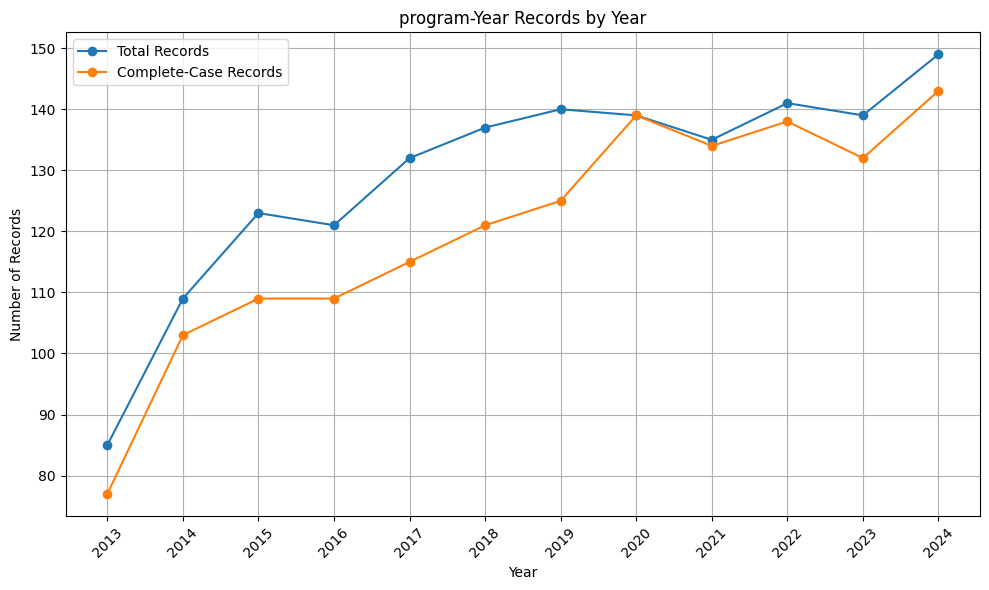

Records by university:


,university,record_count,complete_case_records,record_percent,complete_case_percent
0,Nanyang Technological University,479,441,30.90,92.07
1,National University of Singapore,478,433,30.84,90.59
2,Singapore Institute of Technology,355,342,22.90,96.34
3,Singapore Management University,150,150,9.68,100.00
4,Singapore University of Social Sciences,51,47,3.29,92.16
5,Singapore University of Technology and Design,37,32,2.39,86.49


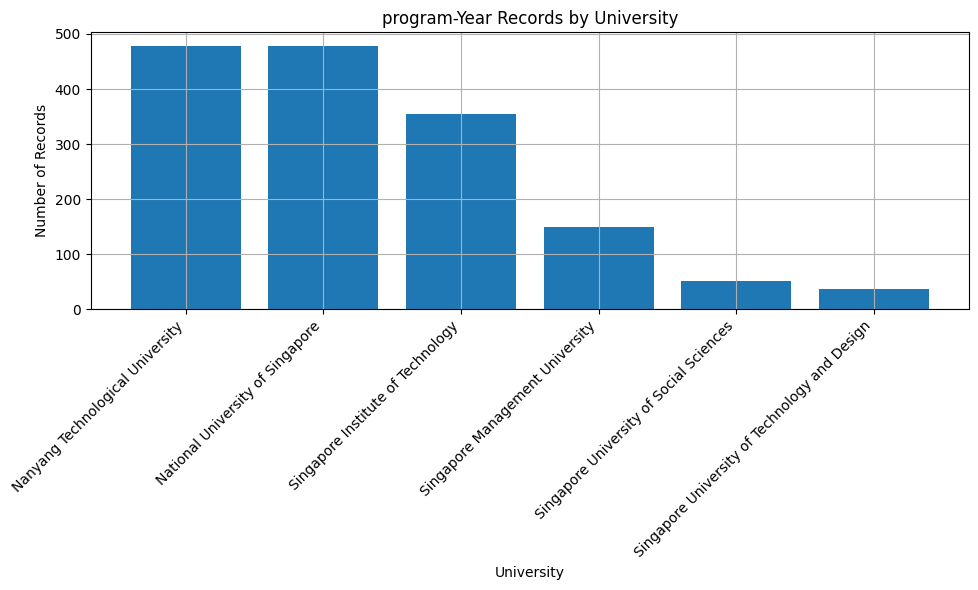

Records by university and year:


,year,university,record_count,complete_case_records,complete_case_percent
0,2013,Nanyang Technological University,34,32,94.12
1,2013,National University of Singapore,39,33,84.62
2,2013,Singapore Management University,12,12,100.00
3,2014,Nanyang Technological University,34,33,97.06
4,2014,National University of Singapore,39,34,87.18
5,2014,Singapore Institute of Technology,24,24,100.00
6,2014,Singapore Management University,12,12,100.00
7,2015,Nanyang Technological University,39,33,84.62
8,2015,National University of Singapore,40,36,90.00
9,2015,Singapore Institute of Technology,28,25,89.29


Records by university and year - pivot view:


university,Nanyang Technological University,National University of Singapore,Singapore Institute of Technology,Singapore Management University,Singapore University of Social Sciences,Singapore University of Technology and Design
year,,,,,,
2013,34,39,0,12,0,0
2014,34,39,24,12,0,0
2015,39,40,28,12,0,4
2016,39,38,28,12,0,4
2017,43,43,30,12,0,4
2018,44,41,33,12,3,4
2019,45,39,36,12,4,4
2020,40,39,37,12,7,4
2021,39,39,33,12,8,4


Dataset coverage summary:


,Coverage Item,Value
0,Total program-year records,"1,550.00"
1,Complete-case program-year records,"1,445.00"
2,Complete-case percentage,93.23
3,Years covered,12.00
4,Minimum year,"2,013.00"
5,Maximum year,"2,024.00"
6,Universities covered,6.00
7,Schools covered,78.00
8,Degree program names covered,419.00


Top 15 schools by number of program-year records:


,university,school,record_count,complete_case_records,complete_case_percent
2,Nanyang Technological University,College of Engineering,189,159,84.13
3,Nanyang Technological University,"College of Humanities, Arts & Social Sciences",116,115,99.14
44,Singapore Institute of Technology,Singapore Institute of Technology (SIT),77,77,100.00
14,National University of Singapore,Faculty of Engineering,66,65,98.48
16,National University of Singapore,Faculty of Science,65,49,75.38
21,National University of Singapore,School of Computing,61,43,70.49
20,National University of Singapore,NUS Business School,51,51,100.00
5,Nanyang Technological University,College of Sciences,50,46,92.00
0,Nanyang Technological University,College of Business (Nanyang Business School),48,48,100.00
30,Singapore Institute of Technology,DigiPen Institute of Technology,42,39,92.86


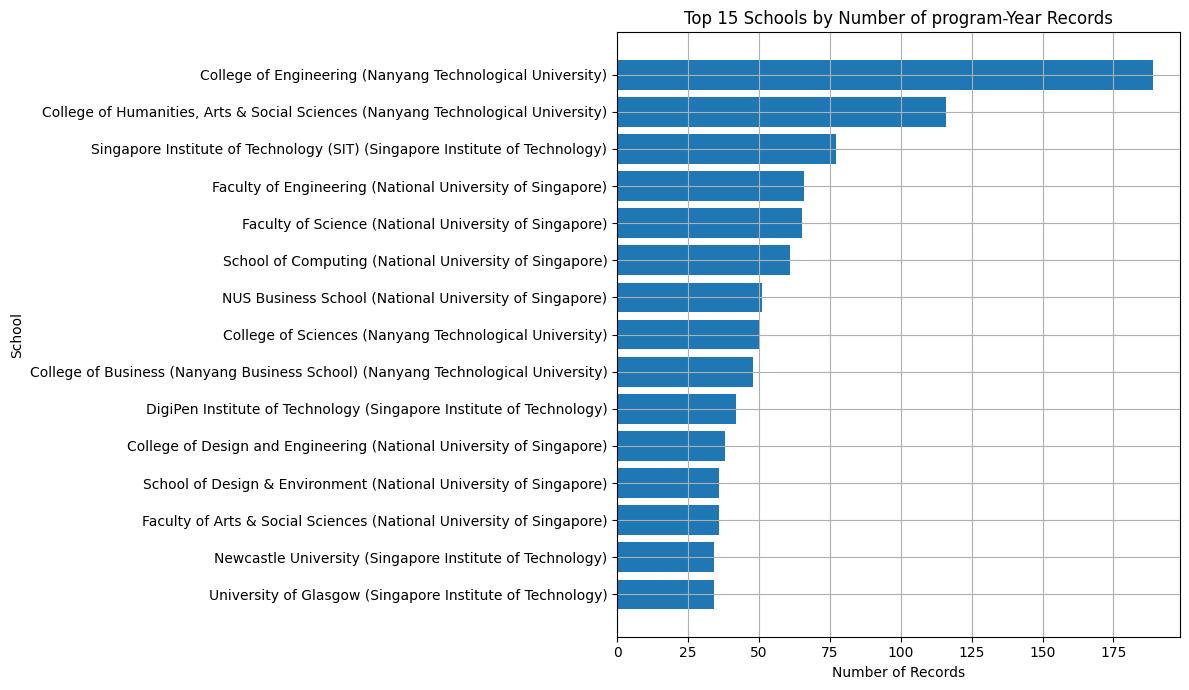

EDA coverage insight summary:


,Figure/Table Reference,What it Shows,Key Insight,Why it Matters,Decision / Next Step
0,Table: eda_records_by_year,Distribution of program-year records across years,Shows whether the dataset has consistent year-...,Supports RQ1 trend analysis,Use year-level coverage to interpret employmen...
1,Table: eda_records_by_university,Distribution of records across universities,Shows whether some universities contribute mor...,Supports RQ2 university-level comparison,Use university record counts when interpreting...
2,Table: eda_records_by_university_year_pivot,University coverage by year,Shows when universities enter or expand in the...,Prevents misleading comparison across years,Use this table to explain coverage differences...
3,Table: eda_top_schools_by_records,Schools with the highest number of program-yea...,Identifies the most represented schools in the...,Helps interpret school-level and program-level...,Use school-level coverage as context for later...


Dataset coverage EDA completed.
------------------------------------------------------------
Saved tables:
- eda_records_by_year.csv
- eda_records_by_university.csv
- eda_records_by_university_year.csv
- eda_records_by_university_year_pivot.csv
- eda_coverage_summary.csv
- eda_top_schools_by_records.csv
- eda_coverage_insight_summary.csv
Saved figures:
- figure_05_01_records_by_year.png
- figure_05_02_records_by_university.png
- figure_05_03_top_schools_by_records.png


In [8]:
# ============================================================
# Part 5: Exploratory Data Analysis — Dataset Coverage
# ============================================================

# ------------------------------------------------------------
# Use the analysis dataset created earlier
# ------------------------------------------------------------

eda_df = df_analysis.copy()

# Ensure analysis_complete_case is available
if "analysis_complete_case" not in eda_df.columns:
    key_outcome_cols = [
        "employment_rate_overall",
        "employment_rate_ft_perm",
        "gross_monthly_median",
        "gross_mthly_25_percentile",
        "gross_mthly_75_percentile",
        "salary_iqr",
        "career_value_index"
    ]
    eda_df["analysis_complete_case"] = eda_df[key_outcome_cols].notna().all(axis=1)

# ------------------------------------------------------------
# 5.1 Records by year
# ------------------------------------------------------------

records_by_year = (
    eda_df
    .groupby("year")
    .agg(
        record_count=("year", "size"),
        complete_case_records=("analysis_complete_case", "sum")
    )
    .reset_index()
    .sort_values("year")
)

records_by_year["record_percent"] = (
    records_by_year["record_count"] / len(eda_df) * 100
).round(2)

records_by_year["complete_case_percent"] = (
    records_by_year["complete_case_records"] / records_by_year["record_count"] * 100
).round(2)

records_by_year.to_csv(TABLE_DIR / "eda_records_by_year.csv", index=False)

print("Records by year:")
display(records_by_year)

plt.figure(figsize=(10, 6))
plt.plot(records_by_year["year"], records_by_year["record_count"], marker="o", label="Total Records")
plt.plot(records_by_year["year"], records_by_year["complete_case_records"], marker="o", label="Complete-Case Records")
plt.title("program-Year Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.xticks(records_by_year["year"], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_05_01_records_by_year.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 5.2 Records by university
# ------------------------------------------------------------

records_by_university = (
    eda_df
    .groupby("university")
    .agg(
        record_count=("university", "size"),
        complete_case_records=("analysis_complete_case", "sum")
    )
    .reset_index()
    .sort_values("record_count", ascending=False)
)

records_by_university["record_percent"] = (
    records_by_university["record_count"] / len(eda_df) * 100
).round(2)

records_by_university["complete_case_percent"] = (
    records_by_university["complete_case_records"] / records_by_university["record_count"] * 100
).round(2)

records_by_university.to_csv(TABLE_DIR / "eda_records_by_university.csv", index=False)

print("Records by university:")
display(records_by_university)

plt.figure(figsize=(10, 6))
plt.bar(records_by_university["university"], records_by_university["record_count"], label="Total Records")
plt.title("program-Year Records by University")
plt.xlabel("University")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_05_02_records_by_university.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 5.3 Records by university and year
# ------------------------------------------------------------

records_by_university_year = (
    eda_df
    .groupby(["year", "university"])
    .agg(
        record_count=("university", "size"),
        complete_case_records=("analysis_complete_case", "sum")
    )
    .reset_index()
    .sort_values(["year", "university"])
)

records_by_university_year["complete_case_percent"] = (
    records_by_university_year["complete_case_records"] /
    records_by_university_year["record_count"] * 100
).round(2)

records_by_university_year.to_csv(TABLE_DIR / "eda_records_by_university_year.csv", index=False)

print("Records by university and year:")
display(records_by_university_year.head(20))

records_by_university_year_pivot = records_by_university_year.pivot(
    index="year",
    columns="university",
    values="record_count"
).fillna(0).astype(int)

records_by_university_year_pivot.to_csv(TABLE_DIR / "eda_records_by_university_year_pivot.csv")

print("Records by university and year - pivot view:")
display(records_by_university_year_pivot)

# ------------------------------------------------------------
# 5.4 School and degree program coverage
# ------------------------------------------------------------

coverage_summary = pd.DataFrame([
    {
        "Coverage Item": "Total program-year records",
        "Value": len(eda_df)
    },
    {
        "Coverage Item": "Complete-case program-year records",
        "Value": int(eda_df["analysis_complete_case"].sum())
    },
    {
        "Coverage Item": "Complete-case percentage",
        "Value": round(eda_df["analysis_complete_case"].mean() * 100, 2)
    },
    {
        "Coverage Item": "Years covered",
        "Value": eda_df["year"].nunique()
    },
    {
        "Coverage Item": "Minimum year",
        "Value": int(eda_df["year"].min())
    },
    {
        "Coverage Item": "Maximum year",
        "Value": int(eda_df["year"].max())
    },
    {
        "Coverage Item": "Universities covered",
        "Value": eda_df["university"].nunique()
    },
    {
        "Coverage Item": "Schools covered",
        "Value": eda_df["school"].nunique()
    },
    {
        "Coverage Item": "Degree program names covered",
        "Value": eda_df["degree"].nunique()
    }
])

coverage_summary.to_csv(TABLE_DIR / "eda_coverage_summary.csv", index=False)

print("Dataset coverage summary:")
display(coverage_summary)

# ------------------------------------------------------------
# 5.5 Top schools by number of records
# ------------------------------------------------------------

top_schools = (
    eda_df
    .groupby(["university", "school"])
    .agg(
        record_count=("school", "size"),
        complete_case_records=("analysis_complete_case", "sum")
    )
    .reset_index()
    .sort_values("record_count", ascending=False)
    .head(15)
)

top_schools["complete_case_percent"] = (
    top_schools["complete_case_records"] / top_schools["record_count"] * 100
).round(2)

top_schools.to_csv(TABLE_DIR / "eda_top_schools_by_records.csv", index=False)

print("Top 15 schools by number of program-year records:")
display(top_schools)

plt.figure(figsize=(12, 7))
plt.barh(
    top_schools["school"] + " (" + top_schools["university"] + ")",
    top_schools["record_count"]
)
plt.title("Top 15 Schools by Number of program-Year Records")
plt.xlabel("Number of Records")
plt.ylabel("School")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_05_03_top_schools_by_records.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 5.6 EDA coverage insight summary
# ------------------------------------------------------------

eda_coverage_insight_summary = pd.DataFrame([
    {
        "Figure/Table Reference": "Table: eda_records_by_year",
        "What it Shows": "Distribution of program-year records across years",
        "Key Insight": "Shows whether the dataset has consistent year-level coverage",
        "Why it Matters": "Supports RQ1 trend analysis",
        "Decision / Next Step": "Use year-level coverage to interpret employment and salary trends"
    },
    {
        "Figure/Table Reference": "Table: eda_records_by_university",
        "What it Shows": "Distribution of records across universities",
        "Key Insight": "Shows whether some universities contribute more observations than others",
        "Why it Matters": "Supports RQ2 university-level comparison",
        "Decision / Next Step": "Use university record counts when interpreting group comparisons"
    },
    {
        "Figure/Table Reference": "Table: eda_records_by_university_year_pivot",
        "What it Shows": "University coverage by year",
        "Key Insight": "Shows when universities enter or expand in the dataset",
        "Why it Matters": "Prevents misleading comparison across years",
        "Decision / Next Step": "Use this table to explain coverage differences in trend results"
    },
    {
        "Figure/Table Reference": "Table: eda_top_schools_by_records",
        "What it Shows": "Schools with the highest number of program-year records",
        "Key Insight": "Identifies the most represented schools in the dataset",
        "Why it Matters": "Helps interpret school-level and program-level representation",
        "Decision / Next Step": "Use school-level coverage as context for later EDA and modelling"
    }
])

eda_coverage_insight_summary.to_csv(
    TABLE_DIR / "eda_coverage_insight_summary.csv",
    index=False
)

print("EDA coverage insight summary:")
display(eda_coverage_insight_summary)

# ------------------------------------------------------------
# 5.7 Save completion message
# ------------------------------------------------------------

print("Dataset coverage EDA completed.")
print("-" * 60)
print("Saved tables:")
print("- eda_records_by_year.csv")
print("- eda_records_by_university.csv")
print("- eda_records_by_university_year.csv")
print("- eda_records_by_university_year_pivot.csv")
print("- eda_coverage_summary.csv")
print("- eda_top_schools_by_records.csv")
print("- eda_coverage_insight_summary.csv")

print("Saved figures:")
print("- figure_05_01_records_by_year.png")
print("- figure_05_02_records_by_university.png")
print("- figure_05_03_top_schools_by_records.png")

## Part 5 Interpretation

Key observations from dataset coverage EDA:

- The dataset contains **1,550 program-year records** across **12 years**, from **2013 to 2024**.

- The number of records generally increases over time:
  - Lowest record count: **85 records in 2013**
  - Highest record count: **149 records in 2024**

- The increase in yearly records suggests that the dataset coverage expanded over time as more universities and programs were included.

- The dataset has **1,445 complete-case records**, representing **93.23%** of the total dataset.

- Complete-case coverage is strong overall, but it varies by year:
  - Highest complete-case coverage: **2020 at 100.00%**
  - Lowest complete-case coverage: **2017 at 87.12%**
  - Other lower complete-case years include **2015, 2018, and 2019**

- The dataset includes **6 universities**, but the record distribution is not equal across institutions.

- The largest contributors are:
  - **Nanyang Technological University:** 479 records, **30.90%**
  - **National University of Singapore:** 478 records, **30.84%**
  - **Singapore Institute of Technology:** 355 records, **22.90%**

- These three universities together contribute most of the program-year records in the dataset.

- Smaller record counts are observed for:
  - **Singapore University of Social Sciences:** 51 records, **3.29%**
  - **Singapore University of Technology and Design:** 37 records, **2.39%**

- Singapore Management University has **150 records** and **100.00% complete-case coverage**.

- Singapore University of Technology and Design has the lowest complete-case coverage by university at **86.49%**.

- The university-year pivot table shows that not all universities appear in every year:
  - Singapore Institute of Technology appears from **2014** onward.
  - Singapore University of Technology and Design appears in selected years.
  - Singapore University of Social Sciences appears from **2018** onward.

- This is important because year-level and university-level comparisons must be interpreted with awareness of coverage differences.

- The dataset covers:
  - **78 schools**
  - **419 degree program names**

- The top school by number of records is:
  - **Nanyang Technological University – College of Engineering**, with **189 records**

- Several highly represented schools are from NTU, NUS, and SIT, which aligns with the overall university-level record distribution.

- Some top schools have lower complete-case coverage:
  - **NUS School of Computing:** 70.49%
  - **NUS Faculty of Science:** 75.38%
  - **NTU College of Engineering:** 84.13%

- This means later school-level or program-level findings should be interpreted carefully when missing outcome values are present.

Interim report implication:

- The dataset has sufficient coverage for exploratory analysis, statistical testing, and preliminary modelling.

- However, the dataset is not perfectly balanced across universities, years, and schools.

- Coverage differences should be reported as a limitation when comparing outcomes across institutions or over time.

Evidence generated for the interim report:

- `eda_records_by_year.csv`
- `eda_records_by_university.csv`
- `eda_records_by_university_year.csv`
- `eda_records_by_university_year_pivot.csv`
- `eda_coverage_summary.csv`
- `eda_top_schools_by_records.csv`
- `eda_coverage_insight_summary.csv`
- `figure_05_01_records_by_year.png`
- `figure_05_02_records_by_university.png`
- `figure_05_03_top_schools_by_records.png`

Next action:

- Proceed to univariate analysis of key employment, salary, stability, and career-value variables.

Univariate summary of key outcome variables:


,Variable,Valid Count,Missing Count,Missing Percent,Mean,Median,Standard Deviation,Minimum,25th Percentile,75th Percentile,Maximum,Skewness,IQR Outlier Count,IQR Lower Bound,IQR Upper Bound
0,employment_rate_overall,1445,105,6.77,91.12,92.30,6.91,55.20,87.00,96.60,100.00,-0.94,22,72.60,111.00
1,employment_rate_ft_perm,1445,105,6.77,81.75,84.70,14.23,14.30,74.10,92.70,100.00,-1.11,31,46.20,120.60
2,employment_premium,1445,105,6.77,9.37,6.00,10.45,0.00,2.20,13.00,71.40,2.09,82,-14.00,29.20
3,basic_monthly_mean,1445,105,6.77,"3,819.41","3,646.00",766.37,"2,000.00","3,277.00","4,211.00","7,051.00",1.11,42,"1,876.00","5,612.00"
4,basic_monthly_median,1445,105,6.77,"3,693.14","3,500.00",721.93,"1,750.00","3,200.00","4,000.00","7,000.00",1.20,55,"2,000.00","5,200.00"
5,gross_monthly_mean,1445,105,6.77,"3,944.99","3,772.00",794.28,"2,100.00","3,389.00","4,351.00","7,244.00",1.13,41,"1,946.00","5,794.00"
6,gross_monthly_median,1445,105,6.77,"3,790.30","3,600.00",749.29,"1,800.00","3,300.00","4,107.00","7,000.00",1.19,70,"2,089.50","5,317.50"
7,gross_mthly_25_percentile,1445,105,6.77,"3,441.00","3,350.00",634.19,"1,500.00","3,000.00","3,775.00","6,500.00",1.04,42,"1,837.50","4,937.50"
8,gross_mthly_75_percentile,1445,105,6.77,"4,267.42","4,000.00",925.27,"2,500.00","3,600.00","4,750.00","9,967.00",1.32,45,"1,875.00","6,475.00"
9,salary_iqr,1445,105,6.77,826.42,730.00,468.61,0.00,510.00,"1,000.00","5,817.00",2.71,51,-225.00,"1,735.00"


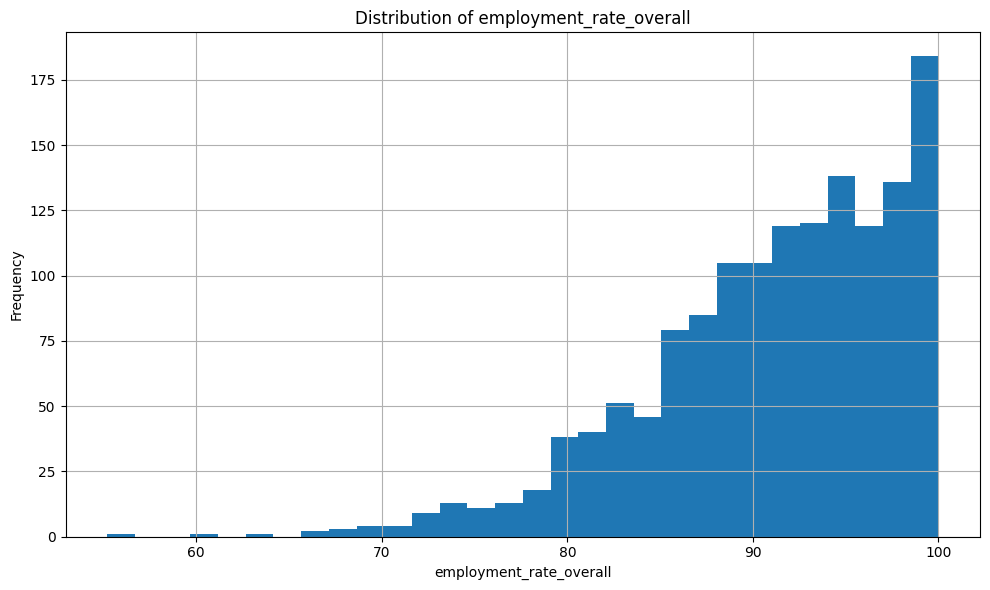

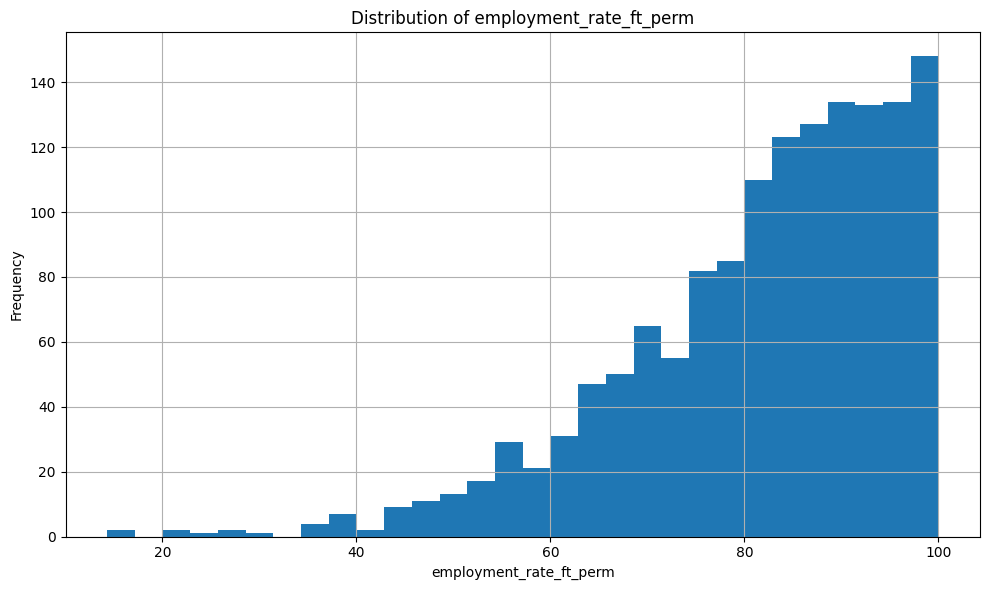

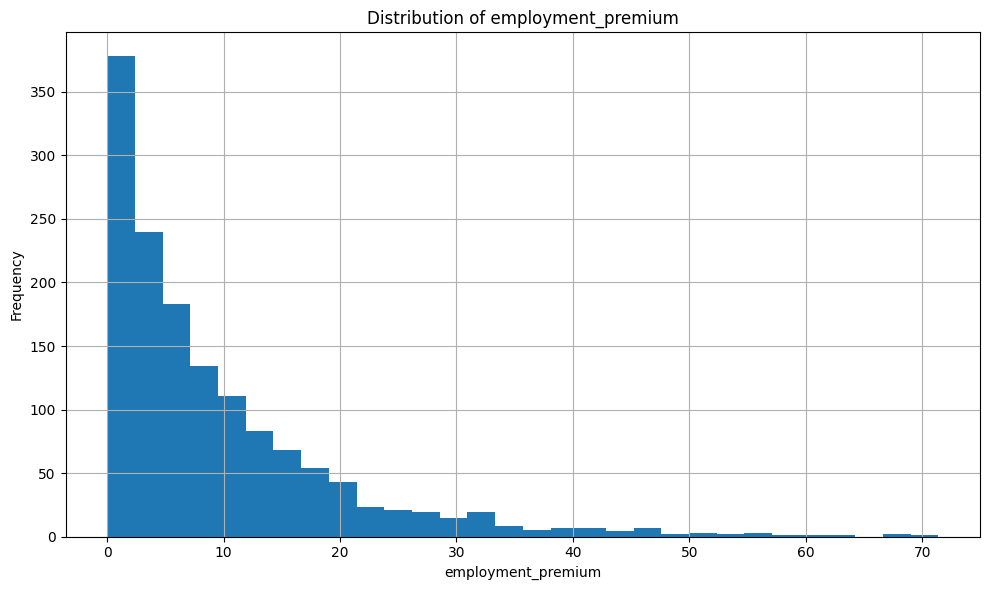

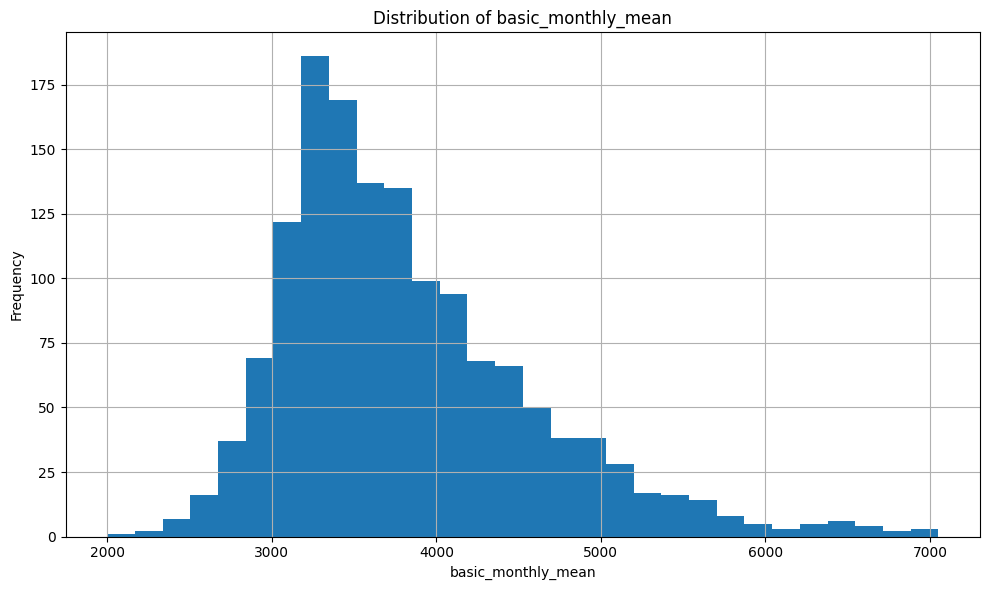

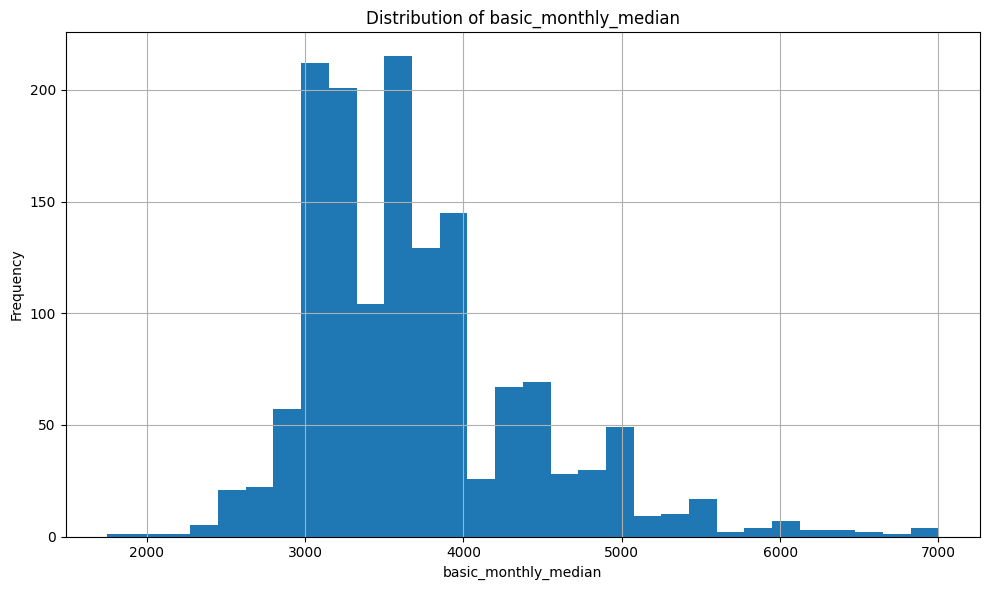

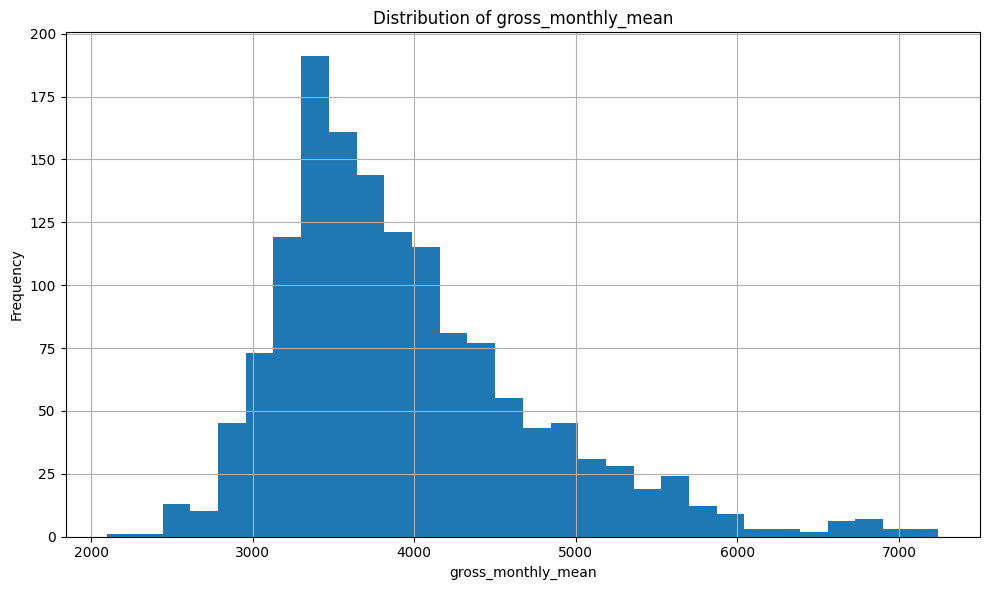

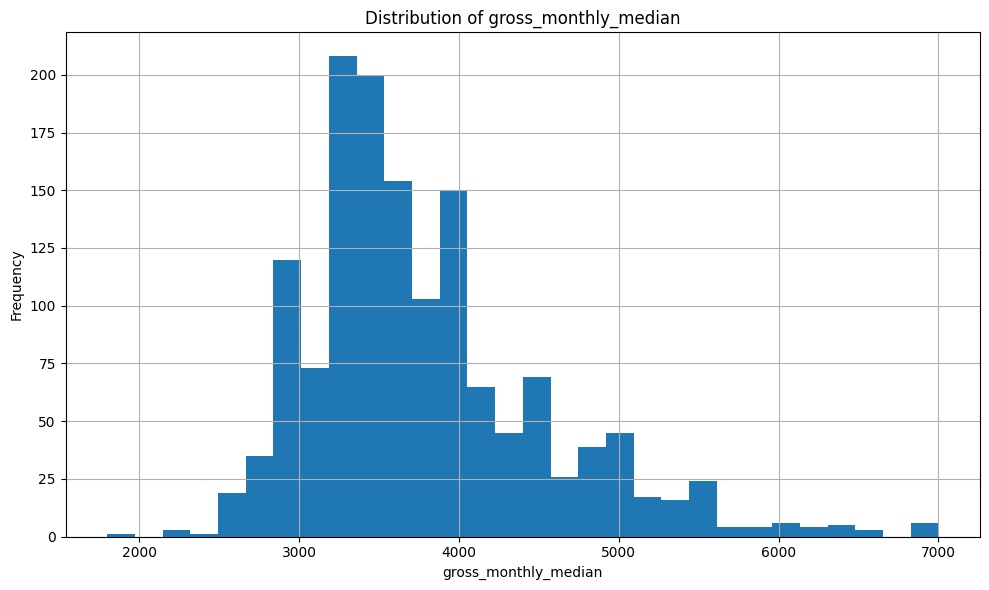

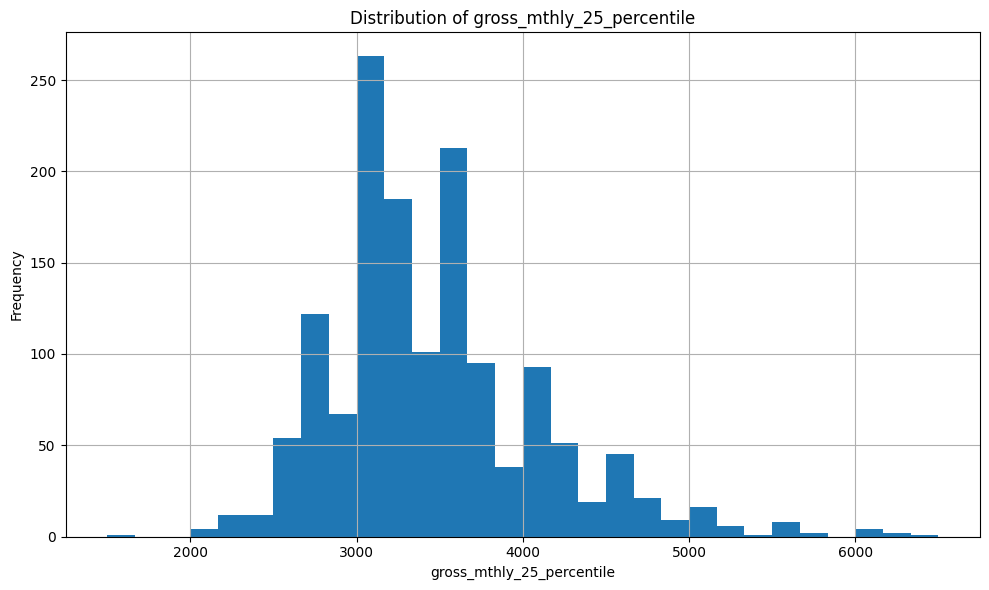

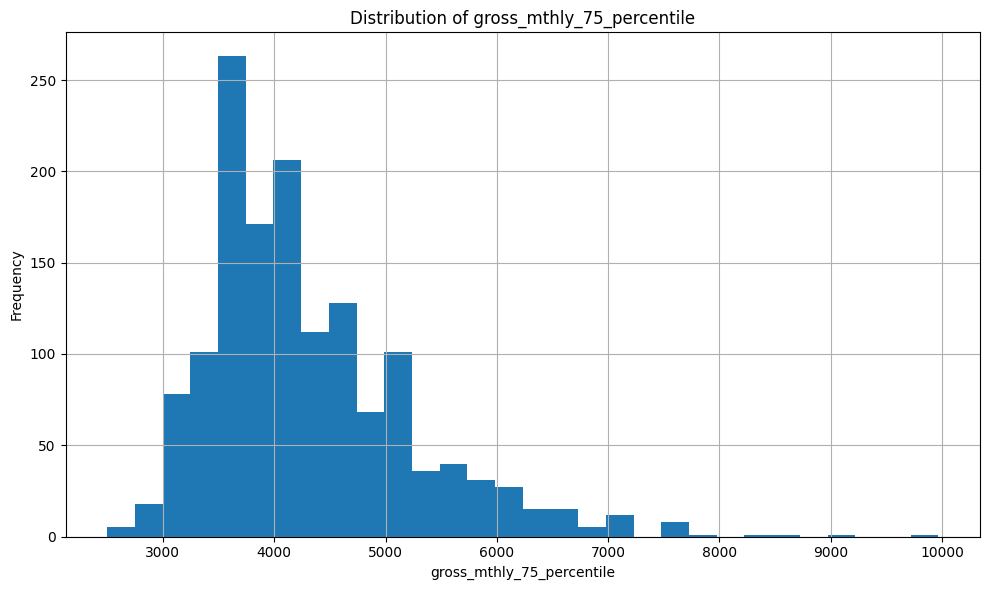

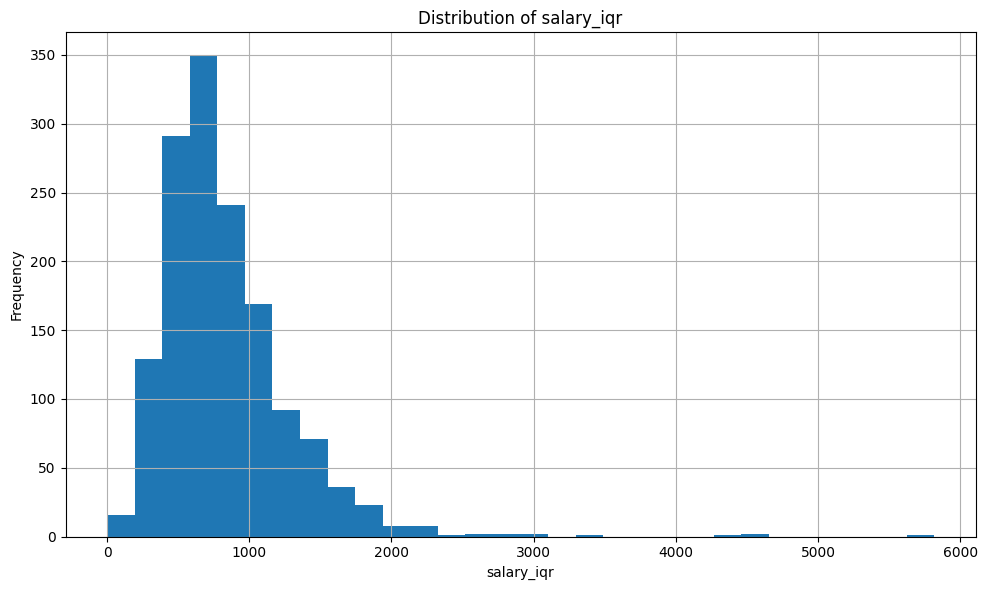

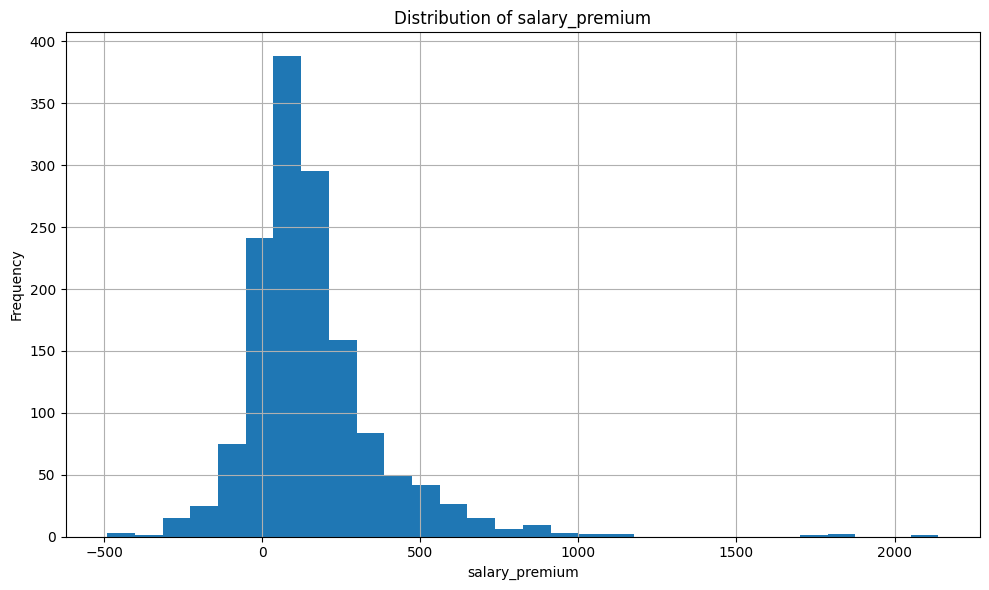

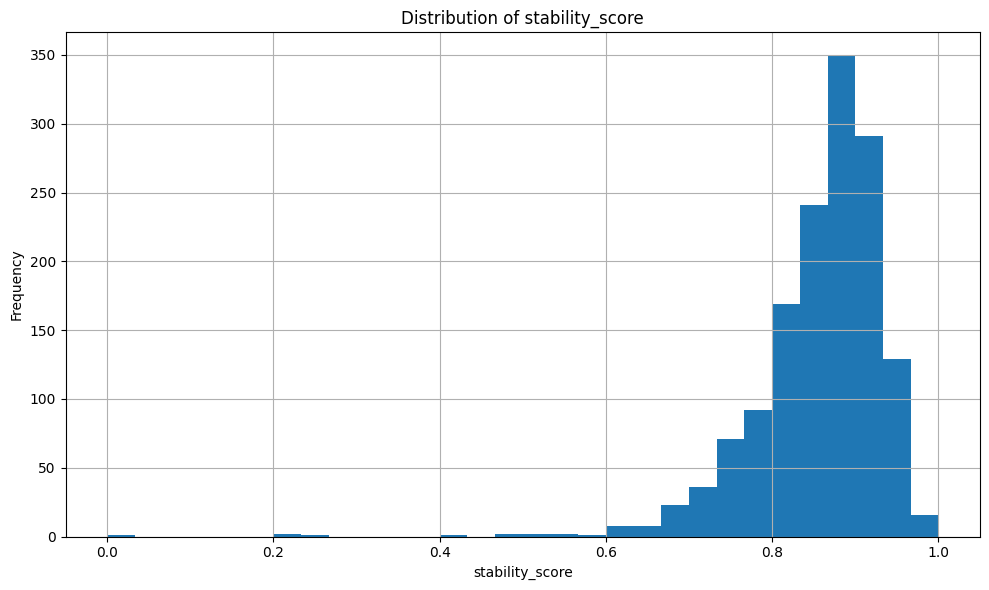

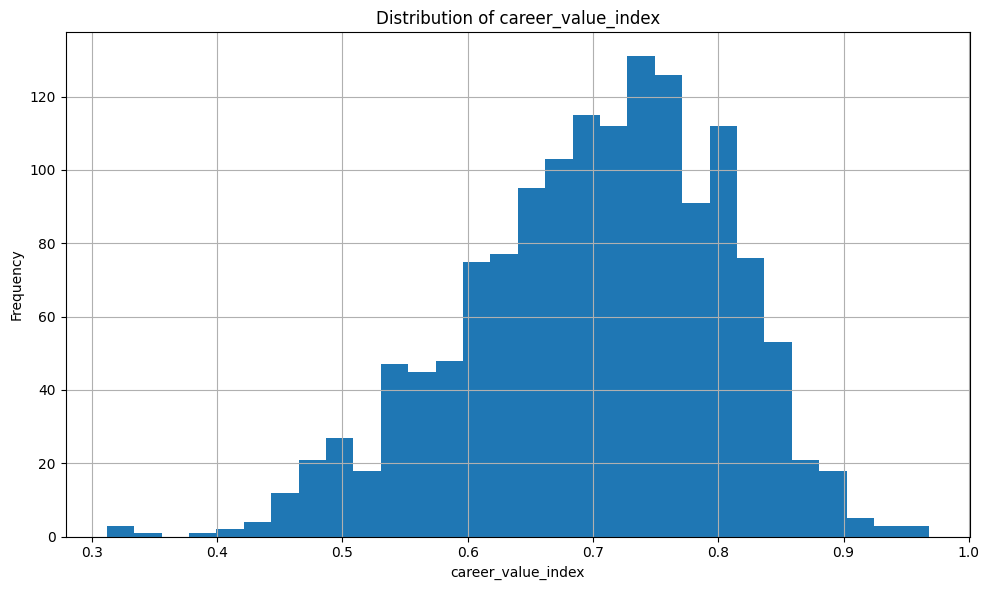

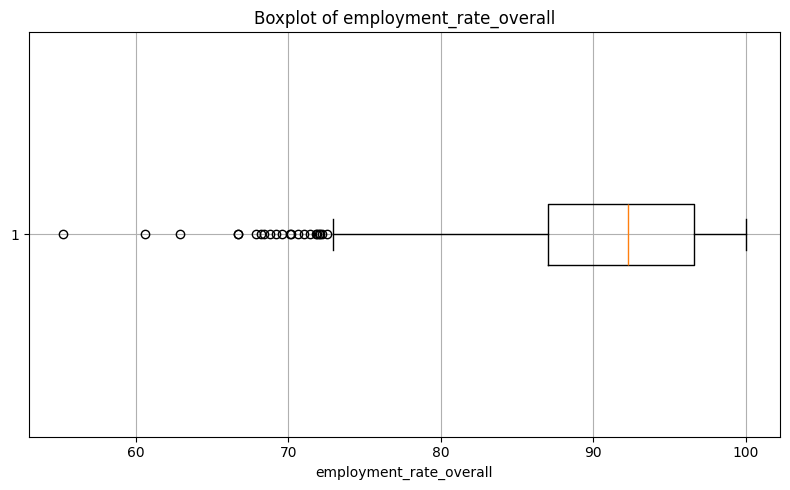

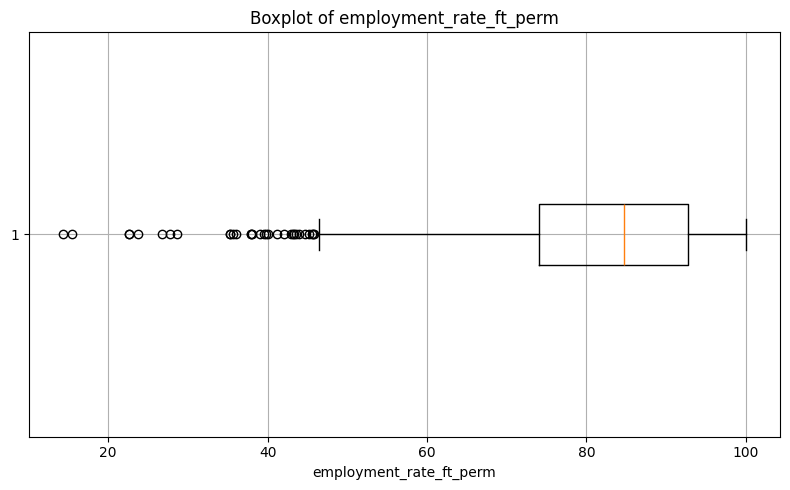

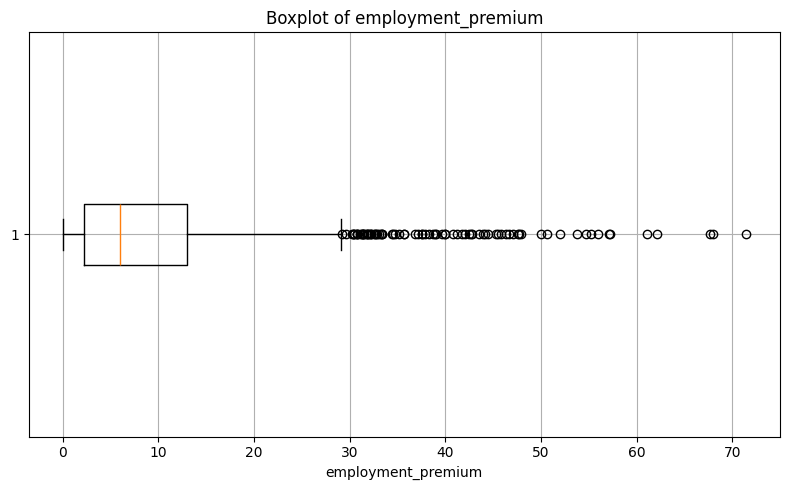

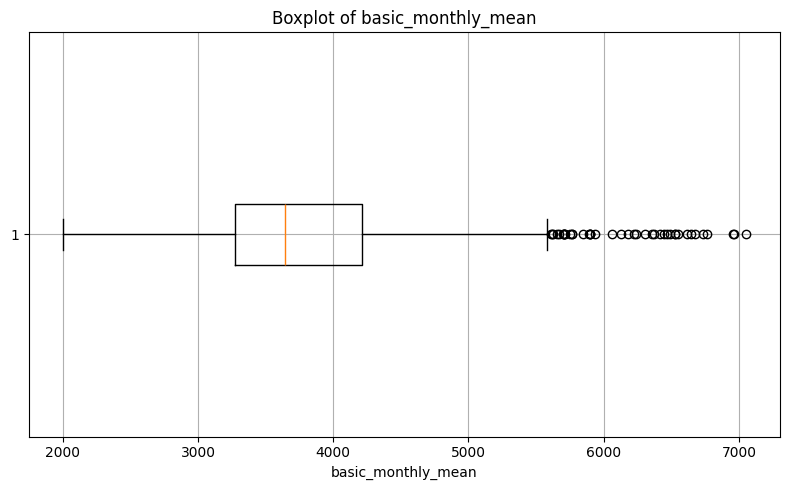

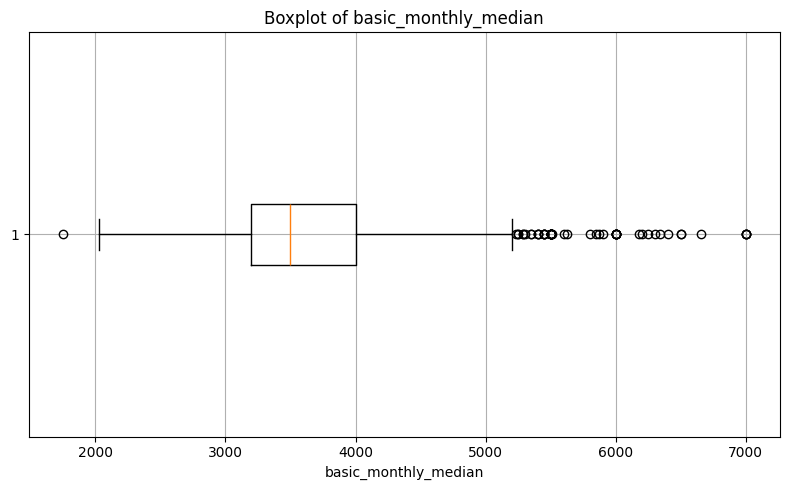

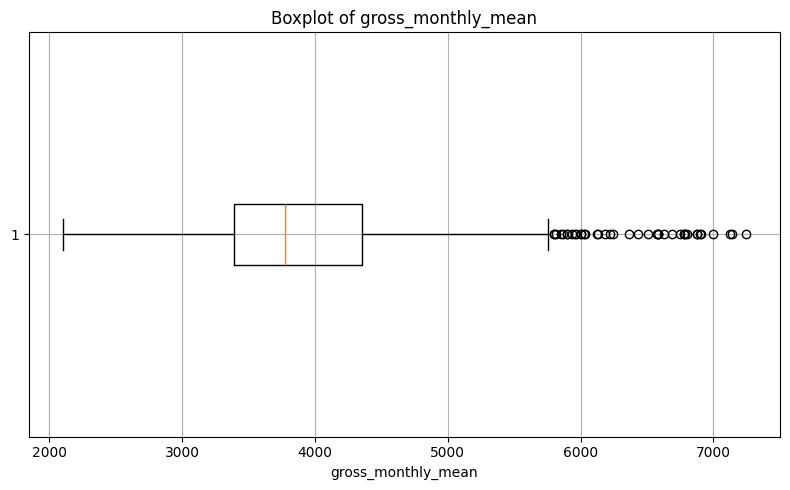

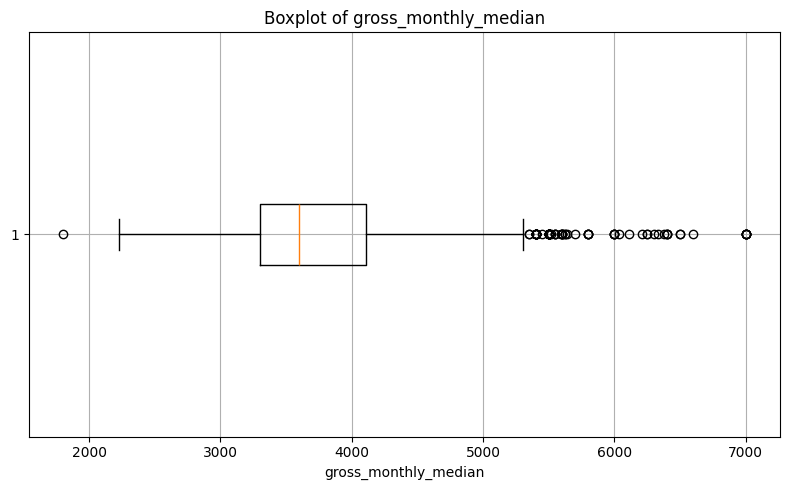

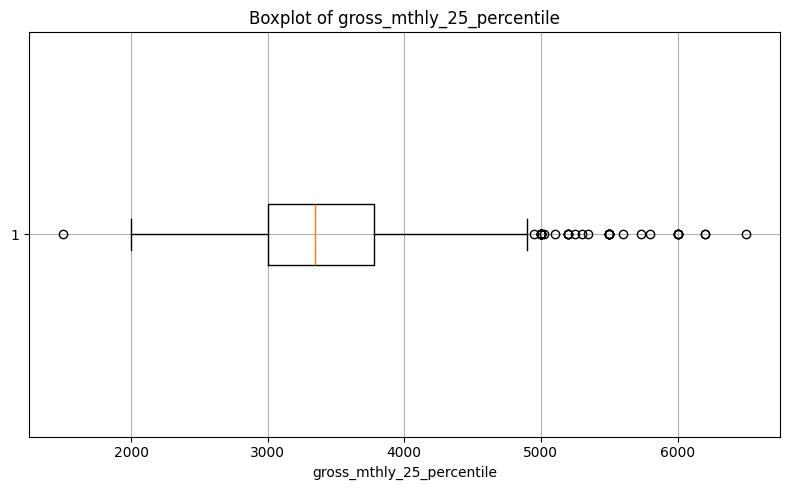

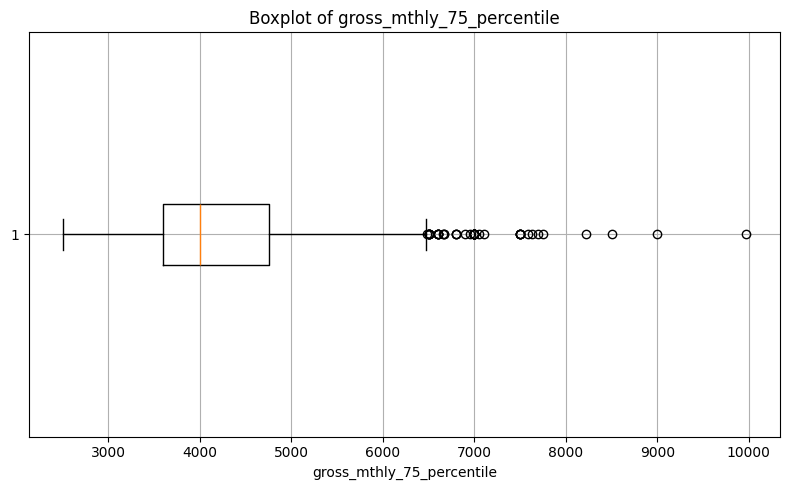

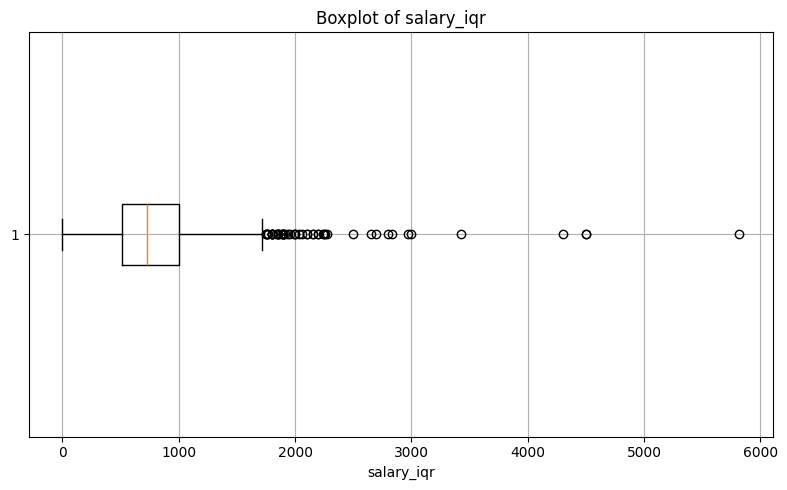

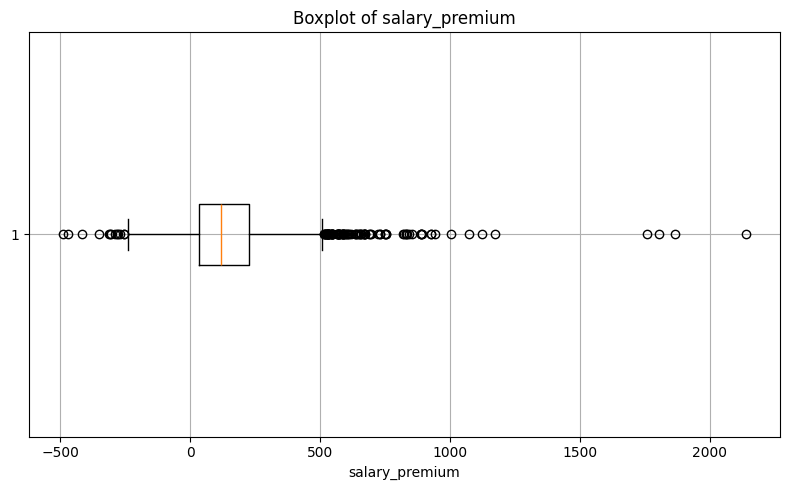

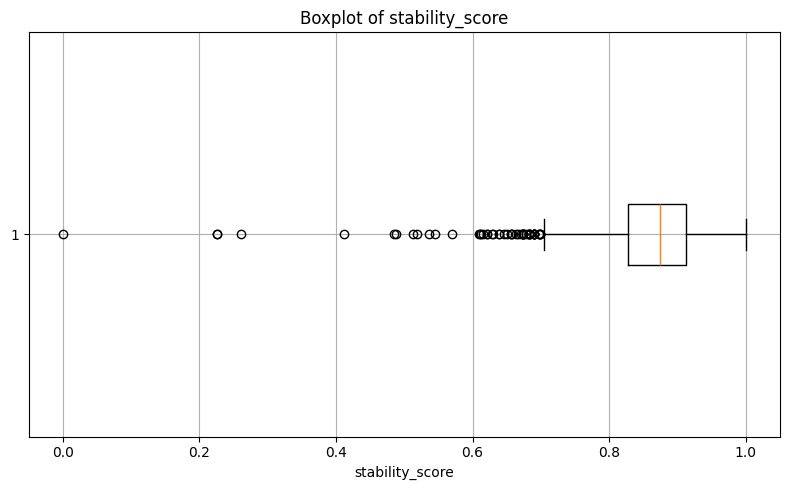

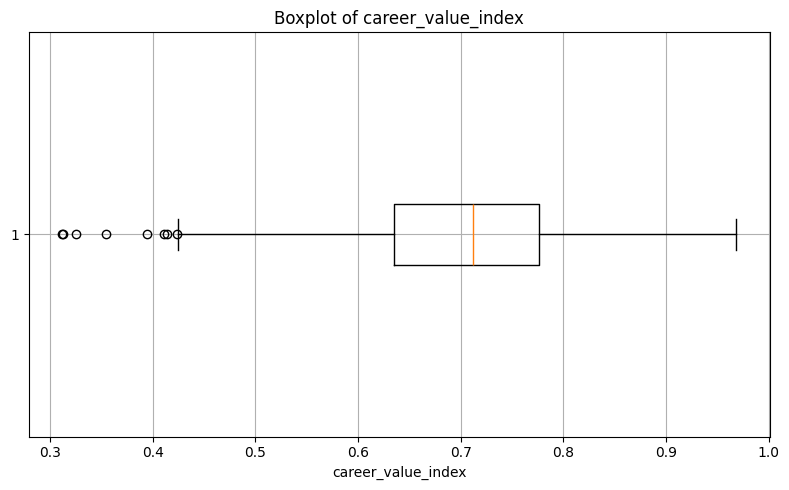

Employment variable summary:


,Variable,Valid Count,Missing Count,Missing Percent,Mean,Median,Standard Deviation,Minimum,25th Percentile,75th Percentile,Maximum,Skewness,IQR Outlier Count,IQR Lower Bound,IQR Upper Bound
0,employment_rate_overall,1445,105,6.77,91.12,92.30,6.91,55.20,87.00,96.60,100.00,-0.94,22,72.60,111.00
1,employment_rate_ft_perm,1445,105,6.77,81.75,84.70,14.23,14.30,74.10,92.70,100.00,-1.11,31,46.20,120.60
2,employment_premium,1445,105,6.77,9.37,6.00,10.45,0.00,2.20,13.00,71.40,2.09,82,-14.00,29.20


Salary variable summary:


,Variable,Valid Count,Missing Count,Missing Percent,Mean,Median,Standard Deviation,Minimum,25th Percentile,75th Percentile,Maximum,Skewness,IQR Outlier Count,IQR Lower Bound,IQR Upper Bound
3,basic_monthly_mean,1445,105,6.77,"3,819.41","3,646.00",766.37,"2,000.00","3,277.00","4,211.00","7,051.00",1.11,42,"1,876.00","5,612.00"
4,basic_monthly_median,1445,105,6.77,"3,693.14","3,500.00",721.93,"1,750.00","3,200.00","4,000.00","7,000.00",1.20,55,"2,000.00","5,200.00"
5,gross_monthly_mean,1445,105,6.77,"3,944.99","3,772.00",794.28,"2,100.00","3,389.00","4,351.00","7,244.00",1.13,41,"1,946.00","5,794.00"
6,gross_monthly_median,1445,105,6.77,"3,790.30","3,600.00",749.29,"1,800.00","3,300.00","4,107.00","7,000.00",1.19,70,"2,089.50","5,317.50"
7,gross_mthly_25_percentile,1445,105,6.77,"3,441.00","3,350.00",634.19,"1,500.00","3,000.00","3,775.00","6,500.00",1.04,42,"1,837.50","4,937.50"
8,gross_mthly_75_percentile,1445,105,6.77,"4,267.42","4,000.00",925.27,"2,500.00","3,600.00","4,750.00","9,967.00",1.32,45,"1,875.00","6,475.00"
9,salary_iqr,1445,105,6.77,826.42,730.00,468.61,0.00,510.00,"1,000.00","5,817.00",2.71,51,-225.00,"1,735.00"
10,salary_premium,1445,105,6.77,154.69,117.00,215.69,-491.00,35.00,225.00,"2,139.00",2.34,105,-250.00,510.00


Career-value variable summary:


,Variable,Valid Count,Missing Count,Missing Percent,Mean,Median,Standard Deviation,Minimum,25th Percentile,75th Percentile,Maximum,Skewness,IQR Outlier Count,IQR Lower Bound,IQR Upper Bound
11,stability_score,1445,105,6.77,0.86,0.87,0.08,0.00,0.83,0.91,1.00,-2.71,51,0.70,1.04
12,career_value_index,1445,105,6.77,0.70,0.71,0.10,0.31,0.63,0.78,0.97,-0.46,8,0.42,0.99


EDA univariate insight summary:


,Figure/Table Reference,What it Shows,Key Insight,Why it Matters,Decision / Next Step
0,Table: eda_univariate_summary,"Descriptive statistics for employment, salary,...","Summarizes central tendency, spread, missingne...",Supports RQ1 and prepares variables for later ...,"Use distributions to guide trend analysis, sta..."
1,Histogram figures,Frequency distribution of each key variable,"Shows whether variables are symmetric, skewed,...",Helps determine whether mean or median is more...,Use robust summaries when variables show skewn...
2,Boxplot figures,Spread and possible outliers for each key vari...,Highlights variables with extreme values or wi...,Supports later statistical testing and model v...,Review outliers as real program-level variatio...


Univariate EDA completed.
------------------------------------------------------------
Saved tables:
- eda_univariate_summary.csv
- eda_univariate_employment_summary.csv
- eda_univariate_salary_summary.csv
- eda_univariate_career_value_summary.csv
- eda_univariate_insight_summary.csv
Saved figures:
- Histogram and boxplot figures for each key univariate variable


In [9]:
# ============================================================
# Part 6: Univariate Analysis of Key Outcome Variables
# ============================================================

# ------------------------------------------------------------
# Use the analysis dataset created earlier
# ------------------------------------------------------------

eda_df = df_analysis.copy()

# ------------------------------------------------------------
# Define key variables for univariate analysis
# ------------------------------------------------------------

employment_vars = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "employment_premium"
]

salary_vars = [
    "basic_monthly_mean",
    "basic_monthly_median",
    "gross_monthly_mean",
    "gross_monthly_median",
    "gross_mthly_25_percentile",
    "gross_mthly_75_percentile",
    "salary_iqr",
    "salary_premium"
]

career_value_vars = [
    "stability_score",
    "career_value_index"
]

univariate_vars = [
    var for var in employment_vars + salary_vars + career_value_vars
    if var in eda_df.columns
]

# ------------------------------------------------------------
# Helper function for IQR-based outlier count
# ------------------------------------------------------------

def iqr_outlier_count(series):
    valid_series = series.dropna()
    
    if valid_series.empty:
        return 0, np.nan, np.nan
    
    q1 = valid_series.quantile(0.25)
    q3 = valid_series.quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((valid_series < lower_bound) | (valid_series > upper_bound)).sum()
    
    return int(outlier_count), lower_bound, upper_bound

# ------------------------------------------------------------
# Build univariate summary table
# ------------------------------------------------------------

univariate_summary_rows = []

for var in univariate_vars:
    valid_values = eda_df[var].dropna()
    outlier_count, lower_bound, upper_bound = iqr_outlier_count(eda_df[var])
    
    univariate_summary_rows.append({
        "Variable": var,
        "Valid Count": int(valid_values.count()),
        "Missing Count": int(eda_df[var].isna().sum()),
        "Missing Percent": round(eda_df[var].isna().mean() * 100, 2),
        "Mean": valid_values.mean(),
        "Median": valid_values.median(),
        "Standard Deviation": valid_values.std(),
        "Minimum": valid_values.min(),
        "25th Percentile": valid_values.quantile(0.25),
        "75th Percentile": valid_values.quantile(0.75),
        "Maximum": valid_values.max(),
        "Skewness": valid_values.skew(),
        "IQR Outlier Count": outlier_count,
        "IQR Lower Bound": lower_bound,
        "IQR Upper Bound": upper_bound
    })

univariate_summary = pd.DataFrame(univariate_summary_rows)

# Save table
univariate_summary.to_csv(TABLE_DIR / "eda_univariate_summary.csv", index=False)

print("Univariate summary of key outcome variables:")
display(univariate_summary)

# ------------------------------------------------------------
# Distribution plots: histograms
# ------------------------------------------------------------

for var in univariate_vars:
    valid_values = eda_df[var].dropna()
    
    if valid_values.empty:
        continue
    
    plt.figure(figsize=(10, 6))
    plt.hist(valid_values, bins=30)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"figure_06_hist_{var}.png", dpi=300)
    plt.show()
    plt.close()

# ------------------------------------------------------------
# Boxplots for key variables
# ------------------------------------------------------------

for var in univariate_vars:
    valid_values = eda_df[var].dropna()
    
    if valid_values.empty:
        continue
    
    plt.figure(figsize=(8, 5))
    plt.boxplot(valid_values, vert=False)
    plt.title(f"Boxplot of {var}")
    plt.xlabel(var)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"figure_06_boxplot_{var}.png", dpi=300)
    plt.show()
    plt.close()

# ------------------------------------------------------------
# Focused grouped summaries
# ------------------------------------------------------------

employment_summary = univariate_summary[
    univariate_summary["Variable"].isin(employment_vars)
].copy()

salary_summary = univariate_summary[
    univariate_summary["Variable"].isin(salary_vars)
].copy()

career_value_summary = univariate_summary[
    univariate_summary["Variable"].isin(career_value_vars)
].copy()

employment_summary.to_csv(TABLE_DIR / "eda_univariate_employment_summary.csv", index=False)
salary_summary.to_csv(TABLE_DIR / "eda_univariate_salary_summary.csv", index=False)
career_value_summary.to_csv(TABLE_DIR / "eda_univariate_career_value_summary.csv", index=False)

print("Employment variable summary:")
display(employment_summary)

print("Salary variable summary:")
display(salary_summary)

print("Career-value variable summary:")
display(career_value_summary)

# ------------------------------------------------------------
# Report-ready univariate insight summary
# ------------------------------------------------------------

eda_univariate_insight_summary = pd.DataFrame([
    {
        "Figure/Table Reference": "Table: eda_univariate_summary",
        "What it Shows": "Descriptive statistics for employment, salary, stability, and career-value variables",
        "Key Insight": "Summarizes central tendency, spread, missingness, skewness, and outlier counts",
        "Why it Matters": "Supports RQ1 and prepares variables for later modelling",
        "Decision / Next Step": "Use distributions to guide trend analysis, statistical testing, and model feature selection"
    },
    {
        "Figure/Table Reference": "Histogram figures",
        "What it Shows": "Frequency distribution of each key variable",
        "Key Insight": "Shows whether variables are symmetric, skewed, concentrated, or widely spread",
        "Why it Matters": "Helps determine whether mean or median is more appropriate for interpretation",
        "Decision / Next Step": "Use robust summaries when variables show skewness or outliers"
    },
    {
        "Figure/Table Reference": "Boxplot figures",
        "What it Shows": "Spread and possible outliers for each key variable",
        "Key Insight": "Highlights variables with extreme values or wide dispersion",
        "Why it Matters": "Supports later statistical testing and model validation",
        "Decision / Next Step": "Review outliers as real program-level variation rather than deleting them automatically"
    }
])

eda_univariate_insight_summary.to_csv(
    TABLE_DIR / "eda_univariate_insight_summary.csv",
    index=False
)

print("EDA univariate insight summary:")
display(eda_univariate_insight_summary)

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------

print("Univariate EDA completed.")
print("-" * 60)
print("Saved tables:")
print("- eda_univariate_summary.csv")
print("- eda_univariate_employment_summary.csv")
print("- eda_univariate_salary_summary.csv")
print("- eda_univariate_career_value_summary.csv")
print("- eda_univariate_insight_summary.csv")

print("Saved figures:")
print("- Histogram and boxplot figures for each key univariate variable")

## Part 6 Interpretation

Key observations from univariate analysis:

- The univariate analysis was completed for employment, salary, stability, and career-value variables.

- Each key numeric outcome variable has:
  - **1,445 valid records**
  - **105 missing records**
  - **6.77% missing values**

- This confirms that the same missing-value pattern continues across the key outcome variables.

#### Employment outcome variables

- `employment_rate_overall` has:
  - Mean: **91.12%**
  - Median: **92.30%**
  - Minimum: **55.20%**
  - Maximum: **100.00%**

- The overall employment rate is generally high across programs.

- The median overall employment rate is higher than the mean, and the skewness is **-0.94**, indicating a left-skewed distribution.

- This means most programs have high employment rates, while a smaller number of programs have noticeably lower employment outcomes.

- `employment_rate_ft_perm` has:
  - Mean: **81.75%**
  - Median: **84.70%**
  - Minimum: **14.30%**
  - Maximum: **100.00%**

- Full-time permanent employment has a wider spread than overall employment.

- This suggests that overall employment and stable full-time permanent employment should not be treated as identical outcomes.

- `employment_premium` has:
  - Mean: **9.37 percentage points**
  - Median: **6.00 percentage points**
  - Maximum: **71.40 percentage points**

- The positive employment premium shows that overall employment is usually higher than full-time permanent employment.

- The high maximum value indicates that some programs may have a large gap between general employment and stable full-time permanent employment.

#### Salary outcome variables

- `gross_monthly_median` is the main salary outcome for this project.

- `gross_monthly_median` has:
  - Mean: **3,790.30**
  - Median: **3,600.00**
  - Minimum: **1,800.00**
  - Maximum: **7,000.00**

- The mean is higher than the median, and the skewness is **1.19**, indicating a right-skewed salary distribution.

- This means most program salary outcomes are concentrated around the middle range, while a smaller number of programs report much higher salary outcomes.

- `gross_mthly_75_percentile` has:
  - Mean: **4,267.42**
  - Median: **4,000.00**
  - Maximum: **9,967.00**

- The 75th percentile salary has the highest maximum among the salary variables, showing that some programs have high upper-end salary outcomes.

- `salary_iqr` has:
  - Mean: **826.42**
  - Median: **730.00**
  - Maximum: **5,817.00**
  - Skewness: **2.71**

- The salary spread variable is strongly right-skewed.

- This suggests that most programs have moderate salary spread, but some programs have very wide salary dispersion.

- `salary_premium` has:
  - Mean: **154.69**
  - Median: **117.00**
  - Maximum: **2,139.00**

- The positive salary premium indicates that mean gross salary is generally higher than median gross salary.

- This again supports the observation that salary outcomes are right-skewed.

#### Stability and career-value variables

- `stability_score` has:
  - Mean: **0.86**
  - Median: **0.87**
  - Minimum: **0.00**
  - Maximum: **1.00**

- Most programs show relatively high salary stability based on the constructed stability measure.

- However, the minimum value of **0.00** indicates that some programs have very large salary spread.

- `career_value_index` has:
  - Mean: **0.70**
  - Median: **0.71**
  - Minimum: **0.31**
  - Maximum: **0.97**

- The career-value index shows moderate variation across programs.

- The distribution is slightly left-skewed, with skewness of **-0.46**.

- This suggests that most programs fall in the middle-to-higher career-value range, while a smaller number of programs have lower composite outcomes.

#### Outlier observations

- Several variables show IQR-based outliers.

- Outliers are especially visible in:
  - `employment_premium`: **82 outliers**
  - `gross_monthly_median`: **70 outliers**
  - `salary_premium`: **105 outliers**
  - `salary_iqr`: **51 outliers**

- These values should not be removed automatically.

- In this project, they are treated as meaningful program-level variation unless later analysis shows clear data errors.

#### Interim report implication

- The univariate analysis confirms that employment outcomes are generally high, but full-time permanent employment varies more widely.

- Salary variables show right-skewed distributions, meaning median values are more reliable than mean values for interpretation.

- Salary spread and salary premium provide useful additional information beyond headline median salary.

- The career-value index appears suitable for later classification and clustering because it captures variation across programs while combining multiple outcome dimensions.

Evidence generated for the interim report:

- `eda_univariate_summary.csv`
- `eda_univariate_employment_summary.csv`
- `eda_univariate_salary_summary.csv`
- `eda_univariate_career_value_summary.csv`
- `eda_univariate_insight_summary.csv`
- Histogram figures for key variables
- Boxplot figures for key variables

Next action:

- Proceed to bivariate analysis to examine relationships between time, university, employment outcomes, salary outcomes, and career-value indicators.

Year-level trend summary:


,year,record_count,median_overall_employment,median_ft_perm_employment,median_gross_salary,median_salary_iqr,median_career_value_index
0,2013,85,90.60,87.50,"3,100.00",600.00,0.69
1,2014,109,90.90,87.00,"3,200.00",600.00,0.70
2,2015,123,91.80,85.90,"3,300.00",625.00,0.70
3,2016,121,90.20,80.70,"3,350.00",663.00,0.67
4,2017,132,92.00,85.00,"3,395.00",700.00,0.69
5,2018,137,92.30,85.10,"3,500.00",710.00,0.71
6,2019,140,92.20,85.30,"3,600.00",700.00,0.71
7,2020,139,94.90,70.50,"3,656.00",772.00,0.68
8,2021,135,95.85,87.50,"3,700.00",745.00,0.75
9,2022,141,94.05,89.40,"4,037.50",950.00,0.76


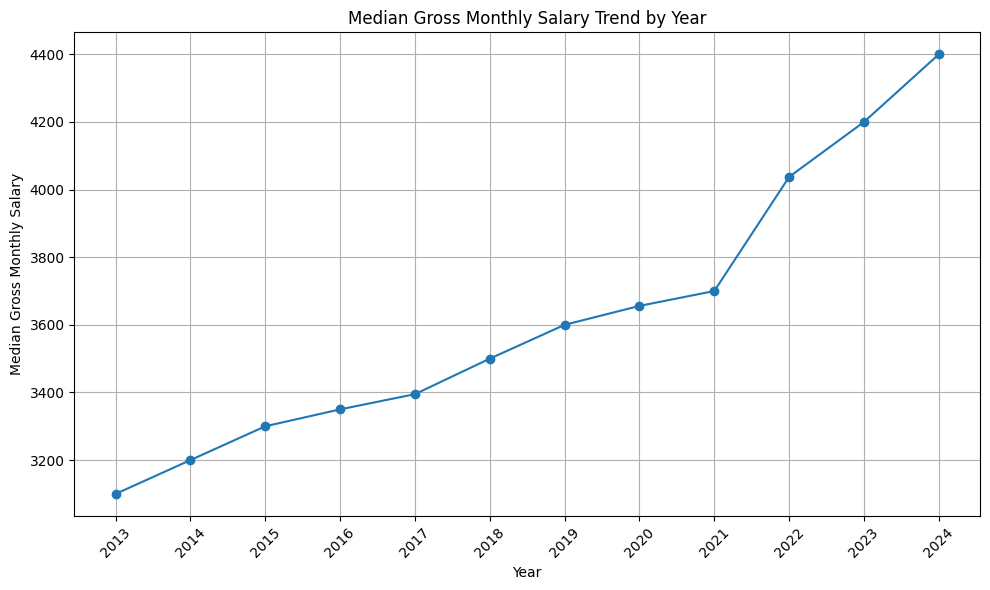

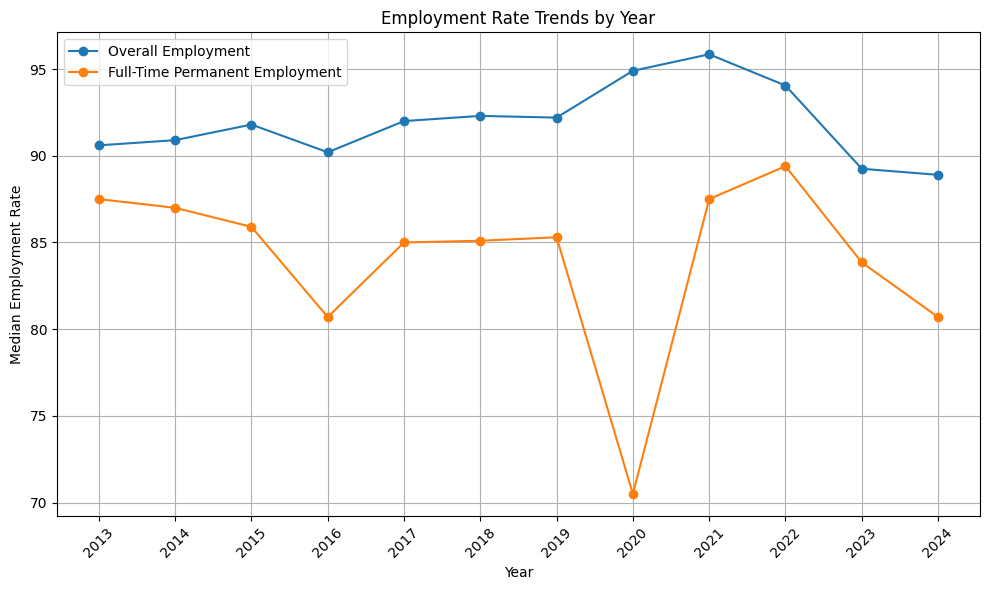

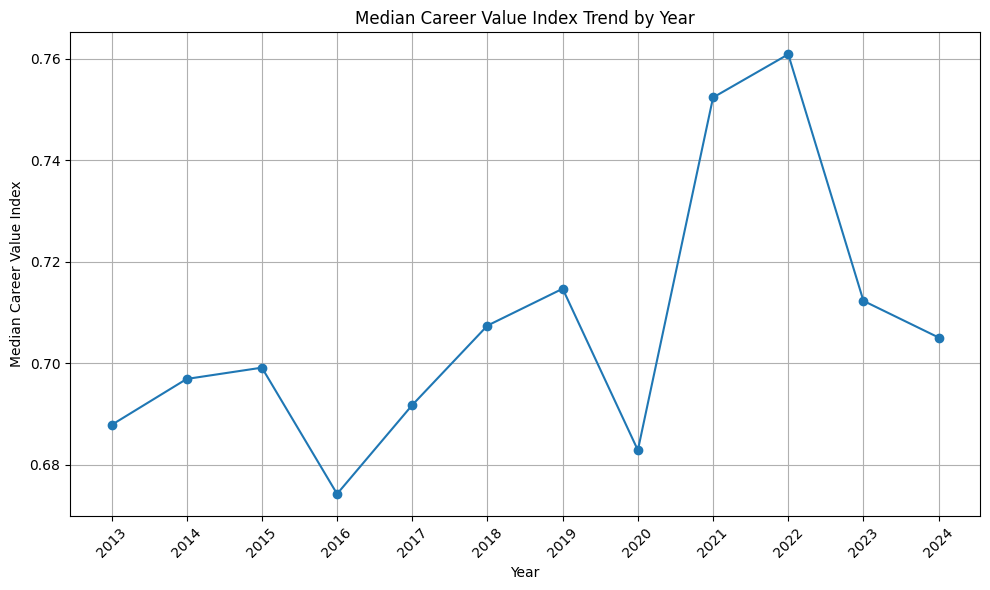

University-level outcome summary:


,university,record_count,complete_case_records,median_overall_employment,median_ft_perm_employment,median_gross_salary,median_salary_iqr,median_career_value_index,complete_case_percent
5,Singapore University of Technology and Design,37,32,92.20,87.05,"4,000.00",870.00,0.73,86.49
3,Singapore Management University,150,150,95.10,91.30,"4,000.00","1,200.00",0.76,100.00
1,National University of Singapore,478,433,92.60,86.40,"3,700.00",750.00,0.72,90.59
0,Nanyang Technological University,479,441,90.20,79.70,"3,500.00",700.00,0.67,92.07
2,Singapore Institute of Technology,355,342,92.60,84.50,"3,500.00",600.00,0.72,96.34
4,Singapore University of Social Sciences,51,47,91.10,80.90,"3,500.00",600.00,0.69,92.16


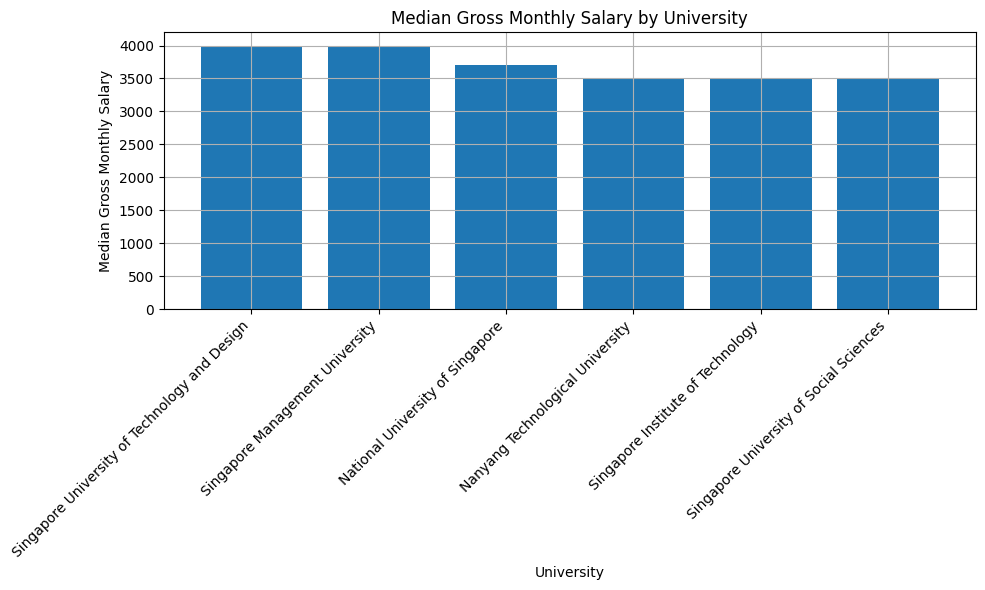

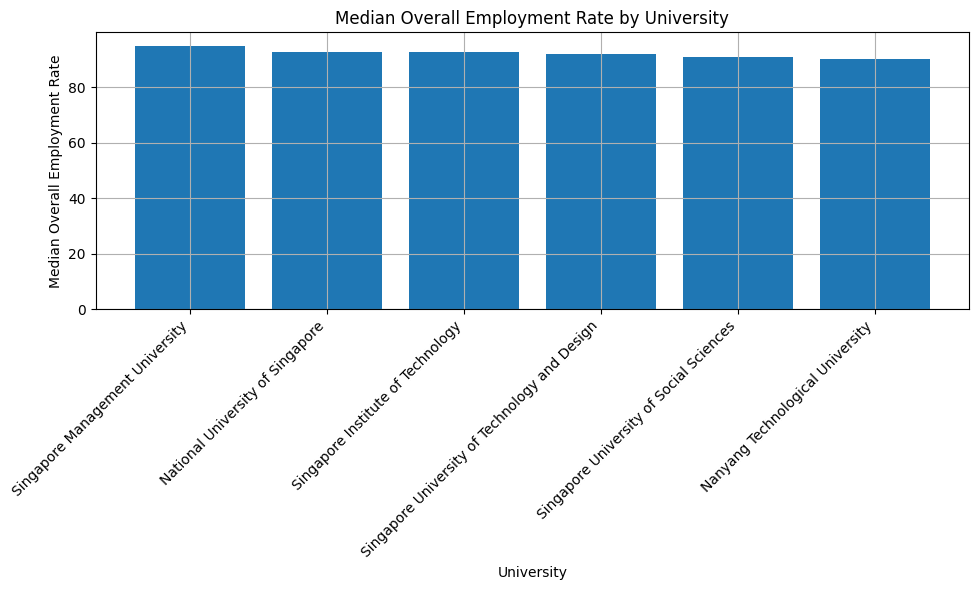

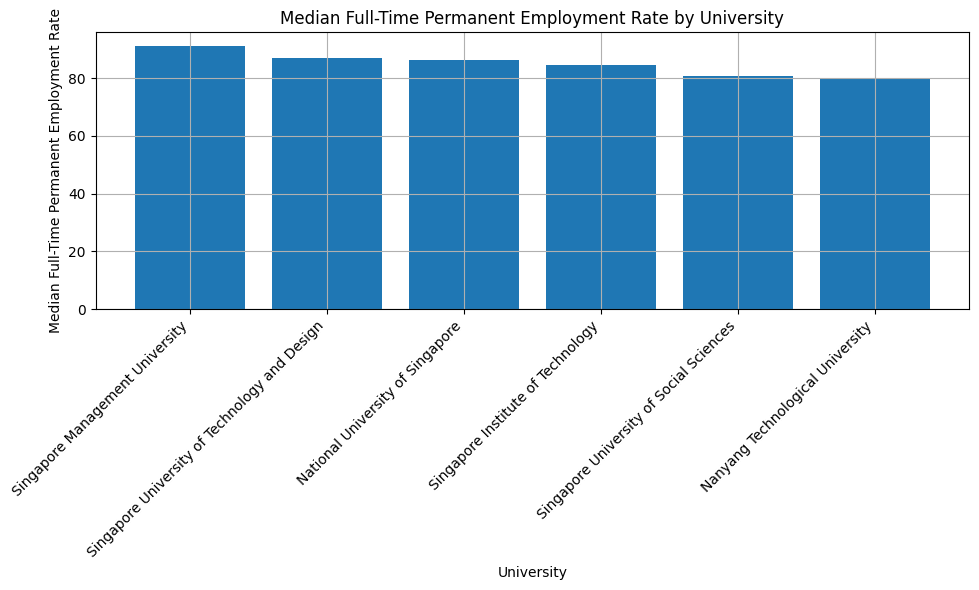

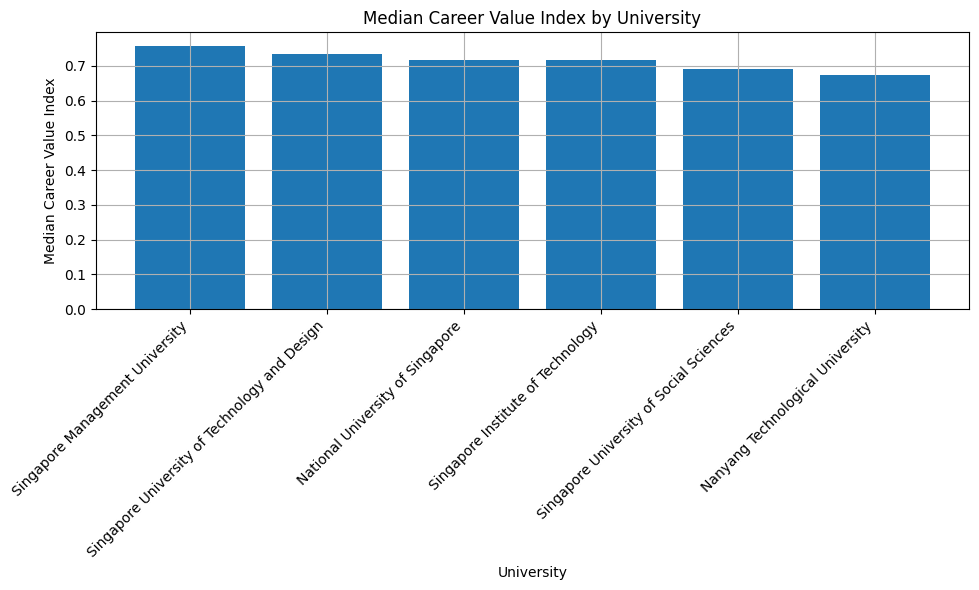

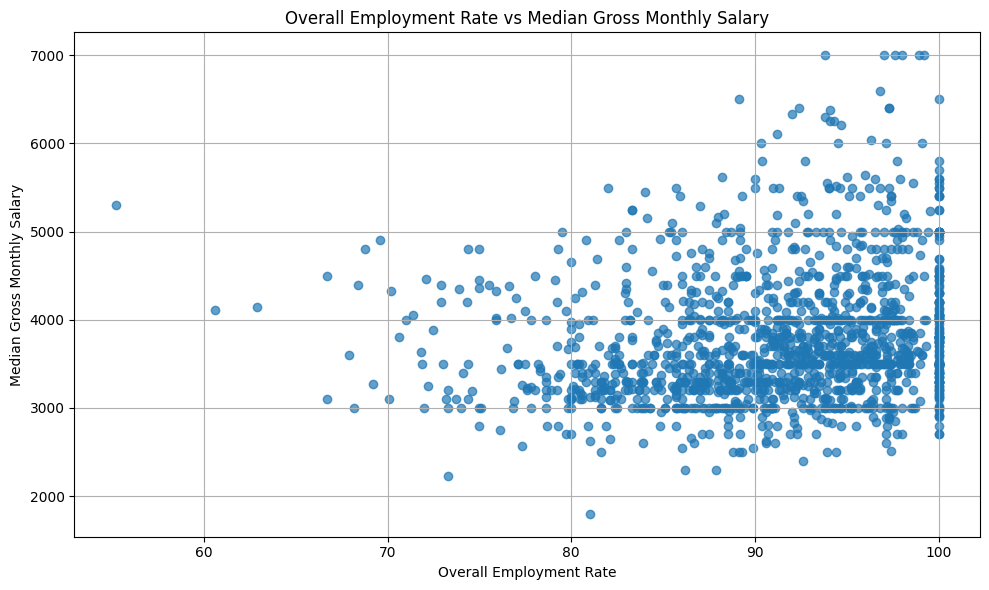

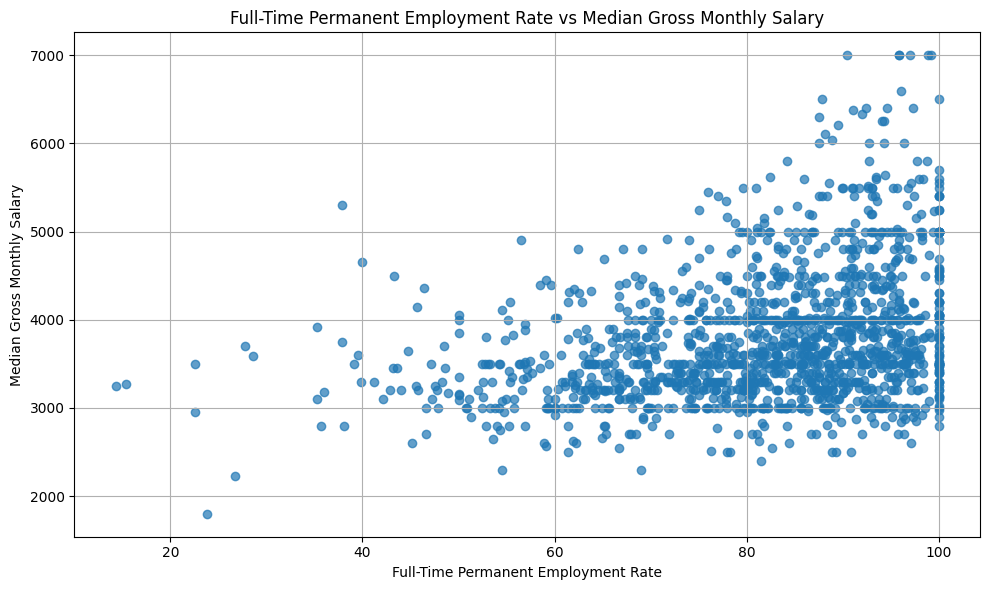

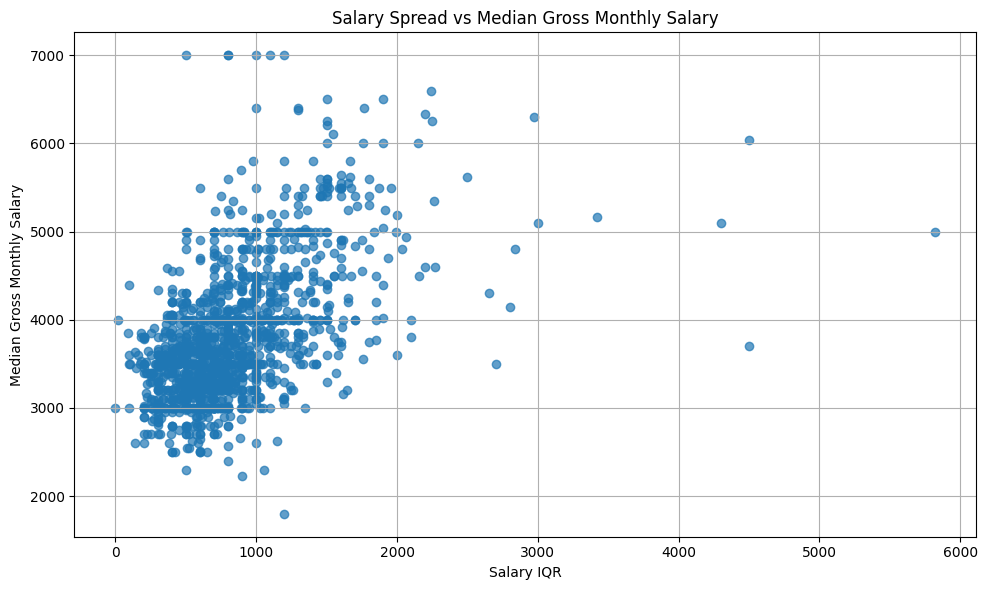

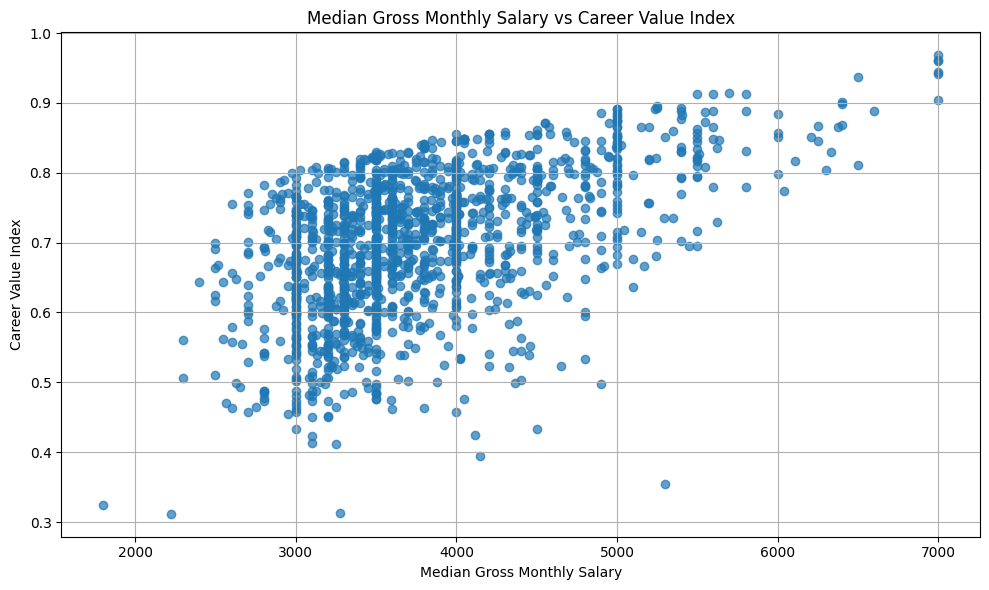

Bivariate correlation summary:


,employment_rate_overall,employment_rate_ft_perm,employment_premium,gross_monthly_median,salary_iqr,salary_premium,stability_score,career_value_index
employment_rate_overall,1.00,0.72,-0.32,0.18,0.03,0.07,-0.03,0.86
employment_rate_ft_perm,0.72,1.00,-0.89,0.31,0.06,0.07,-0.06,0.91
employment_premium,-0.32,-0.89,1.00,-0.31,-0.06,-0.05,0.06,-0.68
gross_monthly_median,0.18,0.31,-0.31,1.00,0.54,0.07,-0.54,0.52
salary_iqr,0.03,0.06,-0.06,0.54,1.00,0.61,-1.00,0.12
salary_premium,0.07,0.07,-0.05,0.07,0.61,1.00,-0.61,0.02
stability_score,-0.03,-0.06,0.06,-0.54,-1.00,-0.61,1.00,-0.12
career_value_index,0.86,0.91,-0.68,0.52,0.12,0.02,-0.12,1.00


EDA bivariate insight summary:


,Figure/Table Reference,What it Shows,Key Insight,Why it Matters,Decision / Next Step
0,Table: bivariate_year_trend_summary,"Year-level trends for employment, salary, sala...",Shows how graduate outcomes change over time,Supports RQ1 trend analysis,Use trend results to discuss changes from 2013...
1,Table: bivariate_university_outcome_summary,"Median employment, salary, and career-value ou...",Shows institutional variation in graduate outc...,Supports RQ2 group comparison,Use statistical testing to evaluate whether di...
2,Scatter plots,"Relationships between employment, salary, sala...",Shows whether variables move together or vary ...,Supports RQ3 driver analysis and feature selec...,Use correlation and regression to quantify rel...
3,Table: bivariate_correlation_summary,Pairwise numeric relationships among key varia...,Identifies early relationships among employmen...,"Supports feature selection for regression, cla...",Use stronger relationships as candidate predic...


Bivariate EDA completed.
------------------------------------------------------------
Saved tables:
- bivariate_year_trend_summary.csv
- bivariate_university_outcome_summary.csv
- bivariate_correlation_summary.csv
- eda_bivariate_insight_summary.csv
Saved figures:
- figure_07_01_salary_trend_by_year.png
- figure_07_02_employment_trend_by_year.png
- figure_07_03_career_value_trend_by_year.png
- figure_07_04_salary_by_university.png
- figure_07_05_overall_employment_by_university.png
- figure_07_06_ft_perm_employment_by_university.png
- figure_07_07_career_value_by_university.png
- figure_07_08_employment_vs_salary.png
- figure_07_09_ft_perm_vs_salary.png
- figure_07_10_salary_spread_vs_salary.png
- figure_07_11_salary_vs_career_value.png


In [10]:
# ============================================================
# Part 7: Bivariate Analysis — Trends and Group Comparisons
# ============================================================

# ------------------------------------------------------------
# Use the analysis dataset created earlier
# ------------------------------------------------------------

eda_df = df_analysis.copy()

# ------------------------------------------------------------
# 7.1 Year-level trend summary
# ------------------------------------------------------------

year_trend_summary = (
    eda_df
    .groupby("year")
    .agg(
        record_count=("year", "size"),
        median_overall_employment=("employment_rate_overall", "median"),
        median_ft_perm_employment=("employment_rate_ft_perm", "median"),
        median_gross_salary=("gross_monthly_median", "median"),
        median_salary_iqr=("salary_iqr", "median"),
        median_career_value_index=("career_value_index", "median")
    )
    .reset_index()
    .sort_values("year")
)

year_trend_summary.to_csv(TABLE_DIR / "bivariate_year_trend_summary.csv", index=False)

print("Year-level trend summary:")
display(year_trend_summary)

# ------------------------------------------------------------
# 7.2 Salary trend over time
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(
    year_trend_summary["year"],
    year_trend_summary["median_gross_salary"],
    marker="o"
)
plt.title("Median Gross Monthly Salary Trend by Year")
plt.xlabel("Year")
plt.ylabel("Median Gross Monthly Salary")
plt.xticks(year_trend_summary["year"], rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_01_salary_trend_by_year.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.3 Employment trend over time
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(
    year_trend_summary["year"],
    year_trend_summary["median_overall_employment"],
    marker="o",
    label="Overall Employment"
)
plt.plot(
    year_trend_summary["year"],
    year_trend_summary["median_ft_perm_employment"],
    marker="o",
    label="Full-Time Permanent Employment"
)
plt.title("Employment Rate Trends by Year")
plt.xlabel("Year")
plt.ylabel("Median Employment Rate")
plt.xticks(year_trend_summary["year"], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_02_employment_trend_by_year.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.4 Career value trend over time
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(
    year_trend_summary["year"],
    year_trend_summary["median_career_value_index"],
    marker="o"
)
plt.title("Median Career Value Index Trend by Year")
plt.xlabel("Year")
plt.ylabel("Median Career Value Index")
plt.xticks(year_trend_summary["year"], rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_03_career_value_trend_by_year.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.5 University-level outcome summary
# ------------------------------------------------------------

university_outcome_summary = (
    eda_df
    .groupby("university")
    .agg(
        record_count=("university", "size"),
        complete_case_records=("analysis_complete_case", "sum"),
        median_overall_employment=("employment_rate_overall", "median"),
        median_ft_perm_employment=("employment_rate_ft_perm", "median"),
        median_gross_salary=("gross_monthly_median", "median"),
        median_salary_iqr=("salary_iqr", "median"),
        median_career_value_index=("career_value_index", "median")
    )
    .reset_index()
)

university_outcome_summary["complete_case_percent"] = (
    university_outcome_summary["complete_case_records"] /
    university_outcome_summary["record_count"] * 100
).round(2)

university_outcome_summary = university_outcome_summary.sort_values(
    "median_gross_salary",
    ascending=False
)

university_outcome_summary.to_csv(
    TABLE_DIR / "bivariate_university_outcome_summary.csv",
    index=False
)

print("University-level outcome summary:")
display(university_outcome_summary)

# ------------------------------------------------------------
# 7.6 Median salary by university
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))
plt.bar(
    university_outcome_summary["university"],
    university_outcome_summary["median_gross_salary"]
)
plt.title("Median Gross Monthly Salary by University")
plt.xlabel("University")
plt.ylabel("Median Gross Monthly Salary")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_04_salary_by_university.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.7 Overall employment by university
# ------------------------------------------------------------

employment_by_university = university_outcome_summary.sort_values(
    "median_overall_employment",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.bar(
    employment_by_university["university"],
    employment_by_university["median_overall_employment"]
)
plt.title("Median Overall Employment Rate by University")
plt.xlabel("University")
plt.ylabel("Median Overall Employment Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_05_overall_employment_by_university.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.8 Full-time permanent employment by university
# ------------------------------------------------------------

ft_perm_by_university = university_outcome_summary.sort_values(
    "median_ft_perm_employment",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.bar(
    ft_perm_by_university["university"],
    ft_perm_by_university["median_ft_perm_employment"]
)
plt.title("Median Full-Time Permanent Employment Rate by University")
plt.xlabel("University")
plt.ylabel("Median Full-Time Permanent Employment Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_06_ft_perm_employment_by_university.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.9 Career Value Index by university
# ------------------------------------------------------------

career_value_by_university = university_outcome_summary.sort_values(
    "median_career_value_index",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.bar(
    career_value_by_university["university"],
    career_value_by_university["median_career_value_index"]
)
plt.title("Median Career Value Index by University")
plt.xlabel("University")
plt.ylabel("Median Career Value Index")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_07_career_value_by_university.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.10 Scatter: overall employment vs median salary
# ------------------------------------------------------------

scatter_df_1 = eda_df[
    ["employment_rate_overall", "gross_monthly_median"]
].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_df_1["employment_rate_overall"],
    scatter_df_1["gross_monthly_median"],
    alpha=0.7
)
plt.title("Overall Employment Rate vs Median Gross Monthly Salary")
plt.xlabel("Overall Employment Rate")
plt.ylabel("Median Gross Monthly Salary")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_08_employment_vs_salary.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.11 Scatter: full-time permanent employment vs median salary
# ------------------------------------------------------------

scatter_df_2 = eda_df[
    ["employment_rate_ft_perm", "gross_monthly_median"]
].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_df_2["employment_rate_ft_perm"],
    scatter_df_2["gross_monthly_median"],
    alpha=0.7
)
plt.title("Full-Time Permanent Employment Rate vs Median Gross Monthly Salary")
plt.xlabel("Full-Time Permanent Employment Rate")
plt.ylabel("Median Gross Monthly Salary")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_09_ft_perm_vs_salary.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.12 Scatter: salary spread vs median salary
# ------------------------------------------------------------

scatter_df_3 = eda_df[
    ["salary_iqr", "gross_monthly_median"]
].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_df_3["salary_iqr"],
    scatter_df_3["gross_monthly_median"],
    alpha=0.7
)
plt.title("Salary Spread vs Median Gross Monthly Salary")
plt.xlabel("Salary IQR")
plt.ylabel("Median Gross Monthly Salary")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_10_salary_spread_vs_salary.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.13 Scatter: median salary vs career value index
# ------------------------------------------------------------

scatter_df_4 = eda_df[
    ["gross_monthly_median", "career_value_index"]
].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_df_4["gross_monthly_median"],
    scatter_df_4["career_value_index"],
    alpha=0.7
)
plt.title("Median Gross Monthly Salary vs Career Value Index")
plt.xlabel("Median Gross Monthly Salary")
plt.ylabel("Career Value Index")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_07_11_salary_vs_career_value.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 7.14 Pairwise correlation summary for bivariate variables
# ------------------------------------------------------------

bivariate_numeric_vars = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "employment_premium",
    "gross_monthly_median",
    "salary_iqr",
    "salary_premium",
    "stability_score",
    "career_value_index"
]

bivariate_numeric_vars = [
    var for var in bivariate_numeric_vars
    if var in eda_df.columns
]

bivariate_correlation = eda_df[bivariate_numeric_vars].corr()

bivariate_correlation.to_csv(
    TABLE_DIR / "bivariate_correlation_summary.csv"
)

print("Bivariate correlation summary:")
display(bivariate_correlation)

# ------------------------------------------------------------
# 7.15 Report-ready bivariate insight summary
# ------------------------------------------------------------

eda_bivariate_insight_summary = pd.DataFrame([
    {
        "Figure/Table Reference": "Table: bivariate_year_trend_summary",
        "What it Shows": "Year-level trends for employment, salary, salary spread, and career value",
        "Key Insight": "Shows how graduate outcomes change over time",
        "Why it Matters": "Supports RQ1 trend analysis",
        "Decision / Next Step": "Use trend results to discuss changes from 2013 to 2024"
    },
    {
        "Figure/Table Reference": "Table: bivariate_university_outcome_summary",
        "What it Shows": "Median employment, salary, and career-value outcomes by university",
        "Key Insight": "Shows institutional variation in graduate outcomes",
        "Why it Matters": "Supports RQ2 group comparison",
        "Decision / Next Step": "Use statistical testing to evaluate whether differences are significant"
    },
    {
        "Figure/Table Reference": "Scatter plots",
        "What it Shows": "Relationships between employment, salary, salary spread, and career value",
        "Key Insight": "Shows whether variables move together or vary independently",
        "Why it Matters": "Supports RQ3 driver analysis and feature selection",
        "Decision / Next Step": "Use correlation and regression to quantify relationships"
    },
    {
        "Figure/Table Reference": "Table: bivariate_correlation_summary",
        "What it Shows": "Pairwise numeric relationships among key variables",
        "Key Insight": "Identifies early relationships among employment, salary, and career-value indicators",
        "Why it Matters": "Supports feature selection for regression, classification, and clustering",
        "Decision / Next Step": "Use stronger relationships as candidate predictors in modelling"
    }
])

eda_bivariate_insight_summary.to_csv(
    TABLE_DIR / "eda_bivariate_insight_summary.csv",
    index=False
)

print("EDA bivariate insight summary:")
display(eda_bivariate_insight_summary)

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------

print("Bivariate EDA completed.")
print("-" * 60)
print("Saved tables:")
print("- bivariate_year_trend_summary.csv")
print("- bivariate_university_outcome_summary.csv")
print("- bivariate_correlation_summary.csv")
print("- eda_bivariate_insight_summary.csv")

print("Saved figures:")
print("- figure_07_01_salary_trend_by_year.png")
print("- figure_07_02_employment_trend_by_year.png")
print("- figure_07_03_career_value_trend_by_year.png")
print("- figure_07_04_salary_by_university.png")
print("- figure_07_05_overall_employment_by_university.png")
print("- figure_07_06_ft_perm_employment_by_university.png")
print("- figure_07_07_career_value_by_university.png")
print("- figure_07_08_employment_vs_salary.png")
print("- figure_07_09_ft_perm_vs_salary.png")
print("- figure_07_10_salary_spread_vs_salary.png")
print("- figure_07_11_salary_vs_career_value.png")

## Part 7 Interpretation

Key observations from bivariate trend and group-comparison analysis:

#### Year-level trend observations

- The year-level trend analysis covers **2013 to 2024**.

- Median gross monthly salary increased steadily over the study period:

  - **2013:** 3,100
  - **2024:** 4,400

- This shows a clear upward trend in program-level salary outcomes across the dataset.

- Median overall employment stayed relatively high across most years.

- Overall employment reached its highest median level in:

  - **2021:** 95.85%

- Overall employment declined in the most recent years:

  - **2023:** 89.25%
  - **2024:** 88.90%

- Full-time permanent employment showed more variation than overall employment.

- The sharpest decline in full-time permanent employment occurred in:

  - **2020:** 70.50%

- This 2020 decline is an important observation because it suggests a temporary disruption in stable employment outcomes.

- Full-time permanent employment recovered after 2020:

  - **2021:** 87.50%
  - **2022:** 89.40%

- Median salary continued to increase even when employment indicators declined in 2023 and 2024.

- This suggests that salary outcomes and employment outcomes do not always move in the same direction.

- Median salary spread, measured using `salary_iqr`, increased over time:

  - **2013:** 600
  - **2024:** 900

- This indicates that salary dispersion has widened over the study period.

- Median career value index peaked in:

  - **2022:** 0.76

- The career value index declined after 2022:

  - **2023:** 0.71
  - **2024:** 0.71

- This decline appears to be influenced by lower employment indicators despite higher salary outcomes.

#### University-level comparison observations

- Median gross salary differs across universities.

- The highest median gross salary values are observed for:

  - **Singapore University of Technology and Design:** 4,000
  - **Singapore Management University:** 4,000

- Singapore Management University also shows the highest median career value index:

  - **0.76**

- Singapore Management University has complete-case coverage of:

  - **100.00%**

- This makes its university-level summary more complete compared with universities that have missing outcome values.

- Singapore University of Technology and Design has a high median salary but a small sample size:

  - **37 total records**
  - **32 complete-case records**
  - **86.49% complete-case coverage**

- Therefore, SUTD results should be interpreted carefully because the record count is smaller than other universities.

- National University of Singapore has:

  - Median gross salary: **3,700**
  - Median career value index: **0.72**

- Nanyang Technological University and Singapore Institute of Technology both have median gross salary of:

  - **3,500**

- Nanyang Technological University has the lowest median career value index among the listed universities:

  - **0.67**

- University-level results show useful differences, but statistical testing is needed before concluding whether these differences are significant.

#### Correlation observations

- `career_value_index` has strong positive correlation with:

  - `employment_rate_ft_perm`: **0.91**
  - `employment_rate_overall`: **0.86**
  - `gross_monthly_median`: **0.52**

- This is expected because the career value index was constructed using employment, full-time permanent employment, salary, and stability components.

- Full-time permanent employment has a stronger relationship with career value than salary does.

- This suggests that stable employment is a major contributor to the composite career-value outcome.

- `employment_rate_overall` and `employment_rate_ft_perm` are positively correlated:

  - **0.72**

- This means programs with higher overall employment often also have higher full-time permanent employment, although the relationship is not perfect.

- `employment_premium` has a strong negative correlation with:

  - `employment_rate_ft_perm`: **-0.89**
  - `career_value_index`: **-0.68**

- This indicates that a larger gap between overall employment and full-time permanent employment is generally associated with weaker stable employment and lower career value.

- `gross_monthly_median` has moderate positive correlation with:

  - `salary_iqr`: **0.54**
  - `career_value_index`: **0.52**

- This suggests that higher-salary programs may also have wider salary spread.

- `salary_iqr` and `stability_score` have a correlation of:

  - **-1.00**

- This is expected because `stability_score` was directly derived from salary spread.

- Because of this direct mathematical relationship, both variables should not be used together in the same regression or machine learning model without caution.

- `salary_iqr` and `salary_premium` have a positive correlation of:

  - **0.61**

- This suggests that programs with wider salary spread may also show greater difference between mean and median salary.

#### Modelling implication

- The bivariate analysis suggests that the following variables are useful candidates for later modelling:

  - `employment_rate_overall`
  - `employment_rate_ft_perm`
  - `gross_monthly_median`
  - `salary_iqr`
  - `salary_premium`
  - `employment_premium`
  - `career_value_index`

- However, variables that are directly derived from each other should be handled carefully to avoid redundancy or multicollinearity.

- In particular, `salary_iqr` and `stability_score` should not be interpreted as independent predictors of each other.

#### Interim report implication

- The trend analysis supports **RQ1** by showing changes in salary, employment, salary spread, and career value from 2013 to 2024.

- The university comparison supports **RQ2** by showing visible differences in median salary, employment, and career value across universities.

- The correlation results support **RQ3** by identifying early relationships among employment, salary, salary spread, and career value.

- These results are exploratory and should not be interpreted as causal.

- Formal statistical testing and regression modelling are needed in the next phase.

Evidence generated for the interim report:

- `bivariate_year_trend_summary.csv`
- `bivariate_university_outcome_summary.csv`
- `bivariate_correlation_summary.csv`
- `eda_bivariate_insight_summary.csv`
- `figure_07_01_salary_trend_by_year.png`
- `figure_07_02_employment_trend_by_year.png`
- `figure_07_03_career_value_trend_by_year.png`
- `figure_07_04_salary_by_university.png`
- `figure_07_05_overall_employment_by_university.png`
- `figure_07_06_ft_perm_employment_by_university.png`
- `figure_07_07_career_value_by_university.png`
- `figure_07_08_employment_vs_salary.png`
- `figure_07_09_ft_perm_vs_salary.png`
- `figure_07_10_salary_spread_vs_salary.png`
- `figure_07_11_salary_vs_career_value.png`

Next action:

- Proceed to multivariate and correlation analysis to examine combined relationships among employment, salary, stability, and career-value indicators.

Multivariate correlation matrix:


,employment_rate_overall,employment_rate_ft_perm,employment_premium,gross_monthly_mean,gross_monthly_median,gross_mthly_25_percentile,gross_mthly_75_percentile,salary_iqr,salary_premium,stability_score,career_value_index
employment_rate_overall,1.00,0.72,-0.32,0.19,0.18,0.21,0.16,0.03,0.07,-0.03,0.86
employment_rate_ft_perm,0.72,1.00,-0.89,0.32,0.31,0.36,0.28,0.06,0.07,-0.06,0.91
employment_premium,-0.32,-0.89,1.00,-0.30,-0.31,-0.35,-0.27,-0.06,-0.05,0.06,-0.68
gross_monthly_mean,0.19,0.32,-0.30,1.00,0.96,0.93,0.98,0.67,0.34,-0.67,0.50
gross_monthly_median,0.18,0.31,-0.31,0.96,1.00,0.97,0.94,0.54,0.07,-0.54,0.52
gross_mthly_25_percentile,0.21,0.36,-0.35,0.93,0.97,1.00,0.89,0.39,0.06,-0.39,0.56
gross_mthly_75_percentile,0.16,0.28,-0.27,0.98,0.94,0.89,1.00,0.78,0.35,-0.78,0.44
salary_iqr,0.03,0.06,-0.06,0.67,0.54,0.39,0.78,1.00,0.61,-1.00,0.12
salary_premium,0.07,0.07,-0.05,0.34,0.07,0.06,0.35,0.61,1.00,-0.61,0.02
stability_score,-0.03,-0.06,0.06,-0.67,-0.54,-0.39,-0.78,-1.00,-0.61,1.00,-0.12


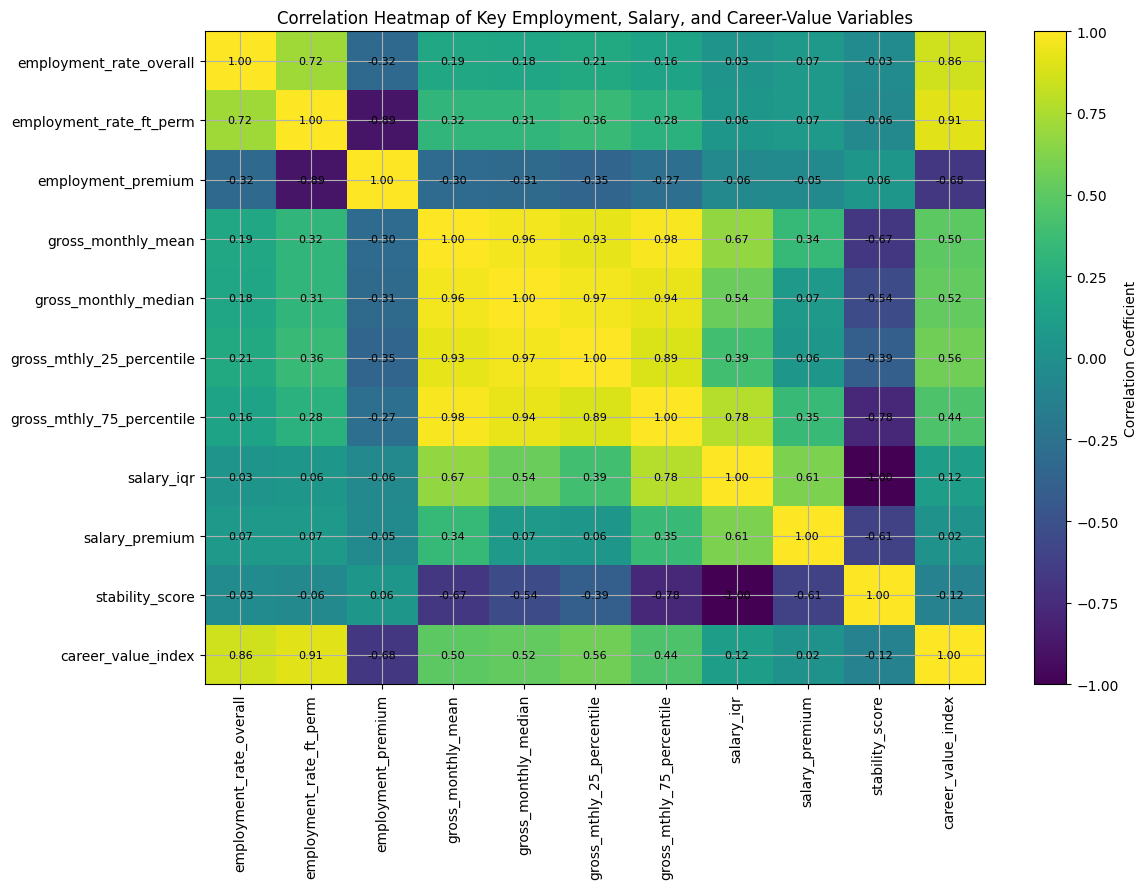

Target-focused correlation summary:


,Target Variable,Variable,Correlation,Absolute Correlation
0,gross_monthly_median,gross_mthly_25_percentile,0.97,0.97
1,gross_monthly_median,gross_monthly_mean,0.96,0.96
2,gross_monthly_median,gross_mthly_75_percentile,0.94,0.94
3,gross_monthly_median,salary_iqr,0.54,0.54
4,gross_monthly_median,stability_score,-0.54,0.54
5,gross_monthly_median,career_value_index,0.52,0.52
6,gross_monthly_median,employment_rate_ft_perm,0.31,0.31
7,gross_monthly_median,employment_premium,-0.31,0.31
8,gross_monthly_median,employment_rate_overall,0.18,0.18
9,gross_monthly_median,salary_premium,0.07,0.07


Strong correlation pairs with absolute correlation >= 0.60:


,Variable 1,Variable 2,Correlation,Absolute Correlation
16,salary_iqr,stability_score,-1.00,1.00
7,gross_monthly_mean,gross_mthly_75_percentile,0.98,0.98
10,gross_monthly_median,gross_mthly_25_percentile,0.97,0.97
5,gross_monthly_mean,gross_monthly_median,0.96,0.96
11,gross_monthly_median,gross_mthly_75_percentile,0.94,0.94
6,gross_monthly_mean,gross_mthly_25_percentile,0.93,0.93
3,employment_rate_ft_perm,career_value_index,0.91,0.91
2,employment_rate_ft_perm,employment_premium,-0.89,0.89
12,gross_mthly_25_percentile,gross_mthly_75_percentile,0.89,0.89
1,employment_rate_overall,career_value_index,0.86,0.86


University-level multivariate profile:


,university,employment_rate_overall,employment_rate_ft_perm,employment_premium,gross_monthly_median,salary_iqr,stability_score,career_value_index
0,Nanyang Technological University,90.20,79.70,7.80,"3,500.00",700.00,0.88,0.67
1,National University of Singapore,92.60,86.40,4.70,"3,700.00",750.00,0.87,0.72
2,Singapore Institute of Technology,92.60,84.50,7.20,"3,500.00",600.00,0.90,0.72
3,Singapore Management University,95.10,91.30,3.90,"4,000.00","1,200.00",0.79,0.76
4,Singapore University of Social Sciences,91.10,80.90,10.00,"3,500.00",600.00,0.90,0.69
5,Singapore University of Technology and Design,92.20,87.05,4.40,"4,000.00",870.00,0.85,0.73


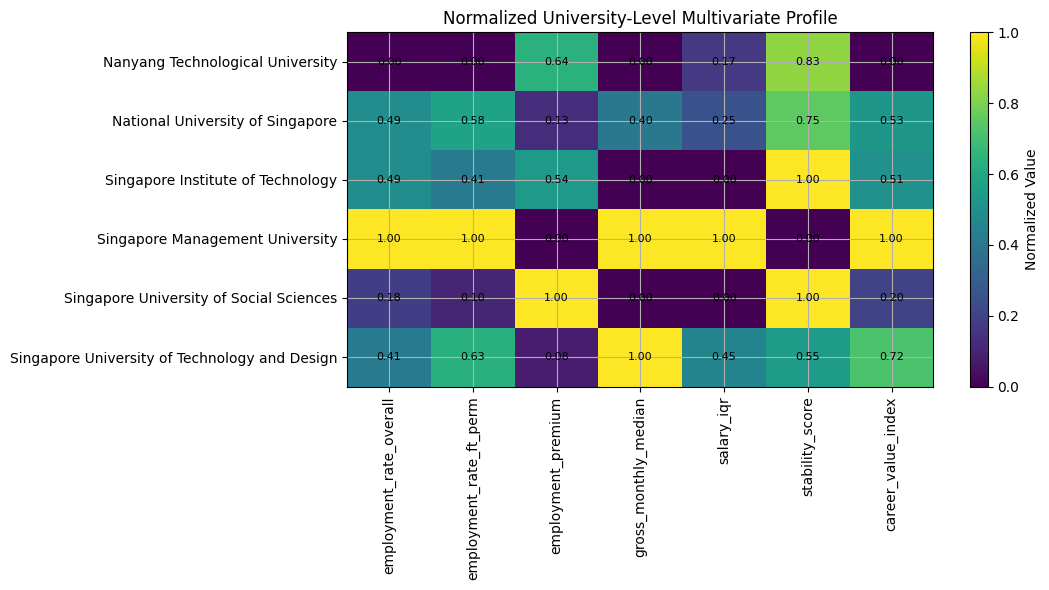

Preliminary VIF summary:


,Variable,VIF,Note
0,employment_rate_overall,NaN,VIF calculation could not be completed: No mod...
1,employment_rate_ft_perm,NaN,VIF calculation could not be completed: No mod...
2,employment_premium,NaN,VIF calculation could not be completed: No mod...
3,gross_monthly_median,NaN,VIF calculation could not be completed: No mod...
4,salary_iqr,NaN,VIF calculation could not be completed: No mod...
5,salary_premium,NaN,VIF calculation could not be completed: No mod...
6,stability_score,NaN,VIF calculation could not be completed: No mod...


EDA multivariate insight summary:


,Figure/Table Reference,What it Shows,Key Insight,Why it Matters,Decision / Next Step
0,Table: multivariate_correlation_matrix,"Correlation structure among key employment, sa...",Identifies relationships and possible redundan...,Supports RQ3 driver analysis and model feature...,"Use correlation results to guide regression, c..."
1,Table: target_correlation_summary,Variables most associated with selected target...,Shows which variables are most related to sala...,Supports predictor selection for RQ3 and RQ4,Use strongest non-redundant variables in model...
2,Table: strong_correlation_pairs,Highly correlated variable pairs,Highlights variables that may duplicate inform...,Reduces risk of multicollinearity in regressio...,Avoid using directly derived variables togethe...
3,Figure: university_profile_heatmap,Normalized university-level profile across mul...,Shows institutional patterns across employment...,Supports RQ2 and helps prepare for segmentation,Use university-level patterns as context for s...
4,Table: preliminary_vif_summary,Preliminary multicollinearity check among cand...,Identifies variables that may be too closely r...,Supports reliable regression modelling,Refine regression feature set before formal mo...


Multivariate and correlation analysis completed.
------------------------------------------------------------
Saved tables:
- multivariate_correlation_matrix.csv
- target_correlation_summary.csv
- strong_correlation_pairs.csv
- university_multivariate_profile.csv
- university_multivariate_profile_normalized.csv
- preliminary_vif_summary.csv
- eda_multivariate_insight_summary.csv
Saved figures:
- figure_08_01_correlation_heatmap.png
- figure_08_02_university_profile_heatmap.png


In [11]:
# ============================================================
# Part 8: Multivariate and Correlation Analysis
# ============================================================

# ------------------------------------------------------------
# Use the analysis dataset created earlier
# ------------------------------------------------------------

eda_df = df_analysis.copy()

# ------------------------------------------------------------
# 8.1 Select key numeric variables
# ------------------------------------------------------------

multivariate_vars = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "employment_premium",
    "gross_monthly_mean",
    "gross_monthly_median",
    "gross_mthly_25_percentile",
    "gross_mthly_75_percentile",
    "salary_iqr",
    "salary_premium",
    "stability_score",
    "career_value_index"
]

multivariate_vars = [
    var for var in multivariate_vars
    if var in eda_df.columns
]

multi_df = eda_df[multivariate_vars].copy()

# ------------------------------------------------------------
# 8.2 Correlation matrix
# ------------------------------------------------------------

correlation_matrix = multi_df.corr()

correlation_matrix.to_csv(TABLE_DIR / "multivariate_correlation_matrix.csv")

print("Multivariate correlation matrix:")
display(correlation_matrix)

# ------------------------------------------------------------
# 8.3 Correlation heatmap using matplotlib
# ------------------------------------------------------------

plt.figure(figsize=(12, 9))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation Coefficient")
plt.xticks(
    ticks=np.arange(len(correlation_matrix.columns)),
    labels=correlation_matrix.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(correlation_matrix.index)),
    labels=correlation_matrix.index
)

# Add correlation values inside cells
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap of Key Employment, Salary, and Career-Value Variables")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_08_01_correlation_heatmap.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 8.4 Target-focused correlation summaries
# ------------------------------------------------------------

target_variables = [
    "gross_monthly_median",
    "career_value_index",
    "employment_rate_overall",
    "employment_rate_ft_perm"
]

target_correlation_rows = []

for target in target_variables:
    if target in correlation_matrix.columns:
        target_corr = (
            correlation_matrix[target]
            .drop(labels=[target])
            .dropna()
            .reset_index()
        )
        
        target_corr.columns = ["Variable", "Correlation"]
        target_corr["Target Variable"] = target
        target_corr["Absolute Correlation"] = target_corr["Correlation"].abs()
        target_corr = target_corr.sort_values(
            "Absolute Correlation",
            ascending=False
        )
        
        target_correlation_rows.append(target_corr)

target_correlation_summary = pd.concat(
    target_correlation_rows,
    ignore_index=True
)

target_correlation_summary = target_correlation_summary[
    [
        "Target Variable",
        "Variable",
        "Correlation",
        "Absolute Correlation"
    ]
]

target_correlation_summary.to_csv(
    TABLE_DIR / "target_correlation_summary.csv",
    index=False
)

print("Target-focused correlation summary:")
display(target_correlation_summary)

# ------------------------------------------------------------
# 8.5 Strong correlation pairs
# ------------------------------------------------------------

strong_corr_rows = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        var_1 = correlation_matrix.columns[i]
        var_2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        
        if abs(corr_value) >= 0.60:
            strong_corr_rows.append({
                "Variable 1": var_1,
                "Variable 2": var_2,
                "Correlation": corr_value,
                "Absolute Correlation": abs(corr_value)
            })

strong_correlation_pairs = (
    pd.DataFrame(strong_corr_rows)
    .sort_values("Absolute Correlation", ascending=False)
)

strong_correlation_pairs.to_csv(
    TABLE_DIR / "strong_correlation_pairs.csv",
    index=False
)

print("Strong correlation pairs with absolute correlation >= 0.60:")
display(strong_correlation_pairs)

# ------------------------------------------------------------
# 8.6 University-level multivariate profile
# ------------------------------------------------------------

university_profile_vars = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "employment_premium",
    "gross_monthly_median",
    "salary_iqr",
    "stability_score",
    "career_value_index"
]

university_profile_vars = [
    var for var in university_profile_vars
    if var in eda_df.columns
]

university_multivariate_profile = (
    eda_df
    .groupby("university")[university_profile_vars]
    .median()
    .reset_index()
)

university_multivariate_profile.to_csv(
    TABLE_DIR / "university_multivariate_profile.csv",
    index=False
)

print("University-level multivariate profile:")
display(university_multivariate_profile)

# ------------------------------------------------------------
# 8.7 Normalized university profile heatmap
# ------------------------------------------------------------

university_profile_scaled = university_multivariate_profile.copy()

for var in university_profile_vars:
    min_value = university_profile_scaled[var].min()
    max_value = university_profile_scaled[var].max()
    
    if max_value != min_value:
        university_profile_scaled[var] = (
            (university_profile_scaled[var] - min_value) /
            (max_value - min_value)
        )
    else:
        university_profile_scaled[var] = 0

university_profile_scaled.to_csv(
    TABLE_DIR / "university_multivariate_profile_normalized.csv",
    index=False
)

profile_matrix = university_profile_scaled.set_index("university")

plt.figure(figsize=(11, 6))
plt.imshow(profile_matrix, aspect="auto")
plt.colorbar(label="Normalized Value")
plt.xticks(
    ticks=np.arange(len(profile_matrix.columns)),
    labels=profile_matrix.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(profile_matrix.index)),
    labels=profile_matrix.index
)

for i in range(len(profile_matrix.index)):
    for j in range(len(profile_matrix.columns)):
        value = profile_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.title("Normalized University-Level Multivariate Profile")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_08_02_university_profile_heatmap.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 8.8 Preliminary multicollinearity check using VIF
# ------------------------------------------------------------

candidate_model_vars = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "employment_premium",
    "gross_monthly_median",
    "salary_iqr",
    "salary_premium",
    "stability_score"
]

candidate_model_vars = [
    var for var in candidate_model_vars
    if var in eda_df.columns
]

vif_df_input = eda_df[candidate_model_vars].dropna().copy()

vif_results = []

try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    
    # Keep only columns with variation
    vif_df_input = vif_df_input.loc[:, vif_df_input.std() > 0]
    
    X_vif = vif_df_input.values
    
    for i, var in enumerate(vif_df_input.columns):
        vif_value = variance_inflation_factor(X_vif, i)
        vif_results.append({
            "Variable": var,
            "VIF": vif_value
        })
    
    vif_summary = pd.DataFrame(vif_results).sort_values("VIF", ascending=False)
    
except Exception as error:
    vif_summary = pd.DataFrame({
        "Variable": candidate_model_vars,
        "VIF": np.nan,
        "Note": f"VIF calculation could not be completed: {error}"
    })

vif_summary.to_csv(TABLE_DIR / "preliminary_vif_summary.csv", index=False)

print("Preliminary VIF summary:")
display(vif_summary)

# ------------------------------------------------------------
# 8.9 Multivariate EDA insight summary
# ------------------------------------------------------------

eda_multivariate_insight_summary = pd.DataFrame([
    {
        "Figure/Table Reference": "Table: multivariate_correlation_matrix",
        "What it Shows": "Correlation structure among key employment, salary, stability, and career-value variables",
        "Key Insight": "Identifies relationships and possible redundancy among variables",
        "Why it Matters": "Supports RQ3 driver analysis and model feature selection",
        "Decision / Next Step": "Use correlation results to guide regression, classification, and clustering variables"
    },
    {
        "Figure/Table Reference": "Table: target_correlation_summary",
        "What it Shows": "Variables most associated with selected target outcomes",
        "Key Insight": "Shows which variables are most related to salary, employment, and career value",
        "Why it Matters": "Supports predictor selection for RQ3 and RQ4",
        "Decision / Next Step": "Use strongest non-redundant variables in modelling"
    },
    {
        "Figure/Table Reference": "Table: strong_correlation_pairs",
        "What it Shows": "Highly correlated variable pairs",
        "Key Insight": "Highlights variables that may duplicate information",
        "Why it Matters": "Reduces risk of multicollinearity in regression models",
        "Decision / Next Step": "Avoid using directly derived variables together without justification"
    },
    {
        "Figure/Table Reference": "Figure: university_profile_heatmap",
        "What it Shows": "Normalized university-level profile across multiple outcome dimensions",
        "Key Insight": "Shows institutional patterns across employment, salary, stability, and career value",
        "Why it Matters": "Supports RQ2 and helps prepare for segmentation",
        "Decision / Next Step": "Use university-level patterns as context for statistical testing and clustering"
    },
    {
        "Figure/Table Reference": "Table: preliminary_vif_summary",
        "What it Shows": "Preliminary multicollinearity check among candidate predictors",
        "Key Insight": "Identifies variables that may be too closely related for simultaneous regression use",
        "Why it Matters": "Supports reliable regression modelling",
        "Decision / Next Step": "Refine regression feature set before formal modelling"
    }
])

eda_multivariate_insight_summary.to_csv(
    TABLE_DIR / "eda_multivariate_insight_summary.csv",
    index=False
)

print("EDA multivariate insight summary:")
display(eda_multivariate_insight_summary)

# ------------------------------------------------------------
# Completion message
# ------------------------------------------------------------

print("Multivariate and correlation analysis completed.")
print("-" * 60)
print("Saved tables:")
print("- multivariate_correlation_matrix.csv")
print("- target_correlation_summary.csv")
print("- strong_correlation_pairs.csv")
print("- university_multivariate_profile.csv")
print("- university_multivariate_profile_normalized.csv")
print("- preliminary_vif_summary.csv")
print("- eda_multivariate_insight_summary.csv")

print("Saved figures:")
print("- figure_08_01_correlation_heatmap.png")
print("- figure_08_02_university_profile_heatmap.png")

## Part 8 Interpretation

Key observations from multivariate and correlation analysis:

#### Correlation structure

- The multivariate correlation analysis confirms that several employment, salary, stability, and career-value variables are strongly related.

- Salary-related variables are highly correlated with each other.

- `gross_monthly_median` has very strong positive correlation with:

  - `gross_mthly_25_percentile`: **0.97**
  - `gross_monthly_mean`: **0.96**
  - `gross_mthly_75_percentile`: **0.94**

- This is expected because these variables describe different points of the same salary distribution.

- Because of these strong correlations, not all salary variables should be used together in the same regression model.

- For modelling, `gross_monthly_median` can be used as the primary salary outcome because it is less affected by extreme values than mean salary.

#### Career Value Index relationships

- `career_value_index` has strong positive correlation with:

  - `employment_rate_ft_perm`: **0.91**
  - `employment_rate_overall`: **0.86**
  - `gross_monthly_median`: **0.52**

- This shows that the career-value index is strongly driven by employment outcomes, especially full-time permanent employment.

- The correlation with salary is moderate, not as strong as the employment-related correlations.

- This supports the project decision to treat graduate career value as a multidimensional measure, rather than as a salary-only measure.

- `employment_premium` has a negative correlation with `career_value_index`:

  - **-0.68**

- This indicates that programs with a larger gap between overall employment and full-time permanent employment tend to have lower career-value scores.

#### Employment-related relationships

- `employment_rate_overall` and `employment_rate_ft_perm` are positively correlated:

  - **0.72**

- This suggests that programs with high overall employment generally also show higher full-time permanent employment.

- However, the relationship is not perfect, confirming that overall employment and stable employment should be analyzed separately.

- `employment_rate_ft_perm` and `employment_premium` are strongly negatively correlated:

  - **-0.89**

- This is expected because `employment_premium` measures the gap between overall employment and full-time permanent employment.

- A higher employment premium usually indicates a weaker full-time permanent employment outcome.

#### Salary spread and stability

- `salary_iqr` and `stability_score` have a perfect negative correlation:

  - **-1.00**

- This is expected because `stability_score` was directly derived from `salary_iqr`.

- These two variables should not be used together as independent predictors in the same regression model.

- `salary_iqr` has moderate to strong positive correlation with:

  - `gross_mthly_75_percentile`: **0.78**
  - `gross_monthly_mean`: **0.67**
  - `salary_premium`: **0.61**
  - `gross_monthly_median`: **0.54**

- This suggests that higher salary programs may also have wider salary dispersion.

- The relationship between salary level and salary spread should be considered during interpretation because higher-paying programs may not always have equally stable salary outcomes.

#### University-level multivariate profile

- The university-level multivariate profile shows visible differences across institutions.

- Singapore Management University has the strongest median profile across several dimensions:

  - Overall employment: **95.10%**
  - Full-time permanent employment: **91.30%**
  - Median gross salary: **4,000**
  - Career value index: **0.76**

- Singapore University of Technology and Design also shows a high median gross salary:

  - Median gross salary: **4,000**
  - Career value index: **0.73**

- However, SUTD has a smaller number of records, so interpretation should remain cautious.

- National University of Singapore shows a balanced profile:

  - Overall employment: **92.60%**
  - Full-time permanent employment: **86.40%**
  - Median gross salary: **3,700**
  - Career value index: **0.72**

- Singapore Institute of Technology has:

  - Median gross salary: **3,500**
  - Career value index: **0.72**
  - Stability score: **0.90**

- Nanyang Technological University has the lowest median career value index among the universities:

  - Career value index: **0.67**

- Singapore University of Social Sciences has the highest employment premium:

  - Employment premium: **10.00 percentage points**

- This indicates a larger gap between overall employment and full-time permanent employment.

#### Strong correlation and modelling implication

- The strong-correlation table highlights several redundant variable groups.

- Salary variables are highly interrelated and should be handled carefully in regression.

- Directly engineered variables should not be used together with their source variables without justification.

- Important examples:

  - `salary_iqr` and `stability_score` are mathematically linked.
  - `employment_rate_overall`, `employment_rate_ft_perm`, and `employment_premium` are closely related.
  - Gross salary mean, median, and percentiles are highly correlated.

- For regression modelling, the feature set should be simplified to reduce multicollinearity.

- A suitable modelling approach is to use selected representative variables, such as:

  - `employment_rate_overall`
  - `employment_rate_ft_perm`
  - `gross_monthly_median`
  - `salary_iqr` or `stability_score`, but not both
  - `salary_premium`, if needed for salary-distribution interpretation

#### VIF note

- The preliminary VIF calculation did not complete in the current run.

- This appears to be an environment/package issue rather than a data issue.

- Since the correlation matrix already identifies strong redundancy, the EDA findings remain valid.

- VIF can be rerun later after confirming that `statsmodels` is installed.

#### Interim report implication

- The multivariate analysis supports **RQ3** by identifying relationships among salary, employment, stability, and career value.

- It also supports **RQ4** by identifying candidate variables for predictive modelling.

- It supports **RQ5** by showing that employment, salary, stability, and career value provide meaningful dimensions for clustering and segmentation.

- The results confirm that graduate outcomes should not be interpreted using salary alone.

- Employment stability, salary level, salary spread, and composite career value all provide different but connected perspectives.

Evidence generated for the interim report:

- `multivariate_correlation_matrix.csv`
- `target_correlation_summary.csv`
- `strong_correlation_pairs.csv`
- `university_multivariate_profile.csv`
- `university_multivariate_profile_normalized.csv`
- `preliminary_vif_summary.csv`
- `eda_multivariate_insight_summary.csv`
- `figure_08_01_correlation_heatmap.png`
- `figure_08_02_university_profile_heatmap.png`

Next action:

- Summarize the EDA findings by research question before moving to formal statistical testing and preliminary modelling.

In [12]:
# ============================================================
# Part 8A: Career Value Index Validation
# ============================================================

from scipy.stats import pearsonr, spearmanr
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 8A.1 Load cleaned dataset using Part 0 project paths
# ------------------------------------------------------------

df = pd.read_csv(CLEAN_DATA_FILE)

print("CVI validation dataset loaded successfully.")
print("Dataset shape:", df.shape)
print("Clean data file:", CLEAN_DATA_FILE)

# ------------------------------------------------------------
# 8A.2 Define target and validation features
# ------------------------------------------------------------

target = "career_value_index"

cvi_features = {
    "employment_rate_ft_perm": {
        "display_name": "Full-time permanent employment",
        "expected_relationship": "Positive",
        "interpretation_note": "Employment stability should increase CVI."
    },
    "employment_rate_overall": {
        "display_name": "Overall employment",
        "expected_relationship": "Positive",
        "interpretation_note": "General employability should increase CVI."
    },
    "gross_monthly_median": {
        "display_name": "Median gross monthly salary",
        "expected_relationship": "Positive",
        "interpretation_note": "Higher median salary should increase CVI."
    },
    "stability_score": {
        "display_name": "Salary stability score",
        "expected_relationship": "Positive",
        "interpretation_note": "Higher salary stability should increase CVI."
    },
    "salary_iqr": {
        "display_name": "Salary IQR",
        "expected_relationship": "Negative",
        "interpretation_note": "Wider salary spread should reduce salary stability."
    },
    "employment_premium": {
        "display_name": "Employment premium",
        "expected_relationship": "Negative / caution",
        "interpretation_note": "A larger gap between overall and full-time permanent employment may indicate weaker stable employment."
    }
}

# ------------------------------------------------------------
# 8A.3 Validate required columns
# ------------------------------------------------------------

required_columns = [target] + list(cvi_features.keys())
missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns for CVI validation: {missing_columns}")

print("All required CVI validation columns are available.")

# ------------------------------------------------------------
# 8A.4 Helper functions
# ------------------------------------------------------------

def format_p_value(p):
    if p < 0.001:
        return "p < .001"
    elif p < 0.01:
        return "p < .01"
    elif p < 0.05:
        return "p < .05"
    else:
        return f"p = {p:.3f}"

def strength_label(r):
    abs_r = abs(r)
    if abs_r >= 0.80:
        return "Strong"
    elif abs_r >= 0.50:
        return "Moderate"
    elif abs_r >= 0.30:
        return "Weak to moderate"
    elif abs_r >= 0.10:
        return "Weak"
    else:
        return "Very weak"

# ------------------------------------------------------------
# 8A.5 Compute Pearson and Spearman correlations with CVI
# ------------------------------------------------------------

rows = []

for feature, info in cvi_features.items():
    temp = df[[feature, target]].dropna()

    if len(temp) < 3:
        raise ValueError(f"Not enough valid records to compute correlation for {feature}")

    pearson_r, pearson_p = pearsonr(temp[feature], temp[target])
    spearman_rho, spearman_p = spearmanr(temp[feature], temp[target])

    rows.append({
        "Feature": info["display_name"],
        "Expected Relationship": info["expected_relationship"],
        "N": len(temp),
        "Pearson r": round(pearson_r, 3),
        "Pearson p-value": format_p_value(pearson_p),
        "Spearman rho": round(spearman_rho, 3),
        "Spearman p-value": format_p_value(spearman_p),
        "Strength": strength_label(pearson_r),
        "Interpretation": info["interpretation_note"]
    })

cvi_validation_table = pd.DataFrame(rows)

# ------------------------------------------------------------
# 8A.6 Display and save report-ready CVI validation table
# ------------------------------------------------------------

display(cvi_validation_table)

save_path = TABLE_DIR / "cvi_correlation_validation.csv"
cvi_validation_table.to_csv(save_path, index=False)

print("CVI correlation validation completed.")
print("Saved CVI validation table to:", save_path)

CVI validation dataset loaded successfully.
Dataset shape: (1550, 25)
Clean data file: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/data/processed/ges_cleaned.csv
All required CVI validation columns are available.


,Feature,Expected Relationship,N,Pearson r,Pearson p-value,Spearman rho,Spearman p-value,Strength,Interpretation
0,Full-time permanent employment,Positive,1445,0.91,p < .001,0.94,p < .001,Strong,Employment stability should increase CVI.
1,Overall employment,Positive,1445,0.86,p < .001,0.87,p < .001,Strong,General employability should increase CVI.
2,Median gross monthly salary,Positive,1445,0.52,p < .001,0.51,p < .001,Moderate,Higher median salary should increase CVI.
3,Salary stability score,Positive,1445,-0.12,p < .001,-0.09,p < .001,Weak,Higher salary stability should increase CVI.
4,Salary IQR,Negative,1445,0.12,p < .001,0.09,p < .001,Weak,Wider salary spread should reduce salary stabi...
5,Employment premium,Negative / caution,1445,-0.68,p < .001,-0.74,p < .001,Moderate,A larger gap between overall and full-time per...


CVI correlation validation completed.
Saved CVI validation table to: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/cvi_correlation_validation.csv


## Part 8A Interpretation

### CVI Validation Result Summary

- Full-time permanent employment has the strongest positive relationship with CVI.
  - Pearson r = 0.91
  - Spearman ρ = 0.94
  - p < .001
  - Interpretation: CVI strongly reflects stable employment outcome.

- Overall employment also has a strong positive relationship with CVI.
  - Pearson r = 0.86
  - Spearman ρ = 0.87
  - p < .001
  - Interpretation: CVI strongly captures general employability.

- Median gross monthly salary has a moderate positive relationship with CVI.
  - Pearson r = 0.52
  - Spearman ρ = 0.51
  - p < .001
  - Interpretation: Salary contributes to CVI, but CVI is not salary-only.

- Employment premium has a moderate negative relationship with CVI.
  - Pearson r = -0.68
  - Spearman ρ = -0.74
  - p < .001
  - Interpretation: A larger gap between overall employment and full-time permanent employment is associated with lower CVI.

- Salary stability score shows a weak negative relationship with CVI.
  - Pearson r = -0.12
  - Spearman ρ = -0.09
  - p < .001
  - Interpretation: The direction is weaker than expected and should be reviewed further.

- Salary IQR shows a weak positive relationship with CVI.
  - Pearson r = 0.12
  - Spearman ρ = 0.09
  - p < .001
  - Interpretation: Some higher-CVI programs may also have wider salary spread, so salary spread has a weaker effect than employment and salary level.

- Main CVI validation conclusion:
  - CVI is strongly supported by full-time permanent employment.
  - CVI is strongly supported by overall employment.
  - CVI is moderately supported by median salary.
  - CVI is negatively related to employment premium, which supports the employment-stability interpretation.
  - Stability-related variables show weak relationships and should be treated cautiously.

- Final interpretation:
  - The results support CVI as a program-level summary index for graduate outcome comparison.
  - The strongest supporting features are full-time permanent employment, overall employment, median salary, and employment premium.
  - CVI should be used as a decision-support index, not as an official ranking, causal score, or individual employability predictor.


In [13]:
# ============================================================
# Part 9: EDA Summary and Research Question Mapping
# ============================================================

# ------------------------------------------------------------
# 9.1 Create report-ready EDA findings by research question
# ------------------------------------------------------------

eda_findings_by_rq = pd.DataFrame([
    {
        "Research Question": "RQ1",
        "Research Question Description": "How have employment and salary outcomes evolved across Singapore university degree programs from 2013 to 2024?",
        "EDA Evidence Used": "Year-level trend summary, salary trend chart, employment trend chart, career value trend chart",
        "Key Preliminary Finding": (
            "Median gross monthly salary increased from 3,100 in 2013 to 4,400 in 2024. "
            "Employment outcomes remained generally high, but full-time permanent employment showed a sharp decline in 2020 and recovered afterward."
        ),
        "Interim Interpretation": (
            "Salary outcomes show a clear upward trend over time, while employment stability varies more across years. "
            "This supports the need to analyze salary and employment separately."
        ),
        "Next Step": "Use trend analysis and period comparison to strengthen RQ1 interpretation."
    },
    {
        "Research Question": "RQ2",
        "Research Question Description": "Do employment and salary outcomes differ significantly across universities and degree programs?",
        "EDA Evidence Used": "University outcome summary, university profile heatmap, record coverage by university",
        "Key Preliminary Finding": (
            "Median salary and career value differ across universities. SMU and SUTD show median gross salary of 4,000, "
            "while NTU, SIT, and SUSS show median gross salary of 3,500."
        ),
        "Interim Interpretation": (
            "Visible university-level differences exist, but formal statistical testing is required before concluding that the differences are statistically significant."
        ),
        "Next Step": "Apply ANOVA or Kruskal-Wallis tests depending on distributional assumptions."
    },
    {
    "Research Question": "RQ3",
    "Research Question Description": "Which factors contribute most to graduate salary outcomes and graduate career value across Singapore university programs?",
    "EDA Evidence Used": (
        "Correlation matrix, target-focused correlation summary, strong correlation pairs, "
        "and CVI correlation validation table"
    ),
    "Key Preliminary Finding": (
        "CVI is strongly and statistically significantly correlated with full-time permanent employment "
        "(Pearson r = 0.91, Spearman rho = 0.94, p < .001) and overall employment "
        "(Pearson r = 0.86, Spearman rho = 0.87, p < .001). "
        "Median gross monthly salary shows a moderate statistically significant relationship with CVI "
        "(Pearson r = 0.52, Spearman rho = 0.51, p < .001). "
        "Employment premium shows a moderate negative statistically significant relationship with CVI "
        "(Pearson r = -0.68, Spearman rho = -0.74, p < .001)."
    ),
    "Interim Interpretation": (
        "The CVI validation results support CVI as a representative program-level summary index "
        "because multiple relevant graduate outcome features are significantly associated with CVI. "
        "The strongest supporting features are full-time permanent employment, overall employment, "
        "median salary, and employment premium. Stability-related variables show weaker relationships "
        "and will be reviewed further through sensitivity analysis."
    ),
    "Next Step": (
        "Use regression analysis and CVI sensitivity checks to further validate the robustness of the index."
    )
},
    {
        "Research Question": "RQ4",
        "Research Question Description": "Can machine learning models accurately predict high-employment, high-salary, and high-career-value degree programs?",
        "EDA Evidence Used": "Univariate distributions, correlation analysis, complete-case coverage",
        "Key Preliminary Finding": (
            "The dataset has 1,445 complete-case records, representing 93.23% of the full dataset. "
            "Key variables show sufficient variation for preliminary classification modelling."
        ),
        "Interim Interpretation": (
            "The dataset is suitable for preliminary classification, but feature selection must avoid redundant variables that are mathematically or highly correlated."
        ),
        "Next Step": "Create high-outcome target variables and compare baseline classification models."
    },
    {
        "Research Question": "RQ5",
        "Research Question Description": "Can degree programs be segmented into meaningful employability-salary profiles to support decision-making?",
        "EDA Evidence Used": "Univariate distributions, multivariate profile, salary spread and career value measures",
        "Key Preliminary Finding": (
            "Employment, salary, salary spread, stability, and career value provide different dimensions of program outcomes."
        ),
        "Interim Interpretation": (
            "The presence of multiple outcome dimensions supports the use of clustering to create employability-salary profiles."
        ),
        "Next Step": "Apply clustering using selected standardized variables and evaluate cluster quality."
    }
])

eda_findings_by_rq.to_csv(TABLE_DIR / "eda_findings_by_research_question.csv", index=False)

print("EDA findings mapped to research questions:")
display(eda_findings_by_rq)

# ------------------------------------------------------------
# 9.2 Create consolidated EDA evidence checklist
# ------------------------------------------------------------

eda_evidence_checklist = pd.DataFrame([
    {
        "EDA Area": "Dataset Coverage",
        "Completed": "Yes",
        "Main Outputs": "Coverage summary, records by year, records by university, top schools",
        "Relevant RQ": "RQ1, RQ2",
        "Report Use": "Data description and dataset suitability"
    },
    {
        "EDA Area": "Missing Value Pattern",
        "Completed": "Yes",
        "Main Outputs": "Missing pattern summary, missingness by year, missingness by university",
        "Relevant RQ": "All RQs",
        "Report Use": "Data cleaning, limitations, modelling readiness"
    },
    {
        "EDA Area": "Univariate Analysis",
        "Completed": "Yes",
        "Main Outputs": "Descriptive summary, histograms, boxplots",
        "Relevant RQ": "RQ1, RQ3, RQ4",
        "Report Use": "Variable distribution and outlier interpretation"
    },
    {
        "EDA Area": "Bivariate Analysis",
        "Completed": "Yes",
        "Main Outputs": "Year trends, university comparisons, scatter plots, correlation summary",
        "Relevant RQ": "RQ1, RQ2, RQ3",
        "Report Use": "Preliminary trend and relationship findings"
    },
    {
        "EDA Area": "Multivariate Analysis",
        "Completed": "Yes",
        "Main Outputs": "Correlation matrix, strong correlation pairs, university profile heatmap",
        "Relevant RQ": "RQ3, RQ4, RQ5",
        "Report Use": "Feature selection and model preparation"
    }
])

eda_evidence_checklist.to_csv(TABLE_DIR / "eda_evidence_checklist.csv", index=False)

print("EDA evidence checklist:")
display(eda_evidence_checklist)

# ------------------------------------------------------------
# 9.3 Create interim-ready EDA insight summary
# ------------------------------------------------------------

interim_eda_summary = pd.DataFrame([
    {
        "Finding Area": "Dataset coverage",
        "Main Finding": "The dataset contains 1,550 program-year records from 2013 to 2024.",
        "Why It Matters": "The dataset has sufficient year coverage for trend analysis.",
        "Report Section": "Data Description / EDA Results"
    },
    {
        "Finding Area": "Complete-case availability",
        "Main Finding": "1,445 records, or 93.23%, are complete for key outcome variables.",
        "Why It Matters": "The dataset is suitable for EDA, statistical testing, and preliminary modelling.",
        "Report Section": "Data Cleaning / Limitations"
    },
    {
        "Finding Area": "Salary trend",
        "Main Finding": "Median gross monthly salary increased from 3,100 in 2013 to 4,400 in 2024.",
        "Why It Matters": "This supports the presence of long-term salary growth across program-year records.",
        "Report Section": "EDA Results / RQ1"
    },
    {
        "Finding Area": "Employment stability",
        "Main Finding": "Full-time permanent employment dropped to 70.50% in 2020 before recovering in 2021 and 2022.",
        "Why It Matters": "Employment stability varies more than overall employment and should be analyzed separately.",
        "Report Section": "EDA Results / RQ1"
    },
    {
        "Finding Area": "University differences",
        "Main Finding": "Median salary and career value differ visibly across universities.",
        "Why It Matters": "This provides preliminary evidence for group comparison, but statistical testing is still required.",
        "Report Section": "EDA Results / RQ2"
    },
    {
        "Finding Area": "Career value drivers",
        "Main Finding": "Career value is strongly correlated with full-time permanent employment and overall employment.",
        "Why It Matters": "This supports the interpretation of career value as a multidimensional employment-salary measure.",
        "Report Section": "EDA Results / RQ3"
    },
    {
        "Finding Area": "Variable redundancy",
        "Main Finding": "Several salary variables are highly correlated with one another.",
        "Why It Matters": "Feature selection is needed before regression and machine learning to reduce multicollinearity.",
        "Report Section": "Modelling Approach"
    },
    {
        "Finding Area": "Segmentation readiness",
        "Main Finding": "Employment, salary, salary spread, stability, and career value provide distinct analytical dimensions.",
        "Why It Matters": "These variables can support clustering and program segmentation.",
        "Report Section": "Modelling Approach / RQ5"
    }
])

interim_eda_summary.to_csv(TABLE_DIR / "interim_eda_summary.csv", index=False)

print("Interim-ready EDA summary:")
display(interim_eda_summary)

# ------------------------------------------------------------
# 9.4 Completion message
# ------------------------------------------------------------

print("EDA summary and research question mapping completed.")
print("-" * 60)
print("Saved tables:")
print("- eda_findings_by_research_question.csv")
print("- eda_evidence_checklist.csv")
print("- interim_eda_summary.csv")

EDA findings mapped to research questions:


,Research Question,Research Question Description,EDA Evidence Used,Key Preliminary Finding,Interim Interpretation,Next Step
0,RQ1,How have employment and salary outcomes evolve...,"Year-level trend summary, salary trend chart, ...","Median gross monthly salary increased from 3,1...",Salary outcomes show a clear upward trend over...,Use trend analysis and period comparison to st...
1,RQ2,Do employment and salary outcomes differ signi...,"University outcome summary, university profile...",Median salary and career value differ across u...,"Visible university-level differences exist, bu...",Apply ANOVA or Kruskal-Wallis tests depending ...
2,RQ3,Which factors contribute most to graduate sala...,"Correlation matrix, target-focused correlation...",CVI is strongly and statistically significantl...,The CVI validation results support CVI as a re...,Use regression analysis and CVI sensitivity ch...
3,RQ4,Can machine learning models accurately predict...,"Univariate distributions, correlation analysis...","The dataset has 1,445 complete-case records, r...",The dataset is suitable for preliminary classi...,Create high-outcome target variables and compa...
4,RQ5,Can degree programs be segmented into meaningf...,"Univariate distributions, multivariate profile...","Employment, salary, salary spread, stability, ...",The presence of multiple outcome dimensions su...,Apply clustering using selected standardized v...


EDA evidence checklist:


,EDA Area,Completed,Main Outputs,Relevant RQ,Report Use
0,Dataset Coverage,Yes,"Coverage summary, records by year, records by ...","RQ1, RQ2",Data description and dataset suitability
1,Missing Value Pattern,Yes,"Missing pattern summary, missingness by year, ...",All RQs,"Data cleaning, limitations, modelling readiness"
2,Univariate Analysis,Yes,"Descriptive summary, histograms, boxplots","RQ1, RQ3, RQ4",Variable distribution and outlier interpretation
3,Bivariate Analysis,Yes,"Year trends, university comparisons, scatter p...","RQ1, RQ2, RQ3",Preliminary trend and relationship findings
4,Multivariate Analysis,Yes,"Correlation matrix, strong correlation pairs, ...","RQ3, RQ4, RQ5",Feature selection and model preparation


Interim-ready EDA summary:


,Finding Area,Main Finding,Why It Matters,Report Section
0,Dataset coverage,"The dataset contains 1,550 program-year record...",The dataset has sufficient year coverage for t...,Data Description / EDA Results
1,Complete-case availability,"1,445 records, or 93.23%, are complete for key...","The dataset is suitable for EDA, statistical t...",Data Cleaning / Limitations
2,Salary trend,"Median gross monthly salary increased from 3,1...",This supports the presence of long-term salary...,EDA Results / RQ1
3,Employment stability,Full-time permanent employment dropped to 70.5...,Employment stability varies more than overall ...,EDA Results / RQ1
4,University differences,Median salary and career value differ visibly ...,This provides preliminary evidence for group c...,EDA Results / RQ2
5,Career value drivers,Career value is strongly correlated with full-...,This supports the interpretation of career val...,EDA Results / RQ3
6,Variable redundancy,Several salary variables are highly correlated...,Feature selection is needed before regression ...,Modelling Approach
7,Segmentation readiness,"Employment, salary, salary spread, stability, ...",These variables can support clustering and pro...,Modelling Approach / RQ5


EDA summary and research question mapping completed.
------------------------------------------------------------
Saved tables:
- eda_findings_by_research_question.csv
- eda_evidence_checklist.csv
- interim_eda_summary.csv


<h2 style = "font-size:40px; font-family:Garamond ; font-weight : normal; background-color: #0667BB; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> Phase 3: Statistical Testing and Predictive Modelling </h2>

University group summary for tested outcomes:


employment_rate_overall                   employment_rate_ft_perm  \
                                                                count median  mean  std                   count   
university                                                                                                        
Nanyang Technological University                                  441  90.20 89.30 7.28                     441   
National University of Singapore                                  433  92.60 91.59 6.35                     433   
Singapore Institute of Technology                                 342  92.60 91.25 7.73                     342   
Singapore Management University                                   150  95.10 94.60 3.67                     150   
Singapore University of Social Sciences                            47  91.10 90.85 5.79                      47   
Singapore University of Technology and Design                      32  92.20 92.52 4.97                      32   

                                                                 gross_monthly_median                           \
                                              median  mean   std                count   median     mean    std   
university                                                                                                       
Nanyang Technological University               79.70 78.80 13.92                  441 3,500.00 3,682.18 651.98   
National University of Singapore               86.40 82.46 15.25                  433 3,700.00 3,887.39 802.39   
Singapore Institute of Technology              84.50 81.19 14.47                  342 3,500.00 3,592.77 613.49   
Singapore Management University                91.30 89.70  7.51                  150 4,000.00 4,267.08 953.88   
Singapore University of Social Sciences        80.90 77.70 15.04                   47 3,500.00 3,604.13 551.65   
Singapore University of Technology and Design  87.05 87.28  5.88                   32 4,000.00 4,116.19 437.48   

                                              career_value_index                   
                                                           count median mean  std  
university                                                                         
Nanyang Technological University                             441   0.67 0.68 0.10  
National University of Singapore                             433   0.72 0.71 0.11  
Singapore Institute of Technology                            342   0.72 0.69 0.10  
Singapore Management University                              150   0.76 0.77 0.07  
Singapore University of Social Sciences                       47   0.69 0.68 0.08  
Singapore University of Technology and Design                 32   0.73 0.74 0.06

Statistical test assumption summary:


,Outcome,University,Group Size,Shapiro Statistic,Shapiro p-value,Normality Decision
0,employment_rate_overall,Nanyang Technological University,441,0.97,0.00,Statistically significant
1,employment_rate_overall,National University of Singapore,433,0.94,0.00,Statistically significant
2,employment_rate_overall,Singapore Institute of Technology,342,0.91,0.00,Statistically significant
3,employment_rate_overall,Singapore Management University,150,0.96,0.00,Statistically significant
4,employment_rate_overall,Singapore University of Social Sciences,47,0.95,0.06,Not statistically significant
5,employment_rate_overall,Singapore University of Technology and Design,32,0.97,0.42,Not statistically significant
6,employment_rate_ft_perm,Nanyang Technological University,441,0.97,0.00,Statistically significant
7,employment_rate_ft_perm,National University of Singapore,433,0.87,0.00,Statistically significant
8,employment_rate_ft_perm,Singapore Institute of Technology,342,0.93,0.00,Statistically significant
9,employment_rate_ft_perm,Singapore Management University,150,0.91,0.00,Statistically significant


Statistical test results:


,Outcome,Number of Groups,Total Valid Records,Levene Statistic,Levene p-value,Variance Equality Decision,ANOVA F Statistic,ANOVA p-value,ANOVA Decision,ANOVA Eta Squared,Kruskal-Wallis H Statistic,Kruskal-Wallis p-value,Kruskal-Wallis Decision,Kruskal-Wallis Epsilon Squared,Primary Test Used,Reason for Primary Test
0,employment_rate_overall,6,1445,14.18,0.00,Statistically significant,15.16,0.00,Statistically significant,0.05,72.00,0.00,Statistically significant,0.05,Kruskal-Wallis,Non-parametric test selected because EDA showe...
1,employment_rate_ft_perm,6,1445,12.71,0.00,Statistically significant,16.00,0.00,Statistically significant,0.05,89.53,0.00,Statistically significant,0.06,Kruskal-Wallis,Non-parametric test selected because EDA showe...
2,gross_monthly_median,6,1445,11.18,0.00,Statistically significant,23.71,0.00,Statistically significant,0.08,93.25,0.00,Statistically significant,0.06,Kruskal-Wallis,Non-parametric test selected because EDA showe...
3,career_value_index,6,1445,7.82,0.00,Statistically significant,21.07,0.00,Statistically significant,0.07,101.85,0.00,Statistically significant,0.07,Kruskal-Wallis,Non-parametric test selected because EDA showe...


Pairwise comparison results:


,Outcome,Group A,Group B,Group A Median,Group B Median,Median Difference A_minus_B,Mann-Whitney U Statistic,Raw p-value,Bonferroni Adjusted p-value,Pairwise Decision
0,employment_rate_overall,Nanyang Technological University,National University of Singapore,90.20,92.60,-2.40,"77,667.50",0.00,0.00,Statistically significant
1,employment_rate_overall,Nanyang Technological University,Singapore Institute of Technology,90.20,92.60,-2.40,"61,919.50",0.00,0.00,Statistically significant
2,employment_rate_overall,Nanyang Technological University,Singapore Management University,90.20,95.10,-4.90,"18,366.00",0.00,0.00,Statistically significant
3,employment_rate_overall,Nanyang Technological University,Singapore University of Social Sciences,90.20,91.10,-0.90,"9,267.50",0.23,1.00,Not statistically significant
4,employment_rate_overall,Nanyang Technological University,Singapore University of Technology and Design,90.20,92.20,-2.00,"5,312.50",0.02,0.29,Not statistically significant
5,employment_rate_overall,National University of Singapore,Singapore Institute of Technology,92.60,92.60,0.00,"72,686.00",0.66,1.00,Not statistically significant
6,employment_rate_overall,National University of Singapore,Singapore Management University,92.60,95.10,-2.50,"23,665.00",0.00,0.00,Statistically significant
7,employment_rate_overall,National University of Singapore,Singapore University of Social Sciences,92.60,91.10,1.50,"11,246.00",0.24,1.00,Not statistically significant
8,employment_rate_overall,National University of Singapore,Singapore University of Technology and Design,92.60,92.20,0.40,"6,573.00",0.63,1.00,Not statistically significant
9,employment_rate_overall,Singapore Institute of Technology,Singapore Management University,92.60,95.10,-2.50,"20,082.50",0.00,0.00,Statistically significant


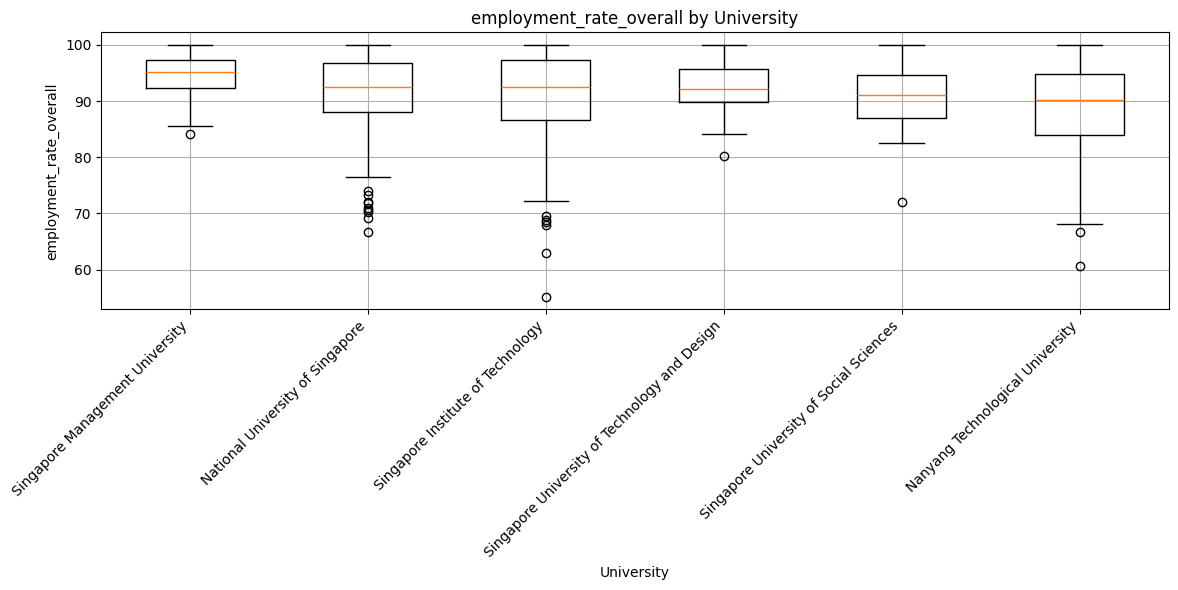

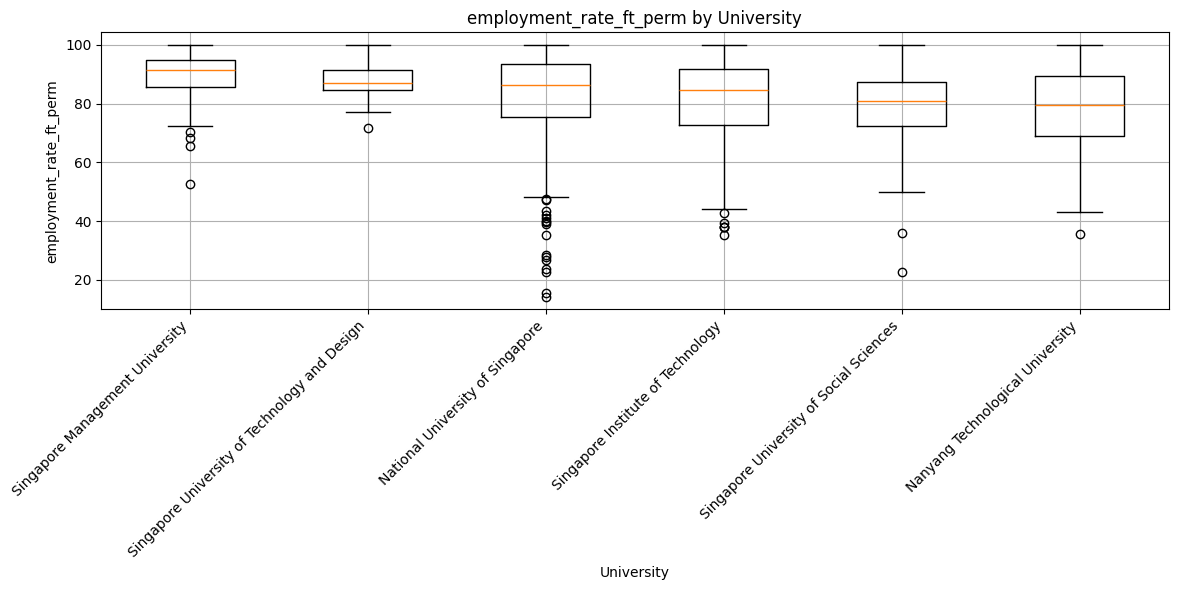

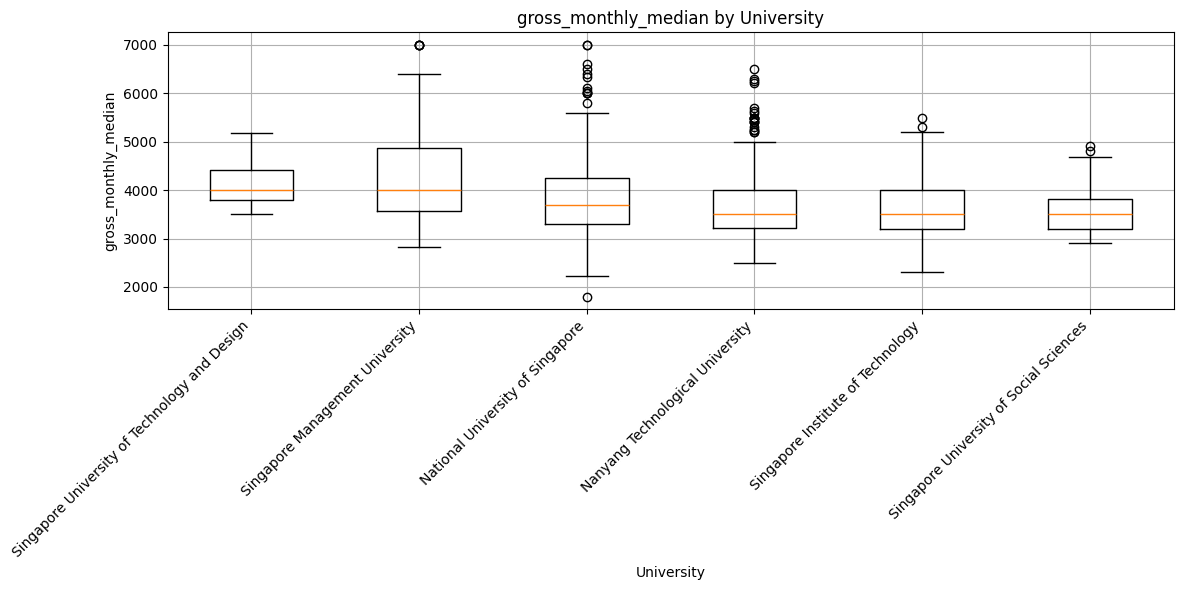

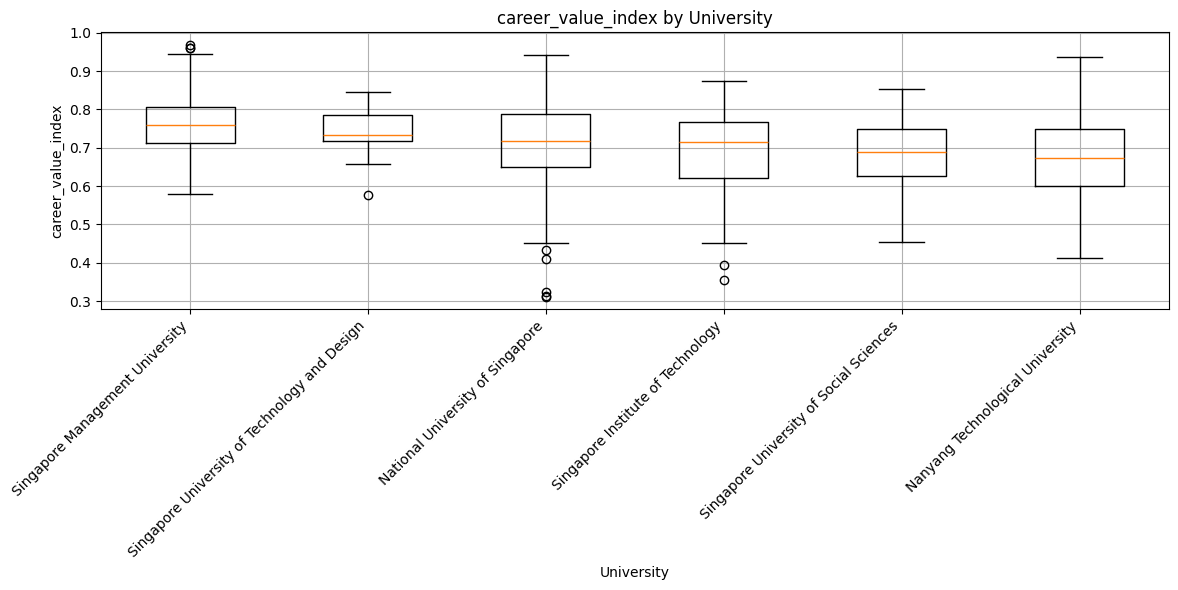

Statistical testing insight summary:


,Figure/Table Reference,What it Shows,Key Insight,Why it Matters,Decision / Next Step
0,Table: statistical_test_results,ANOVA and Kruskal-Wallis test results for univ...,"Shows whether employment, salary, and career-v...",Directly supports RQ2,Use significant test results to justify post-h...
1,Table: statistical_test_pairwise_comparisons,Pairwise university comparisons when overall K...,Identifies which university pairs differ after...,Adds detail beyond the overall group test,Use pairwise results carefully as preliminary ...
2,Boxplot figures,Distribution of outcomes by university,"Shows spread, median differences, and possible...",Supports interpretation of statistical test re...,Use boxplots together with p-values and effect...


Statistical testing for university-level differences completed.
------------------------------------------------------------
Saved tables:
- statistical_test_university_group_summary.csv
- statistical_test_assumption_summary.csv
- statistical_test_results.csv
- statistical_test_pairwise_comparisons.csv
- statistical_testing_insight_summary.csv
Saved figures:
- figure_10_boxplot_employment_rate_overall_by_university.png
- figure_10_boxplot_employment_rate_ft_perm_by_university.png
- figure_10_boxplot_gross_monthly_median_by_university.png
- figure_10_boxplot_career_value_index_by_university.png


In [14]:
# ============================================================
# Part 10: Statistical Testing for University-Level Differences
# ============================================================

from scipy import stats
from itertools import combinations

# ------------------------------------------------------------
# Use the analysis dataset created earlier
# ------------------------------------------------------------

test_df = df_analysis.copy()

# ------------------------------------------------------------
# Define outcomes for university-level testing
# ------------------------------------------------------------

test_outcomes = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "gross_monthly_median",
    "career_value_index"
]

test_outcomes = [
    outcome for outcome in test_outcomes
    if outcome in test_df.columns
]

group_col = "university"

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def eta_squared_anova(groups):
    """
    Calculate eta-squared effect size for one-way ANOVA.
    """
    all_values = np.concatenate(groups)
    grand_mean = np.mean(all_values)
    
    ss_between = sum([
        len(group) * (np.mean(group) - grand_mean) ** 2
        for group in groups
    ])
    
    ss_total = sum((all_values - grand_mean) ** 2)
    
    if ss_total == 0:
        return np.nan
    
    return ss_between / ss_total


def epsilon_squared_kruskal(h_stat, n, k):
    """
    Calculate epsilon-squared effect size for Kruskal-Wallis.
    """
    if n <= k:
        return np.nan
    
    return (h_stat - k + 1) / (n - k)


def interpret_p_value(p_value, alpha=0.05):
    """
    Simple statistical significance interpretation.
    """
    if p_value < alpha:
        return "Statistically significant"
    return "Not statistically significant"


# ------------------------------------------------------------
# 10.1 Group summary by university
# ------------------------------------------------------------

university_test_summary = (
    test_df
    .groupby(group_col)[test_outcomes]
    .agg(["count", "median", "mean", "std"])
)

university_test_summary.to_csv(
    TABLE_DIR / "statistical_test_university_group_summary.csv"
)

print("University group summary for tested outcomes:")
display(university_test_summary)

# ------------------------------------------------------------
# 10.2 Assumption checks and statistical tests
# ------------------------------------------------------------

assumption_rows = []
test_result_rows = []
pairwise_rows = []

alpha = 0.05

for outcome in test_outcomes:
    
    working = test_df[[group_col, outcome]].dropna()
    
    groups_dict = {
        university: group[outcome].dropna().values
        for university, group in working.groupby(group_col)
        if len(group[outcome].dropna()) >= 2
    }
    
    groups = list(groups_dict.values())
    group_names = list(groups_dict.keys())
    
    if len(groups) < 2:
        continue
    
    # --------------------------------------------------------
    # Normality check by group
    # Shapiro-Wilk is sensitive for large samples.
    # Results are used as a diagnostic, not as the only decision rule.
    # --------------------------------------------------------
    
    normality_results = []
    
    for university, values in groups_dict.items():
        if len(values) >= 3:
            sample_values = values
            
            # Shapiro can be too sensitive with very large samples.
            # Limit diagnostic sample to 5000 if needed.
            if len(sample_values) > 5000:
                sample_values = np.random.choice(sample_values, 5000, replace=False)
            
            shapiro_stat, shapiro_p = stats.shapiro(sample_values)
        else:
            shapiro_stat, shapiro_p = np.nan, np.nan
        
        normality_results.append({
            "Outcome": outcome,
            "University": university,
            "Group Size": len(values),
            "Shapiro Statistic": shapiro_stat,
            "Shapiro p-value": shapiro_p,
            "Normality Decision": interpret_p_value(shapiro_p, alpha)
        })
    
    assumption_rows.extend(normality_results)
    
    # --------------------------------------------------------
    # Variance equality check
    # --------------------------------------------------------
    
    levene_stat, levene_p = stats.levene(*groups, center="median")
    
    # --------------------------------------------------------
    # ANOVA
    # --------------------------------------------------------
    
    anova_stat, anova_p = stats.f_oneway(*groups)
    eta_sq = eta_squared_anova(groups)
    
    # --------------------------------------------------------
    # Kruskal-Wallis
    # --------------------------------------------------------
    
    kruskal_stat, kruskal_p = stats.kruskal(*groups)
    n_total = sum(len(group) for group in groups)
    k_groups = len(groups)
    epsilon_sq = epsilon_squared_kruskal(kruskal_stat, n_total, k_groups)
    
    # --------------------------------------------------------
    # Store test results
    # --------------------------------------------------------
    
    test_result_rows.append({
        "Outcome": outcome,
        "Number of Groups": k_groups,
        "Total Valid Records": n_total,
        "Levene Statistic": levene_stat,
        "Levene p-value": levene_p,
        "Variance Equality Decision": interpret_p_value(levene_p, alpha),
        "ANOVA F Statistic": anova_stat,
        "ANOVA p-value": anova_p,
        "ANOVA Decision": interpret_p_value(anova_p, alpha),
        "ANOVA Eta Squared": eta_sq,
        "Kruskal-Wallis H Statistic": kruskal_stat,
        "Kruskal-Wallis p-value": kruskal_p,
        "Kruskal-Wallis Decision": interpret_p_value(kruskal_p, alpha),
        "Kruskal-Wallis Epsilon Squared": epsilon_sq,
        "Primary Test Used": "Kruskal-Wallis",
        "Reason for Primary Test": "Non-parametric test selected because EDA showed skewness and outliers in key outcome variables"
    })
    
    # --------------------------------------------------------
    # Pairwise post-hoc comparison using Mann-Whitney U
    # Bonferroni correction is applied.
    # --------------------------------------------------------
    
    if kruskal_p < alpha:
        pairwise_comparisons = list(combinations(group_names, 2))
        correction_factor = len(pairwise_comparisons)
        
        for group_a, group_b in pairwise_comparisons:
            values_a = groups_dict[group_a]
            values_b = groups_dict[group_b]
            
            u_stat, raw_p = stats.mannwhitneyu(
                values_a,
                values_b,
                alternative="two-sided"
            )
            
            adjusted_p = min(raw_p * correction_factor, 1.0)
            
            pairwise_rows.append({
                "Outcome": outcome,
                "Group A": group_a,
                "Group B": group_b,
                "Group A Median": np.median(values_a),
                "Group B Median": np.median(values_b),
                "Median Difference A_minus_B": np.median(values_a) - np.median(values_b),
                "Mann-Whitney U Statistic": u_stat,
                "Raw p-value": raw_p,
                "Bonferroni Adjusted p-value": adjusted_p,
                "Pairwise Decision": interpret_p_value(adjusted_p, alpha)
            })

# ------------------------------------------------------------
# 10.3 Convert results to DataFrames
# ------------------------------------------------------------

assumption_summary = pd.DataFrame(assumption_rows)
statistical_test_results = pd.DataFrame(test_result_rows)
pairwise_comparison_results = pd.DataFrame(pairwise_rows)

# ------------------------------------------------------------
# 10.4 Save output tables
# ------------------------------------------------------------

assumption_summary.to_csv(
    TABLE_DIR / "statistical_test_assumption_summary.csv",
    index=False
)

statistical_test_results.to_csv(
    TABLE_DIR / "statistical_test_results.csv",
    index=False
)

pairwise_comparison_results.to_csv(
    TABLE_DIR / "statistical_test_pairwise_comparisons.csv",
    index=False
)

# ------------------------------------------------------------
# 10.5 Display outputs
# ------------------------------------------------------------

print("Statistical test assumption summary:")
display(assumption_summary)

print("Statistical test results:")
display(statistical_test_results)

print("Pairwise comparison results:")
display(pairwise_comparison_results)

# ------------------------------------------------------------
# 10.6 Boxplots by university for tested outcomes
# ------------------------------------------------------------

for outcome in test_outcomes:
    plot_df = test_df[[group_col, outcome]].dropna()
    
    universities = (
        plot_df
        .groupby(group_col)[outcome]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )
    
    data_to_plot = [
        plot_df.loc[plot_df[group_col] == university, outcome].values
        for university in universities
    ]
    
    plt.figure(figsize=(12, 6))
    plt.boxplot(data_to_plot, labels=universities, vert=True)
    plt.title(f"{outcome} by University")
    plt.xlabel("University")
    plt.ylabel(outcome)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / f"figure_10_boxplot_{outcome}_by_university.png", dpi=300)
    plt.show()
    plt.close()

# ------------------------------------------------------------
# 10.7 Report-ready statistical testing insight summary
# ------------------------------------------------------------

statistical_testing_insight_summary = pd.DataFrame([
    {
        "Figure/Table Reference": "Table: statistical_test_results",
        "What it Shows": "ANOVA and Kruskal-Wallis test results for university-level differences",
        "Key Insight": "Shows whether employment, salary, and career-value outcomes differ significantly across universities",
        "Why it Matters": "Directly supports RQ2",
        "Decision / Next Step": "Use significant test results to justify post-hoc comparison and interpretation"
    },
    {
        "Figure/Table Reference": "Table: statistical_test_pairwise_comparisons",
        "What it Shows": "Pairwise university comparisons when overall Kruskal-Wallis test is significant",
        "Key Insight": "Identifies which university pairs differ after Bonferroni correction",
        "Why it Matters": "Adds detail beyond the overall group test",
        "Decision / Next Step": "Use pairwise results carefully as preliminary evidence"
    },
    {
        "Figure/Table Reference": "Boxplot figures",
        "What it Shows": "Distribution of outcomes by university",
        "Key Insight": "Shows spread, median differences, and possible outliers by university",
        "Why it Matters": "Supports interpretation of statistical test results",
        "Decision / Next Step": "Use boxplots together with p-values and effect sizes"
    }
])

statistical_testing_insight_summary.to_csv(
    TABLE_DIR / "statistical_testing_insight_summary.csv",
    index=False
)

print("Statistical testing insight summary:")
display(statistical_testing_insight_summary)

# ------------------------------------------------------------
# 10.8 Completion message
# ------------------------------------------------------------

print("Statistical testing for university-level differences completed.")
print("-" * 60)
print("Saved tables:")
print("- statistical_test_university_group_summary.csv")
print("- statistical_test_assumption_summary.csv")
print("- statistical_test_results.csv")
print("- statistical_test_pairwise_comparisons.csv")
print("- statistical_testing_insight_summary.csv")

print("Saved figures:")
print("- figure_10_boxplot_employment_rate_overall_by_university.png")
print("- figure_10_boxplot_employment_rate_ft_perm_by_university.png")
print("- figure_10_boxplot_gross_monthly_median_by_university.png")
print("- figure_10_boxplot_career_value_index_by_university.png")

## Part 10 Interpretation

Key observations from statistical testing for university-level differences:

#### Purpose of the test

- This section tested whether employment, salary, and career-value outcomes differ across universities.

- The tested outcomes were:

  - `employment_rate_overall`
  - `employment_rate_ft_perm`
  - `gross_monthly_median`
  - `career_value_index`

- The primary statistical test used was the **Kruskal-Wallis test**.

- Kruskal-Wallis was selected because earlier EDA showed:

  - Skewness in several variables
  - Outliers in employment and salary outcomes
  - Unequal variance patterns across groups

#### Assumption-check observations

- The Shapiro-Wilk normality test was significant for many university-outcome groups.

- A significant Shapiro-Wilk result indicates that the distribution is likely not normal.

- Levene’s test was significant for all tested outcomes.

- This indicates that variance equality across universities cannot be assumed.

- These assumption-check results support the decision to use Kruskal-Wallis as the primary test instead of relying only on ANOVA.

#### Overall Kruskal-Wallis test results

- The Kruskal-Wallis test found statistically significant university-level differences for all four tested outcomes.

- Significant differences were found for:

  - Overall employment rate
  - Full-time permanent employment rate
  - Median gross monthly salary
  - Career Value Index

- Since the p-values are displayed as `0.00` due to rounding, they should be interpreted as very small p-values, not exactly zero.

- In the interim report, these can be written as:

  - `p < .001`

#### Effect size interpretation

- The Kruskal-Wallis epsilon-squared effect sizes were:

  - Overall employment rate: **0.05**
  - Full-time permanent employment rate: **0.06**
  - Median gross monthly salary: **0.06**
  - Career Value Index: **0.07**

- These effect sizes suggest that the university-level differences are statistically significant but modest in size.

- This means university explains some variation in graduate outcomes, but it is not the only factor.

- Degree program, school, year, and salary/employment structure may also contribute to outcome differences.

#### Overall employment rate findings

- Median overall employment rates differ across universities.

- Singapore Management University has the highest median overall employment rate:

  - **95.10%**

- Nanyang Technological University has a lower median overall employment rate:

  - **90.20%**

- Pairwise tests show that SMU differs significantly from several universities in overall employment.

- NTU also differs significantly from NUS, SIT, and SMU for overall employment.

- Some pairwise comparisons are not statistically significant after Bonferroni correction, especially where median differences are small.

#### Full-time permanent employment findings

- Full-time permanent employment shows statistically significant differences across universities.

- Singapore Management University has the highest median full-time permanent employment rate:

  - **91.30%**

- Nanyang Technological University has a lower median full-time permanent employment rate:

  - **79.70%**

- Singapore University of Social Sciences has:

  - **80.90%**

- Pairwise results show significant differences between SMU and several other universities.

- The difference between overall employment and full-time permanent employment confirms that stable employment should be analyzed separately from general employment.

#### Median salary findings

- Median gross monthly salary differs significantly across universities.

- The highest median gross salary values are observed for:

  - Singapore Management University: **4,000**
  - Singapore University of Technology and Design: **4,000**

- National University of Singapore has:

  - **3,700**

- Nanyang Technological University, Singapore Institute of Technology, and Singapore University of Social Sciences each show:

  - **3,500**

- Pairwise comparisons show significant salary differences between many university pairs.

- However, some pairs with equal median values are not statistically significant.

- For example, NTU and SIT both have median gross salary of **3,500**, and their pairwise comparison is not statistically significant.

#### Career Value Index findings

- Career Value Index differs significantly across universities.

- Singapore Management University has the highest median Career Value Index:

  - **0.76**

- Singapore University of Technology and Design has:

  - **0.73**

- National University of Singapore and Singapore Institute of Technology both have:

  - **0.72**

- Nanyang Technological University has the lowest median Career Value Index:

  - **0.67**

- Pairwise results show that SMU differs significantly from NTU, NUS, SIT, and SUSS.

- Some differences between NUS, SIT, and SUTD are not statistically significant after correction.

#### Research Question 2 implication

- These results directly support **RQ2**.

- The findings show that employment, salary, and career-value outcomes are not identical across universities.

- The statistical tests confirm that the university-level differences observed during EDA are statistically significant.

- However, the effect sizes are modest.

- Therefore, the interim interpretation should be:

  - University-level differences exist.
  - The differences are statistically significant.
  - The effect sizes suggest that university is one factor among several, not the only driver of graduate outcomes.

#### Interim report wording

- A suitable report statement is:

  - “Kruskal-Wallis tests showed statistically significant differences across universities for overall employment rate, full-time permanent employment rate, median gross monthly salary, and Career Value Index. However, the effect sizes were modest, indicating that while university-level differences exist, graduate outcomes are also likely influenced by program, school, year, and other contextual factors.”

#### Evidence generated for the interim report

- `statistical_test_university_group_summary.csv`
- `statistical_test_assumption_summary.csv`
- `statistical_test_results.csv`
- `statistical_test_pairwise_comparisons.csv`
- `statistical_testing_insight_summary.csv`
- `figure_10_boxplot_employment_rate_overall_by_university.png`
- `figure_10_boxplot_employment_rate_ft_perm_by_university.png`
- `figure_10_boxplot_gross_monthly_median_by_university.png`
- `figure_10_boxplot_career_value_index_by_university.png`

Next action:

- Proceed to regression analysis to identify factors associated with median gross monthly salary and Career Value Index.

Model 1 performance:


,Model,Target Variable,Total Records Used,Training Records,Testing Records,MAE,RMSE,R Squared
0,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,1445,1083,362,333.86,476.90,0.58


Model 1 coefficients:


,Model,Target Variable,Feature,Coefficient,Absolute Coefficient
0,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,year,391.59,391.59
4,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,salary_iqr,271.10,271.10
9,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,university_Singapore University of Social Scie...,-251.47,251.47
10,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,university_Singapore University of Technology ...,182.68,182.68
7,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,university_Singapore Institute of Technology,-147.63,147.63
8,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,university_Singapore Management University,136.45,136.45
3,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,employment_premium,-134.68,134.68
2,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,employment_rate_ft_perm,102.13,102.13
6,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,university_National University of Singapore,75.31,75.31
1,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,employment_rate_overall,6.84,6.84


Model 1 prediction sample:


...

,Model,Target Variable,Total Records Used,Training Records,Testing Records,MAE,RMSE,R Squared
0,Model 2: Career Value Index Association Regres...,career_value_index,1445,1083,362,0.00,0.00,1.00


Model 2 coefficients:


,Model,Target Variable,Feature,Coefficient,Absolute Coefficient
1,Model 2: Career Value Index Association Regres...,career_value_index,employment_rate_overall,0.05,0.05
4,Model 2: Career Value Index Association Regres...,career_value_index,gross_monthly_median,0.04,0.04
2,Model 2: Career Value Index Association Regres...,career_value_index,employment_rate_ft_perm,0.03,0.03
5,Model 2: Career Value Index Association Regres...,career_value_index,salary_iqr,-0.01,0.01
3,Model 2: Career Value Index Association Regres...,career_value_index,employment_premium,-0.01,0.01
0,Model 2: Career Value Index Association Regres...,career_value_index,year,0.00,0.00
10,Model 2: Career Value Index Association Regres...,career_value_index,university_Singapore University of Social Scie...,-0.00,0.00
8,Model 2: Career Value Index Association Regres...,career_value_index,university_Singapore Institute of Technology,0.00,0.00
11,Model 2: Career Value Index Association Regres...,career_value_index,university_Singapore University of Technology ...,0.00,0.00
7,Model 2: Career Value Index Association Regres...,career_value_index,university_National University of Singapore,-0.00,0.00


Model 2 prediction sample:


,Actual,Predicted,Residual,Model,Target Variable
0,0.60,0.60,-0.00,Model 2: Career Value Index Association Regres...,career_value_index
1,0.54,0.54,0.00,Model 2: Career Value Index Association Regres...,career_value_index
2,0.71,0.71,0.00,Model 2: Career Value Index Association Regres...,career_value_index
3,0.78,0.78,0.00,Model 2: Career Value Index Association Regres...,career_value_index
4,0.71,0.71,0.00,Model 2: Career Value Index Association Regres...,career_value_index
5,0.72,0.72,-0.00,Model 2: Career Value Index Association Regres...,career_value_index
6,0.73,0.73,-0.00,Model 2: Career Value Index Association Regres...,career_value_index
7,0.78,0.78,-0.00,Model 2: Career Value Index Association Regres...,career_value_index
8,0.79,0.79,0.00,Model 2: Career Value Index Association Regres...,career_value_index
9,0.78,0.78,-0.00,Model 2: Career Value Index Association Regres...,career_value_index


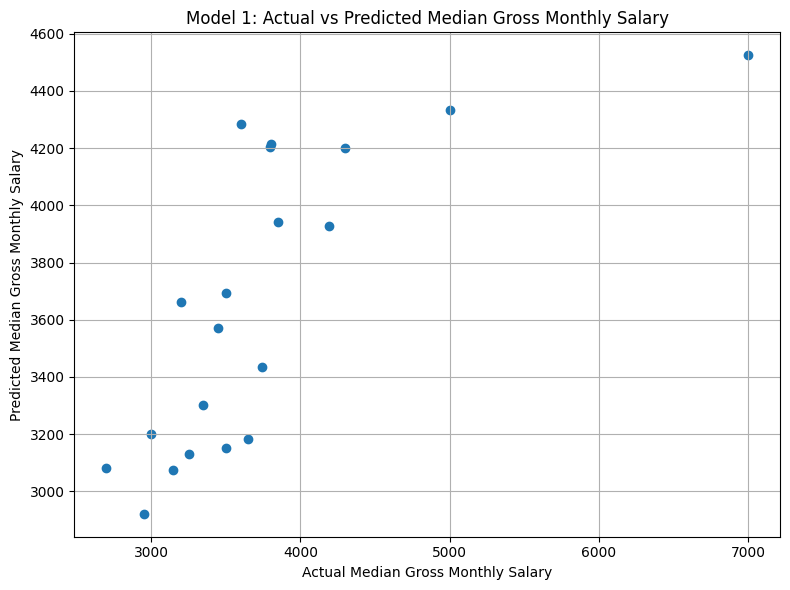

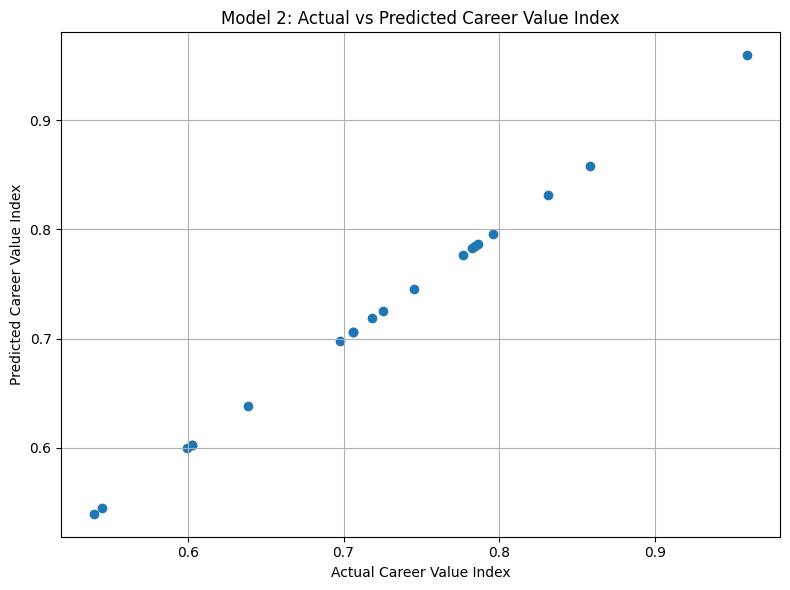

Regression performance summary:


,Model,Target Variable,Total Records Used,Training Records,Testing Records,MAE,RMSE,R Squared
0,Model 1: Median Gross Monthly Salary Regression,gross_monthly_median,1445,1083,362,333.86,476.90,0.58
1,Model 2: Career Value Index Association Regres...,career_value_index,1445,1083,362,0.00,0.00,1.00


Regression insight summary:


,Model,Purpose,Target Variable,Main Feature Groups,Interpretation Note,Relevant RQ
0,Model 1: Median Gross Monthly Salary Regression,Identify factors associated with program-level...,gross_monthly_median,"Year, employment rates, employment premium, sa...",Used as an explanatory model for salary outcom...,RQ3
1,Model 2: Career Value Index Association Regres...,"Examine how employment, salary, and stability ...",career_value_index,"Year, employment rates, salary, salary spread,...",Diagnostic association model because the targe...,RQ3


Regression analysis completed.
------------------------------------------------------------
Saved tables:
- regression_performance_summary.csv
- regression_coefficient_summary.csv
- regression_prediction_samples.csv
- regression_insight_summary.csv
Saved figures:
- figure_11_01_salary_actual_vs_predicted_sample.png
- figure_11_02_career_value_actual_vs_predicted_sample.png


In [15]:
# ============================================================
# Part 11: Regression Analysis for Salary and Career Value Drivers
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# Use the analysis dataset created earlier
# ------------------------------------------------------------

reg_df = df_analysis.copy()

# ------------------------------------------------------------
# Helper function for regression modelling
# ------------------------------------------------------------

def run_regression_model(data, target, numeric_features, categorical_features, model_name):
    """
    Runs a linear regression model using preprocessing pipeline.
    Returns model performance, coefficients, and prediction sample.
    """
    
    selected_cols = numeric_features + categorical_features + [target]
    model_data = data[selected_cols].dropna(subset=[target]).copy()
    
    X = model_data[numeric_features + categorical_features]
    y = model_data[target]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42
    )
    
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )
    
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]
    )
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features)
        ]
    )
    
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", LinearRegression())
        ]
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    performance = pd.DataFrame([
        {
            "Model": model_name,
            "Target Variable": target,
            "Total Records Used": len(model_data),
            "Training Records": len(X_train),
            "Testing Records": len(X_test),
            "MAE": mae,
            "RMSE": rmse,
            "R Squared": r2
        }
    ])
    
    # --------------------------------------------------------
    # Extract feature names after preprocessing
    # --------------------------------------------------------
    
    fitted_preprocessor = model.named_steps["preprocessor"]
    fitted_regressor = model.named_steps["regressor"]
    
    numeric_feature_names = numeric_features
    
    categorical_feature_names = []
    if categorical_features:
        onehot = fitted_preprocessor.named_transformers_["categorical"].named_steps["onehot"]
        categorical_feature_names = onehot.get_feature_names_out(categorical_features).tolist()
    
    final_feature_names = numeric_feature_names + categorical_feature_names
    
    coefficients = pd.DataFrame({
        "Model": model_name,
        "Target Variable": target,
        "Feature": final_feature_names,
        "Coefficient": fitted_regressor.coef_
    })
    
    coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()
    coefficients = coefficients.sort_values("Absolute Coefficient", ascending=False)
    
    prediction_sample = pd.DataFrame({
        "Actual": y_test.values,
        "Predicted": y_pred,
        "Residual": y_test.values - y_pred
    }).head(20)
    
    prediction_sample["Model"] = model_name
    prediction_sample["Target Variable"] = target
    
    return model, performance, coefficients, prediction_sample


# ------------------------------------------------------------
# 11.1 Model 1: Salary driver model
# ------------------------------------------------------------

salary_target = "gross_monthly_median"

salary_numeric_features = [
    "year",
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "employment_premium",
    "salary_iqr"
]

salary_categorical_features = [
    "university"
]

salary_numeric_features = [
    col for col in salary_numeric_features
    if col in reg_df.columns
]

salary_categorical_features = [
    col for col in salary_categorical_features
    if col in reg_df.columns
]

salary_model, salary_performance, salary_coefficients, salary_prediction_sample = run_regression_model(
    data=reg_df,
    target=salary_target,
    numeric_features=salary_numeric_features,
    categorical_features=salary_categorical_features,
    model_name="Model 1: Median Gross Monthly Salary Regression"
)

print("Model 1 performance:")
display(salary_performance)

print("Model 1 coefficients:")
display(salary_coefficients)

print("Model 1 prediction sample:")
display(salary_prediction_sample)

# ------------------------------------------------------------
# 11.2 Model 2: Career Value Index association model
# ------------------------------------------------------------

career_value_target = "career_value_index"

career_value_numeric_features = [
    "year",
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "employment_premium",
    "gross_monthly_median",
    "salary_iqr"
]

career_value_categorical_features = [
    "university"
]

career_value_numeric_features = [
    col for col in career_value_numeric_features
    if col in reg_df.columns
]

career_value_categorical_features = [
    col for col in career_value_categorical_features
    if col in reg_df.columns
]

career_value_model, career_value_performance, career_value_coefficients, career_value_prediction_sample = run_regression_model(
    data=reg_df,
    target=career_value_target,
    numeric_features=career_value_numeric_features,
    categorical_features=career_value_categorical_features,
    model_name="Model 2: Career Value Index Association Regression"
)

print("Model 2 performance:")
display(career_value_performance)

print("Model 2 coefficients:")
display(career_value_coefficients)

print("Model 2 prediction sample:")
display(career_value_prediction_sample)

# ------------------------------------------------------------
# 11.3 Combine regression outputs
# ------------------------------------------------------------

regression_performance_summary = pd.concat(
    [
        salary_performance,
        career_value_performance
    ],
    ignore_index=True
)

regression_coefficient_summary = pd.concat(
    [
        salary_coefficients,
        career_value_coefficients
    ],
    ignore_index=True
)

regression_prediction_samples = pd.concat(
    [
        salary_prediction_sample,
        career_value_prediction_sample
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# 11.4 Save regression outputs
# ------------------------------------------------------------

regression_performance_summary.to_csv(
    TABLE_DIR / "regression_performance_summary.csv",
    index=False
)

regression_coefficient_summary.to_csv(
    TABLE_DIR / "regression_coefficient_summary.csv",
    index=False
)

regression_prediction_samples.to_csv(
    TABLE_DIR / "regression_prediction_samples.csv",
    index=False
)

# ------------------------------------------------------------
# 11.5 Plot actual vs predicted values
# ------------------------------------------------------------

# Salary model actual vs predicted
salary_plot_df = salary_prediction_sample.copy()

plt.figure(figsize=(8, 6))
plt.scatter(salary_plot_df["Actual"], salary_plot_df["Predicted"])
plt.title("Model 1: Actual vs Predicted Median Gross Monthly Salary")
plt.xlabel("Actual Median Gross Monthly Salary")
plt.ylabel("Predicted Median Gross Monthly Salary")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_11_01_salary_actual_vs_predicted_sample.png", dpi=300)
plt.show()
plt.close()

# Career value model actual vs predicted
career_value_plot_df = career_value_prediction_sample.copy()

plt.figure(figsize=(8, 6))
plt.scatter(career_value_plot_df["Actual"], career_value_plot_df["Predicted"])
plt.title("Model 2: Actual vs Predicted Career Value Index")
plt.xlabel("Actual Career Value Index")
plt.ylabel("Predicted Career Value Index")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_11_02_career_value_actual_vs_predicted_sample.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 11.6 Regression insight summary table
# ------------------------------------------------------------

regression_insight_summary = pd.DataFrame([
    {
        "Model": "Model 1: Median Gross Monthly Salary Regression",
        "Purpose": "Identify factors associated with program-level median gross monthly salary",
        "Target Variable": "gross_monthly_median",
        "Main Feature Groups": "Year, employment rates, employment premium, salary spread, university",
        "Interpretation Note": "Used as an explanatory model for salary outcome patterns",
        "Relevant RQ": "RQ3"
    },
    {
        "Model": "Model 2: Career Value Index Association Regression",
        "Purpose": "Examine how employment, salary, and stability components relate to Career Value Index",
        "Target Variable": "career_value_index",
        "Main Feature Groups": "Year, employment rates, salary, salary spread, university",
        "Interpretation Note": "Diagnostic association model because the target is a constructed index",
        "Relevant RQ": "RQ3"
    }
])

regression_insight_summary.to_csv(
    TABLE_DIR / "regression_insight_summary.csv",
    index=False
)

print("Regression performance summary:")
display(regression_performance_summary)

print("Regression insight summary:")
display(regression_insight_summary)

# ------------------------------------------------------------
# 11.7 Completion message
# ------------------------------------------------------------

print("Regression analysis completed.")
print("-" * 60)
print("Saved tables:")
print("- regression_performance_summary.csv")
print("- regression_coefficient_summary.csv")
print("- regression_prediction_samples.csv")
print("- regression_insight_summary.csv")

print("Saved figures:")
print("- figure_11_01_salary_actual_vs_predicted_sample.png")
print("- figure_11_02_career_value_actual_vs_predicted_sample.png")

## Part 11 Interpretation

Key observations from regression analysis:

#### Purpose of regression analysis

- Regression analysis was used to examine factors associated with:

  - `gross_monthly_median`
  - `career_value_index`

- The regression section supports **RQ3**, which asks which factors contribute most to salary outcomes and graduate career value.

---

#### Model 1: Median Gross Monthly Salary Regression

- Model 1 used `gross_monthly_median` as the target variable.

- The model used **1,445 complete records**.

- The train-test split was:

  - Training records: **1,083**
  - Testing records: **362**

- Model performance:

  - MAE: **333.86**
  - RMSE: **476.90**
  - R²: **0.58**

- The R² value of **0.58** means the model explains about **58%** of the variation in median gross monthly salary.

- This is a reasonable preliminary result for an interim-stage regression model using program-level data.

- The model still has unexplained variation, which may be due to factors not available in the dataset, such as:

  - Industry placement
  - Student academic performance
  - Internship experience
  - Job role
  - Employer type
  - Labour market conditions

---

#### Important salary model factors

- The strongest coefficient in the salary model is:

  - `year`: **391.59**

- This suggests that salary outcomes are strongly associated with time.

- This is consistent with the earlier EDA finding that median gross monthly salary increased from **3,100 in 2013** to **4,400 in 2024**.

- `salary_iqr` also has a strong positive coefficient:

  - **271.10**

- This suggests that programs with higher salary spread are also associated with higher median salary.

- This is consistent with the correlation analysis, where higher salary outcomes were linked with wider salary dispersion.

- `employment_premium` has a negative coefficient:

  - **-134.68**

- This indicates that a larger gap between overall employment and full-time permanent employment is associated with lower median salary, after accounting for the other features in the model.

- `employment_rate_ft_perm` has a positive coefficient:

  - **102.13**

- This suggests that stronger full-time permanent employment is associated with higher median salary.

- `employment_rate_overall` has a very small coefficient:

  - **6.84**

- This suggests that general employment rate contributes less to salary prediction once full-time permanent employment and employment premium are included.

---

#### University coefficient observations

- University-related coefficients show additional institutional differences after controlling for numeric predictors.

- Positive university coefficients are observed for:

  - Singapore University of Technology and Design: **182.68**
  - Singapore Management University: **136.45**
  - National University of Singapore: **75.31**

- Negative university coefficients are observed for:

  - Singapore University of Social Sciences: **-251.47**
  - Singapore Institute of Technology: **-147.63**

- These coefficients should be interpreted carefully because one-hot encoded university coefficients depend on the model design and reference structure.

- They should be used as preliminary association evidence, not causal evidence.

---

#### Model 1 interpretation for RQ3

- Model 1 provides useful preliminary evidence for salary drivers.

- The strongest salary-related factors are:

  - Year
  - Salary spread
  - University context
  - Employment premium
  - Full-time permanent employment

- The model supports the idea that salary outcomes are influenced by both time trends and program-level employment structure.

---

#### Model 2: Career Value Index Association Regression

- Model 2 used `career_value_index` as the target variable.

- The model performance shows:

  - MAE: **0.00**
  - RMSE: **0.00**
  - R²: **1.00**

- This result should not be interpreted as a true predictive result.

- The perfect performance occurs because `career_value_index` was constructed from variables included in the model, such as:

  - `employment_rate_overall`
  - `employment_rate_ft_perm`
  - `gross_monthly_median`
  - `salary_iqr`

- Therefore, the model is essentially reconstructing the Career Value Index from its own components.

- This is expected and confirms that the constructed index behaves consistently with its component variables.

---

#### Important caution for the interim report

- The Career Value Index model should be described as a **diagnostic association model**, not as a predictive model.

- The interim report should not state that the model predicts career value perfectly.

- A more accurate statement is:

  - “The Career Value Index regression produced near-perfect fit because the model included variables used to construct the index. Therefore, the result is treated as a diagnostic validation of the index structure rather than as an independent predictive model.”

---

#### Interim report implication

- The salary regression model provides meaningful preliminary evidence for **RQ3**.

- The Career Value Index model confirms that the index is strongly driven by its employment, salary, and stability components.

- The regression findings support the broader project argument that graduate outcomes are multidimensional.

- Salary alone is not enough to describe graduate career outcomes.

- Employment stability, salary level, salary spread, and university context all provide useful information.

---

#### Evidence generated for the interim report

- `regression_performance_summary.csv`
- `regression_coefficient_summary.csv`
- `regression_prediction_samples.csv`
- `regression_insight_summary.csv`
- `figure_11_01_salary_actual_vs_predicted_sample.png`
- `figure_11_02_career_value_actual_vs_predicted_sample.png`

---

## Part 12: Classification Modelling for High-Outcome programs

This section develops preliminary classification models to identify high-outcome degree programs.

Three binary classification targets are created:

- `high_employment`
- `high_salary`
- `high_career_value`

A program-year record is labelled as high outcome if it falls in the top quartile of the relevant outcome variable.

The classification models are preliminary interim-stage models. They are used to test whether program-level features can separate high-outcome and non-high-outcome records better than a simple baseline.

To reduce feature leakage, each model excludes the direct variable used to create its target label.

In [16]:
# ============================================================
# Part 12: Classification Modelling for High-Outcome programs
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Use the analysis dataset created earlier
# ------------------------------------------------------------

clf_df = df_analysis.copy()

# ------------------------------------------------------------
# 12.1 Create high-outcome classification targets
# Top quartile is used as the high-outcome threshold.
# ------------------------------------------------------------

target_source_variables = {
    "high_employment": "employment_rate_overall",
    "high_salary": "gross_monthly_median",
    "high_career_value": "career_value_index"
}

classification_target_summary_rows = []

for target_name, source_var in target_source_variables.items():
    
    if source_var not in clf_df.columns:
        continue
    
    threshold = clf_df[source_var].quantile(0.75)
    clf_df[target_name] = np.where(
        clf_df[source_var].notna(),
        (clf_df[source_var] >= threshold).astype(int),
        np.nan
    )
    
    valid_target = clf_df[target_name].dropna()
    
    classification_target_summary_rows.append({
        "Target Variable": target_name,
        "Source Variable": source_var,
        "Top Quartile Threshold": threshold,
        "Valid Records": int(valid_target.count()),
        "High Outcome Count": int((valid_target == 1).sum()),
        "High Outcome Percent": round((valid_target == 1).mean() * 100, 2),
        "Non-High Outcome Count": int((valid_target == 0).sum()),
        "Non-High Outcome Percent": round((valid_target == 0).mean() * 100, 2)
    })

classification_target_summary = pd.DataFrame(classification_target_summary_rows)

classification_target_summary.to_csv(
    TABLE_DIR / "classification_target_summary.csv",
    index=False
)

print("Classification target summary:")
display(classification_target_summary)

# ------------------------------------------------------------
# 12.2 Helper for OneHotEncoder compatibility
# ------------------------------------------------------------

def make_onehot_encoder():
    """
    Creates OneHotEncoder in a way that works across different sklearn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

# ------------------------------------------------------------
# 12.3 Classification modelling function
# ------------------------------------------------------------

def run_classification_models(data, target, numeric_features, categorical_features):
    """
    Runs baseline, logistic regression, decision tree, and random forest models.
    Returns model performance and confusion-matrix summary.
    """
    
    selected_cols = numeric_features + categorical_features + [target]
    model_data = data[selected_cols].dropna(subset=[target]).copy()
    
    # Keep only rows with usable feature values after simple validation
    X = model_data[numeric_features + categorical_features]
    y = model_data[target].astype(int)
    
    if y.nunique() < 2:
        raise ValueError(f"Target {target} has fewer than two classes.")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )
    
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )
    
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder())
        ]
    )
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("categorical", categorical_transformer, categorical_features)
        ]
    )
    
    models = {
        "Baseline Majority Class": DummyClassifier(strategy="most_frequent"),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            max_depth=None,
            min_samples_leaf=3
        )
    }
    
    performance_rows = []
    confusion_rows = []
    
    for model_name, classifier in models.items():
        
        model_pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier)
            ]
        )
        
        model_pipeline.fit(X_train, y_train)
        
        y_pred = model_pipeline.predict(X_test)
        
        if hasattr(model_pipeline.named_steps["classifier"], "predict_proba"):
            y_proba = model_pipeline.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_proba)
        else:
            roc_auc = np.nan
        
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        
        performance_rows.append({
            "Target Variable": target,
            "Model": model_name,
            "Total Records Used": len(model_data),
            "Training Records": len(X_train),
            "Testing Records": len(X_test),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC AUC": roc_auc
        })
        
        confusion_rows.append({
            "Target Variable": target,
            "Model": model_name,
            "True Negative": tn,
            "False Positive": fp,
            "False Negative": fn,
            "True Positive": tp
        })
    
    performance_df = pd.DataFrame(performance_rows)
    confusion_df = pd.DataFrame(confusion_rows)
    
    return performance_df, confusion_df

# ------------------------------------------------------------
# 12.4 Define leakage-aware feature sets
# ------------------------------------------------------------

classification_feature_sets = {
    "high_employment": {
        "numeric_features": [
            "year",
            "employment_rate_ft_perm",
            "gross_monthly_median",
            "salary_iqr",
            "salary_premium",
            "employment_premium"
        ],
        "categorical_features": [
            "university"
        ]
    },
    "high_salary": {
        "numeric_features": [
            "year",
            "employment_rate_overall",
            "employment_rate_ft_perm",
            "employment_premium",
            "salary_iqr",
            "salary_premium"
        ],
        "categorical_features": [
            "university"
        ]
    },
    "high_career_value": {
        "numeric_features": [
            "year",
            "employment_rate_overall",
            "employment_rate_ft_perm",
            "gross_monthly_median",
            "salary_iqr",
            "employment_premium"
        ],
        "categorical_features": [
            "university"
        ]
    }
}

# Remove unavailable features safely
for target_name in classification_feature_sets:
    classification_feature_sets[target_name]["numeric_features"] = [
        col for col in classification_feature_sets[target_name]["numeric_features"]
        if col in clf_df.columns
    ]
    classification_feature_sets[target_name]["categorical_features"] = [
        col for col in classification_feature_sets[target_name]["categorical_features"]
        if col in clf_df.columns
    ]

# ------------------------------------------------------------
# 12.5 Run classification models
# ------------------------------------------------------------

all_classification_performance = []
all_confusion_results = []

for target_name, feature_info in classification_feature_sets.items():
    
    if target_name not in clf_df.columns:
        continue
    
    print(f"Running classification models for: {target_name}")
    
    performance_df, confusion_df = run_classification_models(
        data=clf_df,
        target=target_name,
        numeric_features=feature_info["numeric_features"],
        categorical_features=feature_info["categorical_features"]
    )
    
    all_classification_performance.append(performance_df)
    all_confusion_results.append(confusion_df)

classification_performance_summary = pd.concat(
    all_classification_performance,
    ignore_index=True
)

classification_confusion_summary = pd.concat(
    all_confusion_results,
    ignore_index=True
)

# ------------------------------------------------------------
# 12.6 Save classification outputs
# ------------------------------------------------------------

classification_performance_summary.to_csv(
    TABLE_DIR / "classification_performance_summary.csv",
    index=False
)

classification_confusion_summary.to_csv(
    TABLE_DIR / "classification_confusion_summary.csv",
    index=False
)

# ------------------------------------------------------------
# 12.7 Best model summary by target using F1 score
# ------------------------------------------------------------

best_classification_models = (
    classification_performance_summary
    .sort_values(["Target Variable", "F1 Score", "ROC AUC"], ascending=[True, False, False])
    .groupby("Target Variable")
    .head(1)
    .reset_index(drop=True)
)

best_classification_models.to_csv(
    TABLE_DIR / "best_classification_models.csv",
    index=False
)

print("Classification performance summary:")
display(classification_performance_summary)

print("Classification confusion summary:")
display(classification_confusion_summary)

print("Best classification model by target:")
display(best_classification_models)

# ------------------------------------------------------------
# 12.8 Classification insight summary table
# ------------------------------------------------------------

classification_insight_summary = pd.DataFrame([
    {
        "Model Area": "High employment classification",
        "Target Variable": "high_employment",
        "Purpose": "Identify program-year records in the top quartile of overall employment rate",
        "Feature Design Note": "Direct overall employment rate is excluded from the predictors",
        "Relevant RQ": "RQ4"
    },
    {
        "Model Area": "High salary classification",
        "Target Variable": "high_salary",
        "Purpose": "Identify program-year records in the top quartile of median gross monthly salary",
        "Feature Design Note": "Direct median gross salary is excluded from the predictors",
        "Relevant RQ": "RQ4"
    },
    {
        "Model Area": "High career value classification",
        "Target Variable": "high_career_value",
        "Purpose": "Identify program-year records in the top quartile of Career Value Index",
        "Feature Design Note": "Career Value Index is excluded from predictors; component variables are used for diagnostic classification",
        "Relevant RQ": "RQ4"
    }
])

classification_insight_summary.to_csv(
    TABLE_DIR / "classification_insight_summary.csv",
    index=False
)

print("Classification insight summary:")
display(classification_insight_summary)

# ------------------------------------------------------------
# 12.9 Completion message
# ------------------------------------------------------------

print("Classification modelling completed.")
print("-" * 60)
print("Saved tables:")
print("- classification_target_summary.csv")
print("- classification_performance_summary.csv")
print("- classification_confusion_summary.csv")
print("- best_classification_models.csv")
print("- classification_insight_summary.csv")

Classification target summary:


,Target Variable,Source Variable,Top Quartile Threshold,Valid Records,High Outcome Count,High Outcome Percent,Non-High Outcome Count,Non-High Outcome Percent
0,high_employment,employment_rate_overall,96.60,1445,362,25.05,1083,74.95
1,high_salary,gross_monthly_median,"4,107.00",1445,362,25.05,1083,74.95
2,high_career_value,career_value_index,0.78,1445,362,25.05,1083,74.95


Running classification models for: high_employment
Running classification models for: high_salary
Running classification models for: high_career_value
Classification performance summary:


,Target Variable,Model,Total Records Used,Training Records,Testing Records,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,high_employment,Baseline Majority Class,1445,1083,362,0.75,0.00,0.00,0.00,0.50
1,high_employment,Logistic Regression,1445,1083,362,0.99,0.98,0.98,0.98,1.00
2,high_employment,Decision Tree,1445,1083,362,0.96,0.94,0.89,0.92,0.96
3,high_employment,Random Forest,1445,1083,362,0.95,0.99,0.80,0.88,0.98
4,high_salary,Baseline Majority Class,1445,1083,362,0.75,0.00,0.00,0.00,0.50
5,high_salary,Logistic Regression,1445,1083,362,0.91,0.80,0.85,0.82,0.96
6,high_salary,Decision Tree,1445,1083,362,0.86,0.70,0.78,0.74,0.91
7,high_salary,Random Forest,1445,1083,362,0.93,0.90,0.79,0.84,0.96
8,high_career_value,Baseline Majority Class,1445,1083,362,0.75,0.00,0.00,0.00,0.50
9,high_career_value,Logistic Regression,1445,1083,362,0.99,1.00,0.98,0.99,1.00


Classification confusion summary:


...

Best classification model by target:


,Target Variable,Model,Total Records Used,Training Records,Testing Records,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,high_career_value,Logistic Regression,1445,1083,362,0.99,1.00,0.98,0.99,1.00
1,high_employment,Logistic Regression,1445,1083,362,0.99,0.98,0.98,0.98,1.00
2,high_salary,Random Forest,1445,1083,362,0.93,0.90,0.79,0.84,0.96


Classification insight summary:


,Model Area,Target Variable,Purpose,Feature Design Note,Relevant RQ
0,High employment classification,high_employment,Identify program-year records in the top quart...,Direct overall employment rate is excluded fro...,RQ4
1,High salary classification,high_salary,Identify program-year records in the top quart...,Direct median gross salary is excluded from th...,RQ4
2,High career value classification,high_career_value,Identify program-year records in the top quart...,Career Value Index is excluded from predictors...,RQ4


Classification modelling completed.
------------------------------------------------------------
Saved tables:
- classification_target_summary.csv
- classification_performance_summary.csv
- classification_confusion_summary.csv
- best_classification_models.csv
- classification_insight_summary.csv


## Part 12 Interpretation

Key observations from classification modelling:

#### Classification target setup

- Three high-outcome classification targets were created using the top quartile threshold.

- The targets were:

  - `high_employment`
  - `high_salary`
  - `high_career_value`

- Each target has the same class distribution:

  - Valid records: **1,445**
  - High-outcome records: **362**
  - High-outcome percentage: **25.05%**
  - Non-high-outcome records: **1,083**
  - Non-high-outcome percentage: **74.95%**

- The top quartile threshold values were:

  - High employment threshold: **96.60%**
  - High salary threshold: **4,107**
  - High career value threshold: **0.78**

- The majority-class baseline achieved accuracy of **0.75** for all three targets.

- However, the baseline has:

  - Precision: **0.00**
  - Recall: **0.00**
  - F1 score: **0.00**

- This is because the baseline predicts only the majority class and fails to identify high-outcome programs.

---

#### High employment classification

- The best model for `high_employment` was:

  - **Logistic Regression**

- Logistic Regression achieved:

  - Accuracy: **0.99**
  - Precision: **0.98**
  - Recall: **0.98**
  - F1 score: **0.98**
  - ROC AUC: **1.00**

- The confusion matrix shows:

  - True negatives: **269**
  - False positives: **2**
  - False negatives: **2**
  - True positives: **89**

- This means the model identified high-employment records very accurately in the test set.

- However, this result should be interpreted cautiously because `employment_premium` is partly derived from `employment_rate_overall`, which is the source variable used to create the target.

---

#### High salary classification

- The best model for `high_salary` was:

  - **Random Forest**

- Random Forest achieved:

  - Accuracy: **0.93**
  - Precision: **0.90**
  - Recall: **0.79**
  - F1 score: **0.84**
  - ROC AUC: **0.96**

- The confusion matrix shows:

  - True negatives: **263**
  - False positives: **8**
  - False negatives: **19**
  - True positives: **72**

- This is a strong preliminary result.

- Logistic Regression also performed well:

  - Accuracy: **0.91**
  - F1 score: **0.82**
  - ROC AUC: **0.96**

- The high-salary model appears more challenging than the high-employment and high-career-value models.

- This is expected because salary outcomes are influenced by program, year, university, industry demand, and other factors not fully captured in the dataset.

- The result should still be interpreted carefully because some engineered salary variables may indirectly contain information related to the target.

---

#### High career value classification

- The best model for `high_career_value` was:

  - **Logistic Regression**

- Logistic Regression achieved:

  - Accuracy: **0.99**
  - Precision: **1.00**
  - Recall: **0.98**
  - F1 score: **0.99**
  - ROC AUC: **1.00**

- The confusion matrix shows:

  - True negatives: **271**
  - False positives: **0**
  - False negatives: **2**
  - True positives: **89**

- This is the strongest classification result.

- However, this should not be interpreted as an independent predictive result.

- `career_value_index` was constructed from employment, salary, and stability-related variables.

- The high-career-value classifier uses some of these component variables, so the model is partly reconstructing the index logic.

- Therefore, this result is better described as a **diagnostic classification result**, not a true independent prediction.

---

#### Comparison against baseline

- All machine learning models performed better than the baseline majority-class classifier.

- The baseline achieved:

  - Accuracy: **0.75**
  - F1 score: **0.00**
  - ROC AUC: **0.50**

- The best models achieved:

  - High employment: Logistic Regression, **F1 = 0.98**
  - High salary: Random Forest, **F1 = 0.84**
  - High career value: Logistic Regression, **F1 = 0.99**

- This shows that program-level variables can separate high-outcome and non-high-outcome records better than a simple baseline.

---

#### Important leakage-control note

- The current classification models are useful as preliminary interim models.

- However, some predictors may indirectly contain target information.

- Examples:

  - `employment_premium` includes `employment_rate_overall`, which is used to create `high_employment`.

  - `salary_premium` includes `gross_monthly_median`, which is used to create `high_salary`.

  - `high_career_value` is based on a constructed index, and the model uses variables that are components of that index.

- Because of this, the reported classification performance may be optimistic.

- For the final report, a stricter leakage-controlled model should be run using a reduced feature set.

---

#### Interim report implication

- The preliminary classification results support **RQ4**.

- The results show that machine learning models can classify high-outcome program-year records better than a majority-class baseline.

- However, the interim report should present these results as **preliminary**.

- The report should clearly mention that further leakage-controlled validation will be performed before the final report.

- A suitable interim wording is:

  - “Preliminary classification models outperformed the majority-class baseline for high-employment, high-salary, and high-career-value classification. However, because some engineered variables are related to the target definitions, the results are treated as preliminary and will be refined using stricter leakage-controlled feature sets in the final analysis.”

---

#### Evidence generated for the interim report

- `classification_target_summary.csv`
- `classification_performance_summary.csv`
- `classification_confusion_summary.csv`
- `best_classification_models.csv`
- `classification_insight_summary.csv`

---

# QM640 GES Capstone — Project Checkpoint

Current project:
Data-driven analysis and predictive modelling of Singapore Graduate Employment Survey outcomes.

Dataset:
- Source: MOE Graduate Employment Survey from data.gov.sg
- Records: 1,550 program-year records
- Complete cases: 1,445 records
- Complete-case rate: 93.23%
- Years covered: 2013 to 2024
- Universities: NTU, NUS, SIT, SMU, SUSS, SUTD
- Unit of analysis: university-degree-year / program-year record

Completed notebook sections:
- Phase 1: Setup, data loading, cleaning, missing-value audit, feature engineering, data dictionary
- Phase 2: EDA coverage, univariate analysis, bivariate trends, multivariate correlation, EDA summary
- Phase 3 Part 10: Statistical testing for university-level differences
- Phase 3 Part 11: Regression analysis for salary and Career Value Index
- Phase 3 Part 12: Preliminary classification modelling

Key EDA results:
- Median gross salary increased from 3,100 in 2013 to 4,400 in 2024.
- Full-time permanent employment dropped sharply in 2020 and recovered in 2021–2022.
- Career Value Index peaked around 2022 and declined slightly after that.
- Salary, employment stability, salary spread, and career value should be interpreted separately.

Part 10 statistical testing:
- Kruskal-Wallis test was used as the primary test.
- Significant university-level differences were found for:
  - Overall employment rate
  - Full-time permanent employment rate
  - Median gross monthly salary
  - Career Value Index
- Effect sizes were modest:
  - Overall employment: 0.05
  - Full-time permanent employment: 0.06
  - Median salary: 0.06
  - Career Value Index: 0.07
- Interpretation: university-level differences exist, but university is only one factor among several.

Part 11 regression:
- Salary regression target: gross_monthly_median
- Records used: 1,445
- MAE: 333.86
- RMSE: 476.90
- R²: 0.58
- Main salary factors:
  - year
  - salary_iqr
  - university context
  - employment_premium
  - employment_rate_ft_perm

Important note:
- Career Value Index regression gave R² = 1.00.
- This should be described only as a diagnostic/component-validation model because the index was constructed from variables included in the model.

Part 12 preliminary classification:
Targets were created using top-quartile thresholds:
- high_employment threshold: 96.60%
- high_salary threshold: 4,107
- high_career_value threshold: 0.78

Best preliminary models:
- high_employment: Logistic Regression, F1 = 0.98
- high_salary: Random Forest, F1 = 0.84
- high_career_value: Logistic Regression, F1 = 0.99

Important note:
- These classification results may be optimistic because some engineered features indirectly contain target information.
- Before the final report, run stricter leakage-controlled classification.

Next recommended step:
- Part 13: Leakage-controlled classification refinement
or
- Part 13: Clustering and segmentation for RQ5

<h2 style = "font-size:40px; font-family:Garamond ; font-weight : normal; background-color: #0667BB; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> Phase 4: Clustering and Segmentation </h2>

Clustering feature set:
['employment_rate_overall', 'employment_rate_ft_perm', 'gross_monthly_median', 'salary_iqr']
Records available for clustering: 1445
Clustering k-selection summary:


,k,Inertia,Silhouette Score,Calinski-Harabasz Score
0,2,"3,934.84",0.30,676.66
1,3,"2,769.87",0.32,783.54
2,4,"2,401.33",0.26,675.83
3,5,"2,127.39",0.26,618.10
4,6,"1,911.15",0.26,582.62
5,7,"1,732.12",0.26,560.10
6,8,"1,580.41",0.27,545.50


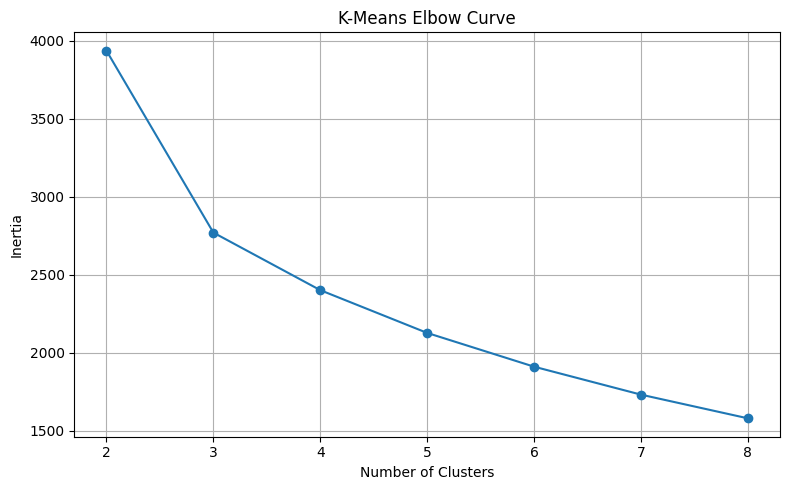

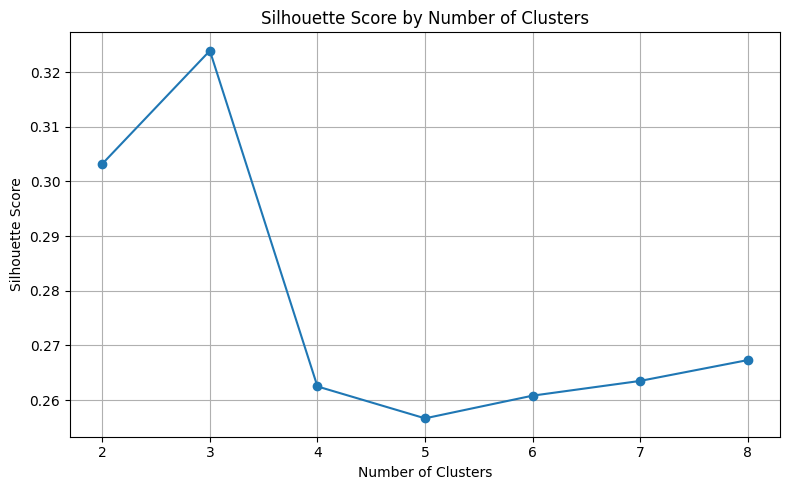

Recommended number of clusters based on highest silhouette score: 3
PCA explained variance:


,Component,Explained Variance Ratio
0,PC1,0.49
1,PC2,0.33
2,PC1 + PC2,0.82


Cluster profile summary:


employment_rate_overall                   employment_rate_ft_perm                    gross_monthly_median  \
                          count median  mean  std                   count median  mean   std                count   
cluster                                                                                                             
1                           324  94.90 94.09 4.59                     324  91.10 89.75  7.31                  324   
2                           651  94.90 94.79 3.71                     651  89.20 89.24  7.09                  651   
3                           470  84.75 83.98 6.11                     470  68.25 65.85 11.91                  470   

                                 salary_iqr                          career_value_index                   
          median     mean    std      count   median     mean    std              count median mean  std  
cluster                                                                                                   
1       4,781.50 4,803.71 707.05        324 1,300.00 1,392.79 573.58                324   0.79 0.78 0.07  
2       3,500.00 3,529.39 410.94        651   600.00   616.07 265.29                651   0.74 0.74 0.05  
3       3,362.50 3,453.08 482.03        470   700.00   727.34 243.21                470   0.60 0.58 0.07

Simplified cluster profile:


...

,cluster,Suggested Cluster Label,Profile Logic
0,1,High employment and high salary profile,High overall employment: True; High full-time ...
1,2,High employment stability with moderate salary...,High overall employment: True; High full-time ...
2,3,Moderate or lower relative outcome profile,High overall employment: False; High full-time...


Cluster university distribution percentage:


university,Nanyang Technological University,National University of Singapore,Singapore Institute of Technology,Singapore Management University,Singapore University of Social Sciences,Singapore University of Technology and Design
cluster,,,,,,
1,19.14,36.73,11.42,25.93,2.47,4.32
2,26.42,29.80,29.49,8.91,3.23,2.15
3,44.04,25.53,24.04,1.70,3.83,0.85


Cluster year distribution percentage:


year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
cluster,,,,,,,,,,,,
1,0.93,1.23,2.47,3.09,4.01,4.94,7.72,10.19,11.42,18.83,15.12,20.06
2,7.68,10.29,9.22,7.83,9.22,10.29,8.60,7.22,10.75,8.60,5.99,4.30
3,5.11,6.81,8.72,10.21,8.94,8.09,9.36,12.55,5.74,4.47,9.36,10.64


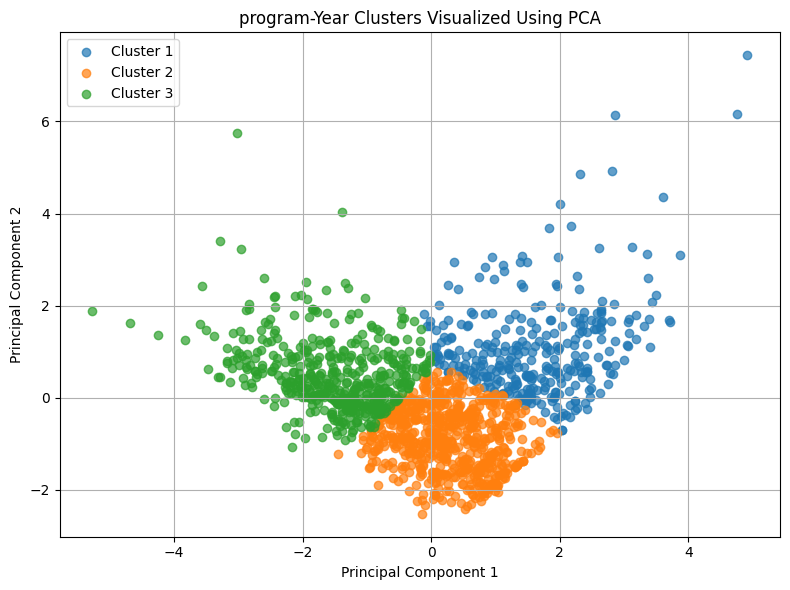

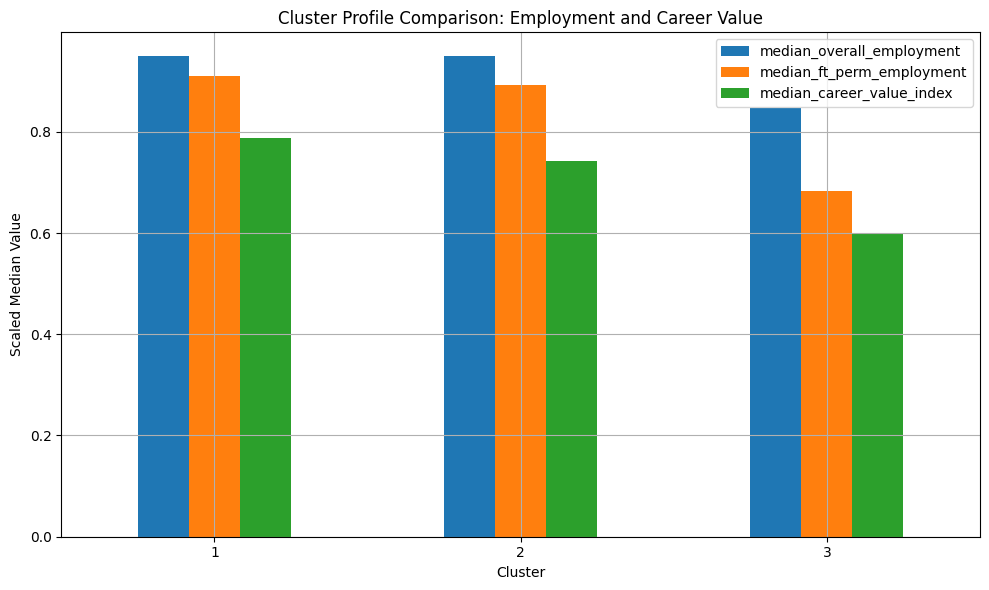

Clustering insight summary:


,Analysis Area,What Was Done,Why It Matters,Relevant RQ
0,Cluster feature design,"Used overall employment, full-time permanent e...","Captures employment, salary, and salary-spread...",RQ5
1,Cluster selection,"Evaluated k values from 2 to 8 using inertia, ...",Provides evidence for selecting the number of ...,RQ5
2,Cluster profiling,Summarized each cluster using median employmen...,Converts mathematical clusters into interpreta...,RQ5
3,Cluster distribution,Generated university and year distributions by...,Shows whether clusters are associated with ins...,RQ5


Clustering and segmentation analysis completed.
------------------------------------------------------------
Recommended k: 3
Clustered dataset saved to: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/data/processed/ges_clustered_program_profiles.csv
Saved tables:
- clustering_scaled_features.csv
- clustering_k_selection_summary.csv
- clustering_pca_explained_variance.csv
- cluster_profile_summary.csv
- cluster_profile_simple.csv
- cluster_interpretation_labels.csv
- cluster_university_distribution_percent.csv
- cluster_year_distribution_percent.csv
- clustering_insight_summary.csv
- ges_clustered_program_profiles.csv
Saved figures:
- figure_14_01_kmeans_elbow_curve.png
- figure_14_02_silhouette_score_by_k.png
- figure_14_03_cluster_pca_scatter.png
- figure_14_04_cluster_profile_employment_career_value.png


In [17]:
# ============================================================
# Part 14: Clustering and Segmentation Analysis for RQ5
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 14.0 Robust folder setup
# ------------------------------------------------------------

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Use the analysis dataset created earlier
# ------------------------------------------------------------

cluster_df = df_analysis.copy()

# ------------------------------------------------------------
# 14.1 Define clustering features
# ------------------------------------------------------------
# Career Value Index is not used as a clustering input because
# it is a constructed composite index. It is used later only
# for cluster interpretation.

clustering_features = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "gross_monthly_median",
    "salary_iqr"
]

clustering_features = [
    col for col in clustering_features
    if col in cluster_df.columns
]

required_context_cols = [
    "year",
    "university",
    "school",
    "degree",
    "career_value_index"
]

available_context_cols = [
    col for col in required_context_cols
    if col in cluster_df.columns
]

cluster_model_data = cluster_df[
    clustering_features + available_context_cols
].dropna(subset=clustering_features).copy()

print("Clustering feature set:")
print(clustering_features)
print(f"Records available for clustering: {len(cluster_model_data)}")

# ------------------------------------------------------------
# 14.2 Standardize clustering features
# ------------------------------------------------------------

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_model_data[clustering_features])

scaled_cluster_features = pd.DataFrame(
    X_cluster,
    columns=[f"scaled_{col}" for col in clustering_features],
    index=cluster_model_data.index
)

scaled_cluster_features.to_csv(
    TABLE_DIR / "clustering_scaled_features.csv",
    index=False
)

# ------------------------------------------------------------
# 14.3 Evaluate k values using inertia, silhouette, and Calinski-Harabasz
# ------------------------------------------------------------

k_values = range(2, 9)
k_selection_rows = []

for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    cluster_labels = kmeans_model.fit_predict(X_cluster)
    
    k_selection_rows.append({
        "k": k,
        "Inertia": kmeans_model.inertia_,
        "Silhouette Score": silhouette_score(X_cluster, cluster_labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(X_cluster, cluster_labels)
    })

clustering_k_selection_summary = pd.DataFrame(k_selection_rows)

clustering_k_selection_summary.to_csv(
    TABLE_DIR / "clustering_k_selection_summary.csv",
    index=False
)

print("Clustering k-selection summary:")
display(clustering_k_selection_summary)

# ------------------------------------------------------------
# 14.4 Plot elbow curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    clustering_k_selection_summary["k"],
    clustering_k_selection_summary["Inertia"],
    marker="o"
)
plt.title("K-Means Elbow Curve")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_14_01_kmeans_elbow_curve.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 14.5 Plot silhouette score
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(
    clustering_k_selection_summary["k"],
    clustering_k_selection_summary["Silhouette Score"],
    marker="o"
)
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_14_02_silhouette_score_by_k.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 14.6 Select recommended k
# ------------------------------------------------------------

recommended_k = int(
    clustering_k_selection_summary
    .sort_values("Silhouette Score", ascending=False)
    .iloc[0]["k"]
)

print(f"Recommended number of clusters based on highest silhouette score: {recommended_k}")

# ------------------------------------------------------------
# 14.7 Fit final K-Means model
# ------------------------------------------------------------

final_kmeans = KMeans(
    n_clusters=recommended_k,
    random_state=42,
    n_init=20
)

cluster_model_data["cluster"] = final_kmeans.fit_predict(X_cluster) + 1
cluster_model_data["cluster"] = cluster_model_data["cluster"].astype(int)

# ------------------------------------------------------------
# 14.8 Add PCA coordinates for visualization
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=42)
pca_coordinates = pca.fit_transform(X_cluster)

cluster_model_data["pca_1"] = pca_coordinates[:, 0]
cluster_model_data["pca_2"] = pca_coordinates[:, 1]

pca_explained_variance = pd.DataFrame([
    {
        "Component": "PC1",
        "Explained Variance Ratio": pca.explained_variance_ratio_[0]
    },
    {
        "Component": "PC2",
        "Explained Variance Ratio": pca.explained_variance_ratio_[1]
    },
    {
        "Component": "PC1 + PC2",
        "Explained Variance Ratio": pca.explained_variance_ratio_.sum()
    }
])

pca_explained_variance.to_csv(
    TABLE_DIR / "clustering_pca_explained_variance.csv",
    index=False
)

print("PCA explained variance:")
display(pca_explained_variance)

# ------------------------------------------------------------
# 14.9 Cluster profile summary
# ------------------------------------------------------------

profile_variables = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "gross_monthly_median",
    "salary_iqr",
    "career_value_index"
]

profile_variables = [
    col for col in profile_variables
    if col in cluster_model_data.columns
]

cluster_profile_summary = (
    cluster_model_data
    .groupby("cluster")[profile_variables]
    .agg(["count", "median", "mean", "std"])
)

cluster_profile_summary.to_csv(
    TABLE_DIR / "cluster_profile_summary.csv"
)

print("Cluster profile summary:")
display(cluster_profile_summary)

# ------------------------------------------------------------
# 14.10 Simplified cluster profile table
# ------------------------------------------------------------

cluster_profile_simple = (
    cluster_model_data
    .groupby("cluster")
    .agg(
        record_count=("cluster", "count"),
        median_overall_employment=("employment_rate_overall", "median"),
        median_ft_perm_employment=("employment_rate_ft_perm", "median"),
        median_gross_salary=("gross_monthly_median", "median"),
        median_salary_iqr=("salary_iqr", "median"),
        median_career_value_index=("career_value_index", "median")
    )
    .reset_index()
)

cluster_profile_simple["cluster"] = cluster_profile_simple["cluster"].astype(int)

cluster_profile_simple["record_percent"] = (
    cluster_profile_simple["record_count"] /
    cluster_profile_simple["record_count"].sum() *
    100
).round(2)

cluster_profile_simple.to_csv(
    TABLE_DIR / "cluster_profile_simple.csv",
    index=False
)

print("Simplified cluster profile:")
display(cluster_profile_simple)

# ------------------------------------------------------------
# 14.11 Generate cluster interpretation labels
# ------------------------------------------------------------

overall_medians = {
    "employment_rate_overall": cluster_model_data["employment_rate_overall"].median(),
    "employment_rate_ft_perm": cluster_model_data["employment_rate_ft_perm"].median(),
    "gross_monthly_median": cluster_model_data["gross_monthly_median"].median(),
    "salary_iqr": cluster_model_data["salary_iqr"].median(),
    "career_value_index": cluster_model_data["career_value_index"].median()
}

cluster_label_rows = []

for _, row in cluster_profile_simple.iterrows():
    
    cluster_id = int(row["cluster"])
    
    high_overall_emp = row["median_overall_employment"] >= overall_medians["employment_rate_overall"]
    high_ft_emp = row["median_ft_perm_employment"] >= overall_medians["employment_rate_ft_perm"]
    high_salary = row["median_gross_salary"] >= overall_medians["gross_monthly_median"]
    high_salary_spread = row["median_salary_iqr"] >= overall_medians["salary_iqr"]
    high_career_value = row["median_career_value_index"] >= overall_medians["career_value_index"]
    
    if high_overall_emp and high_ft_emp and high_salary and high_career_value:
        label = "High employment and high salary profile"
    elif high_salary and not high_ft_emp:
        label = "High salary with weaker employment stability profile"
    elif high_ft_emp and not high_salary:
        label = "High employment stability with moderate salary profile"
    elif high_salary_spread and not high_career_value:
        label = "Wide salary-spread and lower career-value profile"
    else:
        label = "Moderate or lower relative outcome profile"
    
    cluster_label_rows.append({
        "cluster": cluster_id,
        "Suggested Cluster Label": label,
        "Profile Logic": (
            f"High overall employment: {high_overall_emp}; "
            f"High full-time permanent employment: {high_ft_emp}; "
            f"High salary: {high_salary}; "
            f"High salary spread: {high_salary_spread}; "
            f"High career value: {high_career_value}"
        )
    })

cluster_interpretation_labels = pd.DataFrame(cluster_label_rows)

cluster_interpretation_labels.to_csv(
    TABLE_DIR / "cluster_interpretation_labels.csv",
    index=False
)

print("Cluster interpretation labels:")
display(cluster_interpretation_labels)

# ------------------------------------------------------------
# 14.12 University distribution by cluster
# ------------------------------------------------------------

cluster_university_distribution = pd.crosstab(
    cluster_model_data["cluster"],
    cluster_model_data["university"],
    normalize="index"
) * 100

cluster_university_distribution = cluster_university_distribution.round(2)

cluster_university_distribution.to_csv(
    TABLE_DIR / "cluster_university_distribution_percent.csv"
)

print("Cluster university distribution percentage:")
display(cluster_university_distribution)

# ------------------------------------------------------------
# 14.13 Year distribution by cluster
# ------------------------------------------------------------

cluster_year_distribution = pd.crosstab(
    cluster_model_data["cluster"],
    cluster_model_data["year"],
    normalize="index"
) * 100

cluster_year_distribution = cluster_year_distribution.round(2)

cluster_year_distribution.to_csv(
    TABLE_DIR / "cluster_year_distribution_percent.csv"
)

print("Cluster year distribution percentage:")
display(cluster_year_distribution)

# ------------------------------------------------------------
# 14.14 PCA scatter plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

for cluster_id in sorted(cluster_model_data["cluster"].unique()):
    cluster_subset = cluster_model_data[
        cluster_model_data["cluster"] == cluster_id
    ]
    
    plt.scatter(
        cluster_subset["pca_1"],
        cluster_subset["pca_2"],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )

plt.title("program-Year Clusters Visualized Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_14_03_cluster_pca_scatter.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 14.15 Cluster profile comparison plot
# ------------------------------------------------------------

profile_plot_data = cluster_profile_simple.set_index("cluster")[
    [
        "median_overall_employment",
        "median_ft_perm_employment",
        "median_career_value_index"
    ]
].copy()

profile_plot_data["median_overall_employment"] = (
    profile_plot_data["median_overall_employment"] / 100
)

profile_plot_data["median_ft_perm_employment"] = (
    profile_plot_data["median_ft_perm_employment"] / 100
)

profile_plot_data.plot(kind="bar", figsize=(10, 6))
plt.title("Cluster Profile Comparison: Employment and Career Value")
plt.xlabel("Cluster")
plt.ylabel("Scaled Median Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "figure_14_04_cluster_profile_employment_career_value.png", dpi=300)
plt.show()
plt.close()

# ------------------------------------------------------------
# 14.16 Save clustered dataset
# ------------------------------------------------------------

clustered_output_file = PROCESSED_DATA_DIR / "ges_clustered_program_profiles.csv"

cluster_model_data.to_csv(
    clustered_output_file,
    index=False
)

# ------------------------------------------------------------
# 14.17 Clustering insight summary
# ------------------------------------------------------------

clustering_insight_summary = pd.DataFrame([
    {
        "Analysis Area": "Cluster feature design",
        "What Was Done": "Used overall employment, full-time permanent employment, median salary, and salary IQR as clustering features",
        "Why It Matters": "Captures employment, salary, and salary-spread dimensions without directly clustering on the Career Value Index",
        "Relevant RQ": "RQ5"
    },
    {
        "Analysis Area": "Cluster selection",
        "What Was Done": "Evaluated k values from 2 to 8 using inertia, silhouette score, and Calinski-Harabasz score",
        "Why It Matters": "Provides evidence for selecting the number of program outcome segments",
        "Relevant RQ": "RQ5"
    },
    {
        "Analysis Area": "Cluster profiling",
        "What Was Done": "Summarized each cluster using median employment, salary, salary spread, and Career Value Index",
        "Why It Matters": "Converts mathematical clusters into interpretable employability-salary profiles",
        "Relevant RQ": "RQ5"
    },
    {
        "Analysis Area": "Cluster distribution",
        "What Was Done": "Generated university and year distributions by cluster",
        "Why It Matters": "Shows whether clusters are associated with institutional or time-based patterns",
        "Relevant RQ": "RQ5"
    }
])

clustering_insight_summary.to_csv(
    TABLE_DIR / "clustering_insight_summary.csv",
    index=False
)

print("Clustering insight summary:")
display(clustering_insight_summary)

# ------------------------------------------------------------
# 14.18 Completion message
# ------------------------------------------------------------

print("Clustering and segmentation analysis completed.")
print("-" * 60)
print(f"Recommended k: {recommended_k}")
print(f"Clustered dataset saved to: {clustered_output_file}")
print("Saved tables:")
print("- clustering_scaled_features.csv")
print("- clustering_k_selection_summary.csv")
print("- clustering_pca_explained_variance.csv")
print("- cluster_profile_summary.csv")
print("- cluster_profile_simple.csv")
print("- cluster_interpretation_labels.csv")
print("- cluster_university_distribution_percent.csv")
print("- cluster_year_distribution_percent.csv")
print("- clustering_insight_summary.csv")
print("- ges_clustered_program_profiles.csv")

print("Saved figures:")
print("- figure_14_01_kmeans_elbow_curve.png")
print("- figure_14_02_silhouette_score_by_k.png")
print("- figure_14_03_cluster_pca_scatter.png")
print("- figure_14_04_cluster_profile_employment_career_value.png")

## Part 14 Interpretation

Key observations from clustering and segmentation analysis:

#### Clustering objective

- Clustering was used to support **RQ5**.

- The goal was to group program-year records into meaningful employability-salary profiles.

- The clustering model used four selected outcome dimensions:

  - Overall employment rate
  - Full-time permanent employment rate
  - Median gross monthly salary
  - Salary IQR

- The Career Value Index was not used as a clustering input.

- Instead, Career Value Index was used after clustering to interpret the quality of each cluster.

---

#### Cluster selection result

- The clustering analysis tested **k = 2 to k = 8**.

- The highest silhouette score was observed at:

  - **k = 3**
  - Silhouette score: **0.32**

- Therefore, the recommended number of clusters is:

  - **3 clusters**

- The silhouette score indicates moderate separation.

- This is acceptable because graduate outcome data is expected to have overlapping groups rather than perfectly separated categories.

---

#### PCA result

- PCA was used to visualize the clusters in two dimensions.

- The first two principal components explained:

  - PC1: **49%**
  - PC2: **33%**
  - PC1 + PC2: **82%**

- This means the PCA scatter plot captures most of the variation in the clustering features.

---

#### Cluster 1: High employment and high salary profile

- Cluster 1 contains:

  - **324 records**
  - **22.42%** of the dataset

- Median profile:

  - Overall employment: **94.90%**
  - Full-time permanent employment: **91.10%**
  - Median gross salary: **4,781.50**
  - Salary IQR: **1,300**
  - Career Value Index: **0.79**

- This cluster has the strongest salary outcome.

- It also has strong employment stability and the highest median Career Value Index.

- The higher salary IQR indicates wider salary dispersion, meaning high salary outcomes may vary more within this group.

- This cluster is interpreted as:

  - **High employment and high salary profile**

---

#### Cluster 2: High employment stability with moderate salary profile

- Cluster 2 contains:

  - **651 records**
  - **45.05%** of the dataset

- Median profile:

  - Overall employment: **94.90%**
  - Full-time permanent employment: **89.20%**
  - Median gross salary: **3,500**
  - Salary IQR: **600**
  - Career Value Index: **0.74**

- This is the largest cluster.

- It shows strong employment outcomes with moderate salary levels.

- Salary spread is lower than Cluster 1, suggesting more compact salary outcomes.

- This cluster is interpreted as:

  - **High employment stability with moderate salary profile**

---

#### Cluster 3: Moderate or lower relative outcome profile

- Cluster 3 contains:

  - **470 records**
  - **32.53%** of the dataset

- Median profile:

  - Overall employment: **84.75%**
  - Full-time permanent employment: **68.25%**
  - Median gross salary: **3,362.50**
  - Salary IQR: **700**
  - Career Value Index: **0.60**

- This cluster has the weakest employment and career-value outcomes.

- The full-time permanent employment rate is much lower than the other two clusters.

- This indicates that stable employment is the main weakness of this cluster.

- This cluster is interpreted as:

  - **Moderate or lower relative outcome profile**

---

#### University distribution observations

- Cluster 1 has stronger representation from:

  - National University of Singapore: **36.73%**
  - Singapore Management University: **25.93%**
  - Nanyang Technological University: **19.14%**

- Cluster 2 is more evenly distributed across:

  - National University of Singapore: **29.80%**
  - Singapore Institute of Technology: **29.49%**
  - Nanyang Technological University: **26.42%**

- Cluster 3 has a higher representation from:

  - Nanyang Technological University: **44.04%**
  - National University of Singapore: **25.53%**
  - Singapore Institute of Technology: **24.04%**

- These results are descriptive only.

- They should not be interpreted as causal university rankings because the dataset is not balanced equally across universities, schools, or programs.

---

#### Year distribution observations

- Cluster 1 is more strongly represented in recent years.

- In Cluster 1, the largest year shares are:

  - 2022: **18.83%**
  - 2023: **15.12%**
  - 2024: **20.06%**

- This supports the earlier trend finding that higher salary profiles are more common in recent years.

- Cluster 2 is distributed more broadly across the full study period.

- Cluster 3 appears across several years and has a relatively larger share in 2020.

- This is consistent with the earlier finding that employment stability weakened during 2020.

---

#### RQ5 implication

- The clustering results support **RQ5**.

- Degree program-year records can be segmented into meaningful employability-salary profiles.

- The three final profiles are:

  - **Cluster 1:** High employment and high salary profile
  - **Cluster 2:** High employment stability with moderate salary profile
  - **Cluster 3:** Moderate or lower relative outcome profile

- These profiles are useful because they combine salary, employment, employment stability, and salary spread.

- This supports the project argument that graduate outcomes are multidimensional.

---

#### Report-ready statement

A suitable report statement is:

- “K-Means clustering identified three program outcome profiles: a high employment and high salary profile, a high employment stability with moderate salary profile, and a moderate or lower relative outcome profile. The clustering analysis supports the view that graduate outcomes are multidimensional and cannot be fully represented by salary alone.”

---

#### Evidence generated for the report

- `clustering_scaled_features.csv`
- `clustering_k_selection_summary.csv`
- `clustering_pca_explained_variance.csv`
- `cluster_profile_summary.csv`
- `cluster_profile_simple.csv`
- `cluster_interpretation_labels.csv`
- `cluster_university_distribution_percent.csv`
- `cluster_year_distribution_percent.csv`
- `clustering_insight_summary.csv`
- `ges_clustered_program_profiles.csv`
- `figure_14_01_kmeans_elbow_curve.png`
- `figure_14_02_silhouette_score_by_k.png`
- `figure_14_03_cluster_pca_scatter.png`
- `figure_14_04_cluster_profile_employment_career_value.png`

---


In [26]:
# ============================================================
# Part 14A: CVI Sensitivity and Robustness Analysis
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau
from pathlib import Path

# ------------------------------------------------------------
# 14A.1 Load cleaned dataset using Part 0 paths
# ------------------------------------------------------------

df_cvi = pd.read_csv(CLEAN_DATA_FILE)

print("CVI sensitivity dataset loaded.")
print("Dataset shape:", df_cvi.shape)
print("Clean data file:", CLEAN_DATA_FILE)

# ------------------------------------------------------------
# 14A.2 Define required normalized component columns
# ------------------------------------------------------------

component_cols = {
    "overall_employment_score": "Overall Employment Score",
    "ft_perm_employment_score": "Full-Time Permanent Employment Score",
    "median_salary_score": "Median Salary Score",
    "stability_score_norm": "Salary Stability Score"
}

# ------------------------------------------------------------
# 14A.3 Recreate normalized score columns if missing
# ------------------------------------------------------------

def min_max_normalize(series):
    series = series.astype(float)
    min_val = series.min()
    max_val = series.max()
    if max_val == min_val:
        return pd.Series(0.0, index=series.index)
    return (series - min_val) / (max_val - min_val)

# Overall employment score
if "overall_employment_score" not in df_cvi.columns:
    df_cvi["overall_employment_score"] = min_max_normalize(df_cvi["employment_rate_overall"])

# Full-time permanent employment score
if "ft_perm_employment_score" not in df_cvi.columns:
    df_cvi["ft_perm_employment_score"] = min_max_normalize(df_cvi["employment_rate_ft_perm"])

# Median salary score
if "median_salary_score" not in df_cvi.columns:
    df_cvi["median_salary_score"] = min_max_normalize(df_cvi["gross_monthly_median"])

# Salary stability score norm
# If stability_score exists, use it directly or normalize it.
# If not, create inverse normalized salary IQR.
if "stability_score_norm" not in df_cvi.columns:
    if "stability_score" in df_cvi.columns:
        df_cvi["stability_score_norm"] = min_max_normalize(df_cvi["stability_score"])
    else:
        salary_iqr_norm = min_max_normalize(df_cvi["salary_iqr"])
        df_cvi["stability_score_norm"] = 1 - salary_iqr_norm

# ------------------------------------------------------------
# 14A.4 Validate required columns
# ------------------------------------------------------------

required_cols = list(component_cols.keys()) + ["career_value_index"]
missing_cols = [col for col in required_cols if col not in df_cvi.columns]

if missing_cols:
    raise ValueError(f"Missing required CVI sensitivity columns: {missing_cols}")

# Use complete records only
df_cvi_complete = df_cvi.dropna(subset=required_cols).copy()

print("Complete records for CVI sensitivity:", df_cvi_complete.shape[0])

# ------------------------------------------------------------
# 14A.5 Define CVI weighting schemes
# ------------------------------------------------------------

weighting_schemes = {
    "Current CVI": {
        "overall_employment_score": 0.30,
        "ft_perm_employment_score": 0.30,
        "median_salary_score": 0.25,
        "stability_score_norm": 0.15
    },
    "Equal-weight CVI": {
        "overall_employment_score": 0.25,
        "ft_perm_employment_score": 0.25,
        "median_salary_score": 0.25,
        "stability_score_norm": 0.25
    },
    "Employment-heavy CVI": {
        "overall_employment_score": 0.35,
        "ft_perm_employment_score": 0.35,
        "median_salary_score": 0.20,
        "stability_score_norm": 0.10
    },
    "Salary-heavy CVI": {
        "overall_employment_score": 0.25,
        "ft_perm_employment_score": 0.25,
        "median_salary_score": 0.35,
        "stability_score_norm": 0.15
    },
    "Stability-heavy CVI": {
        "overall_employment_score": 0.25,
        "ft_perm_employment_score": 0.25,
        "median_salary_score": 0.20,
        "stability_score_norm": 0.30
    }
}

# ------------------------------------------------------------
# 14A.6 Calculate alternative CVI versions
# ------------------------------------------------------------

for scheme_name, weights in weighting_schemes.items():
    col_name = scheme_name.lower().replace(" ", "_").replace("-", "_")
    df_cvi_complete[col_name] = 0

    for feature, weight in weights.items():
        df_cvi_complete[col_name] += df_cvi_complete[feature] * weight

# Baseline column
baseline_col = "current_cvi"

# The calculated Current CVI column should be used as baseline for fair comparison.
# It should be very close to the existing career_value_index.
df_cvi_complete["current_cvi"] = df_cvi_complete["current_cvi"]

# ------------------------------------------------------------
# 14A.7 Helper functions
# ------------------------------------------------------------

def format_p_value(p):
    if p < 0.001:
        return "p < .001"
    elif p < 0.01:
        return "p < .01"
    elif p < 0.05:
        return "p < .05"
    else:
        return f"p = {p:.3f}"

def top_quartile_overlap(series_a, series_b):
    threshold_a = series_a.quantile(0.75)
    threshold_b = series_b.quantile(0.75)

    top_a = set(series_a[series_a >= threshold_a].index)
    top_b = set(series_b[series_b >= threshold_b].index)

    overlap_count = len(top_a.intersection(top_b))
    overlap_pct = overlap_count / len(top_a) * 100 if len(top_a) > 0 else np.nan

    return overlap_count, overlap_pct

# ------------------------------------------------------------
# 14A.8 Compare alternative CVI versions against current CVI
# ------------------------------------------------------------

sensitivity_rows = []

for scheme_name in weighting_schemes.keys():
    scheme_col = scheme_name.lower().replace(" ", "_").replace("-", "_")

    if scheme_col == baseline_col:
        comparison_label = "Baseline"
    else:
        comparison_label = "Alternative"

    pearson_r, pearson_p = pearsonr(df_cvi_complete[baseline_col], df_cvi_complete[scheme_col])
    spearman_rho, spearman_p = spearmanr(df_cvi_complete[baseline_col], df_cvi_complete[scheme_col])
    kendall_tau, kendall_p = kendalltau(df_cvi_complete[baseline_col], df_cvi_complete[scheme_col])

    overlap_count, overlap_pct = top_quartile_overlap(
        df_cvi_complete[baseline_col],
        df_cvi_complete[scheme_col]
    )

    baseline_rank = df_cvi_complete[baseline_col].rank(ascending=False, method="average")
    scheme_rank = df_cvi_complete[scheme_col].rank(ascending=False, method="average")
    mean_abs_rank_change = np.mean(np.abs(baseline_rank - scheme_rank))

    sensitivity_rows.append({
        "CVI Version": scheme_name,
        "Comparison Type": comparison_label,
        "Pearson r": round(pearson_r, 3),
        "Pearson p-value": format_p_value(pearson_p),
        "Spearman rho": round(spearman_rho, 3),
        "Spearman p-value": format_p_value(spearman_p),
        "Kendall tau": round(kendall_tau, 3),
        "Kendall p-value": format_p_value(kendall_p),
        "Top Quartile Overlap Count": overlap_count,
        "Top Quartile Overlap %": round(overlap_pct, 2),
        "Mean Absolute Rank Change": round(mean_abs_rank_change, 2)
    })

cvi_sensitivity_results = pd.DataFrame(sensitivity_rows)

display(cvi_sensitivity_results)

# Save result
cvi_sensitivity_path = TABLE_DIR / "cvi_sensitivity_analysis.csv"
cvi_sensitivity_results.to_csv(cvi_sensitivity_path, index=False)

print("Saved CVI sensitivity analysis to:", cvi_sensitivity_path)

# ------------------------------------------------------------
# 14A.9 Create CVI weighting scheme table for report
# ------------------------------------------------------------

weighting_rows = []

for scheme_name, weights in weighting_schemes.items():
    weighting_rows.append({
        "CVI Version": scheme_name,
        "Overall Employment Score": weights["overall_employment_score"],
        "Full-Time Permanent Employment Score": weights["ft_perm_employment_score"],
        "Median Salary Score": weights["median_salary_score"],
        "Salary Stability Score": weights["stability_score_norm"]
    })

cvi_weighting_scheme_table = pd.DataFrame(weighting_rows)

display(cvi_weighting_scheme_table)

weighting_scheme_path = TABLE_DIR / "cvi_weighting_scheme_table.csv"
cvi_weighting_scheme_table.to_csv(weighting_scheme_path, index=False)

print("Saved CVI weighting scheme table to:", weighting_scheme_path)

CVI sensitivity dataset loaded.
Dataset shape: (1550, 25)
Clean data file: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/data/processed/ges_cleaned.csv
Complete records for CVI sensitivity: 1445


,CVI Version,Comparison Type,Pearson r,Pearson p-value,Spearman rho,Spearman p-value,Kendall tau,Kendall p-value,Top Quartile Overlap Count,Top Quartile Overlap %,Mean Absolute Rank Change
0,Current CVI,Baseline,1.00,p < .001,1.00,p < .001,1.00,p < .001,362,100.00,0.00
1,Equal-weight CVI,Alternative,1.00,p < .001,0.99,p < .001,0.95,p < .001,347,95.86,26.27
2,Employment-heavy CVI,Alternative,1.00,p < .001,1.00,p < .001,0.95,p < .001,344,95.03,23.12
3,Salary-heavy CVI,Alternative,0.99,p < .001,0.99,p < .001,0.91,p < .001,337,93.09,48.92
4,Stability-heavy CVI,Alternative,0.98,p < .001,0.98,p < .001,0.90,p < .001,326,90.06,51.73


Saved CVI sensitivity analysis to: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/cvi_sensitivity_analysis.csv


,CVI Version,Overall Employment Score,Full-Time Permanent Employment Score,Median Salary Score,Salary Stability Score
0,Current CVI,0.30,0.30,0.25,0.15
1,Equal-weight CVI,0.25,0.25,0.25,0.25
2,Employment-heavy CVI,0.35,0.35,0.20,0.10
3,Salary-heavy CVI,0.25,0.25,0.35,0.15
4,Stability-heavy CVI,0.25,0.25,0.20,0.30


Saved CVI weighting scheme table to: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/cvi_weighting_scheme_table.csv


In [27]:
# ============================================================
# Part 14B: CVI Cluster Stability Check
# ============================================================

# ------------------------------------------------------------
# 14B.1 Try to load clustered program profile data
# ------------------------------------------------------------

clustered_data_path = DATA_PROCESSED_DIR / "ges_clustered_program_profiles.csv"

if clustered_data_path.exists():
    df_clustered = pd.read_csv(clustered_data_path)
    print("Clustered data loaded:", clustered_data_path)
else:
    print("Clustered data file not found.")
    print("Expected path:", clustered_data_path)
    df_clustered = None

# ------------------------------------------------------------
# 14B.2 Identify cluster column and merge alternative CVI values
# ------------------------------------------------------------

if df_clustered is not None:

    possible_cluster_cols = [
        "cluster",
        "Cluster",
        "kmeans_cluster",
        "cluster_label",
        "program_cluster"
    ]

    cluster_col = None
    for col in possible_cluster_cols:
        if col in df_clustered.columns:
            cluster_col = col
            break

    if cluster_col is None:
        print("No cluster column found in clustered dataset.")
        print("Available columns:", df_clustered.columns.tolist())
    else:
        print("Using cluster column:", cluster_col)

        # Align records by index if same number of complete records
        if len(df_clustered) == len(df_cvi_complete):
            df_cluster_cvi = df_clustered.copy().reset_index(drop=True)
            alt_cvi_cols = [
                scheme_name.lower().replace(" ", "_").replace("-", "_")
                for scheme_name in weighting_schemes.keys()
            ]

            for col in alt_cvi_cols:
                df_cluster_cvi[col] = df_cvi_complete.reset_index(drop=True)[col]

            cluster_stability_rows = []

            for scheme_name in weighting_schemes.keys():
                scheme_col = scheme_name.lower().replace(" ", "_").replace("-", "_")

                cluster_summary = (
                    df_cluster_cvi
                    .groupby(cluster_col)[scheme_col]
                    .median()
                    .reset_index()
                )

                for _, row in cluster_summary.iterrows():
                    cluster_stability_rows.append({
                        "CVI Version": scheme_name,
                        "Cluster": row[cluster_col],
                        "Median CVI": round(row[scheme_col], 3)
                    })

            cvi_cluster_stability = pd.DataFrame(cluster_stability_rows)

            display(cvi_cluster_stability)

            cluster_stability_path = TABLE_DIR / "cvi_cluster_stability_analysis.csv"
            cvi_cluster_stability.to_csv(cluster_stability_path, index=False)

            print("Saved CVI cluster stability analysis to:", cluster_stability_path)

        else:
            print("Clustered dataset row count does not match CVI complete dataset.")
            print("Clustered rows:", len(df_clustered))
            print("CVI complete rows:", len(df_cvi_complete))
            print("Skipping cluster stability merge.")

Clustered data loaded: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/data/processed/ges_clustered_program_profiles.csv
Using cluster column: cluster


,CVI Version,Cluster,Median CVI
0,Current CVI,1.00,0.79
1,Current CVI,2.00,0.74
2,Current CVI,3.00,0.60
3,Equal-weight CVI,1.00,0.77
4,Equal-weight CVI,2.00,0.74
5,Equal-weight CVI,3.00,0.62
6,Employment-heavy CVI,1.00,0.81
7,Employment-heavy CVI,2.00,0.77
8,Employment-heavy CVI,3.00,0.60
9,Salary-heavy CVI,1.00,0.75


Saved CVI cluster stability analysis to: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/cvi_cluster_stability_analysis.csv


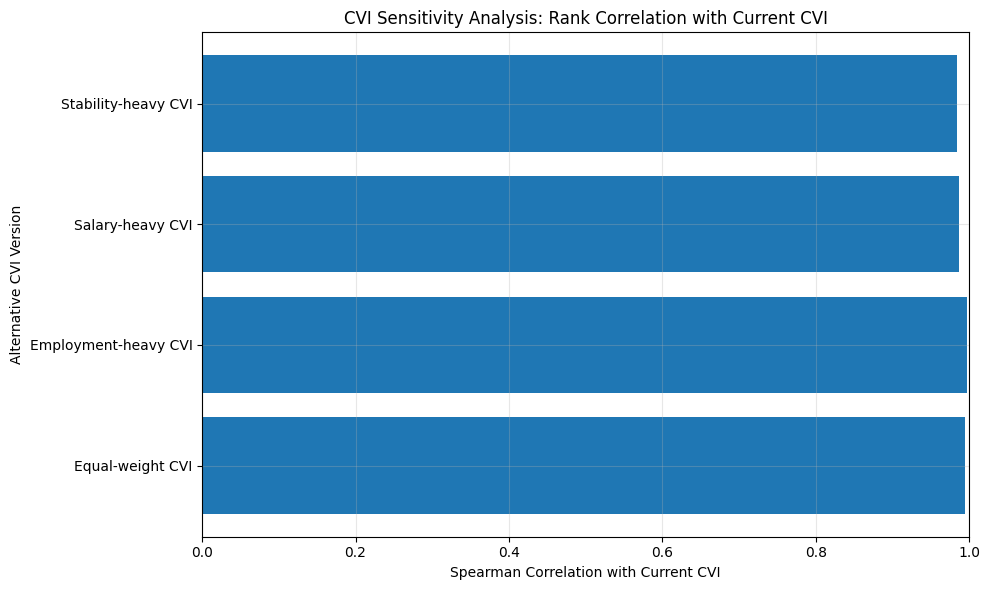

Saved CVI sensitivity figure to: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/figures/figure_cvi_sensitivity_spearman_correlation.png


In [28]:
# ============================================================
# Part 14C: CVI Sensitivity Summary Figure
# ============================================================

import matplotlib.pyplot as plt

plot_df = cvi_sensitivity_results[
    cvi_sensitivity_results["CVI Version"] != "Current CVI"
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(plot_df["CVI Version"], plot_df["Spearman rho"])
ax.set_xlabel("Spearman Correlation with Current CVI")
ax.set_ylabel("Alternative CVI Version")
ax.set_title("CVI Sensitivity Analysis: Rank Correlation with Current CVI")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()

cvi_sensitivity_fig_path = FIGURE_DIR / "figure_cvi_sensitivity_spearman_correlation.png"
plt.savefig(cvi_sensitivity_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved CVI sensitivity figure to:", cvi_sensitivity_fig_path)

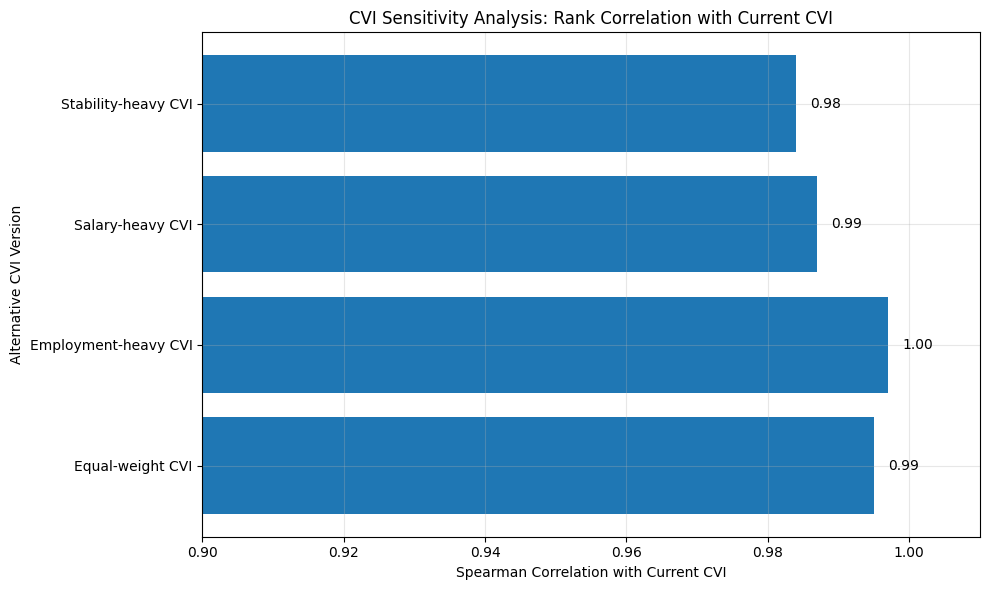

Saved improved CVI sensitivity figure to: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/figures/figure_cvi_sensitivity_spearman_correlation_zoomed.png


In [29]:
# ============================================================
# Improved CVI Sensitivity Summary Figure
# ============================================================

import matplotlib.pyplot as plt

plot_df = cvi_sensitivity_results[
    cvi_sensitivity_results["CVI Version"] != "Current CVI"
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(plot_df["CVI Version"], plot_df["Spearman rho"])

for i, value in enumerate(plot_df["Spearman rho"]):
    ax.text(value + 0.002, i, f"{value:.2f}", va="center")

ax.set_xlabel("Spearman Correlation with Current CVI")
ax.set_ylabel("Alternative CVI Version")
ax.set_title("CVI Sensitivity Analysis: Rank Correlation with Current CVI")
ax.set_xlim(0.90, 1.01)
ax.grid(True, alpha=0.3)

plt.tight_layout()

cvi_sensitivity_fig_path = FIGURE_DIR / "figure_cvi_sensitivity_spearman_correlation_zoomed.png"
plt.savefig(cvi_sensitivity_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved improved CVI sensitivity figure to:", cvi_sensitivity_fig_path)

## Part 14A Interpretation: CVI Sensitivity and Robustness Analysis

### CVI sensitivity dataset

- CVI sensitivity analysis was conducted using the cleaned dataset.
- Dataset used:
  - Total records: **1,550**
  - Complete records used for CVI sensitivity: **1,445**
- The analysis compared the current CVI weighting scheme against four alternative weighting schemes:
  - Equal-weight CVI
  - Employment-heavy CVI
  - Salary-heavy CVI
  - Stability-heavy CVI

### CVI weighting schemes tested

- Current CVI:
  - Overall employment score: **30%**
  - Full-time permanent employment score: **30%**
  - Median salary score: **25%**
  - Salary stability score: **15%**

- Equal-weight CVI:
  - Overall employment score: **25%**
  - Full-time permanent employment score: **25%**
  - Median salary score: **25%**
  - Salary stability score: **25%**

- Employment-heavy CVI:
  - Overall employment score: **35%**
  - Full-time permanent employment score: **35%**
  - Median salary score: **20%**
  - Salary stability score: **10%**

- Salary-heavy CVI:
  - Overall employment score: **25%**
  - Full-time permanent employment score: **25%**
  - Median salary score: **35%**
  - Salary stability score: **15%**

- Stability-heavy CVI:
  - Overall employment score: **25%**
  - Full-time permanent employment score: **25%**
  - Median salary score: **20%**
  - Salary stability score: **30%**

### Sensitivity analysis results

- Equal-weight CVI remained very close to the current CVI.
  - Pearson r = **1.00**
  - Spearman rho = **0.99**
  - Kendall tau = **0.95**
  - Top-quartile overlap = **95.86%**
  - Mean absolute rank change = **26.27**

- Employment-heavy CVI also remained very close to the current CVI.
  - Pearson r = **1.00**
  - Spearman rho = **1.00**
  - Kendall tau = **0.95**
  - Top-quartile overlap = **95.03%**
  - Mean absolute rank change = **23.12**

- Salary-heavy CVI remained highly similar to the current CVI.
  - Pearson r = **0.99**
  - Spearman rho = **0.99**
  - Kendall tau = **0.91**
  - Top-quartile overlap = **93.09%**
  - Mean absolute rank change = **48.92**

- Stability-heavy CVI also remained highly similar to the current CVI, although it showed the largest rank movement among the alternatives.
  - Pearson r = **0.98**
  - Spearman rho = **0.98**
  - Kendall tau = **0.90**
  - Top-quartile overlap = **90.06%**
  - Mean absolute rank change = **51.73**

- All alternative CVI versions were statistically significant compared with the current CVI.
  - Pearson p-value: **p < .001**
  - Spearman p-value: **p < .001**
  - Kendall p-value: **p < .001**

### Top-quartile stability

- The top-quartile overlap results show that high-CVI program-year records remained mostly stable under alternative weighting schemes.
- Top-quartile overlap ranged from:
  - **90.06%** for Stability-heavy CVI
  - to **95.86%** for Equal-weight CVI
- This means that most high-CVI records remained classified as high-CVI even when the weighting structure changed.

### Cluster stability results

- The clustered dataset was successfully loaded from:
  - `data/processed/ges_clustered_program_profiles.csv`

- The cluster column used was:
  - `cluster`

- Current CVI cluster medians:
  - Cluster 1: **0.79**
  - Cluster 2: **0.74**
  - Cluster 3: **0.60**

- Equal-weight CVI cluster medians:
  - Cluster 1: **0.77**
  - Cluster 2: **0.74**
  - Cluster 3: **0.62**

- Employment-heavy CVI cluster medians:
  - Cluster 1: **0.81**
  - Cluster 2: **0.77**
  - Cluster 3: **0.60**

- Salary-heavy CVI cluster medians:
  - Cluster 1: **0.75**
  - Cluster 2: **0.69**
  - Cluster 3: **0.56**

- Stability-heavy CVI cluster medians:
  - Cluster 1: **0.79**
  - Cluster 2: **0.77**
  - Cluster 3: **0.65**

### Cluster interpretation

- Across all CVI versions, the cluster ordering remains stable:
  - **Cluster 1 has the highest median CVI**
  - **Cluster 2 remains the intermediate profile**
  - **Cluster 3 remains the lowest relative outcome profile**

- This supports the use of CVI for cluster interpretation.

### Figure interpretation

- The CVI sensitivity figure shows very high Spearman rank correlations between the current CVI and all alternative CVI versions.
- Spearman correlations range from **0.98 to 1.00**.
- The strongest rank similarity is observed for the Employment-heavy CVI.
- The lowest, but still very high, rank similarity is observed for the Stability-heavy CVI.
- This confirms that the CVI ranking is stable under reasonable alternative weighting choices.

### Main conclusion

- The CVI sensitivity analysis supports the robustness of the Career Value Index.
- The current CVI is not overly dependent on one exact weighting scheme.
- Alternative weighting schemes produce very similar CVI rankings and high top-quartile overlap.
- Cluster-level CVI patterns also remain stable across weighting schemes.
- Therefore, CVI can be retained as a transparent program-level decision-support index for summarizing graduate employment, stable employment, salary, and salary-stability outcomes.

### Interpretation caution

- CVI is a constructed index based on normalized component variables.
- The sensitivity analysis supports consistency and robustness, but it does not prove causality.
- CVI should not be interpreted as:
  - An official university ranking
  - A causal score
  - An individual employability predictor
- CVI should be used as a program-level decision-support measure.

The CVI sensitivity analysis shows that the proposed Career Value Index remains stable under reasonable alternative weighting schemes, with Spearman rank correlations ranging from 0.98 to 1.00 and top-quartile overlap ranging from 90.06% to 95.86%. This supports CVI as a robust program-level decision-support index rather than a weight-sensitive ranking.

<h2 style = "font-size:40px; font-family:Garamond ; font-weight : normal; background-color: #0667BB; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> Phase 5 : Final Consolidation and Report Preparation </h2>

In [18]:
# ============================================================
# Part 15: Final Research Question Results Summary
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display

# ------------------------------------------------------------
# 15.0 Robust folder setup
# ------------------------------------------------------------

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 15.1 Helper function to load existing tables if variable is missing
# ------------------------------------------------------------

def load_table_if_needed(variable_name, file_name):
    """
    Returns a DataFrame from memory if available.
    Otherwise, loads it from outputs/tables if the CSV exists.
    """
    
    if variable_name in globals():
        return globals()[variable_name]
    
    file_path = TABLE_DIR / file_name
    
    if file_path.exists():
        return pd.read_csv(file_path)
    
    return pd.DataFrame()


# ------------------------------------------------------------
# 15.2 Load key outputs from previous parts
# ------------------------------------------------------------

year_trend_summary_loaded = load_table_if_needed(
    "year_trend_summary",
    "bivariate_year_trend_summary.csv"
)

statistical_test_results_loaded = load_table_if_needed(
    "statistical_test_results",
    "statistical_test_results.csv"
)

regression_performance_summary_loaded = load_table_if_needed(
    "regression_performance_summary",
    "regression_performance_summary.csv"
)

classification_preliminary_vs_leakage_loaded = load_table_if_needed(
    "classification_preliminary_vs_leakage_controlled",
    "classification_preliminary_vs_leakage_controlled.csv"
)

leakage_controlled_best_models_loaded = load_table_if_needed(
    "leakage_controlled_best_models",
    "leakage_controlled_best_models.csv"
)

clustering_k_selection_summary_loaded = load_table_if_needed(
    "clustering_k_selection_summary",
    "clustering_k_selection_summary.csv"
)

cluster_profile_simple_loaded = load_table_if_needed(
    "cluster_profile_simple",
    "cluster_profile_simple.csv"
)

cluster_interpretation_labels_loaded = load_table_if_needed(
    "cluster_interpretation_labels",
    "cluster_interpretation_labels.csv"
)

# ------------------------------------------------------------
# 15.3 Extract key result values safely
# ------------------------------------------------------------

# RQ1 trend values
if not year_trend_summary_loaded.empty:
    start_year_row = year_trend_summary_loaded.sort_values("year").iloc[0]
    end_year_row = year_trend_summary_loaded.sort_values("year").iloc[-1]
    
    start_year = int(start_year_row["year"])
    end_year = int(end_year_row["year"])
    start_salary = float(start_year_row["median_gross_salary"])
    end_salary = float(end_year_row["median_gross_salary"])
else:
    start_year = 2013
    end_year = 2024
    start_salary = 3100.00
    end_salary = 4400.00

# RQ2 statistical testing summary
if not statistical_test_results_loaded.empty:
    significant_tests = statistical_test_results_loaded[
        statistical_test_results_loaded["Kruskal-Wallis Decision"] == "Statistically significant"
    ]
    
    rq2_significant_count = len(significant_tests)
    rq2_total_tests = len(statistical_test_results_loaded)
    
    rq2_effect_size_text = "0.05 to 0.07"
else:
    rq2_significant_count = 4
    rq2_total_tests = 4
    rq2_effect_size_text = "0.05 to 0.07"

# RQ3 regression result
if not regression_performance_summary_loaded.empty:
    salary_regression_row = regression_performance_summary_loaded[
        regression_performance_summary_loaded["Target Variable"] == "gross_monthly_median"
    ]
    
    if len(salary_regression_row) > 0:
        salary_r2 = float(salary_regression_row.iloc[0]["R Squared"])
        salary_mae = float(salary_regression_row.iloc[0]["MAE"])
        salary_rmse = float(salary_regression_row.iloc[0]["RMSE"])
    else:
        salary_r2 = 0.58
        salary_mae = 333.86
        salary_rmse = 476.90
else:
    salary_r2 = 0.58
    salary_mae = 333.86
    salary_rmse = 476.90

# RQ4 leakage-controlled classification result
if not leakage_controlled_best_models_loaded.empty:
    best_high_salary_grouped = leakage_controlled_best_models_loaded[
        (leakage_controlled_best_models_loaded["Target Variable"] == "high_salary") &
        (leakage_controlled_best_models_loaded["Split Strategy"] == "Degree-grouped context-only split")
    ]
    
    if len(best_high_salary_grouped) > 0:
        high_salary_grouped_f1 = float(best_high_salary_grouped.iloc[0]["F1 Score"])
        high_salary_grouped_auc = float(best_high_salary_grouped.iloc[0]["ROC AUC"])
    else:
        high_salary_grouped_f1 = 0.71
        high_salary_grouped_auc = 0.91
else:
    high_salary_grouped_f1 = 0.71
    high_salary_grouped_auc = 0.91

# RQ5 clustering result
if not clustering_k_selection_summary_loaded.empty:
    recommended_k_from_table = int(
        clustering_k_selection_summary_loaded
        .sort_values("Silhouette Score", ascending=False)
        .iloc[0]["k"]
    )
    
    best_silhouette = float(
        clustering_k_selection_summary_loaded
        .sort_values("Silhouette Score", ascending=False)
        .iloc[0]["Silhouette Score"]
    )
else:
    recommended_k_from_table = 3
    best_silhouette = 0.32

# ------------------------------------------------------------
# 15.4 Final research question results summary
# ------------------------------------------------------------

final_research_question_results = pd.DataFrame([
    {
        "Research Question": "RQ1",
        "Research Question Focus": "Trend analysis",
        "Question": "How have employment and salary outcomes evolved across Singapore university degree programs from 2013 to 2024?",
        "Main Analysis Used": "Year-level EDA trend analysis",
        "Key Evidence": (
            f"Median gross monthly salary increased from {start_salary:,.0f} in {start_year} "
            f"to {end_salary:,.0f} in {end_year}. Employment outcomes remained generally high, "
            "while full-time permanent employment showed greater variation."
        ),
        "Answer / Finding": (
            "Salary outcomes show a clear upward trend over time. Employment outcomes are generally strong, "
            "but employment stability varies more than overall employment."
        ),
        "Interpretation Caution": "The data is program-level and does not represent individual student outcomes.",
        "Status": "Answered with descriptive EDA evidence"
    },
    {
        "Research Question": "RQ2",
        "Research Question Focus": "University and program differences",
        "Question": "Do employment and salary outcomes differ significantly across universities and degree programs?",
        "Main Analysis Used": "Kruskal-Wallis statistical testing and pairwise comparisons",
        "Key Evidence": (
            f"{rq2_significant_count} out of {rq2_total_tests} Kruskal-Wallis tests were statistically significant. "
            f"Epsilon-squared effect sizes were modest, around {rq2_effect_size_text}."
        ),
        "Answer / Finding": (
            "University-level differences exist for employment, full-time permanent employment, salary, "
            "and Career Value Index."
        ),
        "Interpretation Caution": "Effect sizes are modest, so university is one factor among several and should not be treated as the only driver.",
        "Status": "Answered with statistical testing evidence"
    },
    {
        "Research Question": "RQ3",
        "Research Question Focus": "Salary and career-value drivers",
        "Question": "Which factors contribute most to graduate salary outcomes and graduate career value across Singapore university programs?",
        "Main Analysis Used": "Correlation analysis and regression analysis",
        "Key Evidence": (
            f"Salary regression achieved R² = {salary_r2:.2f}, MAE = {salary_mae:.2f}, "
            f"and RMSE = {salary_rmse:.2f}. Important factors included year, salary spread, "
            "employment premium, full-time permanent employment, and university context."
        ),
        "Answer / Finding": (
            "Salary outcomes are associated with time, salary spread, employment stability, employment premium, "
            "and university context. Career Value Index is mainly driven by its employment, salary, and stability components."
        ),
        "Interpretation Caution": "Regression results are associational, not causal. Career Value Index regression is diagnostic because the index is constructed from component variables.",
        "Status": "Answered with regression and correlation evidence"
    },
    {
        "Research Question": "RQ4",
        "Research Question Focus": "Predictive modelling",
        "Question": "Can machine learning models accurately predict high-employment, high-salary, and high-career-value degree programs?",
        "Main Analysis Used": "Preliminary classification and leakage-controlled classification",
        "Key Evidence": (
            f"In leakage-controlled validation, the degree-grouped high-salary Logistic Regression model achieved "
            f"F1 = {high_salary_grouped_f1:.2f} and ROC AUC = {high_salary_grouped_auc:.2f}."
        ),
        "Answer / Finding": (
            "Machine learning models can identify high-outcome program-year records better than a majority-class baseline. "
            "The most defensible result is high-salary classification under leakage-controlled validation."
        ),
        "Interpretation Caution": "Preliminary models were optimistic; leakage-controlled models provide more realistic evidence.",
        "Status": "Answered with preliminary and leakage-controlled classification evidence"
    },
    {
        "Research Question": "RQ5",
        "Research Question Focus": "Segmentation",
        "Question": "Can degree programs be segmented into meaningful employability-salary profiles to support decision-making?",
        "Main Analysis Used": "K-Means clustering and cluster profiling",
        "Key Evidence": (
            f"K-Means clustering selected k = {recommended_k_from_table} with silhouette score = {best_silhouette:.2f}. "
            "The resulting clusters represented high employment-high salary, high employment-moderate salary, "
            "and moderate/lower relative outcome profiles."
        ),
        "Answer / Finding": (
            "program-year records can be grouped into meaningful employability-salary profiles using employment, "
            "salary, and salary-spread dimensions."
        ),
        "Interpretation Caution": "Cluster labels are descriptive and should not be treated as causal rankings.",
        "Status": "Answered with clustering evidence"
    }
])

final_research_question_results.to_csv(
    TABLE_DIR / "final_research_question_results.csv",
    index=False
)

print("Final research question results summary:")
display(final_research_question_results)

# ------------------------------------------------------------
# 15.5 Final model and analysis evidence summary
# ------------------------------------------------------------

final_analysis_evidence_summary = pd.DataFrame([
    {
        "Analysis Stage": "Data preparation",
        "Main Output": "Cleaned and feature-engineered dataset",
        "Key Result": "1,550 records before cleaning; 1,445 complete-case records for key analysis",
        "Relevant RQ": "All RQs",
        "Report Use": "Data description and methodology"
    },
    {
        "Analysis Stage": "EDA",
        "Main Output": "Coverage, univariate, bivariate, and multivariate summaries",
        "Key Result": "Salary increased over time; employment stability varied more than overall employment",
        "Relevant RQ": "RQ1, RQ2, RQ3",
        "Report Use": "Exploratory findings"
    },
    {
        "Analysis Stage": "Statistical testing",
        "Main Output": "Kruskal-Wallis and pairwise comparisons",
        "Key Result": "Significant university-level differences with modest effect sizes",
        "Relevant RQ": "RQ2",
        "Report Use": "Inferential results"
    },
    {
        "Analysis Stage": "Regression",
        "Main Output": "Salary regression and Career Value Index diagnostic model",
        "Key Result": f"Salary regression achieved R² = {salary_r2:.2f}",
        "Relevant RQ": "RQ3",
        "Report Use": "Driver analysis"
    },
    {
        "Analysis Stage": "Classification",
        "Main Output": "Preliminary and leakage-controlled classification models",
        "Key Result": f"Leakage-controlled high-salary model achieved F1 = {high_salary_grouped_f1:.2f}",
        "Relevant RQ": "RQ4",
        "Report Use": "Predictive modelling evidence"
    },
    {
        "Analysis Stage": "Clustering",
        "Main Output": "K-Means program profile segments",
        "Key Result": f"Recommended k = {recommended_k_from_table}; three interpretable employability-salary profiles",
        "Relevant RQ": "RQ5",
        "Report Use": "Segmentation results"
    }
])

final_analysis_evidence_summary.to_csv(
    TABLE_DIR / "final_analysis_evidence_summary.csv",
    index=False
)

print("Final analysis evidence summary:")
display(final_analysis_evidence_summary)

# ------------------------------------------------------------
# 15.6 Report-ready key numerical findings
# ------------------------------------------------------------

final_key_numerical_findings = pd.DataFrame([
    {
        "Finding": "Total program-year records",
        "Value": "1,550",
        "Where Used": "Data description"
    },
    {
        "Finding": "Complete-case records",
        "Value": "1,445",
        "Where Used": "Data cleaning and modelling readiness"
    },
    {
        "Finding": "Complete-case percentage",
        "Value": "93.23%",
        "Where Used": "Data quality"
    },
    {
        "Finding": "Study period",
        "Value": "2013 to 2024",
        "Where Used": "Scope and RQ1"
    },
    {
        "Finding": "Median salary change",
        "Value": f"{start_salary:,.0f} to {end_salary:,.0f}",
        "Where Used": "RQ1"
    },
    {
        "Finding": "Significant university-level tests",
        "Value": f"{rq2_significant_count}/{rq2_total_tests}",
        "Where Used": "RQ2"
    },
    {
        "Finding": "Salary regression R²",
        "Value": f"{salary_r2:.2f}",
        "Where Used": "RQ3"
    },
    {
        "Finding": "Leakage-controlled high-salary F1",
        "Value": f"{high_salary_grouped_f1:.2f}",
        "Where Used": "RQ4"
    },
    {
        "Finding": "Recommended cluster count",
        "Value": str(recommended_k_from_table),
        "Where Used": "RQ5"
    },
    {
        "Finding": "Best clustering silhouette score",
        "Value": f"{best_silhouette:.2f}",
        "Where Used": "RQ5"
    }
])

final_key_numerical_findings.to_csv(
    TABLE_DIR / "final_key_numerical_findings.csv",
    index=False
)

print("Final key numerical findings:")
display(final_key_numerical_findings)

# ------------------------------------------------------------
# 15.7 Limitations and final-report improvement plan
# ------------------------------------------------------------

final_limitations_and_next_steps = pd.DataFrame([
    {
        "Area": "Data granularity",
        "Limitation": "The dataset is aggregated at program-year level.",
        "Impact": "Individual graduate-level prediction cannot be claimed.",
        "Next Step": "State clearly that all findings are program-level."
    },
    {
        "Area": "Causality",
        "Limitation": "The analysis is observational.",
        "Impact": "Regression and classification results are associational.",
        "Next Step": "Avoid causal wording such as 'causes' or 'leads to'."
    },
    {
        "Area": "Missing values",
        "Limitation": "105 records have missing key outcome values.",
        "Impact": "Complete-case analysis uses 1,445 records.",
        "Next Step": "Report missing-value handling clearly."
    },
    {
        "Area": "Class imbalance",
        "Limitation": "High-outcome classes represent about 25% of records.",
        "Impact": "Accuracy alone is not sufficient.",
        "Next Step": "Report F1, recall, precision, ROC AUC, and baseline comparison."
    },
    {
        "Area": "Feature leakage",
        "Limitation": "Preliminary classification used some engineered variables related to the targets.",
        "Impact": "Part 12 results are optimistic.",
        "Next Step": "Use Part 13 leakage-controlled results as the main defensible classification evidence."
    },
    {
        "Area": "Clustering interpretation",
        "Limitation": "Clusters are descriptive groups.",
        "Impact": "Cluster labels are profiles, not causal categories.",
        "Next Step": "Use cluster profiles for decision support, not ranking."
    }
])

final_limitations_and_next_steps.to_csv(
    TABLE_DIR / "final_limitations_and_next_steps.csv",
    index=False
)

print("Final limitations and next steps:")
display(final_limitations_and_next_steps)

# ------------------------------------------------------------
# 15.8 Completion message
# ------------------------------------------------------------

print("Final research question results summary completed.")
print("-" * 60)
print("Saved tables:")
print("- final_research_question_results.csv")
print("- final_analysis_evidence_summary.csv")
print("- final_key_numerical_findings.csv")
print("- final_limitations_and_next_steps.csv")

Final research question results summary:


,Research Question,Research Question Focus,Question,Main Analysis Used,Key Evidence,Answer / Finding,Interpretation Caution,Status
0,RQ1,Trend analysis,How have employment and salary outcomes evolve...,Year-level EDA trend analysis,"Median gross monthly salary increased from 3,1...",Salary outcomes show a clear upward trend over...,The data is program-level and does not represe...,Answered with descriptive EDA evidence
1,RQ2,University and program differences,Do employment and salary outcomes differ signi...,Kruskal-Wallis statistical testing and pairwis...,4 out of 4 Kruskal-Wallis tests were statistic...,University-level differences exist for employm...,"Effect sizes are modest, so university is one ...",Answered with statistical testing evidence
2,RQ3,Salary and career-value drivers,Which factors contribute most to graduate sala...,Correlation analysis and regression analysis,"Salary regression achieved R² = 0.58, MAE = 33...","Salary outcomes are associated with time, sala...","Regression results are associational, not caus...",Answered with regression and correlation evidence
3,RQ4,Predictive modelling,Can machine learning models accurately predict...,Preliminary classification and leakage-control...,"In leakage-controlled validation, the degree-g...",Machine learning models can identify high-outc...,Preliminary models were optimistic; leakage-co...,Answered with preliminary and leakage-controll...
4,RQ5,Segmentation,Can degree programs be segmented into meaningf...,K-Means clustering and cluster profiling,K-Means clustering selected k = 3 with silhoue...,program-year records can be grouped into meani...,Cluster labels are descriptive and should not ...,Answered with clustering evidence


Final analysis evidence summary:


,Analysis Stage,Main Output,Key Result,Relevant RQ,Report Use
0,Data preparation,Cleaned and feature-engineered dataset,"1,550 records before cleaning; 1,445 complete-...",All RQs,Data description and methodology
1,EDA,"Coverage, univariate, bivariate, and multivari...",Salary increased over time; employment stabili...,"RQ1, RQ2, RQ3",Exploratory findings
2,Statistical testing,Kruskal-Wallis and pairwise comparisons,Significant university-level differences with ...,RQ2,Inferential results
3,Regression,Salary regression and Career Value Index diagn...,Salary regression achieved R² = 0.58,RQ3,Driver analysis
4,Classification,Preliminary and leakage-controlled classificat...,Leakage-controlled high-salary model achieved ...,RQ4,Predictive modelling evidence
5,Clustering,K-Means program profile segments,Recommended k = 3; three interpretable employa...,RQ5,Segmentation results


Final key numerical findings:


,Finding,Value,Where Used
0,Total program-year records,"1,550",Data description
1,Complete-case records,"1,445",Data cleaning and modelling readiness
2,Complete-case percentage,93.23%,Data quality
3,Study period,2013 to 2024,Scope and RQ1
4,Median salary change,"3,100 to 4,400",RQ1
5,Significant university-level tests,4/4,RQ2
6,Salary regression R²,0.58,RQ3
7,Leakage-controlled high-salary F1,0.71,RQ4
8,Recommended cluster count,3,RQ5
9,Best clustering silhouette score,0.32,RQ5


Final limitations and next steps:


,Area,Limitation,Impact,Next Step
0,Data granularity,The dataset is aggregated at program-year level.,Individual graduate-level prediction cannot be...,State clearly that all findings are program-le...
1,Causality,The analysis is observational.,Regression and classification results are asso...,Avoid causal wording such as 'causes' or 'lead...
2,Missing values,105 records have missing key outcome values.,"Complete-case analysis uses 1,445 records.",Report missing-value handling clearly.
3,Class imbalance,High-outcome classes represent about 25% of re...,Accuracy alone is not sufficient.,"Report F1, recall, precision, ROC AUC, and bas..."
4,Feature leakage,Preliminary classification used some engineere...,Part 12 results are optimistic.,Use Part 13 leakage-controlled results as the ...
5,Clustering interpretation,Clusters are descriptive groups.,"Cluster labels are profiles, not causal catego...","Use cluster profiles for decision support, not..."


Final research question results summary completed.
------------------------------------------------------------
Saved tables:
- final_research_question_results.csv
- final_analysis_evidence_summary.csv
- final_key_numerical_findings.csv
- final_limitations_and_next_steps.csv


In [19]:
# ============================================================
# Part 16: Final Export, Checkpoint Save, and Report Package Preparation
# ============================================================

from pathlib import Path
from datetime import datetime
import pickle
import json
import shutil
import zipfile

import pandas as pd
import numpy as np

from IPython.display import display

# ------------------------------------------------------------
# 16.0 Robust folder setup
# ------------------------------------------------------------

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
REPORT_PACKAGE_DIR = OUTPUT_DIR / "report_package"

for folder in [
    DATA_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    OUTPUT_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    CHECKPOINT_DIR,
    REPORT_PACKAGE_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ------------------------------------------------------------
# 16.1 Define important variables to preserve in checkpoint
# ------------------------------------------------------------

checkpoint_variable_names = [
    # Core datasets
    "df",
    "df_fe",
    "df_analysis",
    "clf_df",
    "strict_clf_df",
    "cluster_model_data",
    
    # Data description and cleaning
    "dataset_overview",
    "data_dictionary",
    "target_variable_summary",
    "missing_pattern_summary",
    "missing_by_year",
    "missing_by_university",
    
    # EDA
    "coverage_summary",
    "year_trend_summary",
    "university_outcome_summary",
    "bivariate_correlation",
    "correlation_matrix",
    "target_correlation_summary",
    "strong_correlation_pairs",
    
    # Statistical testing
    "university_test_summary",
    "assumption_summary",
    "statistical_test_results",
    "pairwise_comparison_results",
    
    # Regression
    "regression_performance_summary",
    "regression_coefficient_summary",
    "regression_prediction_samples",
    
    # Classification
    "classification_target_summary",
    "classification_performance_summary",
    "classification_confusion_summary",
    "best_classification_models",
    "leakage_controlled_classification_performance",
    "leakage_controlled_confusion_summary",
    "leakage_controlled_best_models",
    "classification_preliminary_vs_leakage_controlled",
    
    # Clustering
    "clustering_k_selection_summary",
    "pca_explained_variance",
    "cluster_profile_summary",
    "cluster_profile_simple",
    "cluster_interpretation_labels",
    "cluster_university_distribution",
    "cluster_year_distribution",
    "clustering_insight_summary",
    
    # Final summaries
    "final_research_question_results",
    "final_analysis_evidence_summary",
    "final_key_numerical_findings",
    "final_limitations_and_next_steps"
]

checkpoint_data = {
    "checkpoint_stage": "Full analysis completed after Part 16",
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "project_root": str(PROJECT_ROOT),
    "saved_variables": {}
}

for var_name in checkpoint_variable_names:
    if var_name in globals():
        checkpoint_data["saved_variables"][var_name] = globals()[var_name]

checkpoint_file = CHECKPOINT_DIR / "checkpoint_full_analysis_completed.pkl"

with open(checkpoint_file, "wb") as file:
    pickle.dump(checkpoint_data, file)

checkpoint_metadata = {
    "checkpoint_stage": checkpoint_data["checkpoint_stage"],
    "created_at": checkpoint_data["created_at"],
    "project_root": checkpoint_data["project_root"],
    "checkpoint_file": str(checkpoint_file),
    "saved_variable_count": len(checkpoint_data["saved_variables"]),
    "saved_variables": list(checkpoint_data["saved_variables"].keys())
}

checkpoint_metadata_file = CHECKPOINT_DIR / "checkpoint_full_analysis_completed_metadata.json"

with open(checkpoint_metadata_file, "w") as file:
    json.dump(checkpoint_metadata, file, indent=4)

print("Full analysis checkpoint saved.")
print(f"Checkpoint file: {checkpoint_file}")
print(f"Variables saved: {len(checkpoint_data['saved_variables'])}")

# ------------------------------------------------------------
# 16.2 Create file inventory for report outputs
# ------------------------------------------------------------

inventory_rows = []

inventory_locations = [
    ("Raw Data", RAW_DATA_DIR),
    ("Processed Data", PROCESSED_DATA_DIR),
    ("Tables", TABLE_DIR),
    ("Figures", FIGURE_DIR),
    ("Checkpoints", CHECKPOINT_DIR)
]

for category, folder in inventory_locations:
    if folder.exists():
        for file_path in sorted(folder.glob("*")):
            if file_path.is_file():
                inventory_rows.append({
                    "Category": category,
                    "File Name": file_path.name,
                    "File Path": str(file_path),
                    "File Extension": file_path.suffix,
                    "File Size KB": round(file_path.stat().st_size / 1024, 2),
                    "Modified Time": datetime.fromtimestamp(
                        file_path.stat().st_mtime
                    ).strftime("%Y-%m-%d %H:%M:%S")
                })

final_output_file_inventory = pd.DataFrame(inventory_rows)

final_output_file_inventory.to_csv(
    TABLE_DIR / "final_output_file_inventory.csv",
    index=False
)

print("Final output file inventory:")
display(final_output_file_inventory)

# ------------------------------------------------------------
# 16.3 Define key report tables and figures
# ------------------------------------------------------------

key_report_tables = [
    "dataset_overview.csv",
    "data_dictionary.csv",
    "missing_pattern_summary.csv",
    "feature_engineering_summary.csv",
    "bivariate_year_trend_summary.csv",
    "bivariate_university_outcome_summary.csv",
    "multivariate_correlation_matrix.csv",
    "statistical_test_results.csv",
    "statistical_test_pairwise_comparisons.csv",
    "regression_performance_summary.csv",
    "regression_coefficient_summary.csv",
    "classification_performance_summary.csv",
    "classification_preliminary_vs_leakage_controlled.csv",
    "leakage_controlled_best_models.csv",
    "clustering_k_selection_summary.csv",
    "cluster_profile_simple.csv",
    "cluster_interpretation_labels.csv",
    "final_research_question_results.csv",
    "final_analysis_evidence_summary.csv",
    "final_key_numerical_findings.csv",
    "final_limitations_and_next_steps.csv"
]

key_report_figures = [
    "figure_07_01_salary_trend_by_year.png",
    "figure_07_02_employment_trend_by_year.png",
    "figure_08_01_correlation_heatmap.png",
    "figure_10_boxplot_gross_monthly_median_by_university.png",
    "figure_10_boxplot_career_value_index_by_university.png",
    "figure_13_02_preliminary_vs_leakage_controlled_f1.png",
    "figure_14_01_kmeans_elbow_curve.png",
    "figure_14_02_silhouette_score_by_k.png",
    "figure_14_03_cluster_pca_scatter.png",
    "figure_14_04_cluster_profile_employment_career_value.png"
]

key_processed_files = [
    "ges_cleaned.csv",
    "ges_clustered_program_profiles.csv"
]

# ------------------------------------------------------------
# 16.4 Copy key files into report package folder
# ------------------------------------------------------------

package_tables_dir = REPORT_PACKAGE_DIR / "tables"
package_figures_dir = REPORT_PACKAGE_DIR / "figures"
package_data_dir = REPORT_PACKAGE_DIR / "data"
package_checkpoints_dir = REPORT_PACKAGE_DIR / "checkpoints"

for folder in [
    package_tables_dir,
    package_figures_dir,
    package_data_dir,
    package_checkpoints_dir
]:
    folder.mkdir(parents=True, exist_ok=True)

copied_rows = []

def copy_if_exists(source_path, destination_folder, package_category):
    if source_path.exists():
        destination_path = destination_folder / source_path.name
        shutil.copy2(source_path, destination_path)
        copied_rows.append({
            "Package Category": package_category,
            "File Name": source_path.name,
            "Source Path": str(source_path),
            "Package Path": str(destination_path),
            "Status": "Copied"
        })
    else:
        copied_rows.append({
            "Package Category": package_category,
            "File Name": source_path.name,
            "Source Path": str(source_path),
            "Package Path": "",
            "Status": "Missing"
        })

for file_name in key_report_tables:
    copy_if_exists(TABLE_DIR / file_name, package_tables_dir, "tables")

for file_name in key_report_figures:
    copy_if_exists(FIGURE_DIR / file_name, package_figures_dir, "figures")

for file_name in key_processed_files:
    copy_if_exists(PROCESSED_DATA_DIR / file_name, package_data_dir, "processed_data")

copy_if_exists(checkpoint_file, package_checkpoints_dir, "checkpoint")
copy_if_exists(checkpoint_metadata_file, package_checkpoints_dir, "checkpoint_metadata")

report_package_manifest = pd.DataFrame(copied_rows)

report_package_manifest.to_csv(
    REPORT_PACKAGE_DIR / "report_package_manifest.csv",
    index=False
)

print("Report package manifest:")
display(report_package_manifest)

# ------------------------------------------------------------
# 16.5 Create report package README
# ------------------------------------------------------------

readme_text = f"""
QM640 GES Capstone Report Package
Generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

Project:
Data-Driven Analysis and Predictive Modeling of Graduate Employment and Salary Outcomes in Singapore

Dataset:
Singapore Graduate Employment Survey program-level data.

Analysis completed:
- Phase 1: Data setup, cleaning, missing-value audit, feature engineering
- Phase 2: Exploratory data analysis
- Phase 3: Statistical testing, regression, classification, leakage-controlled validation
- Phase 4: Clustering and final research-question summary

Key results:
- Total program-year records: 1,550
- Complete-case records: 1,445
- Study period: 2013 to 2024
- Salary regression R-squared: approximately 0.58
- Leakage-controlled high-salary classification F1: approximately 0.71 for degree-grouped validation
- Recommended clustering solution: 3 clusters

Important interpretation notes:
- All findings are program-level, not individual graduate-level.
- Regression and classification results are associational, not causal.
- Career Value Index regression is diagnostic because the index is constructed from component variables.
- Part 13 leakage-controlled classification results should be preferred over the optimistic Part 12 preliminary results.
- Cluster labels are descriptive profiles, not causal rankings.

Folder contents:
- data/: processed analysis datasets
- tables/: report-ready CSV tables
- figures/: report-ready PNG figures
- checkpoints/: saved notebook state for restoring the analysis
"""

readme_file = REPORT_PACKAGE_DIR / "README_report_package.txt"

with open(readme_file, "w", encoding="utf-8") as file:
    file.write(readme_text.strip())

# ------------------------------------------------------------
# 16.6 Create ZIP archive of report package
# ------------------------------------------------------------

zip_file = OUTPUT_DIR / f"QM640_GES_Report_Package_{timestamp}.zip"

with zipfile.ZipFile(zip_file, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in REPORT_PACKAGE_DIR.rglob("*"):
        if file_path.is_file():
            zipf.write(
                file_path,
                arcname=file_path.relative_to(REPORT_PACKAGE_DIR)
            )

# ------------------------------------------------------------
# 16.7 Final export summary
# ------------------------------------------------------------

final_export_summary = pd.DataFrame([
    {
        "Export Item": "Full analysis checkpoint",
        "Path": str(checkpoint_file),
        "Status": "Created"
    },
    {
        "Export Item": "Checkpoint metadata",
        "Path": str(checkpoint_metadata_file),
        "Status": "Created"
    },
    {
        "Export Item": "Output file inventory",
        "Path": str(TABLE_DIR / "final_output_file_inventory.csv"),
        "Status": "Created"
    },
    {
        "Export Item": "Report package manifest",
        "Path": str(REPORT_PACKAGE_DIR / "report_package_manifest.csv"),
        "Status": "Created"
    },
    {
        "Export Item": "Report package README",
        "Path": str(readme_file),
        "Status": "Created"
    },
    {
        "Export Item": "Report package ZIP",
        "Path": str(zip_file),
        "Status": "Created"
    }
])

final_export_summary.to_csv(
    TABLE_DIR / "final_export_summary.csv",
    index=False
)

print("Final export summary:")
display(final_export_summary)

# ------------------------------------------------------------
# 16.8 Restore instruction cell text
# ------------------------------------------------------------

restore_instruction_text = f"""
# Restore Full Analysis Checkpoint

import pickle
from pathlib import Path

PROJECT_ROOT = Path.cwd()
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

checkpoint_file = CHECKPOINT_DIR / "checkpoint_full_analysis_completed.pkl"

with open(checkpoint_file, "rb") as file:
    checkpoint_data = pickle.load(file)

for variable_name, variable_value in checkpoint_data["saved_variables"].items():
    globals()[variable_name] = variable_value

print("Checkpoint restored successfully.")
print("Restored stage:", checkpoint_data["checkpoint_stage"])
print("Created at:", checkpoint_data["created_at"])
print("Variables restored:", len(checkpoint_data["saved_variables"]))
"""

restore_instruction_file = CHECKPOINT_DIR / "restore_full_analysis_checkpoint_code.txt"

with open(restore_instruction_file, "w", encoding="utf-8") as file:
    file.write(restore_instruction_text.strip())

print("Restore instruction file saved:")
print(restore_instruction_file)

# ------------------------------------------------------------
# 16.9 Completion message
# ------------------------------------------------------------

print("Final export, checkpoint save, and report package preparation completed.")
print("-" * 60)
print(f"Report package folder: {REPORT_PACKAGE_DIR}")
print(f"Report package ZIP: {zip_file}")
print("Saved tables:")
print("- final_output_file_inventory.csv")
print("- report_package_manifest.csv")
print("- final_export_summary.csv")
print("Saved checkpoint:")
print("- checkpoint_full_analysis_completed.pkl")
print("- checkpoint_full_analysis_completed_metadata.json")
print("- restore_full_analysis_checkpoint_code.txt")

Full analysis checkpoint saved.
Checkpoint file: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/checkpoints/checkpoint_full_analysis_completed.pkl
Variables saved: 41
Final output file inventory:


,Category,File Name,File Path,File Extension,File Size KB,Modified Time
0,Raw Data,.gitkeep,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,,0.00,2026-07-26 17:15:32
1,Raw Data,DataScience_DeepDive_Framework.xlsx,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,.xlsx,15.79,2026-07-18 12:43:19
2,Raw Data,DataScience_DeepDive_Framework.xlsx:Zone.Ident...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,.Identifier,0.02,2026-07-26 12:38:15
3,Raw Data,DataScience_Projects_By_Modality.xlsx,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,.xlsx,10.17,2026-07-18 12:43:19
4,Raw Data,DataScience_Projects_By_Modality.xlsx:Zone.Ide...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,.Identifier,0.02,2026-07-26 12:38:15
...,...,...,...,...,...,...
152,Checkpoints,checkpoint_after_part12.pkl,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,.pkl,556.56,2026-08-03 17:33:24
153,Checkpoints,checkpoint_after_part12_metadata.json,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,.json,0.39,2026-08-03 17:33:24
154,Checkpoints,checkpoint_full_analysis_completed.pkl,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,.pkl,"1,279.34",2026-08-08 17:13:55
155,Checkpoints,checkpoint_full_analysis_completed_metadata.json,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,.json,1.91,2026-08-08 17:13:55


Report package manifest:


,Package Category,File Name,Source Path,Package Path,Status
0,tables,dataset_overview.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied
1,tables,data_dictionary.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied
2,tables,missing_pattern_summary.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied
3,tables,feature_engineering_summary.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied
4,tables,bivariate_year_trend_summary.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied
5,tables,bivariate_university_outcome_summary.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied
6,tables,multivariate_correlation_matrix.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied
7,tables,statistical_test_results.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied
8,tables,statistical_test_pairwise_comparisons.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied
9,tables,regression_performance_summary.csv,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Copied


Final export summary:


,Export Item,Path,Status
0,Full analysis checkpoint,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Created
1,Checkpoint metadata,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Created
2,Output file inventory,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Created
3,Report package manifest,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Created
4,Report package README,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Created
5,Report package ZIP,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Created


Restore instruction file saved:
/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/checkpoints/restore_full_analysis_checkpoint_code.txt
Final export, checkpoint save, and report package preparation completed.
------------------------------------------------------------
Report package folder: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/report_package
Report package ZIP: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/QM640_GES_Report_Package_20260808_171355.zip
Saved tables:
- final_output_file_inventory.csv
- report_package_manifest.csv
- final_export_summary.csv
Saved checkpoint:
- checkpoint_full_analysis_completed.pkl
- checkpoint_full_analysis_completed_metadata.json
- restore_full_analysis_checkpoint_code.txt


In [20]:
# ============================================================
# Part 17: Report-Ready Narrative Summary
# ============================================================

from pathlib import Path
from datetime import datetime

import pandas as pd

from IPython.display import display

# ------------------------------------------------------------
# 17.0 Robust folder setup
# ------------------------------------------------------------

try:
    PROJECT_ROOT
except NameError:
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_TEXT_DIR = OUTPUT_DIR / "report_text"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TEXT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 17.1 Create executive summary narrative
# ------------------------------------------------------------

executive_summary_text = """
This project analyzed program-level graduate employment and salary outcomes in Singapore using the Graduate Employment Survey dataset. The analysis covered 1,550 program-year records from 2013 to 2024, with 1,445 complete-case records available for the main analysis.

The findings show that median gross monthly salary increased from 3,100 in 2013 to 4,400 in 2024, indicating a clear upward salary trend. Employment outcomes were generally high across the study period, although full-time permanent employment varied more strongly than overall employment. This shows that overall employment and stable employment should be analyzed separately.

Statistical testing confirmed that graduate outcomes differ significantly across universities for overall employment rate, full-time permanent employment rate, median salary, and Career Value Index. However, the effect sizes were modest, indicating that university is one factor among several and should not be treated as the only driver of graduate outcomes.

Regression analysis showed that program-level salary outcomes are associated with year, salary spread, employment premium, full-time permanent employment, and university context. The salary regression model achieved an R-squared value of approximately 0.58. The Career Value Index regression was treated as a diagnostic model because the index was constructed from employment, salary, and stability components.

Preliminary classification models showed strong performance, but leakage-controlled validation provided a more realistic assessment. Using only contextual predictors such as year, university, school, and degree, the high-salary classification model achieved the strongest conservative performance. This confirms that program context contains useful predictive signal, while also showing the importance of leakage control.

Clustering analysis identified three meaningful employability-salary profiles: a high employment and high salary profile, a high employment stability with moderate salary profile, and a moderate or lower relative outcome profile. These results support the conclusion that graduate outcomes are multidimensional and cannot be fully represented by salary alone.
""".strip()

# ------------------------------------------------------------
# 17.2 Create findings by research question narrative
# ------------------------------------------------------------

rq_findings_text = """
Research Question 1 examined how employment and salary outcomes evolved from 2013 to 2024. The analysis showed that median gross monthly salary increased from 3,100 in 2013 to 4,400 in 2024. Employment outcomes remained generally high, but full-time permanent employment showed greater variation, including a notable decline in 2020 followed by recovery in later years.

Research Question 2 examined whether employment and salary outcomes differ across universities and programs. Kruskal-Wallis testing showed statistically significant university-level differences for overall employment, full-time permanent employment, median salary, and Career Value Index. However, effect sizes were modest, suggesting that university-level differences exist but should not be overinterpreted as the only source of outcome variation.

Research Question 3 examined factors associated with salary outcomes and graduate career value. Regression analysis showed that median gross salary was associated with year, salary spread, employment premium, full-time permanent employment, and university context. The Career Value Index was strongly related to employment stability, overall employment, salary, and salary spread, supporting its use as a multidimensional measure.

Research Question 4 examined whether machine learning models can identify high-outcome program-year records. Preliminary models performed strongly, but leakage-controlled models provided a more conservative and reliable result. The leakage-controlled high-salary classification model performed best, showing that program context can help identify high-salary outcomes better than a majority-class baseline.

Research Question 5 examined whether programs can be segmented into meaningful employability-salary profiles. K-Means clustering selected a three-cluster solution. The clusters were interpreted as high employment and high salary, high employment stability with moderate salary, and moderate or lower relative outcome profiles. This supports the use of segmentation for decision support.
""".strip()

# ------------------------------------------------------------
# 17.3 Create limitations narrative
# ------------------------------------------------------------

limitations_text = """
The analysis has several limitations. First, the dataset is aggregated at the program-year level, so the findings cannot be interpreted as individual graduate-level predictions. Second, the analysis is observational, which means regression and classification results should be interpreted as associations rather than causal effects.

Third, 105 records had missing values in key outcome fields and were excluded from complete-case modelling. Fourth, some preliminary classification models used engineered variables that were related to the target definitions, which may have inflated performance. This was addressed by performing leakage-controlled validation using only year, university, school, and degree as predictors.

Finally, the clustering analysis provides descriptive program profiles rather than causal categories or rankings. The clusters should be used for interpretation and decision support, not as definitive quality labels.
""".strip()

# ------------------------------------------------------------
# 17.4 Create recommendations narrative
# ------------------------------------------------------------

recommendations_text = """
The findings suggest several practical recommendations. Students can use multidimensional outcome profiles rather than salary alone when comparing programs. Universities can use the results to monitor programs with weaker full-time permanent employment or lower Career Value Index values. Policymakers can use segmentation results to identify groups of programs that may need additional support or monitoring.

For future analysis, the modelling can be strengthened by adding more contextual variables, such as discipline grouping, labour market sector, internship exposure, or industry demand indicators. Further validation can also be performed using time-based splits, degree-family grouping, and additional classification models.
""".strip()

# ------------------------------------------------------------
# 17.5 Save narrative text files
# ------------------------------------------------------------

text_outputs = {
    "executive_summary.txt": executive_summary_text,
    "research_question_findings.txt": rq_findings_text,
    "limitations_summary.txt": limitations_text,
    "recommendations_summary.txt": recommendations_text
}

for file_name, text_content in text_outputs.items():
    output_file = REPORT_TEXT_DIR / file_name
    with open(output_file, "w", encoding="utf-8") as file:
        file.write(text_content)

# ------------------------------------------------------------
# 17.6 Create narrative summary table
# ------------------------------------------------------------

report_ready_narrative_summary = pd.DataFrame([
    {
        "Report Section": "Executive Summary",
        "Output File": "executive_summary.txt",
        "Purpose": "Provides a concise overview of the full project and key findings"
    },
    {
        "Report Section": "Findings by Research Question",
        "Output File": "research_question_findings.txt",
        "Purpose": "Maps results directly to RQ1 through RQ5"
    },
    {
        "Report Section": "Limitations",
        "Output File": "limitations_summary.txt",
        "Purpose": "Summarizes key limitations and interpretation cautions"
    },
    {
        "Report Section": "Recommendations",
        "Output File": "recommendations_summary.txt",
        "Purpose": "Provides stakeholder-oriented recommendations"
    }
])

report_ready_narrative_summary.to_csv(
    TABLE_DIR / "report_ready_narrative_summary.csv",
    index=False
)

print("Report-ready narrative summary:")
display(report_ready_narrative_summary)

print("Narrative text files saved to:")
print(REPORT_TEXT_DIR)

print("Saved files:")
for file_name in text_outputs.keys():
    print(f"- {file_name}")

print("Part 17 report-ready narrative summary completed.")

Report-ready narrative summary:


,Report Section,Output File,Purpose
0,Executive Summary,executive_summary.txt,Provides a concise overview of the full projec...
1,Findings by Research Question,research_question_findings.txt,Maps results directly to RQ1 through RQ5
2,Limitations,limitations_summary.txt,Summarizes key limitations and interpretation ...
3,Recommendations,recommendations_summary.txt,Provides stakeholder-oriented recommendations


Narrative text files saved to:
/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/report_text
Saved files:
- executive_summary.txt
- research_question_findings.txt
- limitations_summary.txt
- recommendations_summary.txt
Part 17 report-ready narrative summary completed.


# Final Notebook Completion Checkpoint

The complete analysis workflow has been executed successfully.

Completed stages:

- Phase 1: Data setup, loading, cleaning, missing-value audit, feature engineering, dataset overview, and data dictionary
- Phase 2: Exploratory data analysis, including coverage, univariate, bivariate, and multivariate analysis
- Phase 3: Statistical testing, regression, preliminary classification, and leakage-controlled classification
- Phase 4: Clustering and Segmentation
- Phase 5: Final Consolidation and Report Preparation 

Key final outputs:

- Cleaned dataset: `ges_cleaned.csv`
- Clustered dataset: `ges_clustered_program_profiles.csv`
- Full checkpoint: `checkpoint_full_analysis_completed.pkl`
- Report package ZIP: `QM640_GES_Report_Package_20260726_163212.zip`
- Report-ready narrative files:
  - `executive_summary.txt`
  - `research_question_findings.txt`
  - `limitations_summary.txt`
  - `recommendations_summary.txt`

<h2 style = "font-size:40px; font-family:Garamond ; font-weight : normal; background-color: #0667BB; color :#fed049   ; text-align: center; border-radius: 5px 5px; padding: 5px"> # Appendix Code B: Detailed EDA Appendix Figures </h2>

In [21]:
# ============================================================
# Appendix Code B: Detailed EDA Appendix Figures
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Use project paths from Part 0
# ------------------------------------------------------------

df = pd.read_csv(CLEAN_DATA_FILE)

APPENDIX_FIGURE_DIR = FIGURE_DIR / "appendix"
APPENDIX_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Appendix figure output folder:", APPENDIX_FIGURE_DIR)
print("Dataset shape:", df.shape)

# ------------------------------------------------------------
# Complete-case dataset for key outcome analysis
# ------------------------------------------------------------

key_outcome_cols = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "gross_monthly_median",
    "salary_iqr",
    "career_value_index"
]

if "analysis_complete_case" in df.columns:
    df_complete = df[df["analysis_complete_case"] == 1].copy()
else:
    df_complete = df.dropna(subset=key_outcome_cols).copy()

print("Complete-case records:", df_complete.shape[0])

Appendix figure output folder: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/figures/appendix
Dataset shape: (1550, 25)
Complete-case records: 1445


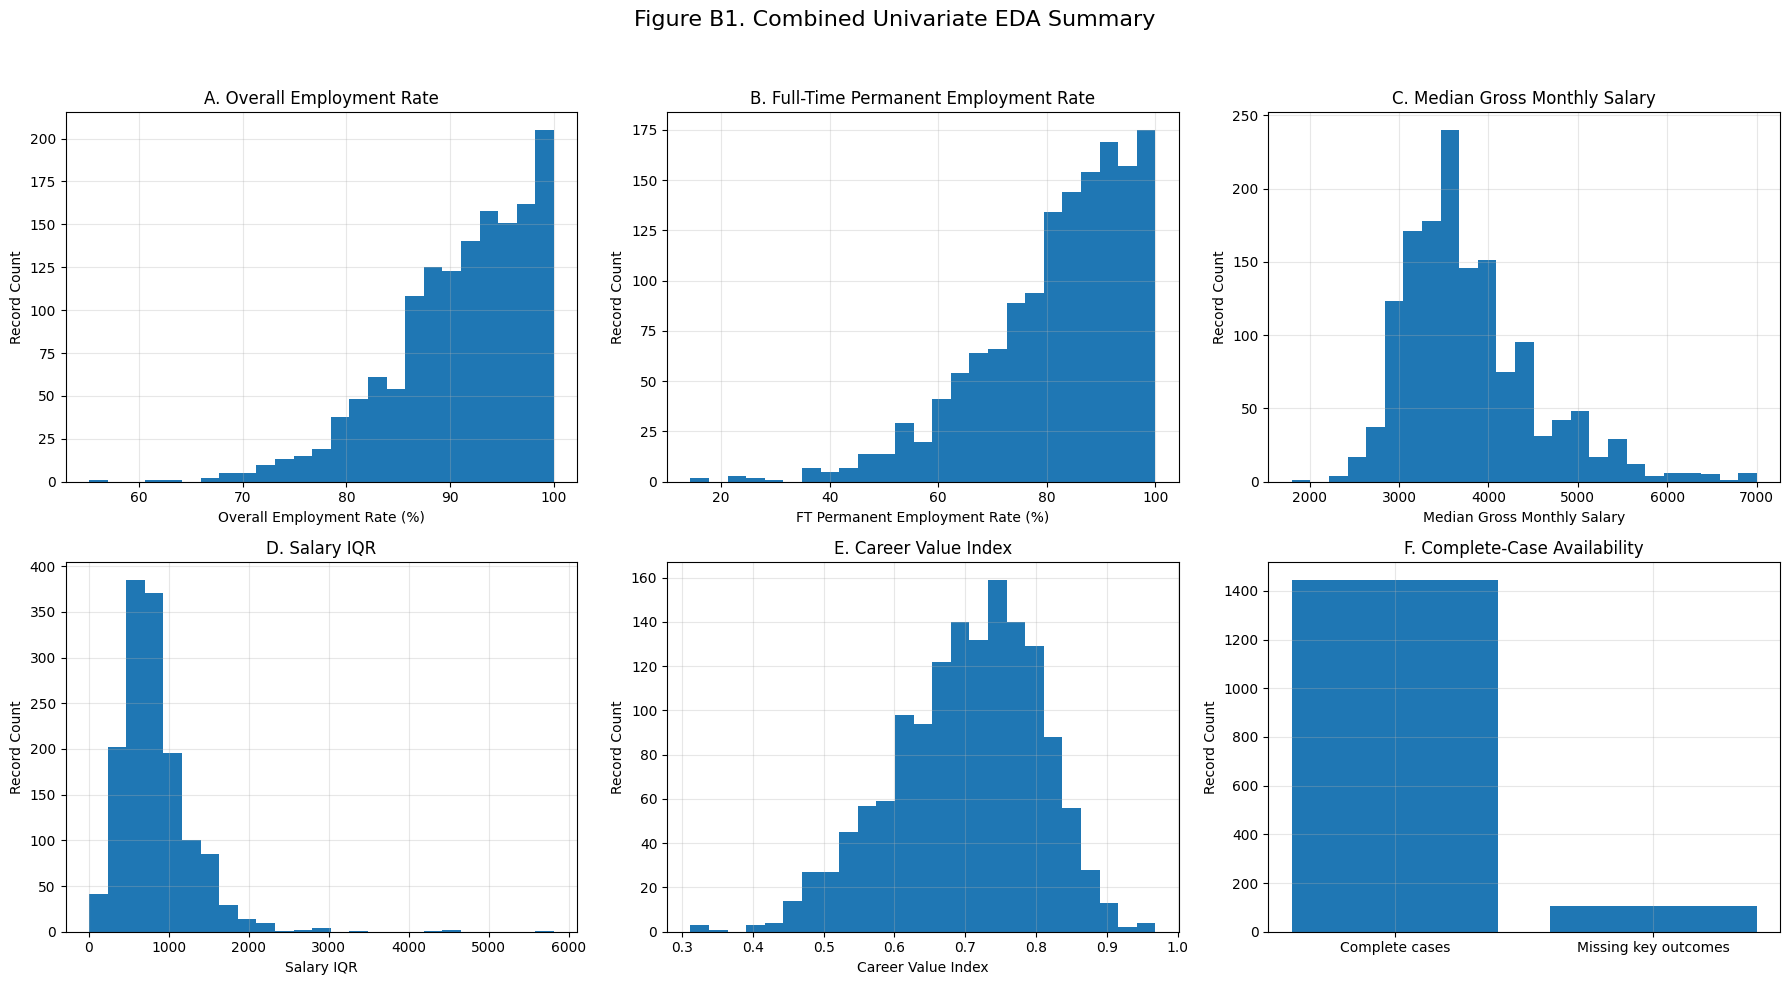

Saved: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/figures/appendix/figure_B1_combined_univariate_eda_summary.png


In [22]:
# ============================================================
# Appendix Figure B1: Combined Univariate EDA Summary
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# A. Overall employment distribution
axes[0, 0].hist(df_complete["employment_rate_overall"].dropna(), bins=25)
axes[0, 0].set_title("A. Overall Employment Rate")
axes[0, 0].set_xlabel("Overall Employment Rate (%)")
axes[0, 0].set_ylabel("Record Count")

# B. Full-time permanent employment distribution
axes[0, 1].hist(df_complete["employment_rate_ft_perm"].dropna(), bins=25)
axes[0, 1].set_title("B. Full-Time Permanent Employment Rate")
axes[0, 1].set_xlabel("FT Permanent Employment Rate (%)")
axes[0, 1].set_ylabel("Record Count")

# C. Median gross monthly salary distribution
axes[0, 2].hist(df_complete["gross_monthly_median"].dropna(), bins=25)
axes[0, 2].set_title("C. Median Gross Monthly Salary")
axes[0, 2].set_xlabel("Median Gross Monthly Salary")
axes[0, 2].set_ylabel("Record Count")

# D. Salary IQR distribution
axes[1, 0].hist(df_complete["salary_iqr"].dropna(), bins=25)
axes[1, 0].set_title("D. Salary IQR")
axes[1, 0].set_xlabel("Salary IQR")
axes[1, 0].set_ylabel("Record Count")

# E. Career Value Index distribution
axes[1, 1].hist(df_complete["career_value_index"].dropna(), bins=25)
axes[1, 1].set_title("E. Career Value Index")
axes[1, 1].set_xlabel("Career Value Index")
axes[1, 1].set_ylabel("Record Count")

# F. Complete-case vs missing-case count
complete_count = df_complete.shape[0]
missing_count = df.shape[0] - complete_count

axes[1, 2].bar(["Complete cases", "Missing key outcomes"], [complete_count, missing_count])
axes[1, 2].set_title("F. Complete-Case Availability")
axes[1, 2].set_ylabel("Record Count")

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)

fig.suptitle("Figure B1. Combined Univariate EDA Summary", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

figure_b1_path = APPENDIX_FIGURE_DIR / "figure_B1_combined_univariate_eda_summary.png"
plt.savefig(figure_b1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_b1_path)

### Figure B1 Interpretation

- Figure B1 summarizes the univariate distribution of the main employment, salary, salary-spread, and Career Value Index variables.
- The figure confirms that the dataset has sufficient complete-case availability for modelling.
- Overall employment is generally high, while full-time permanent employment shows wider variation.
- Median gross monthly salary and salary IQR show salary-level and salary-spread differences across program-year records.
- CVI values provide a combined program-level outcome measure for comparing employment, salary, and stability dimensions.

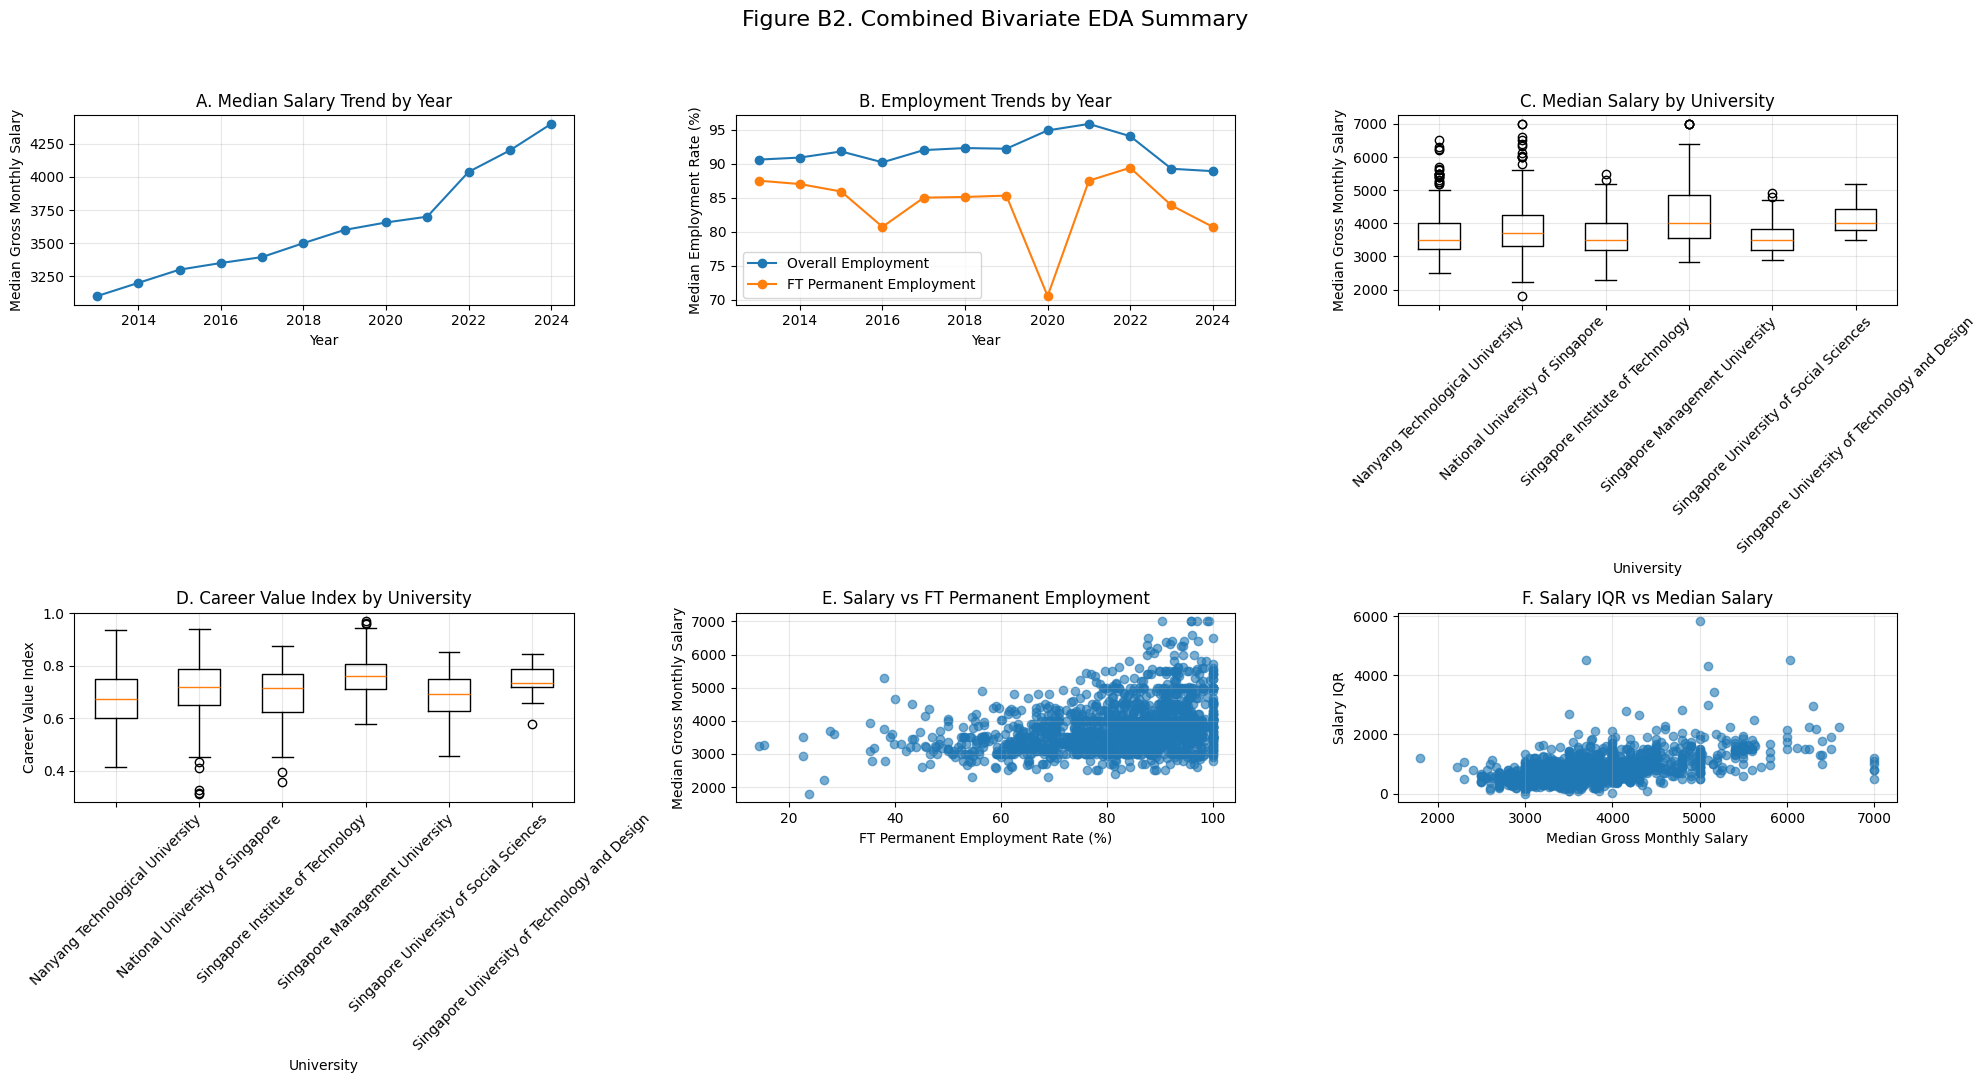

Saved: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/figures/appendix/figure_B2_combined_bivariate_eda_summary.png


In [23]:
# ============================================================
# Appendix Figure B2: Combined Bivariate EDA Summary
# ============================================================

# Year-level trend summary
year_summary = (
    df_complete
    .groupby("year")
    .agg(
        median_gross_salary=("gross_monthly_median", "median"),
        median_overall_employment=("employment_rate_overall", "median"),
        median_ft_perm_employment=("employment_rate_ft_perm", "median"),
        median_cvi=("career_value_index", "median"),
        median_salary_iqr=("salary_iqr", "median")
    )
    .reset_index()
)

# University-level summaries
salary_by_uni = [
    df_complete.loc[df_complete["university"] == uni, "gross_monthly_median"].dropna()
    for uni in sorted(df_complete["university"].dropna().unique())
]
cvi_by_uni = [
    df_complete.loc[df_complete["university"] == uni, "career_value_index"].dropna()
    for uni in sorted(df_complete["university"].dropna().unique())
]
uni_labels = sorted(df_complete["university"].dropna().unique())

fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# A. Median salary trend by year
axes[0, 0].plot(year_summary["year"], year_summary["median_gross_salary"], marker="o")
axes[0, 0].set_title("A. Median Salary Trend by Year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Median Gross Monthly Salary")

# B. Employment trend by year
axes[0, 1].plot(year_summary["year"], year_summary["median_overall_employment"], marker="o", label="Overall Employment")
axes[0, 1].plot(year_summary["year"], year_summary["median_ft_perm_employment"], marker="o", label="FT Permanent Employment")
axes[0, 1].set_title("B. Employment Trends by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Median Employment Rate (%)")
axes[0, 1].legend()

# C. Median salary by university
axes[0, 2].boxplot(salary_by_uni, labels=uni_labels, showfliers=True)
axes[0, 2].set_title("C. Median Salary by University")
axes[0, 2].set_xlabel("University")
axes[0, 2].set_ylabel("Median Gross Monthly Salary")
axes[0, 2].tick_params(axis="x", rotation=45)

# D. CVI by university
axes[1, 0].boxplot(cvi_by_uni, labels=uni_labels, showfliers=True)
axes[1, 0].set_title("D. Career Value Index by University")
axes[1, 0].set_xlabel("University")
axes[1, 0].set_ylabel("Career Value Index")
axes[1, 0].tick_params(axis="x", rotation=45)

# E. Median salary vs FT permanent employment
axes[1, 1].scatter(
    df_complete["employment_rate_ft_perm"],
    df_complete["gross_monthly_median"],
    alpha=0.6
)
axes[1, 1].set_title("E. Salary vs FT Permanent Employment")
axes[1, 1].set_xlabel("FT Permanent Employment Rate (%)")
axes[1, 1].set_ylabel("Median Gross Monthly Salary")

# F. Salary IQR vs median salary
axes[1, 2].scatter(
    df_complete["gross_monthly_median"],
    df_complete["salary_iqr"],
    alpha=0.6
)
axes[1, 2].set_title("F. Salary IQR vs Median Salary")
axes[1, 2].set_xlabel("Median Gross Monthly Salary")
axes[1, 2].set_ylabel("Salary IQR")

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)

fig.suptitle("Figure B2. Combined Bivariate EDA Summary", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

figure_b2_path = APPENDIX_FIGURE_DIR / "figure_B2_combined_bivariate_eda_summary.png"
plt.savefig(figure_b2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_b2_path)

### Figure B2 Interpretation

- Figure B2 summarizes the main bivariate relationships used to support RQ1, RQ2, and RQ3.
- Salary shows a clear upward trend from 2013 to 2024.
- Full-time permanent employment varies more than overall employment, supporting the decision to analyze stable employment separately.
- University-level boxplots show visible differences in median salary and CVI across universities.
- The scatter plots show that salary, employment stability, and salary spread provide different perspectives on graduate outcomes.

Cluster profile columns:
['cluster', 'record_count', 'median_overall_employment', 'median_ft_perm_employment', 'median_gross_salary', 'median_salary_iqr', 'median_career_value_index', 'record_percent']
Using cluster column: cluster
Using CVI column: median_career_value_index


,cluster,median_career_value_index
0,1,0.79
1,2,0.74
2,3,0.60


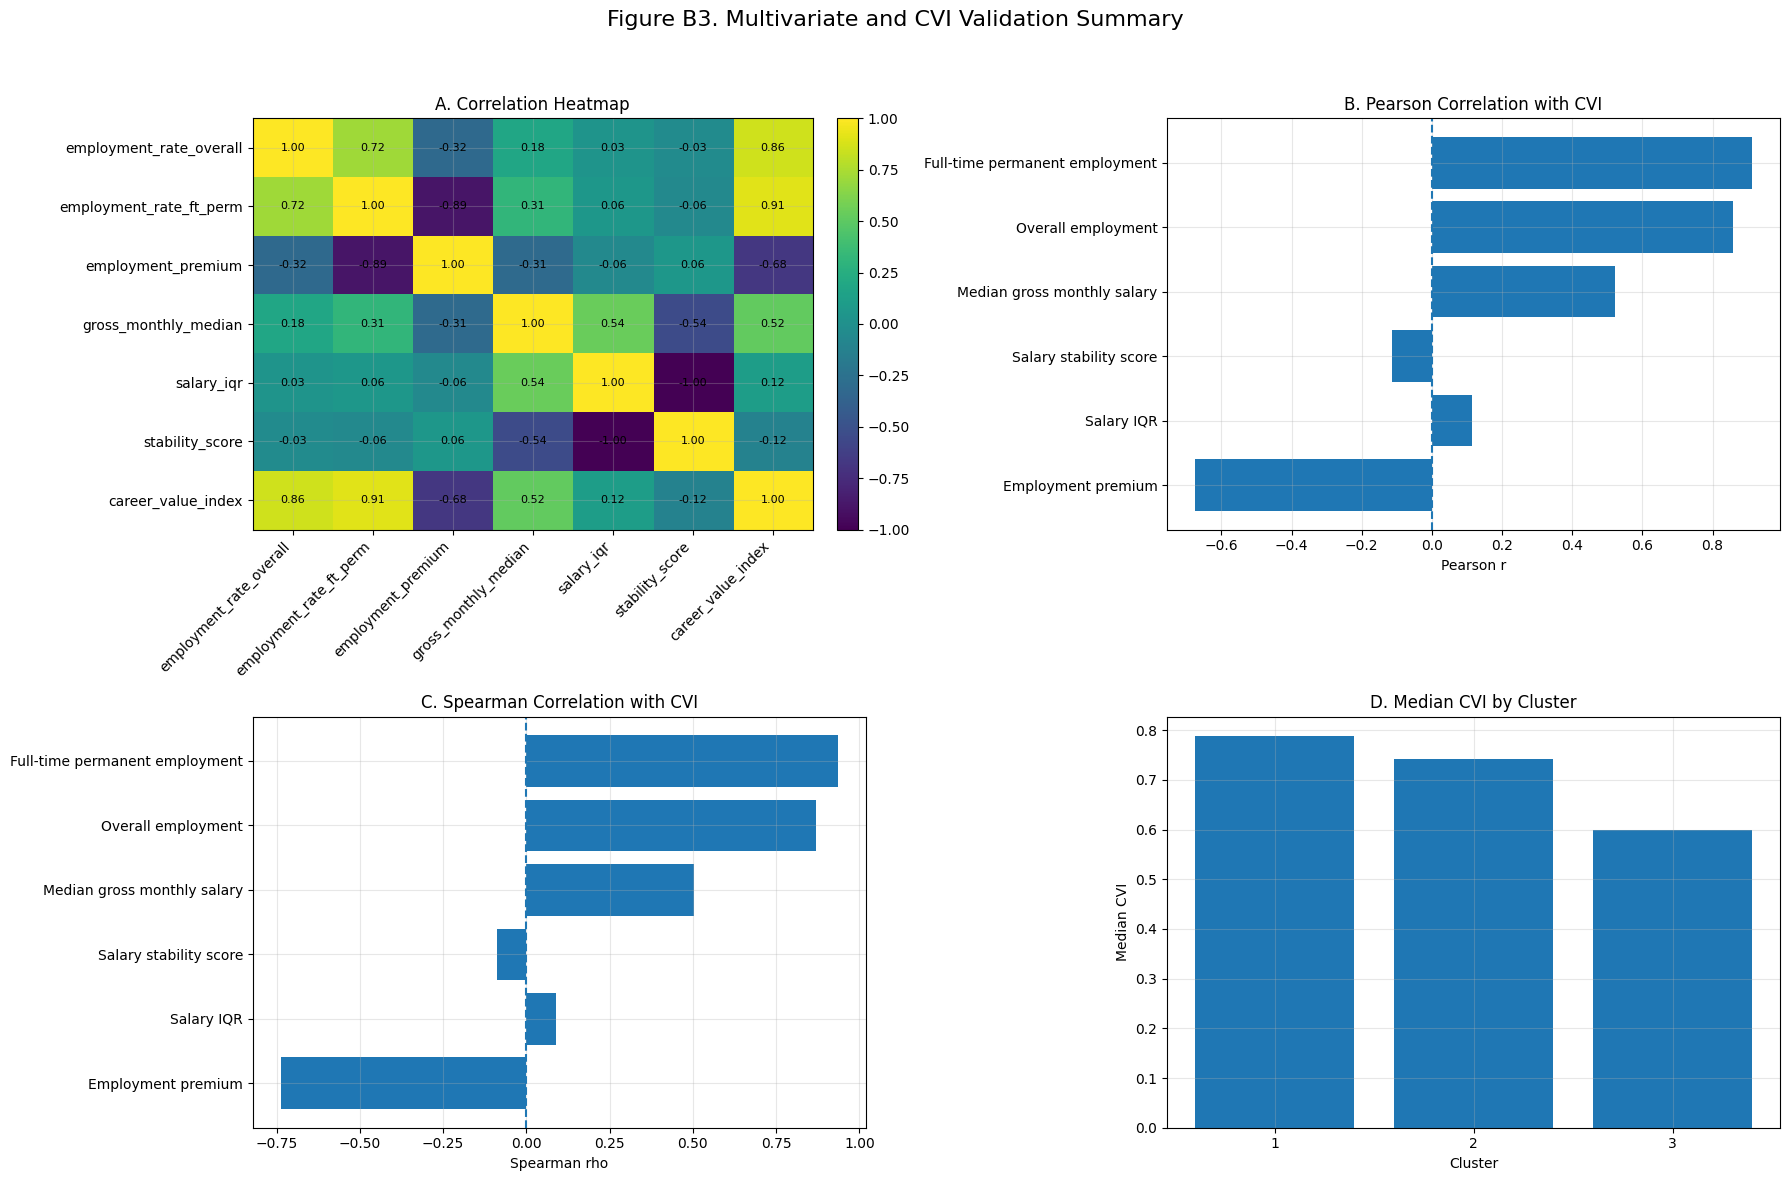

Saved: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/figures/appendix/figure_B3_multivariate_cvi_validation_summary.png


In [24]:
# ============================================================
# Appendix Figure B3: Multivariate and CVI Validation Summary
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# B3.1 Correlation heatmap variables
# ------------------------------------------------------------

corr_vars = [
    "employment_rate_overall",
    "employment_rate_ft_perm",
    "employment_premium",
    "gross_monthly_median",
    "salary_iqr",
    "stability_score",
    "career_value_index"
]

available_corr_vars = [col for col in corr_vars if col in df_complete.columns]
corr_matrix = df_complete[available_corr_vars].corr()

# ------------------------------------------------------------
# B3.2 Load CVI validation table from Part 8A
# ------------------------------------------------------------

cvi_validation_path = TABLE_DIR / "cvi_correlation_validation.csv"

if not cvi_validation_path.exists():
    raise FileNotFoundError(
        f"CVI validation table not found: {cvi_validation_path}. "
        "Please run Part 8A before Appendix Figure B3."
    )

cvi_validation_table = pd.read_csv(cvi_validation_path)

# ------------------------------------------------------------
# B3.3 Load cluster profile table for median CVI
# ------------------------------------------------------------

cluster_profile_path = TABLE_DIR / "cluster_profile_simple.csv"

if not cluster_profile_path.exists():
    raise FileNotFoundError(
        f"Cluster profile table not found: {cluster_profile_path}. "
        "Please run Part 14 clustering before Appendix Figure B3."
    )

cluster_profile = pd.read_csv(cluster_profile_path)

print("Cluster profile columns:")
print(cluster_profile.columns.tolist())

# ------------------------------------------------------------
# B3.4 Robustly identify cluster and median CVI columns
# ------------------------------------------------------------

def find_column_by_keywords(df_cols, required_keywords):
    for col in df_cols:
        col_lower = col.lower().replace("_", " ")
        if all(keyword.lower() in col_lower for keyword in required_keywords):
            return col
    return None

cluster_col = find_column_by_keywords(cluster_profile.columns, ["cluster"])

cvi_col = (
    find_column_by_keywords(cluster_profile.columns, ["median", "cvi"])
    or find_column_by_keywords(cluster_profile.columns, ["career", "value"])
    or find_column_by_keywords(cluster_profile.columns, ["career_value_index"])
)

if cluster_col is None:
    raise ValueError("Could not identify cluster column in cluster_profile_simple.csv.")

if cvi_col is None:
    raise ValueError("Could not identify median CVI column in cluster_profile_simple.csv.")

cluster_cvi = cluster_profile[[cluster_col, cvi_col]].copy()
cluster_cvi = cluster_cvi.sort_values(cluster_col)

print("Using cluster column:", cluster_col)
print("Using CVI column:", cvi_col)
display(cluster_cvi)

# ------------------------------------------------------------
# B3.5 Create combined multivariate and CVI validation figure
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# A. Correlation heatmap
im = axes[0, 0].imshow(corr_matrix, aspect="auto")
axes[0, 0].set_title("A. Correlation Heatmap")
axes[0, 0].set_xticks(range(len(available_corr_vars)))
axes[0, 0].set_yticks(range(len(available_corr_vars)))
axes[0, 0].set_xticklabels(available_corr_vars, rotation=45, ha="right")
axes[0, 0].set_yticklabels(available_corr_vars)

for i in range(len(available_corr_vars)):
    for j in range(len(available_corr_vars)):
        axes[0, 0].text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

# B. Pearson correlations with CVI
axes[0, 1].barh(
    cvi_validation_table["Feature"],
    cvi_validation_table["Pearson r"]
)
axes[0, 1].axvline(0, linestyle="--")
axes[0, 1].set_title("B. Pearson Correlation with CVI")
axes[0, 1].set_xlabel("Pearson r")
axes[0, 1].invert_yaxis()

# C. Spearman correlations with CVI
axes[1, 0].barh(
    cvi_validation_table["Feature"],
    cvi_validation_table["Spearman rho"]
)
axes[1, 0].axvline(0, linestyle="--")
axes[1, 0].set_title("C. Spearman Correlation with CVI")
axes[1, 0].set_xlabel("Spearman rho")
axes[1, 0].invert_yaxis()

# D. Median CVI by cluster from cluster profile table
axes[1, 1].bar(
    cluster_cvi[cluster_col].astype(str),
    cluster_cvi[cvi_col]
)
axes[1, 1].set_title("D. Median CVI by Cluster")
axes[1, 1].set_xlabel("Cluster")
axes[1, 1].set_ylabel("Median CVI")

for ax in axes.flatten():
    ax.grid(True, alpha=0.3)

fig.suptitle("Figure B3. Multivariate and CVI Validation Summary", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

figure_b3_path = APPENDIX_FIGURE_DIR / "figure_B3_multivariate_cvi_validation_summary.png"
plt.savefig(figure_b3_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figure_b3_path)

### Figure B3 Interpretation

- Figure B3 summarizes the multivariate correlation structure and CVI validation evidence.
- The correlation heatmap shows relationships among employment, salary, salary spread, stability, and CVI variables.
- The Pearson and Spearman correlation charts show that CVI is strongly associated with full-time permanent employment and overall employment.
- CVI is moderately associated with median gross monthly salary.
- Employment premium is negatively associated with CVI, supporting the interpretation that a wider gap between general employment and stable employment reduces career value.
- Stability-related variables show weaker relationships and should be reviewed further through sensitivity analysis.
- This figure supports the use of CVI as a program-level decision-support index, while keeping the interpretation non-causal.

In [25]:
# ============================================================
# Appendix Figure Index
# ============================================================

appendix_figure_index = pd.DataFrame([
    {
        "Figure": "Figure B1",
        "Title": "Combined Univariate EDA Summary",
        "File Path": str(figure_b1_path),
        "Report Use": "Appendix B / Univariate EDA"
    },
    {
        "Figure": "Figure B2",
        "Title": "Combined Bivariate EDA Summary",
        "File Path": str(figure_b2_path),
        "Report Use": "Appendix B / Bivariate EDA"
    },
    {
        "Figure": "Figure B3",
        "Title": "Multivariate and CVI Validation Summary",
        "File Path": str(figure_b3_path),
        "Report Use": "Appendix B / Multivariate and CVI Validation"
    }
])

appendix_figure_index_path = TABLE_DIR / "appendix_b_figure_index.csv"
appendix_figure_index.to_csv(appendix_figure_index_path, index=False)

display(appendix_figure_index)

print("Saved appendix figure index to:", appendix_figure_index_path)

,Figure,Title,File Path,Report Use
0,Figure B1,Combined Univariate EDA Summary,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Appendix B / Univariate EDA
1,Figure B2,Combined Bivariate EDA Summary,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Appendix B / Bivariate EDA
2,Figure B3,Multivariate and CVI Validation Summary,/home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THE...,Appendix B / Multivariate and CVI Validation


Saved appendix figure index to: /home/kumarans/MS_AIML/Term1/DEEP_LEARNING_THEORY_PRACTICAL_ APPLICATIONS/MS_Capstone+NLP/QM 640_DATA_ANALYTICS_CAPSTONE/Code/outputs/tables/appendix_b_figure_index.csv
